In [9]:
# import libraries
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter
from IPython.display import display, HTML

mpl.rcParams["font.family"] = "Microsoft JhengHei"
mpl.rcParams["axes.unicode_minus"] = False

In [2]:
# Configuration
DATA_FOLDER = Path(r"C:\Users\H0147\Documents\資料")

SHEET_NAME = "_SELECT_FROM_SELECT_BK_SUBSTR_B"

SNAPSHOT_FILES = [
    "BK_SO_VER 260531_V2.xlsx",
    "BK_SO_VER 260607_V2.xlsx",
    "BK_SO_VER 260614_V2.xlsx",
    "BK_SO_VER 260621_V2.xlsx",
]

SNAPSHOT_PAIRS = [
    ("BK_SO_VER 260531_V2.xlsx", "BK_SO_VER 260607_V2.xlsx"),
    ("BK_SO_VER 260607_V2.xlsx", "BK_SO_VER 260614_V2.xlsx"),
    ("BK_SO_VER 260614_V2.xlsx", "BK_SO_VER 260621_V2.xlsx"),
]

DATA1 = "BK_SO_VER 260614_V2.xlsx"
DATA2 = "BK_SO_VER 260621_V2.xlsx"

LINE_ID_KEY = ["LINE_ID"]

REFERENCE_FIELDS = [
    "LINE_SET_ID",
    "LINE_NO",
    "SEGMENT1",
    "PARTY_NAME",
    "PROJECT_CODE",
    "ORDER_TYPE_NAME",
]

COMPARE_FIELDS = [
    "REQUEST_DATE",
    "ORDERED_QUANTITY",
    "US_PRICE",
    "US_AMOUNT",
    "EST_REV_MONTH",
    "FLOW_STATUS_CODE",
    "SCHEDULE_SHIP_DATE",
    "ACTUAL_FULFILLMENT_DATE",
    "SCHEDULE_CHECK_FLAG",
]

USE_COLUMNS = LINE_ID_KEY + REFERENCE_FIELDS + COMPARE_FIELDS

DATE_FIELDS = [
    "REQUEST_DATE",
    "SCHEDULE_SHIP_DATE",
    "ACTUAL_FULFILLMENT_DATE",
    "EST_REV_MONTH",
]

EXCLUDED_FLOW_STATUS = ["CLOSED"]

In [3]:
snapshots = {}

for file in SNAPSHOT_FILES:
    path = DATA_FOLDER / file

    snapshots[file] = pd.read_excel(
        path,
        sheet_name=SHEET_NAME,
        usecols=USE_COLUMNS,
        keep_default_na=False
    )

for name, df in snapshots.items():
    print(name, "=", df.shape)

BK_SO_VER 260531_V2.xlsx = (134659, 16)
BK_SO_VER 260607_V2.xlsx = (136357, 16)
BK_SO_VER 260614_V2.xlsx = (138115, 16)
BK_SO_VER 260621_V2.xlsx = (139789, 16)


In [4]:
# helper function

# clean date
def clean_date(value):
    if pd.isna(value):
        return pd.NaT

    if isinstance(value, (int, float)):
        date_value = pd.to_datetime(
            value,
            origin="1899-12-30",
            unit="D",
            errors="coerce"
        )
    else:
        date_value = pd.to_datetime(value, errors="coerce")

    if pd.notna(date_value):
        date_value = date_value.normalize()

    return date_value


# strip the shared "BK_SO_VER ..._V2.xlsx" wrapper down to just the version code
def get_backup_version(file_name):
    return (
        file_name
        .replace("BK_SO_VER ", "")
        .replace("_V2.xlsx", "")
        .replace(".xlsx", "")
    )


# "260531 -> 260607" style label used to key the base data maps
def get_comparison_label(data1_name, data2_name):
    return get_backup_version(data1_name) + " → " + get_backup_version(data2_name)


# Cell 3 already cleaned DATE_FIELDS in place on the shared `snapshots` dict,
# so this is just a column-ordered copy, safe to reuse anywhere a single
# cleaned snapshot is needed without re-merging or re-cleaning dates.
def get_snapshot_df(file_name):
    return snapshots[file_name][USE_COLUMNS].copy()


# combine PROJECT_CODE/PARTY_NAME across the _data2 / _data1 / bare column
# variants that show up after an outer merge, preferring _data2 first
def build_combined_group_column(df, group_col):
    candidate_cols = [f"{group_col}_data2", f"{group_col}_data1", group_col]
    sources = [clean_text_col(df[c]) for c in candidate_cols if c in df.columns]

    if len(sources) == 0:
        raise ValueError(f"No {group_col} column found.")

    combined = sources[0]
    for s in sources[1:]:
        combined = combined.combine_first(s)

    return combined


# compare request date
def date_change(row):
    data1_request_date = row["REQUEST_DATE_data1"]
    data2_request_date = row["REQUEST_DATE_data2"]

    if pd.isna(data1_request_date) or pd.isna(data2_request_date):
        return "Missing Request Date"

    if data2_request_date < data1_request_date:
        return "Pull-in"
    elif data2_request_date > data1_request_date:
        return "Pull-out"
    else:
        return "No Change"

# compare revenue month
def rev_month_change(row):
    rev_month_1 = row["EST_REV_MONTH_data1"]
    rev_month_2 = row["EST_REV_MONTH_data2"]

    if pd.isna(rev_month_1) or pd.isna(rev_month_2):
        return "Missing Revenue Month"

    rev_month_1 = rev_month_1.to_period("M")
    rev_month_2 = rev_month_2.to_period("M")

    if rev_month_1 != rev_month_2:
        return "Yes"
    else:
        return "No"

def get_rev_month_date_source(row):
    rev_date = row["EST_REV_MONTH_data2"]
    schedule_ship_date = row["SCHEDULE_SHIP_DATE_data2"]
    actual_fulfillment_date = row["ACTUAL_FULFILLMENT_DATE_data2"]

    if pd.isna(rev_date):
        return "Missing Revenue Month"

    if pd.notna(schedule_ship_date) and rev_date == schedule_ship_date:
        return "Revenue Month Date = Schedule Ship Date"

    if pd.notna(actual_fulfillment_date) and rev_date == actual_fulfillment_date:
        return "Revenue Month Date = Actual Fulfillment Date"

    return "Other / Unknown"

# merged based data: existing, new, missing
def build_comparison_dataset(data1_name, data2_name):
    data1_df = get_snapshot_df(data1_name)
    data2_df = get_snapshot_df(data2_name)

    merged = data1_df.merge(
        data2_df,
        on=LINE_ID_KEY,
        how="outer",
        suffixes=("_data1", "_data2"),
        indicator=True,
        validate="one_to_one"
    )

    merged["MATCH_STATUS"] = merged["_merge"].map({
        "both": "Existing",
        "left_only": "Missing",
        "right_only": "New"
    })

    return data1_df, data2_df, merged


def build_analysis_dataset(merged):
    change_analysis_df = merged[
        (merged["MATCH_STATUS"] == "Existing") &
        (~merged["FLOW_STATUS_CODE_data1"].isin(EXCLUDED_FLOW_STATUS))
    ].copy()

    change_analysis_df["DATE_CHANGE"] = change_analysis_df.apply(
        date_change,
        axis=1
    )

    change_analysis_df["REV_MONTH_CHANGE"] = change_analysis_df.apply(
        rev_month_change,
        axis=1
    )

    change_analysis_df["QUANTITY_CHANGE"] = (
        change_analysis_df["ORDERED_QUANTITY_data1"]
        != change_analysis_df["ORDERED_QUANTITY_data2"]
    ).map({True: "Yes", False: "No"})

    # Price change
    price_1 = change_analysis_df["US_PRICE_data1"]
    price_2 = change_analysis_df["US_PRICE_data2"]

    valid_price_compare = (price_1.notna() &price_2.notna() &(price_1 != 0) &(price_2 != 0))

    change_analysis_df["PRICE_CHANGE"] = (
        valid_price_compare &
        (price_1 != price_2)
    ).map({True: "Yes", False: "No"})

    change_analysis_df["SCHEDULE_SHIP_DATE_CHANGE"] = (
        change_analysis_df["SCHEDULE_SHIP_DATE_data1"]
        != change_analysis_df["SCHEDULE_SHIP_DATE_data2"]
    ).map({True: "Yes", False: "No"})

    change_analysis_df["CURRENT_COMMIT_STATUS"] = (
        change_analysis_df["SCHEDULE_CHECK_FLAG_data2"]
        .fillna("Missing")
        .astype(str)
    )

    change_analysis_df["REV_MONTH_DATE_SOURCE"] = change_analysis_df.apply(
        get_rev_month_date_source,
        axis=1
    )

    return change_analysis_df


In [5]:
# Clean all date columns before comparison
for df in snapshots.values():
    for col in DATE_FIELDS:
        df[col] = df[col].apply(clean_date)

print("Date cleaning finished")

Date cleaning finished


In [6]:
merged_base_map = {}
change_analysis_base_map = {}
new_order_base_map = {}

for data1_name, data2_name in SNAPSHOT_PAIRS:

    comparison = get_comparison_label(data1_name, data2_name)

    # Raw comparison base
    data1_df, data2_df, merged = build_comparison_dataset(
        data1_name,
        data2_name
    )

    merged_base_map[comparison] = merged

    # Existing Order Base
    change_analysis_df = build_analysis_dataset(merged)

    change_analysis_base_map[comparison] = (
        change_analysis_df.copy()
    )

    # New Order Base
    new_order_base_map[comparison] = (
        merged[
            merged["MATCH_STATUS"] == "New"
        ].copy()
    )

In [10]:
# Helper Functions
def get_month_value(value):
    """
    將日期轉換成年月 Period。
    Missing 或無效日期回傳 NaT。
    """
    if pd.isna(value):
        return pd.NaT

    value = pd.to_datetime(value, errors="coerce")

    if pd.isna(value):
        return pd.NaT

    return value.to_period("M")


def date_values_changed(value1, value2):
    """
    安全判斷兩個日期是否不同。

    兩邊都 missing        -> False
    只有一邊 missing      -> True
    兩邊都有值但日期不同   -> True
    兩邊都有值且日期相同   -> False
    """
    value1 = pd.to_datetime(value1, errors="coerce")
    value2 = pd.to_datetime(value2, errors="coerce")

    if pd.isna(value1) and pd.isna(value2):
        return False

    if pd.isna(value1) != pd.isna(value2):
        return True

    return value1.normalize() != value2.normalize()


def same_month(value1, value2):
    """
    判斷兩個日期是否位於相同年月。
    """
    month1 = get_month_value(value1)
    month2 = get_month_value(value2)

    if pd.isna(month1) or pd.isna(month2):
        return False

    return month1 == month2

# Revenue Month Reason Category
def get_rev_month_reason_category(row):
    """
    判斷 Data2 Revenue Month 最後使用哪一個日期來源。

    判定優先順序：
    1. Actual Fulfillment Date
    2. Schedule Ship Date
    3. Request Date
    4. Unexplained

    注意：
    - 不再區分 Date Changed 與 Revenue Month Aligned。
    - 只要 Data2 Revenue Month 與某個 Data2 日期同月，
      就歸類到該日期來源。
    """

    rev1 = row["EST_REV_MONTH_data1"]
    rev2 = row["EST_REV_MONTH_data2"]

    request2 = row["REQUEST_DATE_data2"]
    schedule2 = row["SCHEDULE_SHIP_DATE_data2"]
    actual2 = row["ACTUAL_FULFILLMENT_DATE_data2"]

    status2 = (
        str(row["FLOW_STATUS_CODE_data2"])
        .strip()
        .upper()
    )

    rev_month_1 = get_month_value(rev1)
    rev_month_2 = get_month_value(rev2)

    # Revenue Month missing / added / removed
    if pd.isna(rev_month_1) and pd.isna(rev_month_2):
        return "Both Revenue Month Missing"

    if pd.isna(rev_month_1) and pd.notna(rev_month_2):
        return "Revenue Month Added"

    if pd.notna(rev_month_1) and pd.isna(rev_month_2):

        if "CLOSED" in status2 or "CANCEL" in status2:
            return "Closed/Cancelled - Revenue Month Removed"

        return "Revenue Month Removed - Unexplained"

    # Revenue Month 沒有改變
    if rev_month_1 == rev_month_2:
        return "Revenue Month No Change"

    # Data2 Revenue Month 最後跟哪個日期來源同月
    #
    # Priority:
    # Actual Fulfillment > Schedule Ship > Request
    if same_month(rev2, actual2):
        return "Actual Fulfillment Date"

    if same_month(rev2, schedule2):
        return "Schedule Ship Date"

    if same_month(rev2, request2):
        return "Request Date"

    return "Unexplained"

# Revenue Month Analysis
def analyze_rev_month_reason(data1_name, data2_name):

    data1_df, data2_df, merged = build_comparison_dataset(
        data1_name,
        data2_name
    )

    change_analysis_df = build_analysis_dataset(merged).copy()

    # Request Date Change 顯示
    change_analysis_df["DATE_CHANGE_DISPLAY"] = (
        change_analysis_df["DATE_CHANGE"]
        .fillna("Missing Request Date")
    )

    # Revenue Month 日期來源分類
    change_analysis_df["REV_MONTH_REASON_CATEGORY"] = (
        change_analysis_df.apply(
            get_rev_month_reason_category,
            axis=1
        )
    )

    # 日期是否有改變
    change_analysis_df["ACTUAL_DATE_CHANGED"] = (
        change_analysis_df.apply(
            lambda row: date_values_changed(
                row["ACTUAL_FULFILLMENT_DATE_data1"],
                row["ACTUAL_FULFILLMENT_DATE_data2"]
            ),
            axis=1
        )
    )

    change_analysis_df["SCHEDULE_DATE_CHANGED"] = (
        change_analysis_df.apply(
            lambda row: date_values_changed(
                row["SCHEDULE_SHIP_DATE_data1"],
                row["SCHEDULE_SHIP_DATE_data2"]
            ),
            axis=1
        )
    )

    change_analysis_df["REQUEST_DATE_CHANGED_RECALCULATED"] = (
        change_analysis_df.apply(
            lambda row: date_values_changed(
                row["REQUEST_DATE_data1"],
                row["REQUEST_DATE_data2"]
            ),
            axis=1
        )
    )

    # Revenue Month 是否與 Data2 日期來源同月
    change_analysis_df["REV2_EQUALS_ACTUAL2_MONTH"] = (
        change_analysis_df.apply(
            lambda row: same_month(
                row["EST_REV_MONTH_data2"],
                row["ACTUAL_FULFILLMENT_DATE_data2"]
            ),
            axis=1
        )
    )

    change_analysis_df["REV2_EQUALS_SCHEDULE2_MONTH"] = (
        change_analysis_df.apply(
            lambda row: same_month(
                row["EST_REV_MONTH_data2"],
                row["SCHEDULE_SHIP_DATE_data2"]
            ),
            axis=1
        )
    )

    change_analysis_df["REV2_EQUALS_REQUEST2_MONTH"] = (
        change_analysis_df.apply(
            lambda row: same_month(
                row["EST_REV_MONTH_data2"],
                row["REQUEST_DATE_data2"]
            ),
            axis=1
        )
    )

    # Missing / Added / Removed Revenue Month
    missing_reason_categories = [
        "Both Revenue Month Missing",
        "Revenue Month Added",
        "Closed/Cancelled - Revenue Month Removed",
        "Revenue Month Removed - Unexplained"
    ]

    missing_rev_month_df = change_analysis_df[
        change_analysis_df["REV_MONTH_REASON_CATEGORY"]
        .isin(missing_reason_categories)
    ].copy()

    valid_rev_month_df = change_analysis_df[
        ~change_analysis_df["REV_MONTH_REASON_CATEGORY"]
        .isin(missing_reason_categories)
    ].copy()

    total_summary = pd.DataFrame({
        "Step": [
            "Original merged",
            "Existing only",
            "Existing + Data 1 Closed Status Excluded",
            "Missing / Added / Removed Revenue Month",
            "Final valid Revenue Month dataset"
        ],
        "Count": [
            len(merged),

            (merged["MATCH_STATUS"] == "Existing").sum(),

            (
                (merged["MATCH_STATUS"] == "Existing")
                &
                (
                    ~merged["FLOW_STATUS_CODE_data1"]
                    .isin(EXCLUDED_FLOW_STATUS)
                )
            ).sum(),

            len(missing_rev_month_df),

            len(valid_rev_month_df)
        ]
    })

    # Request Date Change × Revenue Month Change
    date_rev_pivot = pd.crosstab(
        valid_rev_month_df["DATE_CHANGE_DISPLAY"],
        valid_rev_month_df["REV_MONTH_CHANGE"],
        margins=True,
        margins_name="Total"
    ).reset_index()

    # Revenue Month 有變動的資料
    rev_changed_df = valid_rev_month_df[
        valid_rev_month_df["REV_MONTH_CHANGE"] == "Yes"
    ].copy()

    rev_month_1 = (
        rev_changed_df["EST_REV_MONTH_data1"]
        .dt.to_period("M")
    )

    rev_month_2 = (
        rev_changed_df["EST_REV_MONTH_data2"]
        .dt.to_period("M")
    )

    rev_changed_df["REV_MONTH_DIRECTION"] = np.select(
        [
            rev_month_2 < rev_month_1,
            rev_month_2 > rev_month_1
        ],
        [
            "Pulled-in Revenue",
            "Pushed-out Revenue"
        ],
        default="Revenue Month No Change"
    )

    # Revenue Month Direction × Request Date Change
    direction_request_summary = pd.crosstab(
        rev_changed_df["REV_MONTH_DIRECTION"],
        rev_changed_df["DATE_CHANGE_DISPLAY"],
        margins=True,
        margins_name="Total"
    ).reset_index()

    # 只看 Request Date 沒有變動的案例
    no_request_change_df = rev_changed_df[
        rev_changed_df["DATE_CHANGE_DISPLAY"] == "No Change"
    ].copy()
    
    # Request Date 沒改時，Revenue Month 最後採用哪個日期來源
    no_request_reason_summary = (
        no_request_change_df[
            "REV_MONTH_REASON_CATEGORY"
        ]
        .value_counts(dropna=False)
        .rename_axis("REV_MONTH_REASON_CATEGORY")
        .reset_index(name="Count")
    )

    if len(no_request_reason_summary) > 0:
        no_request_reason_summary["Percentage"] = (
            no_request_reason_summary["Count"]
            / no_request_reason_summary["Count"].sum()
            * 100
        ).round(2)
    else:
        no_request_reason_summary["Percentage"] = pd.Series(
            dtype=float
        )

    no_request_reason_by_direction = pd.crosstab(
        no_request_change_df["REV_MONTH_REASON_CATEGORY"],
        no_request_change_df["REV_MONTH_DIRECTION"],
        margins=True,
        margins_name="Total"
    ).reset_index()

    # --------------------------------------------------------
    # Detail Columns
    # --------------------------------------------------------
    if isinstance(LINE_ID_KEY, list):
        id_columns = LINE_ID_KEY
    else:
        id_columns = [LINE_ID_KEY]

    detail_columns = id_columns + [
        "PARTY_NAME_data1",
        "PARTY_NAME_data2",
        "PROJECT_CODE_data1",
        "PROJECT_CODE_data2",

        "FLOW_STATUS_CODE_data1",
        "FLOW_STATUS_CODE_data2",

        "REQUEST_DATE_data1",
        "REQUEST_DATE_data2",
        "DATE_CHANGE",
        "DATE_CHANGE_DISPLAY",
        "REQUEST_DATE_CHANGED_RECALCULATED",

        "SCHEDULE_SHIP_DATE_data1",
        "SCHEDULE_SHIP_DATE_data2",
        "SCHEDULE_SHIP_DATE_CHANGE",
        "SCHEDULE_DATE_CHANGED",

        "ACTUAL_FULFILLMENT_DATE_data1",
        "ACTUAL_FULFILLMENT_DATE_data2",
        "ACTUAL_DATE_CHANGED",

        "EST_REV_MONTH_data1",
        "EST_REV_MONTH_data2",
        "REV_MONTH_CHANGE",
        "REV_MONTH_DIRECTION",
        "REV_MONTH_REASON_CATEGORY",

        "REV2_EQUALS_ACTUAL2_MONTH",
        "REV2_EQUALS_SCHEDULE2_MONTH",
        "REV2_EQUALS_REQUEST2_MONTH",

        "CURRENT_COMMIT_STATUS",

        "ORDERED_QUANTITY_data1",
        "ORDERED_QUANTITY_data2",
        "QUANTITY_CHANGE",

        "US_PRICE_data1",
        "US_PRICE_data2",
        "PRICE_CHANGE"
    ]

    existing_detail_columns = [
        col
        for col in detail_columns
        if col in rev_changed_df.columns
    ]

    rev_changed_detail = (
        rev_changed_df[existing_detail_columns]
        .copy()
    )

    no_request_change_detail = (
        no_request_change_df[existing_detail_columns]
        .copy()
    )

    return {
        "total_summary": total_summary,

        "change_analysis_df": valid_rev_month_df,
        "missing_rev_month_df": missing_rev_month_df,

        "date_rev_pivot": date_rev_pivot,

        "rev_changed_df": rev_changed_df,
        "direction_request_summary": direction_request_summary,

        "no_request_change_df": no_request_change_df,
        "no_request_reason_summary": no_request_reason_summary,
        "no_request_reason_by_direction": no_request_reason_by_direction,

        "rev_changed_detail": rev_changed_detail,
        "no_request_change_detail": no_request_change_detail
    }


# ============================================================
# Run All Snapshot Comparisons
# ============================================================
all_rev_month_reason_results = []

for data1_name, data2_name in SNAPSHOT_PAIRS:

    result = analyze_rev_month_reason(
        data1_name,
        data2_name
    )

    all_rev_month_reason_results.append(
        (
            data1_name,
            data2_name,
            result
        )
    )


# ============================================================
# HTML Display
# ============================================================
def df_to_html_table(df):
    return df.to_html(
        index=False,
        border=0
    )


html_blocks = []

for (
    data1_name,
    data2_name,
    result
) in all_rev_month_reason_results:

    comparison = get_comparison_label(
        data1_name,
        data2_name
    )

    block = f"""
    <div style="
        flex: 1;
        min-width: 470px;
        padding: 12px;
        box-sizing: border-box;
        vertical-align: top;
    ">
        <h3>{comparison}</h3>

        <h4>Total Summary</h4>
        {df_to_html_table(result["total_summary"])}

        <h4>Request Date Change × Revenue Month Change</h4>
        {df_to_html_table(result["date_rev_pivot"])}

        <h4>Revenue Month Direction × Request Date Change</h4>
        {df_to_html_table(result["direction_request_summary"])}

        <h4>
            Revenue Month Date Source:
            Request Date No Change Only
        </h4>
        {
            df_to_html_table(
                result["no_request_reason_by_direction"]
            )
        }
    </div>
    """

    html_blocks.append(block)


html = f"""
<div style="
    display: flex;
    gap: 20px;
    align-items: flex-start;
    overflow-x: auto;
    width: 100%;
">
    {''.join(html_blocks)}
</div>
"""

display(HTML(html))

In [69]:
# ============================================================
# Revenue Month Direct Driver Analysis
#
# Rules:
# 1. Analyze Revenue Month changed order lines only
# 2. Do NOT filter by Request Date changed / no change
# 3. Source priority:
#       Request Date
#       Schedule Ship Date
#       Actual Fulfillment Date
#       Unexplained
# 4. If Request and Schedule are in the same month,
#    classify as Request Date
# 5. Factory delay / pull-in analysis is performed only for
#    lines classified as Schedule Ship Date
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import display, HTML


# ============================================================
# 1. Configuration
# ============================================================

# Prevent invalid Excel dates such as year 0202, 0206, 0226
VALID_DATE_MIN = pd.Timestamp("2025-01-01")
VALID_DATE_MAX = pd.Timestamp("2027-12-31")


# ============================================================
# 2. Helper Functions
# ============================================================

def get_valid_date(value):
    """
    Convert value to datetime and remove invalid/out-of-range dates.
    """

    if pd.isna(value):
        return pd.NaT

    converted = pd.to_datetime(
        value,
        errors="coerce"
    )

    if pd.isna(converted):
        return pd.NaT

    if (
        converted < VALID_DATE_MIN
        or converted > VALID_DATE_MAX
    ):
        return pd.NaT

    return converted.normalize()


def get_month_value(value):
    """
    Convert a valid date to monthly Period.
    Invalid or missing values return pd.NaT.
    """

    valid_date = get_valid_date(value)

    if pd.isna(valid_date):
        return pd.NaT

    return valid_date.to_period("M")


def same_month(value1, value2):
    """
    Return True when two valid dates are in the same year-month.
    """

    month1 = get_month_value(value1)
    month2 = get_month_value(value2)

    if pd.isna(month1) or pd.isna(month2):
        return False

    return month1 == month2


def date_values_changed(value1, value2):
    """
    Compare two valid dates.

    Both missing/invalid       -> False
    Only one valid             -> True
    Both valid but different   -> True
    Both valid and same        -> False
    """

    date1 = get_valid_date(value1)
    date2 = get_valid_date(value2)

    if pd.isna(date1) and pd.isna(date2):
        return False

    if pd.isna(date1) != pd.isna(date2):
        return True

    return date1 != date2


def get_month_difference(date_from, date_to):
    """
    Calculate date_to relative to date_from in months.

    Positive = date_to is later
    Negative = date_to is earlier
    Zero     = same month
    """

    month_from = get_month_value(date_from)
    month_to = get_month_value(date_to)

    if pd.isna(month_from) or pd.isna(month_to):
        return np.nan

    return (
        (month_to.year - month_from.year) * 12
        + month_to.month
        - month_from.month
    )


def get_shift_label(value):
    """
    Convert month difference into readable label.
    """

    if pd.isna(value):
        return "Missing / Invalid Date"

    value = int(value)

    if value > 0:
        return f"Delayed {value} Month(s)"

    if value < 0:
        return f"Earlier {abs(value)} Month(s)"

    return "Same Month"


def add_percentage(
    df,
    count_col="ORDER_LINE_COUNT"
):
    """
    Add percentage column based on ORDER_LINE_COUNT.
    """

    result = df.copy()

    total = result[count_col].sum()

    if total > 0:
        result["PERCENTAGE"] = (
            result[count_col]
            / total
            * 100
        ).round(2)
    else:
        result["PERCENTAGE"] = pd.Series(
            dtype=float
        )

    return result


def build_order_line_id(df):
    """
    Build unified order-line ID for counting.
    """

    result = df.copy()

    if isinstance(LINE_ID_KEY, list):

        available_keys = [
            col
            for col in LINE_ID_KEY
            if col in result.columns
        ]

        if available_keys:
            result["_ORDER_LINE_ID"] = (
                result[available_keys]
                .astype("string")
                .fillna("<Missing>")
                .agg("|".join, axis=1)
            )
        else:
            result["_ORDER_LINE_ID"] = (
                result.index.astype("string")
            )

    else:

        if LINE_ID_KEY in result.columns:
            result["_ORDER_LINE_ID"] = (
                result[LINE_ID_KEY]
                .astype("string")
            )
        else:
            result["_ORDER_LINE_ID"] = (
                result.index.astype("string")
            )

    return result


# ============================================================
# 3. Revenue Month Availability
# ============================================================

def get_rev_month_status(row):
    """
    Determine Revenue Month status between Data1 and Data2.
    """

    rev1 = get_month_value(
        row.get("EST_REV_MONTH_data1")
    )

    rev2 = get_month_value(
        row.get("EST_REV_MONTH_data2")
    )

    status2 = (
        str(
            row.get(
                "FLOW_STATUS_CODE_data2",
                ""
            )
        )
        .strip()
        .upper()
    )

    if pd.isna(rev1) and pd.isna(rev2):
        return "Both Revenue Month Missing"

    if pd.isna(rev1) and pd.notna(rev2):
        return "Revenue Month Added"

    if pd.notna(rev1) and pd.isna(rev2):

        if (
            "CLOSED" in status2
            or "CANCEL" in status2
        ):
            return (
                "Closed/Cancelled - "
                "Revenue Month Removed"
            )

        return "Revenue Month Removed - Unexplained"

    if rev1 == rev2:
        return "Revenue Month No Change"

    return "Revenue Month Changed"


# ============================================================
# 4. Direct Revenue Month Source
# ============================================================

def get_direct_rev_month_source(row):
    """
    Identify which Data2 date directly aligns with Data2 Revenue Month.

    Priority:
    1. Request Date
    2. Schedule Ship Date
    3. Actual Fulfillment Date
    4. Unexplained

    Important:
    If Request Date and Schedule Ship Date are in the same month,
    and Revenue Month also matches that month, classify as Request Date.
    """

    rev2 = row.get(
        "EST_REV_MONTH_data2"
    )

    request2 = row.get(
        "REQUEST_DATE_data2"
    )

    schedule2 = row.get(
        "SCHEDULE_SHIP_DATE_data2"
    )

    actual2 = row.get(
        "ACTUAL_FULFILLMENT_DATE_data2"
    )

    if same_month(rev2, request2):
        return "Request Date"

    if same_month(rev2, schedule2):
        return "Schedule Ship Date"

    if same_month(rev2, actual2):
        return "Actual Fulfillment Date"

    return "Unexplained"


def get_request_schedule_relationship(row):
    """
    Identify whether Request and Schedule are in the same month.
    """

    request2 = row.get(
        "REQUEST_DATE_data2"
    )

    schedule2 = row.get(
        "SCHEDULE_SHIP_DATE_data2"
    )

    request_month = get_month_value(request2)
    schedule_month = get_month_value(schedule2)

    if (
        pd.isna(request_month)
        or pd.isna(schedule_month)
    ):
        return "Missing / Invalid Date"

    if request_month == schedule_month:
        return "Request and Schedule Same Month"

    return "Request and Schedule Different Month"


# ============================================================
# 5. Main Analysis
# ============================================================

def analyze_rev_month_direct_driver(
    data1_name,
    data2_name
):

    # --------------------------------------------------------
    # Build base dataset
    # --------------------------------------------------------

    data1_df, data2_df, merged = (
        build_comparison_dataset(
            data1_name,
            data2_name
        )
    )

    analysis_df = (
        build_analysis_dataset(
            merged
        )
        .copy()
    )

    analysis_df = build_order_line_id(
        analysis_df
    )

    # --------------------------------------------------------
    # Revenue Month status
    # --------------------------------------------------------

    analysis_df[
        "REV_MONTH_STATUS"
    ] = analysis_df.apply(
        get_rev_month_status,
        axis=1
    )

    # --------------------------------------------------------
    # Date-change flags
    #
    # These are shown for reference only.
    # They are NOT used to filter the analysis.
    # --------------------------------------------------------

    analysis_df[
        "REQUEST_DATE_CHANGED"
    ] = analysis_df.apply(
        lambda row: date_values_changed(
            row.get("REQUEST_DATE_data1"),
            row.get("REQUEST_DATE_data2")
        ),
        axis=1
    )

    analysis_df[
        "SCHEDULE_DATE_CHANGED"
    ] = analysis_df.apply(
        lambda row: date_values_changed(
            row.get(
                "SCHEDULE_SHIP_DATE_data1"
            ),
            row.get(
                "SCHEDULE_SHIP_DATE_data2"
            )
        ),
        axis=1
    )

    analysis_df[
        "ACTUAL_DATE_CHANGED"
    ] = analysis_df.apply(
        lambda row: date_values_changed(
            row.get(
                "ACTUAL_FULFILLMENT_DATE_data1"
            ),
            row.get(
                "ACTUAL_FULFILLMENT_DATE_data2"
            )
        ),
        axis=1
    )

    # --------------------------------------------------------
    # Only Revenue Month changed lines
    # --------------------------------------------------------

    rev_changed_df = (
        analysis_df[
            analysis_df[
                "REV_MONTH_STATUS"
            ]
            .eq("Revenue Month Changed")
        ]
        .copy()
    )

    # --------------------------------------------------------
    # Revenue Month direction
    # --------------------------------------------------------

    rev_changed_df[
        "REV_MONTH_SHIFT_MONTHS"
    ] = rev_changed_df.apply(
        lambda row: get_month_difference(
            row.get("EST_REV_MONTH_data1"),
            row.get("EST_REV_MONTH_data2")
        ),
        axis=1
    )

    rev_changed_df[
        "REV_MONTH_DIRECTION"
    ] = np.select(
        [
            rev_changed_df[
                "REV_MONTH_SHIFT_MONTHS"
            ] > 0,

            rev_changed_df[
                "REV_MONTH_SHIFT_MONTHS"
            ] < 0
        ],
        [
            "Pushed-out Revenue",
            "Pulled-in Revenue"
        ],
        default="Invalid / No Month Difference"
    )

    # --------------------------------------------------------
    # Direct source
    # --------------------------------------------------------

    rev_changed_df[
        "REV_MONTH_DIRECT_SOURCE"
    ] = rev_changed_df.apply(
        get_direct_rev_month_source,
        axis=1
    )

    # --------------------------------------------------------
    # Request and Schedule relationship
    # --------------------------------------------------------

    rev_changed_df[
        "REQUEST_SCHEDULE_RELATIONSHIP"
    ] = rev_changed_df.apply(
        get_request_schedule_relationship,
        axis=1
    )

    rev_changed_df[
        "REQUEST_EQUALS_SCHEDULE_MONTH"
    ] = rev_changed_df.apply(
        lambda row: same_month(
            row.get("REQUEST_DATE_data2"),
            row.get(
                "SCHEDULE_SHIP_DATE_data2"
            )
        ),
        axis=1
    )

    # --------------------------------------------------------
    # Schedule relative to Request
    #
    # This column is calculated for detail,
    # but summary will only use Schedule-source lines.
    # --------------------------------------------------------

    rev_changed_df[
        "SCHEDULE_VS_REQUEST_MONTHS"
    ] = rev_changed_df.apply(
        lambda row: get_month_difference(
            row.get("REQUEST_DATE_data2"),
            row.get(
                "SCHEDULE_SHIP_DATE_data2"
            )
        ),
        axis=1
    )

    rev_changed_df[
        "SCHEDULE_VS_REQUEST_LABEL"
    ] = (
        rev_changed_df[
            "SCHEDULE_VS_REQUEST_MONTHS"
        ]
        .apply(get_shift_label)
    )

    rev_changed_df[
        "FACTORY_SCHEDULE_DIRECTION"
    ] = np.select(
        [
            rev_changed_df[
                "SCHEDULE_VS_REQUEST_MONTHS"
            ] > 0,

            rev_changed_df[
                "SCHEDULE_VS_REQUEST_MONTHS"
            ] < 0,

            rev_changed_df[
                "SCHEDULE_VS_REQUEST_MONTHS"
            ] == 0
        ],
        [
            "Factory Schedule Delayed",
            "Factory Schedule Earlier",
            "Request and Schedule Same Month"
        ],
        default="Missing / Invalid Date"
    )

    # ========================================================
    # 6. Summary 1:
    # Direct Revenue Month source
    # ========================================================

    direct_source_summary = (
        rev_changed_df[
            "REV_MONTH_DIRECT_SOURCE"
        ]
        .value_counts(dropna=False)
        .rename_axis(
            "REV_MONTH_DIRECT_SOURCE"
        )
        .reset_index(
            name="ORDER_LINE_COUNT"
        )
    )

    direct_source_summary = add_percentage(
        direct_source_summary
    )

    # ========================================================
    # 7. Summary 2:
    # Direct source × Revenue Month direction
    # ========================================================

    direct_source_direction_summary = (
        pd.crosstab(
            rev_changed_df[
                "REV_MONTH_DIRECT_SOURCE"
            ],
            rev_changed_df[
                "REV_MONTH_DIRECTION"
            ],
            margins=True,
            margins_name="Total"
        )
        .reset_index()
    )

    # ========================================================
    # 8. Request-source breakdown
    #
    # Show how many Request-source lines also have
    # Request and Schedule in the same month.
    # ========================================================

    request_source_df = (
        rev_changed_df[
            rev_changed_df[
                "REV_MONTH_DIRECT_SOURCE"
            ]
            .eq("Request Date")
        ]
        .copy()
    )

    request_source_breakdown = (
        request_source_df[
            "REQUEST_SCHEDULE_RELATIONSHIP"
        ]
        .value_counts(dropna=False)
        .rename_axis(
            "REQUEST_SCHEDULE_RELATIONSHIP"
        )
        .reset_index(
            name="ORDER_LINE_COUNT"
        )
    )

    request_source_breakdown = add_percentage(
        request_source_breakdown
    )

    # ========================================================
    # 9. Schedule-source lines only
    #
    # These are the lines interpreted as factory schedule
    # related because Revenue Month does not match Request,
    # but does match Schedule.
    # ========================================================

    schedule_source_df = (
        rev_changed_df[
            rev_changed_df[
                "REV_MONTH_DIRECT_SOURCE"
            ]
            .eq("Schedule Ship Date")
        ]
        .copy()
    )

    # --------------------------------------------------------
    # Factory delay / earlier / same-month summary
    # --------------------------------------------------------

    factory_schedule_summary = (
        schedule_source_df[
            "FACTORY_SCHEDULE_DIRECTION"
        ]
        .value_counts(dropna=False)
        .rename_axis(
            "FACTORY_SCHEDULE_DIRECTION"
        )
        .reset_index(
            name="ORDER_LINE_COUNT"
        )
    )

    factory_schedule_summary = add_percentage(
        factory_schedule_summary
    )

    # --------------------------------------------------------
    # Factory timing by exact number of months
    #
    # Only Schedule-source lines.
    # No giant generic Revenue Month shift table.
    # --------------------------------------------------------

    valid_schedule_source_df = (
        schedule_source_df[
            schedule_source_df[
                "SCHEDULE_VS_REQUEST_MONTHS"
            ]
            .notna()
        ]
        .copy()
    )

    factory_month_detail_summary = (
        valid_schedule_source_df
        .groupby(
            [
                "FACTORY_SCHEDULE_DIRECTION",
                "SCHEDULE_VS_REQUEST_MONTHS",
                "SCHEDULE_VS_REQUEST_LABEL"
            ],
            as_index=False,
            dropna=False
        )
        .agg(
            ORDER_LINE_COUNT=(
                "_ORDER_LINE_ID",
                "nunique"
            )
        )
        .sort_values(
            "SCHEDULE_VS_REQUEST_MONTHS"
        )
        .reset_index(drop=True)
    )

    factory_month_detail_summary = add_percentage(
        factory_month_detail_summary
    )

    # --------------------------------------------------------
    # Factory timing × Revenue Month direction
    # --------------------------------------------------------

    factory_direction_summary = (
        pd.crosstab(
            schedule_source_df[
                "FACTORY_SCHEDULE_DIRECTION"
            ],
            schedule_source_df[
                "REV_MONTH_DIRECTION"
            ],
            margins=True,
            margins_name="Total"
        )
        .reset_index()
    )

    # ========================================================
    # 10. High-level conclusion summary
    # ========================================================

    total_changed_count = len(
        rev_changed_df
    )

    request_source_count = (
        rev_changed_df[
            "REV_MONTH_DIRECT_SOURCE"
        ]
        .eq("Request Date")
        .sum()
    )

    schedule_source_count = (
        rev_changed_df[
            "REV_MONTH_DIRECT_SOURCE"
        ]
        .eq("Schedule Ship Date")
        .sum()
    )

    actual_source_count = (
        rev_changed_df[
            "REV_MONTH_DIRECT_SOURCE"
        ]
        .eq("Actual Fulfillment Date")
        .sum()
    )

    unexplained_count = (
        rev_changed_df[
            "REV_MONTH_DIRECT_SOURCE"
        ]
        .eq("Unexplained")
        .sum()
    )

    request_schedule_same_count = (
        (
            rev_changed_df[
                "REV_MONTH_DIRECT_SOURCE"
            ]
            .eq("Request Date")
        )
        &
        (
            rev_changed_df[
                "REQUEST_EQUALS_SCHEDULE_MONTH"
            ]
        )
    ).sum()

    factory_delay_count = (
        (
            schedule_source_df[
                "SCHEDULE_VS_REQUEST_MONTHS"
            ] > 0
        )
    ).sum()

    factory_earlier_count = (
        (
            schedule_source_df[
                "SCHEDULE_VS_REQUEST_MONTHS"
            ] < 0
        )
    ).sum()

    overview_summary = pd.DataFrame({
        "METRIC": [
            "Revenue Month Changed",
            "Classified as Request Date",
            (
                "Request Date Source + "
                "Request/Schedule Same Month"
            ),
            "Classified as Schedule Ship Date",
            "Factory Schedule Delayed",
            "Factory Schedule Earlier",
            "Classified as Actual Fulfillment Date",
            "Unexplained"
        ],
        "ORDER_LINE_COUNT": [
            total_changed_count,
            request_source_count,
            request_schedule_same_count,
            schedule_source_count,
            factory_delay_count,
            factory_earlier_count,
            actual_source_count,
            unexplained_count
        ]
    })

    overview_summary["PERCENTAGE_OF_CHANGED"] = np.where(
        total_changed_count > 0,
        (
            overview_summary[
                "ORDER_LINE_COUNT"
            ]
            / total_changed_count
            * 100
        ).round(2),
        0
    )

    # ========================================================
    # 11. Detail columns
    # ========================================================

    if isinstance(LINE_ID_KEY, list):

        id_columns = [
            col
            for col in LINE_ID_KEY
            if col in rev_changed_df.columns
        ]

    else:

        id_columns = (
            [LINE_ID_KEY]
            if LINE_ID_KEY in rev_changed_df.columns
            else []
        )

    detail_columns = id_columns + [
        "_ORDER_LINE_ID",

        "PARTY_NAME_data1",
        "PARTY_NAME_data2",

        "PROJECT_CODE_data1",
        "PROJECT_CODE_data2",

        "ORDER_NUMBER_data1",
        "ORDER_NUMBER_data2",

        "FLOW_STATUS_CODE_data1",
        "FLOW_STATUS_CODE_data2",

        "REQUEST_DATE_data1",
        "REQUEST_DATE_data2",
        "REQUEST_DATE_CHANGED",

        "SCHEDULE_SHIP_DATE_data1",
        "SCHEDULE_SHIP_DATE_data2",
        "SCHEDULE_DATE_CHANGED",

        "ACTUAL_FULFILLMENT_DATE_data1",
        "ACTUAL_FULFILLMENT_DATE_data2",
        "ACTUAL_DATE_CHANGED",

        "EST_REV_MONTH_data1",
        "EST_REV_MONTH_data2",

        "REV_MONTH_DIRECTION",
        "REV_MONTH_SHIFT_MONTHS",

        "REV_MONTH_DIRECT_SOURCE",

        "REQUEST_SCHEDULE_RELATIONSHIP",
        "REQUEST_EQUALS_SCHEDULE_MONTH",

        "SCHEDULE_VS_REQUEST_MONTHS",
        "SCHEDULE_VS_REQUEST_LABEL",
        "FACTORY_SCHEDULE_DIRECTION",

        "ORDERED_QUANTITY_data1",
        "ORDERED_QUANTITY_data2",
        "QUANTITY_CHANGE",

        "US_PRICE_data1",
        "US_PRICE_data2",
        "PRICE_CHANGE",

        "US_AMOUNT_data1",
        "US_AMOUNT_data2",
        "AMOUNT_CHANGE"
    ]

    existing_detail_columns = [
        col
        for col in detail_columns
        if col in rev_changed_df.columns
    ]

    rev_changed_detail = (
        rev_changed_df[
            existing_detail_columns
        ]
        .copy()
    )

    request_source_detail = (
        request_source_df[
            existing_detail_columns
        ]
        .copy()
    )

    schedule_source_detail = (
        schedule_source_df[
            existing_detail_columns
        ]
        .copy()
    )

    factory_delay_detail = (
        schedule_source_df[
            schedule_source_df[
                "SCHEDULE_VS_REQUEST_MONTHS"
            ] > 0
        ][existing_detail_columns]
        .copy()
    )

    factory_earlier_detail = (
        schedule_source_df[
            schedule_source_df[
                "SCHEDULE_VS_REQUEST_MONTHS"
            ] < 0
        ][existing_detail_columns]
        .copy()
    )

    return {
        "overview_summary":
            overview_summary,

        "direct_source_summary":
            direct_source_summary,

        "direct_source_direction_summary":
            direct_source_direction_summary,

        "request_source_breakdown":
            request_source_breakdown,

        "factory_schedule_summary":
            factory_schedule_summary,

        "factory_month_detail_summary":
            factory_month_detail_summary,

        "factory_direction_summary":
            factory_direction_summary,

        "rev_changed_df":
            rev_changed_df,

        "request_source_df":
            request_source_df,

        "schedule_source_df":
            schedule_source_df,

        "rev_changed_detail":
            rev_changed_detail,

        "request_source_detail":
            request_source_detail,

        "schedule_source_detail":
            schedule_source_detail,

        "factory_delay_detail":
            factory_delay_detail,

        "factory_earlier_detail":
            factory_earlier_detail
    }


# ============================================================
# 12. Run All Snapshot Comparisons
# ============================================================

all_rev_month_direct_driver_results = []

for data1_name, data2_name in SNAPSHOT_PAIRS:

    result = analyze_rev_month_direct_driver(
        data1_name,
        data2_name
    )

    all_rev_month_direct_driver_results.append(
        (
            data1_name,
            data2_name,
            result
        )
    )


# ============================================================
# 13. HTML Helper
# ============================================================

def df_to_html_table(df):

    if df is None or df.empty:

        return (
            "<p style='color:#777;'>"
            "No matching records."
            "</p>"
        )

    return df.to_html(
        index=False,
        border=0,
        classes="analysis-table"
    )


# ============================================================
# 14. HTML Display
#
# Only outputs the tables that answer the business question.
# ============================================================

html_blocks = []

for (
    data1_name,
    data2_name,
    result
) in all_rev_month_direct_driver_results:

    comparison = get_comparison_label(
        data1_name,
        data2_name
    )

    block = f"""
    <div class="comparison-card">

        <h2>{comparison}</h2>

        <h3>
            1. Revenue Month Driver Overview
        </h3>
        {
            df_to_html_table(
                result["overview_summary"]
            )
        }

        <h3>
            2. Revenue Month Direct Source
        </h3>
        {
            df_to_html_table(
                result["direct_source_summary"]
            )
        }

        <h3>
            3. Direct Source × Pull-in / Push-out
        </h3>
        {
            df_to_html_table(
                result[
                    "direct_source_direction_summary"
                ]
            )
        }

        <h3>
            4. Request Source Breakdown
        </h3>

        <p>
            Shows how many Request-source order lines also have
            Request Date and Schedule Ship Date in the same month.
        </p>

        {
            df_to_html_table(
                result["request_source_breakdown"]
            )
        }

        <h3>
            5. Factory Schedule Direction
        </h3>

        <p>
            Only includes order lines whose Revenue Month matches
            Schedule Ship Date but does not match Request Date.
        </p>

        {
            df_to_html_table(
                result["factory_schedule_summary"]
            )
        }

        <h3>
            6. Factory Schedule Delayed / Earlier Months
        </h3>

        {
            df_to_html_table(
                result[
                    "factory_month_detail_summary"
                ]
            )
        }

        <h3>
            7. Factory Schedule × Revenue Direction
        </h3>

        {
            df_to_html_table(
                result[
                    "factory_direction_summary"
                ]
            )
        }

    </div>
    """

    html_blocks.append(block)


html = f"""
<style>

    .rev-driver-container {{
        display: flex;
        gap: 24px;
        align-items: flex-start;
        overflow-x: auto;
        width: 100%;
        padding-bottom: 20px;
    }}

    .comparison-card {{
        flex: 0 0 640px;
        min-width: 640px;
        padding: 18px;
        box-sizing: border-box;
        border: 1px solid #dddddd;
        border-radius: 12px;
        background-color: #ffffff;
    }}

    .comparison-card h2 {{
        color: #293873;
        margin-top: 0;
        padding-bottom: 10px;
        border-bottom: 2px solid #293873;
    }}

    .comparison-card h3 {{
        color: #293873;
        margin-top: 24px;
        margin-bottom: 8px;
    }}

    .comparison-card p {{
        color: #666666;
        font-size: 13px;
        margin-top: 4px;
    }}

    .analysis-table {{
        border-collapse: collapse;
        width: 100%;
        font-size: 12px;
        margin-bottom: 12px;
    }}

    .analysis-table th {{
        background-color: #34427d;
        color: white;
        text-align: left;
        padding: 7px;
        border: 1px solid #dddddd;
    }}

    .analysis-table td {{
        padding: 7px;
        border: 1px solid #dddddd;
        vertical-align: top;
    }}

    .analysis-table tr:nth-child(even) {{
        background-color: #f4f5f9;
    }}

</style>

<div class="rev-driver-container">
    {''.join(html_blocks)}
</div>
"""

display(
    HTML(html)
)


# ============================================================
# 15. Combine All Comparisons
# ============================================================

all_overview_summary = []
all_direct_source_summary = []
all_request_source_breakdown = []
all_factory_schedule_summary = []
all_factory_month_detail_summary = []

all_rev_changed_detail = []
all_request_source_detail = []
all_schedule_source_detail = []
all_factory_delay_detail = []
all_factory_earlier_detail = []


for (
    data1_name,
    data2_name,
    result
) in all_rev_month_direct_driver_results:

    comparison = get_comparison_label(
        data1_name,
        data2_name
    )

    summary_mapping = [
        (
            "overview_summary",
            all_overview_summary
        ),
        (
            "direct_source_summary",
            all_direct_source_summary
        ),
        (
            "request_source_breakdown",
            all_request_source_breakdown
        ),
        (
            "factory_schedule_summary",
            all_factory_schedule_summary
        ),
        (
            "factory_month_detail_summary",
            all_factory_month_detail_summary
        )
    ]

    for result_key, output_list in summary_mapping:

        temp_df = result[result_key].copy()

        temp_df.insert(
            0,
            "Comparison",
            comparison
        )

        output_list.append(
            temp_df
        )

    detail_mapping = [
        (
            "rev_changed_detail",
            all_rev_changed_detail
        ),
        (
            "request_source_detail",
            all_request_source_detail
        ),
        (
            "schedule_source_detail",
            all_schedule_source_detail
        ),
        (
            "factory_delay_detail",
            all_factory_delay_detail
        ),
        (
            "factory_earlier_detail",
            all_factory_earlier_detail
        )
    ]

    for result_key, output_list in detail_mapping:

        temp_df = result[result_key].copy()

        temp_df.insert(
            0,
            "Comparison",
            comparison
        )

        output_list.append(
            temp_df
        )


def safe_concat(dataframes):

    nonempty_dataframes = [
        df
        for df in dataframes
        if df is not None
    ]

    if not nonempty_dataframes:
        return pd.DataFrame()

    return pd.concat(
        nonempty_dataframes,
        ignore_index=True
    )


all_rev_month_overview_summary_df = safe_concat(
    all_overview_summary
)

all_rev_month_direct_source_summary_df = safe_concat(
    all_direct_source_summary
)

all_request_source_breakdown_df = safe_concat(
    all_request_source_breakdown
)

all_factory_schedule_summary_df = safe_concat(
    all_factory_schedule_summary
)

all_factory_month_detail_summary_df = safe_concat(
    all_factory_month_detail_summary
)

all_rev_month_changed_detail_df = safe_concat(
    all_rev_changed_detail
)

all_request_source_detail_df = safe_concat(
    all_request_source_detail
)

all_schedule_source_detail_df = safe_concat(
    all_schedule_source_detail
)

all_factory_delay_detail_df = safe_concat(
    all_factory_delay_detail
)

all_factory_earlier_detail_df = safe_concat(
    all_factory_earlier_detail
)


# ============================================================
# 16. Final Main Outputs
# ============================================================

print("=" * 110)
print("ALL COMPARISONS | REVENUE MONTH DRIVER OVERVIEW")
print("=" * 110)

display(
    all_rev_month_overview_summary_df
)


print("\n")
print("=" * 110)
print("ALL COMPARISONS | DIRECT SOURCE SUMMARY")
print("=" * 110)

display(
    all_rev_month_direct_source_summary_df
)


print("\n")
print("=" * 110)
print("ALL COMPARISONS | REQUEST SOURCE BREAKDOWN")
print("=" * 110)

display(
    all_request_source_breakdown_df
)


print("\n")
print("=" * 110)
print("ALL COMPARISONS | FACTORY SCHEDULE SUMMARY")
print("=" * 110)

display(
    all_factory_schedule_summary_df
)


print("\n")
print("=" * 110)
print("ALL COMPARISONS | FACTORY DELAY / EARLIER MONTHS")
print("=" * 110)

display(
    all_factory_month_detail_summary_df
)

METRIC,ORDER_LINE_COUNT,PERCENTAGE_OF_CHANGED
Revenue Month Changed,2170,100.00
Classified as Request Date,1368,63.04
Request Date Source + Request/Schedule Same Month,649,29.91
Classified as Schedule Ship Date,148,6.82
Factory Schedule Delayed,146,6.73
Factory Schedule Earlier,2,0.09
Classified as Actual Fulfillment Date,654,30.14
Unexplained,0,0.00
REV_MONTH_DIRECT_SOURCE,ORDER_LINE_COUNT,PERCENTAGE
Request Date,1368,63.04


ALL COMPARISONS | REVENUE MONTH DRIVER OVERVIEW


,Comparison,METRIC,ORDER_LINE_COUNT,PERCENTAGE_OF_CHANGED
0,260531 → 260607,Revenue Month Changed,2170,100.00
1,260531 → 260607,Classified as Request Date,1368,63.04
2,260531 → 260607,Request Date Source + Request/Schedule Same Month,649,29.91
3,260531 → 260607,Classified as Schedule Ship Date,148,6.82
4,260531 → 260607,Factory Schedule Delayed,146,6.73
5,260531 → 260607,Factory Schedule Earlier,2,0.09
6,260531 → 260607,Classified as Actual Fulfillment Date,654,30.14
7,260531 → 260607,Unexplained,0,0.00
8,260607 → 260614,Revenue Month Changed,1340,100.00
9,260607 → 260614,Classified as Request Date,1001,74.70




ALL COMPARISONS | DIRECT SOURCE SUMMARY


,Comparison,REV_MONTH_DIRECT_SOURCE,ORDER_LINE_COUNT,PERCENTAGE
0,260531 → 260607,Request Date,1368,63.04
1,260531 → 260607,Actual Fulfillment Date,654,30.14
2,260531 → 260607,Schedule Ship Date,148,6.82
3,260607 → 260614,Request Date,1001,74.70
4,260607 → 260614,Actual Fulfillment Date,184,13.73
5,260607 → 260614,Schedule Ship Date,155,11.57
6,260614 → 260621,Request Date,987,75.81
7,260614 → 260621,Actual Fulfillment Date,160,12.29
8,260614 → 260621,Schedule Ship Date,155,11.90


...

,Comparison,REQUEST_SCHEDULE_RELATIONSHIP,ORDER_LINE_COUNT,PERCENTAGE
0,260531 → 260607,Request and Schedule Different Month,718,52.49
1,260531 → 260607,Request and Schedule Same Month,649,47.44
2,260531 → 260607,Missing / Invalid Date,1,0.07
3,260607 → 260614,Request and Schedule Same Month,891,89.01
4,260607 → 260614,Request and Schedule Different Month,106,10.59
5,260607 → 260614,Missing / Invalid Date,4,0.40
6,260614 → 260621,Request and Schedule Same Month,583,59.07
7,260614 → 260621,Request and Schedule Different Month,404,40.93




ALL COMPARISONS | FACTORY SCHEDULE SUMMARY


,Comparison,FACTORY_SCHEDULE_DIRECTION,ORDER_LINE_COUNT,PERCENTAGE
0,260531 → 260607,Factory Schedule Delayed,146,98.65
1,260531 → 260607,Factory Schedule Earlier,2,1.35
2,260607 → 260614,Factory Schedule Delayed,153,98.71
3,260607 → 260614,Missing / Invalid Date,1,0.65
4,260607 → 260614,Factory Schedule Earlier,1,0.65
5,260614 → 260621,Factory Schedule Delayed,153,98.71
6,260614 → 260621,Factory Schedule Earlier,1,0.65
7,260614 → 260621,Missing / Invalid Date,1,0.65




ALL COMPARISONS | FACTORY DELAY / EARLIER MONTHS


,Comparison,FACTORY_SCHEDULE_DIRECTION,SCHEDULE_VS_REQUEST_MONTHS,SCHEDULE_VS_REQUEST_LABEL,ORDER_LINE_COUNT,PERCENTAGE
0,260531 → 260607,Factory Schedule Earlier,-2.0,Earlier 2 Month(s),1,0.68
1,260531 → 260607,Factory Schedule Earlier,-1.0,Earlier 1 Month(s),1,0.68
2,260531 → 260607,Factory Schedule Delayed,1.0,Delayed 1 Month(s),90,60.81
3,260531 → 260607,Factory Schedule Delayed,2.0,Delayed 2 Month(s),43,29.05
4,260531 → 260607,Factory Schedule Delayed,3.0,Delayed 3 Month(s),8,5.41
5,260531 → 260607,Factory Schedule Delayed,4.0,Delayed 4 Month(s),2,1.35
6,260531 → 260607,Factory Schedule Delayed,6.0,Delayed 6 Month(s),1,0.68
7,260531 → 260607,Factory Schedule Delayed,30.0,Delayed 30 Month(s),2,1.35
8,260607 → 260614,Factory Schedule Earlier,-1.0,Earlier 1 Month(s),1,0.65
9,260607 → 260614,Factory Schedule Delayed,1.0,Delayed 1 Month(s),91,59.09


In [11]:
# Existing Order + not closed — Quantity Change vs Date Change
def analyze_existing_date_quantity_from_base(change_analysis_df):
    df = change_analysis_df.copy()

    date_qty_pivot = pd.pivot_table(
        df,
        index="QUANTITY_CHANGE",
        columns="DATE_CHANGE",
        values="LINE_ID",
        aggfunc="nunique",
        margins=True,
        fill_value=0
    ).reset_index()

    date_qty_pivot.columns.name = None

    date_qty_pivot = date_qty_pivot.rename(columns={
        "No Change": "Date No Change",
        "Pull-in": "Date Pull-in",
        "Pull-out": "Date Pull-out",
        "All": "Total"
    })

    wanted_cols = [
        "QUANTITY_CHANGE",
        "Date No Change",
        "Date Pull-in",
        "Date Pull-out",
        "Total"
    ]

    date_qty_pivot = date_qty_pivot[
        [col for col in wanted_cols if col in date_qty_pivot.columns]
    ]

    return date_qty_pivot

In [12]:
all_date_quantity = []

for data1_name, data2_name in SNAPSHOT_PAIRS:

    comparison = get_comparison_label(data1_name, data2_name)

    change_analysis_df = change_analysis_base_map[comparison]

    result = analyze_existing_date_quantity_from_base(
        change_analysis_df
    )

    all_date_quantity.append((comparison, result))

for comparison, df in all_date_quantity:

    print(f"\n{comparison}")

    display(
        df.style.hide(axis="index")
    )


260531 → 260607


QUANTITY_CHANGE,Date No Change,Date Pull-in,Date Pull-out,Total
No,43081,264,2034,45380
Yes,519,144,436,1099
All,43600,408,2470,46479



260607 → 260614


QUANTITY_CHANGE,Date No Change,Date Pull-in,Date Pull-out,Total
No,44069,613,1513,46196
Yes,431,298,153,882
All,44500,911,1666,47078



260614 → 260621


QUANTITY_CHANGE,Date No Change,Date Pull-in,Date Pull-out,Total
No,45128,226,1675,47030
Yes,422,172,279,873
All,45550,398,1954,47903


In [13]:
# Awaiting Shipping — Request Date Change Analysis
def analyze_awaiting_shipping_date_change_from_base(merged, comparison_name):
    awaiting_request_df = merged[
        (merged["MATCH_STATUS"] == "Existing") &
        (merged["FLOW_STATUS_CODE_data1"] == "AWAITING_SHIPPING")
    ].copy()

    awaiting_request_df["REQUEST_DATE_data1"] = (
        awaiting_request_df["REQUEST_DATE_data1"]
        .dt.normalize()
    )

    awaiting_request_df["REQUEST_DATE_data2"] = (
        awaiting_request_df["REQUEST_DATE_data2"]
        .dt.normalize()
    )

    awaiting_request_df = awaiting_request_df[
        awaiting_request_df["REQUEST_DATE_data1"].notna() &
        awaiting_request_df["REQUEST_DATE_data2"].notna() &
        (awaiting_request_df["REQUEST_DATE_data1"].dt.year >= 1900) &
        (awaiting_request_df["REQUEST_DATE_data2"].dt.year >= 1900)
    ].copy()

    awaiting_request_df["Comparison"] = comparison_name

    awaiting_request_df["DATE_DIFF_DAYS"] = (
        awaiting_request_df["REQUEST_DATE_data2"]
        - awaiting_request_df["REQUEST_DATE_data1"]
    ).dt.days

    awaiting_request_df["DATE_CHANGE"] = np.select(
        [
            awaiting_request_df["DATE_DIFF_DAYS"] < 0,
            awaiting_request_df["DATE_DIFF_DAYS"] > 0,
            awaiting_request_df["DATE_DIFF_DAYS"] == 0,
        ],
        [
            "Pull-in",
            "Pull-out",
            "No Change",
        ],
        default="Check"
    )

    date_diff_distribution = (
        awaiting_request_df
        .groupby(["Comparison", "DATE_DIFF_DAYS"], as_index=False)
        .agg(LINE_COUNT=("LINE_ID", "count"))
    )

    pull_in_df = awaiting_request_df[
        awaiting_request_df["DATE_DIFF_DAYS"] < 0
    ].copy()

    pull_out_df = awaiting_request_df[
        awaiting_request_df["DATE_DIFF_DAYS"] > 0
    ].copy()

    q3_summary = pd.DataFrame({
        "Comparison": [comparison_name, comparison_name],
        "類型": ["Pull-out", "Pull-in"],
        "筆數": [
            pull_out_df["LINE_ID"].count(),
            pull_in_df["LINE_ID"].count()
        ],
        "平均變動天數": [
            pull_out_df["DATE_DIFF_DAYS"].mean(),
            pull_in_df["DATE_DIFF_DAYS"].abs().mean()
        ]
    })

    q3_summary["平均變動天數"] = (
        q3_summary["平均變動天數"]
        .round(2)
    )

    return {
        "detail": awaiting_request_df,
        "date_diff_distribution": date_diff_distribution,
        "summary": q3_summary
    }

In [14]:
all_awaiting_date_results = []

for data1_name, data2_name in SNAPSHOT_PAIRS:
    comparison = get_comparison_label(data1_name, data2_name)
    merged = merged_base_map[comparison]

    result = analyze_awaiting_shipping_date_change_from_base(
        merged,
        comparison
    )

    all_awaiting_date_results.append(result)


# 合併日期差異分布
all_date_diff_distribution_df = pd.concat(
    [
        result["date_diff_distribution"]
        for result in all_awaiting_date_results
    ],
    ignore_index=True
)


# 合併每個版本的 Pull-in / Pull-out 摘要
all_awaiting_date_summary_df = pd.concat(
    [
        result["summary"]
        for result in all_awaiting_date_results
    ],
    ignore_index=True
)


# 建立 Pull-in / Pull-out 筆數比較表
awaiting_date_change_pivot = (
    all_awaiting_date_summary_df
    .pivot_table(
        index="Comparison",
        columns="類型",
        values="筆數",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)


display(
    awaiting_date_change_pivot.style
    .format({
        "Pull-in": "{:,.0f}",
        "Pull-out": "{:,.0f}"
    })
    .hide(axis="index")
)

Comparison,Pull-in,Pull-out
260531 → 260607,408,"2,469"
260607 → 260614,911,"1,665"
260614 → 260621,397,"1,954"


In [15]:
# summary of 每組 Snapshot Comparison
def summarize_change(merged, change_analysis_df, comparison_name):
    total_active = len(change_analysis_df)

    pull_in = (change_analysis_df["DATE_CHANGE"] == "Pull-in").sum()
    pull_out = (change_analysis_df["DATE_CHANGE"] == "Pull-out").sum()
    quantity_change = (change_analysis_df["QUANTITY_CHANGE"] == "Yes").sum()
    revenue_month_change = (change_analysis_df["REV_MONTH_CHANGE"] == "Yes").sum()
    price_change = (change_analysis_df["PRICE_CHANGE"] == "Yes").sum()

    return {
        "Comparison": comparison_name,
        "Existing": (merged["MATCH_STATUS"] == "Existing").sum(),
        "Closed_in_Data1": (
            (merged["MATCH_STATUS"] == "Existing") &
            (merged["FLOW_STATUS_CODE_data1"].isin(EXCLUDED_FLOW_STATUS))
        ).sum(),
        "Active_Existing": total_active,
        "New": (merged["MATCH_STATUS"] == "New").sum(),
        "Missing": (merged["MATCH_STATUS"] == "Missing").sum(),
        "Pull_in": pull_in,
        "Pull_out": pull_out,
        "Quantity_Change": quantity_change,
        "Revenue_Month_Change": revenue_month_change,
        "Pull_in_%": round(pull_in / total_active * 100, 2),
        "Pull_out_%": round(pull_out / total_active * 100, 2),
        "Quantity_Change_%": round(quantity_change / total_active * 100, 2),
        "Revenue_Month_Change_%": round(revenue_month_change / total_active * 100, 2),
    }


In [16]:
weekly_results = []
for data1_name, data2_name in SNAPSHOT_PAIRS:
    comparison_name = get_comparison_label(data1_name, data2_name)
    temp_merged = merged_base_map[comparison_name]
    temp_change_df = change_analysis_base_map[comparison_name]
    weekly_results.append(
        summarize_change(
            temp_merged,
            temp_change_df,
            comparison_name
        )
    )
weekly_trend_summary = pd.DataFrame(weekly_results)
display(weekly_trend_summary)

,Comparison,Existing,Closed_in_Data1,Active_Existing,New,Missing,Pull_in,Pull_out,Quantity_Change,Revenue_Month_Change,Pull_in_%,Pull_out_%,Quantity_Change_%,Revenue_Month_Change_%
0,260531 → 260607,134659,88180,46479,1698,0,408,2470,1099,2194,0.88,5.31,2.36,4.72
1,260607 → 260614,136357,89279,47078,1758,0,911,1666,882,1357,1.94,3.54,1.87,2.88
2,260614 → 260621,138115,90212,47903,1674,0,398,1954,873,1319,0.83,4.08,1.82,2.75


In [17]:
# Base Data: New / Split Line
def add_line_amount(df):
    df = df.copy()

    df["ORDERED_QUANTITY"] = pd.to_numeric(
        df["ORDERED_QUANTITY"],
        errors="coerce"
    ).fillna(0)

    df["US_PRICE"] = pd.to_numeric(
        df["US_PRICE"],
        errors="coerce"
    ).fillna(0)

    df["LINE_AMOUNT"] = (
        df["ORDERED_QUANTITY"] * df["US_PRICE"]
    )

    return df


def classify_new_vs_split_lines(data1_df, data2_df):
    data1_line_ids = set(data1_df["LINE_ID"])

    new_split_df = data2_df[
        ~data2_df["LINE_ID"].isin(data1_line_ids)
    ].copy()

    new_split_df = add_line_amount(new_split_df)

    data1_line_set_ids = set(
        pd.to_numeric(data1_df["LINE_SET_ID"], errors="coerce")
        .dropna()
    )

    new_split_df["LINE_SET_ID_NUM"] = pd.to_numeric(
        new_split_df["LINE_SET_ID"],
        errors="coerce"
    )

    new_split_df["LINE_ENTRY_TYPE"] = np.where(
        new_split_df["LINE_SET_ID_NUM"].isin(data1_line_set_ids),
        "SPLIT_LINE",
        "NEW_LINE"
    )

    return new_split_df


def summarize_new_split_line_type(data1_name, data2_name):
    data1_df = snapshots[data1_name].copy()
    data2_df = snapshots[data2_name].copy()

    comparison = get_comparison_label(data1_name, data2_name)

    data2_version = get_backup_version(data2_name)

    new_split_df = classify_new_vs_split_lines(
        data1_df,
        data2_df
    )

    new_split_df["BACKUP_VERSION"] = data2_version
    new_split_df["Comparison"] = comparison

    new_split_summary = (
        new_split_df
        .groupby(
            ["BACKUP_VERSION", "Comparison", "LINE_ENTRY_TYPE"],
            as_index=False
        )
        .agg(
            LINE_COUNT=("LINE_ID", "count"),
            TOTAL_QTY=("ORDERED_QUANTITY", "sum"),
            TOTAL_AMOUNT=("LINE_AMOUNT", "sum")
        )
    )

    return new_split_summary, new_split_df


def build_new_split_line_base():
    all_summaries = []
    all_details = []

    for data1_name, data2_name in SNAPSHOT_PAIRS:
        summary, detail = summarize_new_split_line_type(
            data1_name,
            data2_name
        )

        all_summaries.append(summary)
        all_details.append(detail)

    new_split_line_summary_df = pd.concat(
        all_summaries,
        ignore_index=True
    )

    new_split_line_base_df = pd.concat(
        all_details,
        ignore_index=True
    )

    type_order = {
        "NEW_LINE": 1,
        "SPLIT_LINE": 2
    }

    new_split_line_summary_df["TYPE_ORDER"] = (
        new_split_line_summary_df["LINE_ENTRY_TYPE"]
        .map(type_order)
    )

    new_split_line_summary_df = (
        new_split_line_summary_df
        .sort_values(["BACKUP_VERSION", "TYPE_ORDER"])
        .drop(columns="TYPE_ORDER")
        .reset_index(drop=True)
    )

    new_split_line_summary_df.insert(
        0,
        "#",
        range(1, len(new_split_line_summary_df) + 1)
    )

    return new_split_line_summary_df, new_split_line_base_df

In [18]:
new_split_line_summary_df, new_split_line_base_df = build_new_split_line_base()

display(
    new_split_line_summary_df.style
    .format({
        "LINE_COUNT": "{:,.0f}",
        "TOTAL_QTY": "{:,.0f}",
        "TOTAL_AMOUNT": "{:,.0f}"
    })
    .hide(axis="index")
)

#,BACKUP_VERSION,Comparison,LINE_ENTRY_TYPE,LINE_COUNT,TOTAL_QTY,TOTAL_AMOUNT
1,260607,260531 → 260607,NEW_LINE,"1,033","4,005,388","23,102,294"
2,260607,260531 → 260607,SPLIT_LINE,665,"1,368,903","19,994,097"
3,260614,260607 → 260614,NEW_LINE,"1,104","3,759,550","29,556,468"
4,260614,260607 → 260614,SPLIT_LINE,654,"1,337,601","16,584,668"
5,260621,260614 → 260621,NEW_LINE,886,"3,818,598","64,503,073"
6,260621,260614 → 260621,SPLIT_LINE,788,"1,408,054","19,849,153"


In [19]:
def build_amount_layer1_from_raw_snapshots(
    snapshots,
    snapshot_files
):
    snapshot_rows = []

    for file_name in snapshot_files:

        df = snapshots[file_name].copy()
        version = get_backup_version(file_name)

        # Clean Order Type
        df["ORDER_TYPE_NAME_CLEAN"] = (
            df["ORDER_TYPE_NAME"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.upper()
        )

        # Non Hub Pick only
        df = df[
            df["ORDER_TYPE_NAME_CLEAN"] != "HUB PICK UP"
        ].copy()

        # Use US_AMOUNT directly
        df["US_AMOUNT_NUM"] = pd.to_numeric(
            df["US_AMOUNT"],
            errors="coerce"
        ).fillna(0)

        snapshot_rows.append({
            "Version": version,
            "LINE_COUNT": df["LINE_ID"].nunique(),
            "ROW_COUNT": len(df),
            "TOTAL_AMOUNT": df["US_AMOUNT_NUM"].sum()
        })

    snapshot_amount_df = pd.DataFrame(
        snapshot_rows
    )

    version_order = [
        get_backup_version(file_name)
        for file_name in snapshot_files
    ]

    snapshot_amount_df["Version"] = pd.Categorical(
        snapshot_amount_df["Version"],
        categories=version_order,
        ordered=True
    )

    snapshot_amount_df = (
        snapshot_amount_df
        .sort_values("Version")
        .reset_index(drop=True)
    )

    # Build week-to-week comparison
    comparison_rows = []

    for i in range(
        len(snapshot_amount_df) - 1
    ):

        start_version = str(
            snapshot_amount_df.loc[i, "Version"]
        )

        end_version = str(
            snapshot_amount_df.loc[i + 1, "Version"]
        )

        start_amount = float(
            snapshot_amount_df.loc[
                i,
                "TOTAL_AMOUNT"
            ]
        )

        end_amount = float(
            snapshot_amount_df.loc[
                i + 1,
                "TOTAL_AMOUNT"
            ]
        )

        net_change = (
            end_amount
            -
            start_amount
        )

        change_pct = (
            net_change
            /
            start_amount
            *
            100
            if start_amount != 0
            else np.nan
        )

        comparison_rows.append({
            "Comparison":
                f"{start_version} → {end_version}",

            "START_AMOUNT":
                start_amount,

            "END_AMOUNT":
                end_amount,

            "NET_AMOUNT_CHANGE":
                net_change,

            "NET_AMOUNT_CHANGE_%":
                change_pct
        })

    layer1_summary_df = pd.DataFrame(
        comparison_rows
    )

    # Overall
    overall_start = float(
        snapshot_amount_df.iloc[0][
            "TOTAL_AMOUNT"
        ]
    )

    overall_end = float(
        snapshot_amount_df.iloc[-1][
            "TOTAL_AMOUNT"
        ]
    )

    overall_change = (
        overall_end
        -
        overall_start
    )

    overall_summary_df = pd.DataFrame({
        "Comparison": [
            f"{version_order[0]} → {version_order[-1]}"
        ],

        "START_AMOUNT": [
            overall_start
        ],

        "END_AMOUNT": [
            overall_end
        ],

        "NET_AMOUNT_CHANGE": [
            overall_change
        ],

        "NET_AMOUNT_CHANGE_%": [
            (
                overall_change
                /
                overall_start
                *
                100
            )
            if overall_start != 0
            else np.nan
        ]
    })

    return {
        "snapshot_summary":
            snapshot_amount_df,

        "layer1_summary":
            layer1_summary_df,

        "overall_summary":
            overall_summary_df
    }

amount_layer1_result = (
    build_amount_layer1_from_raw_snapshots(
        snapshots=snapshots,
        snapshot_files=SNAPSHOT_FILES
    )
)

snapshot_amount_summary_df = (
    amount_layer1_result[
        "snapshot_summary"
    ]
)

amount_layer1_summary_df = (
    amount_layer1_result[
        "layer1_summary"
    ]
)

amount_overall_summary_df = (
    amount_layer1_result[
        "overall_summary"
    ]
)

display(
    snapshot_amount_summary_df
    .style
    .format({
        "LINE_COUNT": "{:,.0f}",
        "ROW_COUNT": "{:,.0f}",
        "TOTAL_AMOUNT": "{:,.0f}"
    })
    .hide(axis="index")
)

display(
    amount_layer1_summary_df
    .style
    .format({
        "START_AMOUNT": "{:,.0f}",
        "END_AMOUNT": "{:,.0f}",
        "NET_AMOUNT_CHANGE": "{:+,.0f}",
        "NET_AMOUNT_CHANGE_%": "{:+.2f}%"
    })
    .hide(axis="index")
)

display(
    amount_overall_summary_df
    .style
    .format({
        "START_AMOUNT": "{:,.0f}",
        "END_AMOUNT": "{:,.0f}",
        "NET_AMOUNT_CHANGE": "{:+,.0f}",
        "NET_AMOUNT_CHANGE_%": "{:+.2f}%"
    })
    .hide(axis="index")
)

Version,LINE_COUNT,ROW_COUNT,TOTAL_AMOUNT
260531,"79,960","79,960","953,745,340"
260607,"81,014","81,014","904,384,725"
260614,"82,211","82,211","923,370,577"
260621,"83,306","83,306","962,175,236"


Comparison,START_AMOUNT,END_AMOUNT,NET_AMOUNT_CHANGE,NET_AMOUNT_CHANGE_%
260531 → 260607,"953,745,340","904,384,725","-49,360,615",-5.18%
260607 → 260614,"904,384,725","923,370,577","+18,985,852",+2.10%
260614 → 260621,"923,370,577","962,175,236","+38,804,659",+4.20%


Comparison,START_AMOUNT,END_AMOUNT,NET_AMOUNT_CHANGE,NET_AMOUNT_CHANGE_%
260531 → 260621,"953,745,340","962,175,236","+8,429,896",+0.88%


In [20]:
# ============================================================
# AMOUNT LAYER 2
#
# True New rule:
# 1. Data2 is Non Hub Pick
# 2. MATCH_STATUS == New
# 3. LINE_SET_ID_data2 is truly empty
#
# Split rule:
# New order but LINE_SET_ID_data2 is not empty
# -> Existing Amount Increase
# ============================================================

def analyze_amount_layer2(
    amount_base_df,
    amount_layer1_summary_df
):
    df = amount_base_df.copy()

    # --------------------------------------------------------
    # 1. Clean required text columns
    # --------------------------------------------------------
    text_cols = [
        "MATCH_STATUS",
        "ORDER_TYPE_NAME_data2",
        "LINE_SET_ID_data2"
    ]

    for col in text_cols:
        if col not in df.columns:
            raise KeyError(
                f"Missing required column: {col}"
            )

    df["MATCH_STATUS_CLEAN"] = (
        df["MATCH_STATUS"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df["ORDER_TYPE_NAME_data2_CLEAN"] = (
        df["ORDER_TYPE_NAME_data2"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # Keep NA as missing, but do not treat real code "NA" as missing
    df["LINE_SET_ID_data2_CLEAN"] = (
        df["LINE_SET_ID_data2"]
        .astype("string")
        .str.strip()
        .replace({
            "": pd.NA,
            "nan": pd.NA,
            "NaN": pd.NA,
            "None": pd.NA,
            "<NA>": pd.NA,
            "#N/A": pd.NA,
            "N/A": pd.NA
        })
    )

    # --------------------------------------------------------
    # 2. Data2 Non Hub Pick
    # Same logic as Excel:
    # filter out HUB PICK UP in Data2
    # --------------------------------------------------------
    data2_non_hub_mask = (
        df["ORDER_TYPE_NAME_data2_CLEAN"]
        .ne("HUB PICK UP")
        &
        df["ORDER_TYPE_NAME_data2_CLEAN"]
        .ne("")
    )

    # --------------------------------------------------------
    # 3. New order in Data2
    # --------------------------------------------------------
    new_order_mask = (
        df["MATCH_STATUS_CLEAN"]
        .eq("NEW")
    )

    # --------------------------------------------------------
    # 4. True New
    #
    # New + Data2 Non Hub + empty LINE_SET_ID_data2
    # --------------------------------------------------------
    true_new_mask = (
        data2_non_hub_mask
        &
        new_order_mask
        &
        df["LINE_SET_ID_data2_CLEAN"].isna()
    )

    # --------------------------------------------------------
    # 5. Split Line
    #
    # New + Data2 Non Hub + non-empty LINE_SET_ID_data2
    # --------------------------------------------------------
    split_line_mask = (
        data2_non_hub_mask
        &
        new_order_mask
        &
        df["LINE_SET_ID_data2_CLEAN"].notna()
    )

    # --------------------------------------------------------
    # 6. Classify Amount Component
    #
    # True New:
    #   separate category
    #
    # Split:
    #   Existing Amount Increase
    #
    # Other:
    #   classified by actual AMOUNT_CHANGE direction
    # --------------------------------------------------------
    df["AMOUNT_COMPONENT"] = np.select(
        [
            true_new_mask,

            split_line_mask,

            (
                ~true_new_mask
                &
                ~split_line_mask
                &
                (df["AMOUNT_CHANGE"] > 0)
            ),

            (
                ~true_new_mask
                &
                ~split_line_mask
                &
                (df["AMOUNT_CHANGE"] < 0)
            )
        ],
        [
            "True New Order Amount",
            "Existing Amount Increase",
            "Existing Amount Increase",
            "Existing Amount Decrease"
        ],
        default="No Amount Change"
    )

    component_cols = [
        "True New Order Amount",
        "Existing Amount Increase",
        "Existing Amount Decrease"
    ]

    # --------------------------------------------------------
    # 7. Component detail
    # --------------------------------------------------------
    amount_layer2_detail_df = (
        df[
            df["AMOUNT_COMPONENT"].isin(
                component_cols
            )
        ]
        .groupby(
            [
                "Comparison",
                "AMOUNT_COMPONENT"
            ],
            as_index=False
        )
        .agg(
            LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            AMOUNT_CHANGE=(
                "AMOUNT_CHANGE",
                "sum"
            )
        )
    )

    # --------------------------------------------------------
    # 8. Summary table
    # --------------------------------------------------------
    amount_layer2_summary_df = (
        amount_layer2_detail_df
        .pivot_table(
            index="Comparison",
            columns="AMOUNT_COMPONENT",
            values="AMOUNT_CHANGE",
            aggfunc="sum",
            fill_value=0
        )
        .reset_index()
    )

    for col in component_cols:
        if col not in amount_layer2_summary_df.columns:
            amount_layer2_summary_df[col] = 0

    amount_layer2_summary_df[
        "EXPLAINED_AMOUNT_CHANGE"
    ] = (
        amount_layer2_summary_df[
            "True New Order Amount"
        ]
        +
        amount_layer2_summary_df[
            "Existing Amount Increase"
        ]
        +
        amount_layer2_summary_df[
            "Existing Amount Decrease"
        ]
    )

    # --------------------------------------------------------
    # 9. Merge Layer 1
    # --------------------------------------------------------
    amount_layer2_summary_df = (
        amount_layer2_summary_df
        .merge(
            amount_layer1_summary_df[
                [
                    "Comparison",
                    "NET_AMOUNT_CHANGE"
                ]
            ],
            on="Comparison",
            how="left"
        )
    )

    # --------------------------------------------------------
    # 10. Reconciliation
    # --------------------------------------------------------
    amount_layer2_summary_df[
        "DECOMPOSITION_DIFFERENCE"
    ] = (
        amount_layer2_summary_df[
            "EXPLAINED_AMOUNT_CHANGE"
        ]
        -
        amount_layer2_summary_df[
            "NET_AMOUNT_CHANGE"
        ]
    )

    amount_layer2_summary_df["CHECK"] = np.where(
        amount_layer2_summary_df[
            "DECOMPOSITION_DIFFERENCE"
        ].abs() <= 0.01,
        "PASS",
        "FAIL"
    )

    # --------------------------------------------------------
    # 11. Main Driver
    # --------------------------------------------------------
    amount_layer2_summary_df["MAIN_DRIVER"] = (
        amount_layer2_summary_df[
            component_cols
        ]
        .abs()
        .idxmax(axis=1)
    )

    return {
        "summary":
            amount_layer2_summary_df,

        "detail":
            amount_layer2_detail_df,

        "classified_base":
            df
    }

In [21]:
# ============================================================
# BUILD AMOUNT LAYER 2 BASE DATA
#
# Amount calculation:
# Data2 Non Hub Amount - Data1 Non Hub Amount
#
# This allows Layer 2 total to reconcile with Layer 1,
# including:
# - True New
# - Missing orders
# - Existing amount changes
# - Hub / Non Hub transitions
# ============================================================

amount_layer2_base_list = []

for comparison, merged_df in merged_base_map.items():

    df = merged_df.copy()

    # --------------------------------------------------------
    # 1. Add comparison label
    # --------------------------------------------------------
    df["Comparison"] = comparison

    # --------------------------------------------------------
    # 2. Clean order type
    # --------------------------------------------------------
    df["ORDER_TYPE_NAME_data1_CLEAN"] = (
        df["ORDER_TYPE_NAME_data1"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df["ORDER_TYPE_NAME_data2_CLEAN"] = (
        df["ORDER_TYPE_NAME_data2"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # --------------------------------------------------------
    # 3. Convert US_AMOUNT into numeric
    #
    # Missing side becomes 0:
    # New order:
    #   Data1 amount = 0
    #
    # Missing order:
    #   Data2 amount = 0
    # --------------------------------------------------------
    df["US_AMOUNT_data1_NUM"] = pd.to_numeric(
        df["US_AMOUNT_data1"],
        errors="coerce"
    ).fillna(0)

    df["US_AMOUNT_data2_NUM"] = pd.to_numeric(
        df["US_AMOUNT_data2"],
        errors="coerce"
    ).fillna(0)

    # --------------------------------------------------------
    # 4. Identify Non Hub amount in each snapshot
    #
    # Empty order type is not treated as Non Hub because it
    # normally means that the order does not exist on that side.
    # --------------------------------------------------------
    data1_non_hub_mask = (
        df["ORDER_TYPE_NAME_data1_CLEAN"].ne("HUB PICK UP")
        &
        df["ORDER_TYPE_NAME_data1_CLEAN"].ne("")
    )

    data2_non_hub_mask = (
        df["ORDER_TYPE_NAME_data2_CLEAN"].ne("HUB PICK UP")
        &
        df["ORDER_TYPE_NAME_data2_CLEAN"].ne("")
    )

    # --------------------------------------------------------
    # 5. Amount included in the Non Hub scope
    # --------------------------------------------------------
    df["NON_HUB_AMOUNT_data1"] = np.where(
        data1_non_hub_mask,
        df["US_AMOUNT_data1_NUM"],
        0
    )

    df["NON_HUB_AMOUNT_data2"] = np.where(
        data2_non_hub_mask,
        df["US_AMOUNT_data2_NUM"],
        0
    )

    # --------------------------------------------------------
    # 6. Amount change
    #
    # Positive = Non Hub amount increased
    # Negative = Non Hub amount decreased
    # --------------------------------------------------------
    df["AMOUNT_CHANGE"] = (
        df["NON_HUB_AMOUNT_data2"]
        -
        df["NON_HUB_AMOUNT_data1"]
    )

    amount_layer2_base_list.append(df)


# Combine all three weekly comparisons
non_hub_amount_layer2_base_df = pd.concat(
    amount_layer2_base_list,
    ignore_index=True
)


# ============================================================
# RUN AMOUNT LAYER 2
# ============================================================

amount_layer2_result = analyze_amount_layer2(
    amount_base_df=non_hub_amount_layer2_base_df,
    amount_layer1_summary_df=amount_layer1_summary_df
)


amount_layer2_summary_df = (
    amount_layer2_result["summary"]
)

amount_layer2_detail_df = (
    amount_layer2_result["detail"]
)

non_hub_amount_layer2_classified_df = (
    amount_layer2_result["classified_base"]
)


# ============================================================
# DISPLAY AMOUNT LAYER 2 SUMMARY
# ============================================================

print("Amount Layer 2 - Why")

display(
    amount_layer2_summary_df[
        [
            "Comparison",
            "True New Order Amount",
            "Existing Amount Increase",
            "Existing Amount Decrease",
            "EXPLAINED_AMOUNT_CHANGE",
            "NET_AMOUNT_CHANGE",
            "DECOMPOSITION_DIFFERENCE",
            "MAIN_DRIVER",
            "CHECK"
        ]
    ]
    .style
    .format({
        "True New Order Amount":
            "{:+,.2f}",

        "Existing Amount Increase":
            "{:+,.2f}",

        "Existing Amount Decrease":
            "{:+,.2f}",

        "EXPLAINED_AMOUNT_CHANGE":
            "{:+,.2f}",

        "NET_AMOUNT_CHANGE":
            "{:+,.2f}",

        "DECOMPOSITION_DIFFERENCE":
            "{:+,.2f}"
    })
    .hide(axis="index")
)


# ============================================================
# DISPLAY AMOUNT COMPONENT DETAIL
# ============================================================

print("Amount Component Detail")

display(
    amount_layer2_detail_df
    .sort_values(
        [
            "Comparison",
            "AMOUNT_COMPONENT"
        ]
    )
    .style
    .format({
        "LINE_COUNT":
            "{:,.0f}",

        "AMOUNT_CHANGE":
            "{:+,.2f}"
    })
    .hide(axis="index")
)

Amount Layer 2 - Why


Comparison,True New Order Amount,Existing Amount Increase,Existing Amount Decrease,EXPLAINED_AMOUNT_CHANGE,NET_AMOUNT_CHANGE,DECOMPOSITION_DIFFERENCE,MAIN_DRIVER,CHECK
260531 → 260607,"+6,998,116.67","+24,666,709.54","-81,025,441.42","-49,360,615.21","-49,360,615.21",+0.00,Existing Amount Decrease,PASS
260607 → 260614,"+12,538,707.79","+24,151,825.46","-17,704,681.31","+18,985,851.94","+18,985,851.94",-0.00,Existing Amount Increase,PASS
260614 → 260621,"+34,480,509.49","+32,130,544.55","-27,806,395.11","+38,804,658.93","+38,804,658.93",+0.00,True New Order Amount,PASS


Amount Component Detail


Comparison,AMOUNT_COMPONENT,LINE_COUNT,AMOUNT_CHANGE
260531 → 260607,Existing Amount Decrease,499,"-81,025,441.42"
260531 → 260607,Existing Amount Increase,"2,982","+24,666,709.54"
260531 → 260607,True New Order Amount,624,"+6,998,116.67"
260607 → 260614,Existing Amount Decrease,306,"-17,704,681.31"
260607 → 260614,Existing Amount Increase,508,"+24,151,825.46"
260607 → 260614,True New Order Amount,798,"+12,538,707.79"
260614 → 260621,Existing Amount Decrease,278,"-27,806,395.11"
260614 → 260621,Existing Amount Increase,510,"+32,130,544.55"
260614 → 260621,True New Order Amount,644,"+34,480,509.49"


In [22]:
def analyze_amount_component_qty_price_impact(
    amount_classified_df
):
    df = amount_classified_df.copy()
    required_cols = [
        "Comparison",
        "LINE_ID",
        "AMOUNT_COMPONENT",
        "AMOUNT_CHANGE",
        "MATCH_STATUS",
        "LINE_SET_ID_data2",
        "ORDERED_QUANTITY_data1",
        "ORDERED_QUANTITY_data2",
        "US_AMOUNT_data1",
        "US_AMOUNT_data2"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Missing required columns: {missing_cols}"
        )

    component_order = [
        "True New Order Amount",
        "Existing Amount Increase",
        "Existing Amount Decrease"
    ]

    df = df[
        df["AMOUNT_COMPONENT"].isin(
            component_order
        )
    ].copy()

    numeric_cols = [
        "AMOUNT_CHANGE",
        "ORDERED_QUANTITY_data1",
        "ORDERED_QUANTITY_data2",
        "US_AMOUNT_data1",
        "US_AMOUNT_data2"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    df["QTY1_MISSING"] = (
        df["ORDERED_QUANTITY_data1"].isna()
    )

    df["QTY2_MISSING"] = (
        df["ORDERED_QUANTITY_data2"].isna()
    )

    df["AMOUNT1_MISSING"] = (
        df["US_AMOUNT_data1"].isna()
    )

    df["AMOUNT2_MISSING"] = (
        df["US_AMOUNT_data2"].isna()
    )

    df["QTY1"] = (
        df["ORDERED_QUANTITY_data1"]
        .fillna(0)
    )

    df["QTY2"] = (
        df["ORDERED_QUANTITY_data2"]
        .fillna(0)
    )

    df["AMOUNT1"] = (
        df["US_AMOUNT_data1"]
        .fillna(0)
    )

    df["AMOUNT2"] = (
        df["US_AMOUNT_data2"]
        .fillna(0)
    )

    df["AMOUNT_CHANGE"] = (
        df["AMOUNT_CHANGE"]
        .fillna(
            df["AMOUNT2"]
            -
            df["AMOUNT1"]
        )
    )

    df["MATCH_STATUS_CLEAN"] = (
        df["MATCH_STATUS"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df["LINE_SET_ID_data2_CLEAN"] = (
        df["LINE_SET_ID_data2"]
        .astype("string")
        .str.strip()
        .replace({
            "": pd.NA,
            "nan": pd.NA,
            "NaN": pd.NA,
            "None": pd.NA,
            "<NA>": pd.NA,
            "#N/A": pd.NA,
            "N/A": pd.NA
        })
    )

    df["IS_TRUE_NEW"] = (
        df["AMOUNT_COMPONENT"]
        .eq("True New Order Amount")
    )

    df["IS_SPLIT_LINE"] = (
        df["MATCH_STATUS_CLEAN"].eq("NEW")
        &
        df["LINE_SET_ID_data2_CLEAN"].notna()
        &
        df["AMOUNT_COMPONENT"].eq(
            "Existing Amount Increase"
        )
    )

    df["EFFECTIVE_PRICE_data1"] = np.where(
        df["QTY1"] != 0,
        df["AMOUNT1"] / df["QTY1"],
        np.nan
    )

    df["EFFECTIVE_PRICE_data2"] = np.where(
        df["QTY2"] != 0,
        df["AMOUNT2"] / df["QTY2"],
        np.nan
    )

    df["IS_COMPARABLE_EXISTING"] = (
        ~df["IS_TRUE_NEW"]
        &
        ~df["IS_SPLIT_LINE"]
        &
        (df["QTY1"] != 0)
        &
        (df["QTY2"] != 0)
        &
        df["EFFECTIVE_PRICE_data1"].notna()
        &
        df["EFFECTIVE_PRICE_data2"].notna()
    )

    df["QUANTITY_AMOUNT_IMPACT"] = 0.0

    comparable_mask = (
        df["IS_COMPARABLE_EXISTING"]
    )

    df.loc[
        comparable_mask,
        "QUANTITY_AMOUNT_IMPACT"
    ] = (
        (
            df.loc[comparable_mask, "QTY2"]
            -
            df.loc[comparable_mask, "QTY1"]
        )
        *
        df.loc[
            comparable_mask,
            "EFFECTIVE_PRICE_data1"
        ]
    )
    df["PRICE_AMOUNT_IMPACT"] = 0.0

    df.loc[
        comparable_mask,
        "PRICE_AMOUNT_IMPACT"
    ] = (
        df.loc[comparable_mask, "QTY2"]
        *
        (
            df.loc[
                comparable_mask,
                "EFFECTIVE_PRICE_data2"
            ]
            -
            df.loc[
                comparable_mask,
                "EFFECTIVE_PRICE_data1"
            ]
        )
    )

    non_comparable_mask = (
        ~df["IS_COMPARABLE_EXISTING"]
    )

    df.loc[
        non_comparable_mask,
        "QUANTITY_AMOUNT_IMPACT"
    ] = (
        df.loc[
            non_comparable_mask,
            "AMOUNT_CHANGE"
        ]
    )

    df.loc[
        non_comparable_mask,
        "PRICE_AMOUNT_IMPACT"
    ] = 0

    df["EXPLAINED_AMOUNT_CHANGE"] = (
        df["QUANTITY_AMOUNT_IMPACT"]
        +
        df["PRICE_AMOUNT_IMPACT"]
    )

    df["DECOMPOSITION_DIFFERENCE"] = (
        df["EXPLAINED_AMOUNT_CHANGE"]
        -
        df["AMOUNT_CHANGE"]
    )

    df["LINE_CHECK"] = np.where(
        df["DECOMPOSITION_DIFFERENCE"]
        .abs() <= 0.01,
        "PASS",
        "FAIL"
    )
    df["IMPACT_CALCULATION_TYPE"] = np.select(
        [
            df["IS_TRUE_NEW"],
            df["IS_SPLIT_LINE"],
            df["IS_COMPARABLE_EXISTING"]
        ],
        [
            "True New - Full Amount as Quantity Impact",
            "Split - Full Amount as Quantity Impact",
            "Comparable - Quantity + Price Decomposition"
        ],
        default=(
            "Other Non-Comparable - "
            "Full Amount as Quantity Impact"
        )
    )

    summary_df = (
        df
        .groupby(
            [
                "Comparison",
                "AMOUNT_COMPONENT"
            ],
            as_index=False
        )
        .agg(
            LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            COMPARABLE_LINE_COUNT=(
                "IS_COMPARABLE_EXISTING",
                "sum"
            ),

            TRUE_NEW_LINE_COUNT=(
                "IS_TRUE_NEW",
                "sum"
            ),

            SPLIT_LINE_COUNT=(
                "IS_SPLIT_LINE",
                "sum"
            ),

            ACTUAL_AMOUNT_CHANGE=(
                "AMOUNT_CHANGE",
                "sum"
            ),

            QUANTITY_AMOUNT_IMPACT=(
                "QUANTITY_AMOUNT_IMPACT",
                "sum"
            ),

            PRICE_AMOUNT_IMPACT=(
                "PRICE_AMOUNT_IMPACT",
                "sum"
            ),

            EXPLAINED_AMOUNT_CHANGE=(
                "EXPLAINED_AMOUNT_CHANGE",
                "sum"
            )
        )
    )

    summary_df["AMOUNT_COMPONENT"] = pd.Categorical(
        summary_df["AMOUNT_COMPONENT"],
        categories=component_order,
        ordered=True
    )

    summary_df = (
        summary_df
        .sort_values(
            [
                "Comparison",
                "AMOUNT_COMPONENT"
            ]
        )
        .reset_index(drop=True)
    )

    summary_df["DECOMPOSITION_DIFFERENCE"] = (
        summary_df["EXPLAINED_AMOUNT_CHANGE"]
        -
        summary_df["ACTUAL_AMOUNT_CHANGE"]
    )

    summary_df["CHECK"] = np.where(
        summary_df[
            "DECOMPOSITION_DIFFERENCE"
        ].abs() <= 0.01,
        "PASS",
        "FAIL"
    )

    summary_df["TOTAL_IMPACT_MOVEMENT"] = (
        summary_df[
            "QUANTITY_AMOUNT_IMPACT"
        ].abs()
        +
        summary_df[
            "PRICE_AMOUNT_IMPACT"
        ].abs()
    )

    summary_df[
        "QUANTITY_IMPACT_CONTRIBUTION_%"
    ] = np.where(
        summary_df["TOTAL_IMPACT_MOVEMENT"] > 0,
        (
            summary_df[
                "QUANTITY_AMOUNT_IMPACT"
            ].abs()
            /
            summary_df[
                "TOTAL_IMPACT_MOVEMENT"
            ]
            *
            100
        ),
        0
    )

    summary_df[
        "PRICE_IMPACT_CONTRIBUTION_%"
    ] = np.where(
        summary_df["TOTAL_IMPACT_MOVEMENT"] > 0,
        (
            summary_df[
                "PRICE_AMOUNT_IMPACT"
            ].abs()
            /
            summary_df[
                "TOTAL_IMPACT_MOVEMENT"
            ]
            *
            100
        ),
        0
    )

    summary_df["MAIN_IMPACT"] = np.where(
        summary_df[
            "QUANTITY_AMOUNT_IMPACT"
        ].abs()
        >=
        summary_df[
            "PRICE_AMOUNT_IMPACT"
        ].abs(),
        "Quantity Amount Impact",
        "Price Amount Impact"
    )

    comparison_summary_df = (
        summary_df
        .groupby(
            "Comparison",
            observed=True,
            as_index=False
        )
        .agg(
            ACTUAL_NET_AMOUNT_CHANGE=(
                "ACTUAL_AMOUNT_CHANGE",
                "sum"
            ),

            QUANTITY_AMOUNT_IMPACT=(
                "QUANTITY_AMOUNT_IMPACT",
                "sum"
            ),

            PRICE_AMOUNT_IMPACT=(
                "PRICE_AMOUNT_IMPACT",
                "sum"
            ),

            EXPLAINED_NET_AMOUNT_CHANGE=(
                "EXPLAINED_AMOUNT_CHANGE",
                "sum"
            )
        )
    )

    comparison_summary_df[
        "DECOMPOSITION_DIFFERENCE"
    ] = (
        comparison_summary_df[
            "EXPLAINED_NET_AMOUNT_CHANGE"
        ]
        -
        comparison_summary_df[
            "ACTUAL_NET_AMOUNT_CHANGE"
        ]
    )

    comparison_summary_df["CHECK"] = np.where(
        comparison_summary_df[
            "DECOMPOSITION_DIFFERENCE"
        ].abs() <= 0.01,
        "PASS",
        "FAIL"
    )

    return {
        "detail":
            df,

        "component_summary":
            summary_df,

        "comparison_summary":
            comparison_summary_df
    }

In [23]:
amount_qty_price_impact_result = (
    analyze_amount_component_qty_price_impact(
        amount_classified_df=
            non_hub_amount_layer2_classified_df
    )
)

amount_qty_price_impact_detail_df = (
    amount_qty_price_impact_result[
        "detail"
    ]
)

amount_qty_price_impact_summary_df = (
    amount_qty_price_impact_result[
        "component_summary"
    ]
)

amount_qty_price_comparison_summary_df = (
    amount_qty_price_impact_result[
        "comparison_summary"
    ]
)

impact_display_cols = [
    "Comparison",
    "AMOUNT_COMPONENT",
    "LINE_COUNT",
    "COMPARABLE_LINE_COUNT",
    "TRUE_NEW_LINE_COUNT",
    "SPLIT_LINE_COUNT",
    "ACTUAL_AMOUNT_CHANGE",
    "QUANTITY_AMOUNT_IMPACT",
    "PRICE_AMOUNT_IMPACT",
    "EXPLAINED_AMOUNT_CHANGE",
    "DECOMPOSITION_DIFFERENCE",
    "QUANTITY_IMPACT_CONTRIBUTION_%",
    "PRICE_IMPACT_CONTRIBUTION_%",
    "MAIN_IMPACT",
    "CHECK"
]

print(
    "Amount Layer 2 - "
    "Quantity Impact vs Price Impact"
)

display(
    amount_qty_price_impact_summary_df[
        impact_display_cols
    ]
    .style
    .format({
        "LINE_COUNT":
            "{:,.0f}",

        "COMPARABLE_LINE_COUNT":
            "{:,.0f}",

        "TRUE_NEW_LINE_COUNT":
            "{:,.0f}",

        "SPLIT_LINE_COUNT":
            "{:,.0f}",

        "ACTUAL_AMOUNT_CHANGE":
            "{:+,.2f}",

        "QUANTITY_AMOUNT_IMPACT":
            "{:+,.2f}",

        "PRICE_AMOUNT_IMPACT":
            "{:+,.2f}",

        "EXPLAINED_AMOUNT_CHANGE":
            "{:+,.2f}",

        "DECOMPOSITION_DIFFERENCE":
            "{:+,.2f}",

        "QUANTITY_IMPACT_CONTRIBUTION_%":
            "{:.2f}%",

        "PRICE_IMPACT_CONTRIBUTION_%":
            "{:.2f}%"
    })
    .hide(axis="index")
)

print(
    "Quantity + Price Amount Impact "
    "Reconciliation"
)

display(
    amount_qty_price_comparison_summary_df
    .style
    .format({
        "ACTUAL_NET_AMOUNT_CHANGE":
            "{:+,.2f}",

        "QUANTITY_AMOUNT_IMPACT":
            "{:+,.2f}",

        "PRICE_AMOUNT_IMPACT":
            "{:+,.2f}",

        "EXPLAINED_NET_AMOUNT_CHANGE":
            "{:+,.2f}",

        "DECOMPOSITION_DIFFERENCE":
            "{:+,.2f}"
    })
    .hide(axis="index")
)


Amount Layer 2 - Quantity Impact vs Price Impact


Comparison,AMOUNT_COMPONENT,LINE_COUNT,COMPARABLE_LINE_COUNT,TRUE_NEW_LINE_COUNT,SPLIT_LINE_COUNT,ACTUAL_AMOUNT_CHANGE,QUANTITY_AMOUNT_IMPACT,PRICE_AMOUNT_IMPACT,EXPLAINED_AMOUNT_CHANGE,DECOMPOSITION_DIFFERENCE,QUANTITY_IMPACT_CONTRIBUTION_%,PRICE_IMPACT_CONTRIBUTION_%,MAIN_IMPACT,CHECK
260531 → 260607,True New Order Amount,624,0,624,0,"+6,998,116.67","+6,998,116.67",+0.00,"+6,998,116.67",+0.00,100.00%,0.00%,Quantity Amount Impact,PASS
260531 → 260607,Existing Amount Increase,"2,982","2,552",0,430,"+24,666,709.54","+24,199,184.50","+467,525.04","+24,666,709.54",+0.00,98.10%,1.90%,Quantity Amount Impact,PASS
260531 → 260607,Existing Amount Decrease,499,304,0,0,"-81,025,441.42","-80,671,686.14","-353,755.28","-81,025,441.42",+0.00,99.56%,0.44%,Quantity Amount Impact,PASS
260607 → 260614,True New Order Amount,798,0,798,0,"+12,538,707.79","+12,538,707.79",+0.00,"+12,538,707.79",+0.00,100.00%,0.00%,Quantity Amount Impact,PASS
260607 → 260614,Existing Amount Increase,508,109,0,399,"+24,151,825.46","+22,824,592.46","+1,327,233.01","+24,151,825.46",+0.00,94.50%,5.50%,Quantity Amount Impact,PASS
260607 → 260614,Existing Amount Decrease,306,219,0,0,"-17,704,681.31","-17,413,004.00","-291,677.31","-17,704,681.31",+0.00,98.35%,1.65%,Quantity Amount Impact,PASS
260614 → 260621,True New Order Amount,644,0,644,0,"+34,480,509.49","+34,480,509.49",+0.00,"+34,480,509.49",+0.00,100.00%,0.00%,Quantity Amount Impact,PASS
260614 → 260621,Existing Amount Increase,510,59,0,451,"+32,130,544.55","+32,023,944.21","+106,600.34","+32,130,544.55",+0.00,99.67%,0.33%,Quantity Amount Impact,PASS
260614 → 260621,Existing Amount Decrease,278,237,0,0,"-27,806,395.11","-27,627,616.62","-178,778.49","-27,806,395.11",+0.00,99.36%,0.64%,Quantity Amount Impact,PASS


Quantity + Price Amount Impact Reconciliation


Comparison,ACTUAL_NET_AMOUNT_CHANGE,QUANTITY_AMOUNT_IMPACT,PRICE_AMOUNT_IMPACT,EXPLAINED_NET_AMOUNT_CHANGE,DECOMPOSITION_DIFFERENCE,CHECK
260531 → 260607,"-49,360,615.21","-49,474,384.97","+113,769.76","-49,360,615.21",+0.00,PASS
260607 → 260614,"+18,985,851.94","+17,950,296.25","+1,035,555.69","+18,985,851.94",+0.00,PASS
260614 → 260621,"+38,804,658.93","+38,876,837.08","-72,178.15","+38,804,658.93",+0.00,PASS



Quantity | CUSTOMER Top 10 | 260531 → 260607 | True New


Comparison,ANALYSIS_COMPONENT,RANK,CUSTOMER,LINE_COUNT,NET_CHANGE,COMPONENT_NET_CHANGE,NET_CHANGE_CONTRIBUTION_%
260531 → 260607,True New,1,北海建準電子有限公司,13,"+918,014.00","+3,460,159.00",26.53%
260531 → 260607,True New,2,NIDEC PHILIPPINES CORPORATION,6,"+838,000.00","+3,460,159.00",24.22%
260531 → 260607,True New,3,Wistron InfoComm Technology(America) Corporation,40,"+409,112.00","+3,460,159.00",11.82%
260531 → 260607,True New,4,Hyve Solutions (Taiwan) Corporation,3,"+190,172.00","+3,460,159.00",5.50%
260531 → 260607,True New,5,深圳興奇宏科技有限公司,3,"+128,000.00","+3,460,159.00",3.70%
260531 → 260607,True New,6,Delta Electronics (Thailand) Public Company Ltd.,1,"+120,000.00","+3,460,159.00",3.47%
260531 → 260607,True New,7,富聯云計算（天津）有限公司,21,"+97,284.00","+3,460,159.00",2.81%
260531 → 260607,True New,8,Jabil Inc. (Kentucky),4,"+73,280.00","+3,460,159.00",2.12%
260531 → 260607,True New,9,廣達電腦股份有限公司,54,"+66,276.00","+3,460,159.00",1.92%
260531 → 260607,True New,10,浪潮電子信息產業股份有限公司,67,"+51,725.00","+3,460,159.00",1.49%



Quantity | CUSTOMER Top 10 | 260531 → 260607 | Existing Increase


Comparison,ANALYSIS_COMPONENT,RANK,CUSTOMER,LINE_COUNT,NET_CHANGE,COMPONENT_NET_CHANGE,NET_CHANGE_CONTRIBUTION_%
260531 → 260607,Existing Increase,1,深圳興奇宏科技有限公司,11,"+121,600.00","+561,438.00",21.66%
260531 → 260607,Existing Increase,2,ZT Group Int'l Inc.,7,"+54,180.00","+561,438.00",9.65%
260531 → 260607,Existing Increase,3,廣東普睿雲創科技有限公司,30,"+50,554.00","+561,438.00",9.00%
260531 → 260607,Existing Increase,4,Hyve Solutions (Taiwan) Corporation,2,"+49,696.00","+561,438.00",8.85%
260531 → 260607,Existing Increase,5,智邦科技股份有限公司,20,"+40,982.00","+561,438.00",7.30%
260531 → 260607,Existing Increase,6,Inventec Corporation,3,"+40,400.00","+561,438.00",7.20%
260531 → 260607,Existing Increase,7,曙光信息產業股份有限公司,34,"+30,533.00","+561,438.00",5.44%
260531 → 260607,Existing Increase,8,浪潮計算機科技有限公司,17,"+26,735.00","+561,438.00",4.76%
260531 → 260607,Existing Increase,9,Hyve Solutions Corporation,3,"+23,996.00","+561,438.00",4.27%
260531 → 260607,Existing Increase,10,Wiwynn International corporation,64,"+21,837.00","+561,438.00",3.89%



Quantity | CUSTOMER Top 10 | 260531 → 260607 | Existing Decrease


...

Comparison,ANALYSIS_COMPONENT,CONTRIBUTION_SUM,GROUP_ABS_NET_SUM,COMPONENT_NET_TOTAL,CHECK
260531 → 260607,True New,100.00%,"3,460,159.00","+3,460,159.00",PASS
260531 → 260607,Existing Increase,100.00%,"561,438.00","+561,438.00",PASS
260531 → 260607,Existing Decrease,100.00%,"1,675,332.00","-1,675,332.00",PASS
260607 → 260614,True New,100.00%,"3,265,267.00","+3,265,267.00",PASS
260607 → 260614,Existing Increase,100.00%,"586,200.00","+586,200.00",PASS
260607 → 260614,Existing Decrease,100.00%,"686,766.00","-686,766.00",PASS
260614 → 260621,True New,100.00%,"3,348,707.00","+3,348,707.00",PASS
260614 → 260621,Existing Increase,100.00%,"707,324.00","+707,324.00",PASS
260614 → 260621,Existing Decrease,100.00%,"1,620,708.00","-1,620,708.00",PASS



Contribution Check | Amount | CUSTOMER


Comparison,ANALYSIS_COMPONENT,CONTRIBUTION_SUM,GROUP_ABS_NET_SUM,COMPONENT_NET_TOTAL,CHECK
260531 → 260607,True New,100.00%,"6,998,116.67","+6,998,116.67",PASS
260531 → 260607,Existing Increase,100.00%,"24,666,709.54","+24,666,709.54",PASS
260531 → 260607,Existing Decrease,100.00%,"81,025,441.42","-81,025,441.42",PASS
260607 → 260614,True New,100.00%,"12,538,707.79","+12,538,707.79",PASS
260607 → 260614,Existing Increase,100.00%,"24,151,825.46","+24,151,825.46",PASS
260607 → 260614,Existing Decrease,100.00%,"17,704,681.31","-17,704,681.31",PASS
260614 → 260621,True New,100.00%,"34,480,509.49","+34,480,509.49",PASS
260614 → 260621,Existing Increase,100.00%,"32,130,544.55","+32,130,544.55",PASS
260614 → 260621,Existing Decrease,100.00%,"27,806,395.11","-27,806,395.11",PASS



Contribution Check | Amount | PROJECT_CODE


Comparison,ANALYSIS_COMPONENT,CONTRIBUTION_SUM,GROUP_ABS_NET_SUM,COMPONENT_NET_TOTAL,CHECK
260531 → 260607,True New,100.00%,"6,998,116.67","+6,998,116.67",PASS
260531 → 260607,Existing Increase,100.00%,"24,666,709.54","+24,666,709.54",PASS
260531 → 260607,Existing Decrease,100.00%,"81,025,441.42","-81,025,441.42",PASS
260607 → 260614,True New,100.00%,"12,538,707.79","+12,538,707.79",PASS
260607 → 260614,Existing Increase,100.00%,"24,151,825.46","+24,151,825.46",PASS
260607 → 260614,Existing Decrease,100.00%,"17,704,681.31","-17,704,681.31",PASS
260614 → 260621,True New,100.00%,"34,480,509.49","+34,480,509.49",PASS
260614 → 260621,Existing Increase,100.00%,"32,130,544.55","+32,130,544.55",PASS
260614 → 260621,Existing Decrease,100.00%,"27,806,395.11","-27,806,395.11",PASS


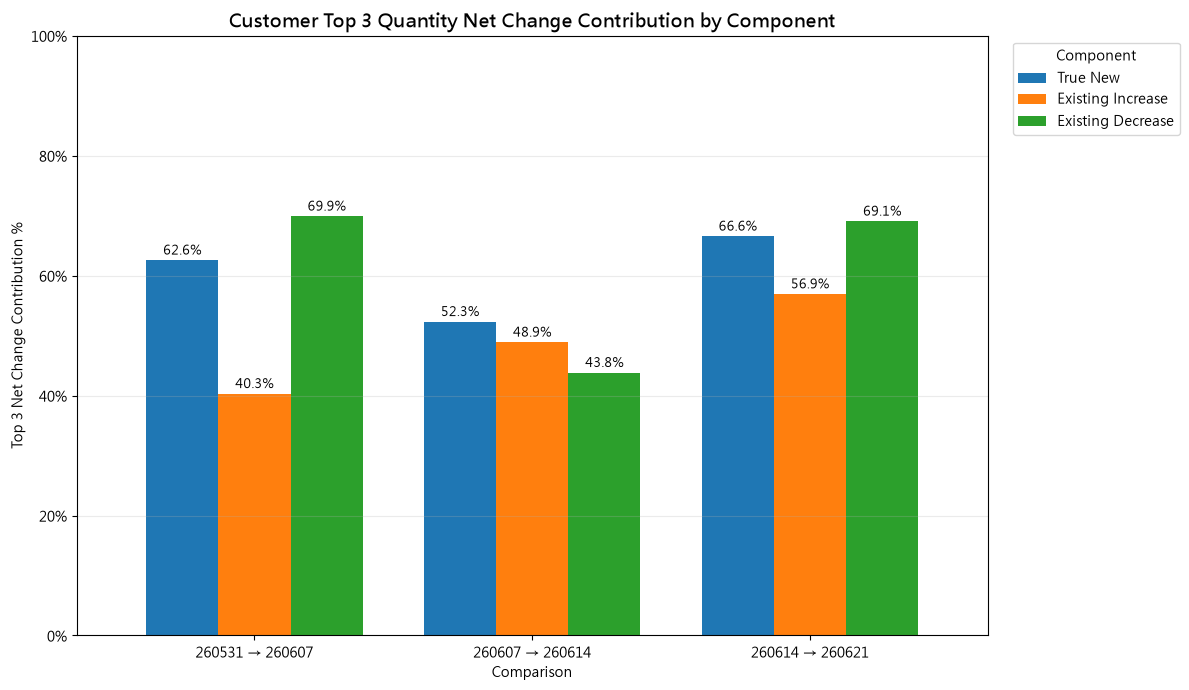

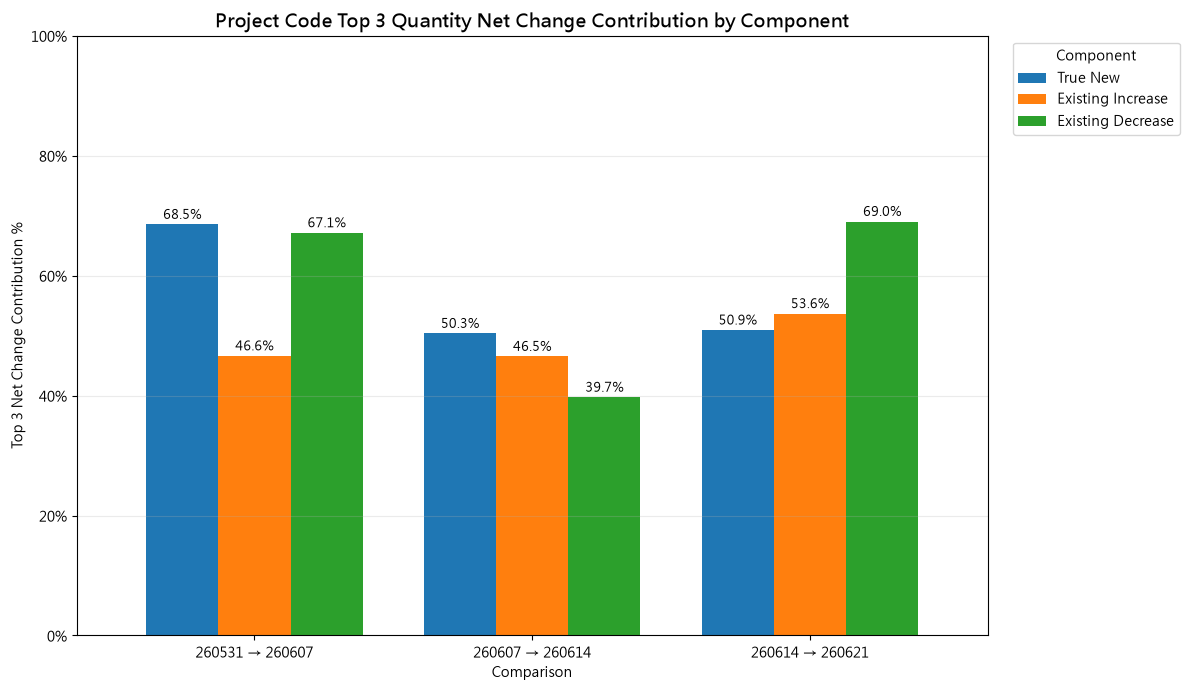

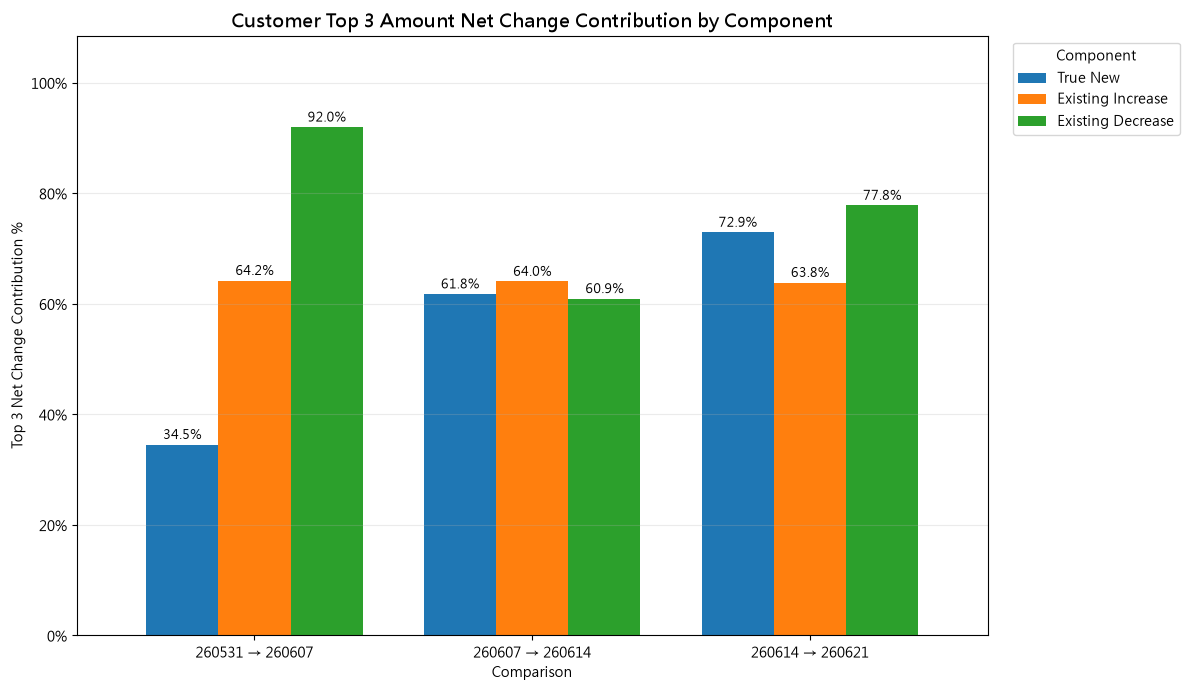

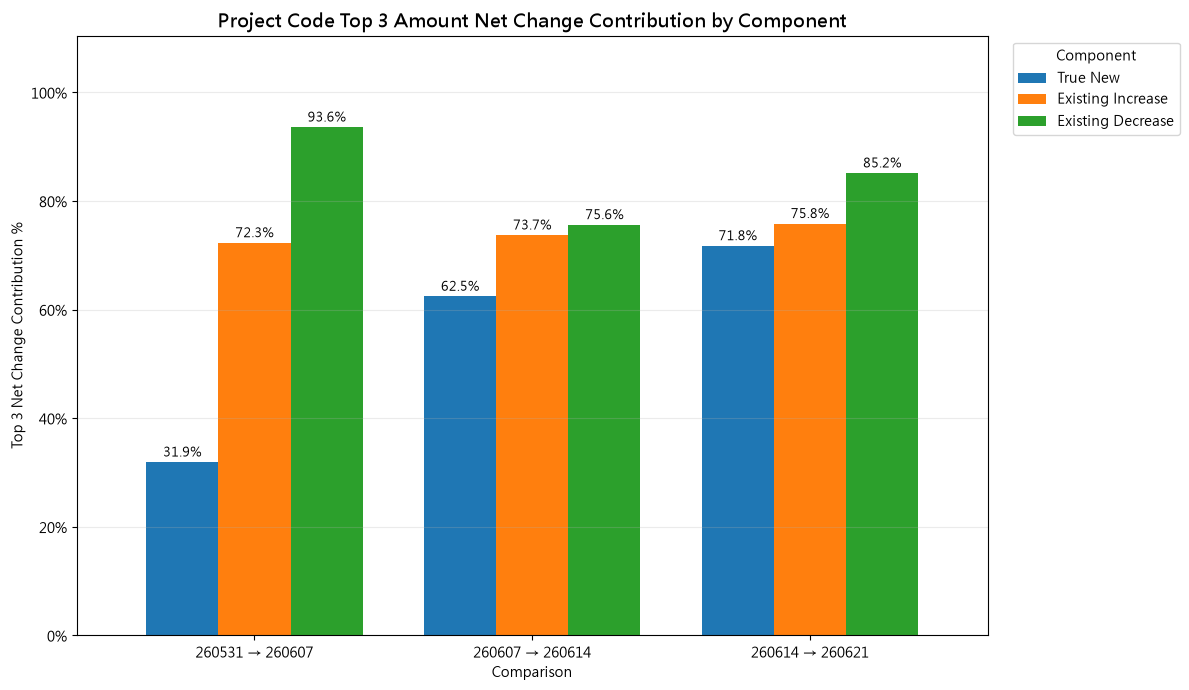

In [79]:

# ============================================================
# QUANTITY + AMOUNT LAYER 3
# TOP 10 / TOP 3 BY COMPONENT ONLY
#
# Components are NEVER mixed:
# 1. True New
# 2. Existing Increase
# 3. Existing Decrease
#
# Ranking:
# abs(Group Net Change), within the same Comparison + Component
#
# Contribution %:
# abs(Group Net Change)
# ÷ abs(Component Total Net Change)
#
# Therefore, every component uses its own net-change total
# as the denominator. No Total Movement and no "All" table.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================

COMPARISON_ORDER = [
    "260531 → 260607",
    "260607 → 260614",
    "260614 → 260621"
]

COMPONENT_ORDER = [
    "True New",
    "Existing Increase",
    "Existing Decrease"
]


# ============================================================
# CLEAN TEXT
# ============================================================

def clean_layer3_text_col(series):
    return (
        series.astype("string")
              .str.strip()
              .replace({
                  "": pd.NA,
                  "nan": pd.NA,
                  "NaN": pd.NA,
                  "None": pd.NA,
                  "<NA>": pd.NA,
                  "#N/A": pd.NA,
                  "N/A": pd.NA
                  # Do not replace real code "NA"
              })
    )


# ============================================================
# BUILD CUSTOMER / PROJECT CODE
# Prefer Data2; fall back to Data1.
# ============================================================

def build_layer3_group_column(df, group_col):

    group_column_map = {
        "CUSTOMER": (
            "PARTY_NAME_data1",
            "PARTY_NAME_data2"
        ),
        "PROJECT_CODE": (
            "PROJECT_CODE_data1",
            "PROJECT_CODE_data2"
        )
    }

    if group_col not in group_column_map:
        raise ValueError(
            "group_col must be 'CUSTOMER' or 'PROJECT_CODE'"
        )

    data1_col, data2_col = group_column_map[group_col]

    missing_cols = [
        col
        for col in [data1_col, data2_col]
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Missing group columns: {missing_cols}"
        )

    data1_value = clean_layer3_text_col(df[data1_col])
    data2_value = clean_layer3_text_col(df[data2_col])

    return data2_value.fillna(data1_value)


# ============================================================
# PREPARE QUANTITY BASE
#
# True New:
#   CHANGE_COMPONENT == "New Line in Data2"
#
# Existing Increase:
#   Split Line in Data2
#   Data1 Order Qty Increase
#
# Existing Decrease:
#   Data1 Order Qty Decrease
#   Missing from Data2
#
# Split is NOT included in True New.
# ============================================================

def prepare_quantity_layer3_base(quantity_df):

    df = quantity_df.copy()

    required_cols = [
        "Comparison",
        "LINE_ID",
        "CHANGE_COMPONENT",
        "QTY_CHANGE"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Quantity base missing columns: {missing_cols}"
        )

    df["QTY_CHANGE"] = pd.to_numeric(
        df["QTY_CHANGE"],
        errors="coerce"
    ).fillna(0)

    df["ANALYSIS_COMPONENT"] = np.select(
        [
            df["CHANGE_COMPONENT"].eq(
                "New Line in Data2"
            ),

            df["CHANGE_COMPONENT"].isin([
                "Split Line in Data2",
                "Data1 Order Qty Increase"
            ]),

            df["CHANGE_COMPONENT"].isin([
                "Data1 Order Qty Decrease",
                "Missing from Data2"
            ])
        ],
        COMPONENT_ORDER,
        default="Exclude"
    )

    df = df[
        df["ANALYSIS_COMPONENT"].isin(COMPONENT_ORDER)
    ].copy()

    # Preserve the real signed quantity change.
    # Do not convert to total movement.
    df["METRIC_CHANGE"] = df["QTY_CHANGE"]

    df["METRIC"] = "Quantity"

    return df


# ============================================================
# PREPARE AMOUNT BASE
#
# Uses the final AMOUNT_COMPONENT created in Amount Layer 2.
# ============================================================

def prepare_amount_layer3_base(amount_df):

    df = amount_df.copy()

    required_cols = [
        "Comparison",
        "LINE_ID",
        "AMOUNT_COMPONENT",
        "AMOUNT_CHANGE"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Amount base missing columns: {missing_cols}"
        )

    df["AMOUNT_CHANGE"] = pd.to_numeric(
        df["AMOUNT_CHANGE"],
        errors="coerce"
    ).fillna(0)

    component_map = {
        "True New Order Amount":
            "True New",

        "Existing Amount Increase":
            "Existing Increase",

        "Existing Amount Decrease":
            "Existing Decrease"
    }

    df["ANALYSIS_COMPONENT"] = (
        df["AMOUNT_COMPONENT"]
        .map(component_map)
    )

    df = df[
        df["ANALYSIS_COMPONENT"].isin(COMPONENT_ORDER)
    ].copy()

    # Preserve the real signed amount change.
    # Do not convert to total movement.
    df["METRIC_CHANGE"] = df["AMOUNT_CHANGE"]

    df["METRIC"] = "Amount"

    return df


# ============================================================
# GENERIC COMPONENT ANALYSIS
#
# IMPORTANT:
# Each Comparison + Component is calculated separately.
#
# Contribution % denominator:
# abs(sum of METRIC_CHANGE for the whole component)
#
# Example:
# Customer A Existing Decrease Contribution %
# =
# abs(Customer A Existing Decrease Net Change)
# /
# abs(All Existing Decrease Net Change)
# ============================================================

def build_component_top_driver_analysis(
    prepared_df,
    group_col,
    top_n=10,
    top_k=3
):

    df = prepared_df.copy()

    required_cols = [
        "Comparison",
        "LINE_ID",
        "ANALYSIS_COMPONENT",
        "METRIC_CHANGE"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Prepared base missing columns: {missing_cols}"
        )

    df[group_col] = build_layer3_group_column(
        df=df,
        group_col=group_col
    )

    df["METRIC_CHANGE"] = pd.to_numeric(
        df["METRIC_CHANGE"],
        errors="coerce"
    ).fillna(0)

    df = df[
        df[group_col].notna()
        &
        df["ANALYSIS_COMPONENT"].isin(COMPONENT_ORDER)
        &
        df["METRIC_CHANGE"].ne(0)
    ].copy()

    # --------------------------------------------------------
    # 1. Net change by group inside each component
    # --------------------------------------------------------
    group_summary_df = (
        df
        .groupby(
            [
                "Comparison",
                "ANALYSIS_COMPONENT",
                group_col
            ],
            as_index=False,
            dropna=False
        )
        .agg(
            LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            NET_CHANGE=(
                "METRIC_CHANGE",
                "sum"
            )
        )
    )

    group_summary_df[
        "ABS_NET_CHANGE"
    ] = (
        group_summary_df["NET_CHANGE"].abs()
    )

    # --------------------------------------------------------
    # 2. Component total net change
    #
    # This is the denominator requested by the user.
    # --------------------------------------------------------
    component_total_df = (
        df
        .groupby(
            [
                "Comparison",
                "ANALYSIS_COMPONENT"
            ],
            as_index=False
        )
        .agg(
            COMPONENT_LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            COMPONENT_NET_CHANGE=(
                "METRIC_CHANGE",
                "sum"
            )
        )
    )

    component_total_df[
        "ABS_COMPONENT_NET_CHANGE"
    ] = (
        component_total_df[
            "COMPONENT_NET_CHANGE"
        ].abs()
    )

    group_summary_df = (
        group_summary_df
        .merge(
            component_total_df,
            on=[
                "Comparison",
                "ANALYSIS_COMPONENT"
            ],
            how="left",
            validate="many_to_one"
        )
    )

    # --------------------------------------------------------
    # 3. Contribution %
    #
    # Group abs net change / component abs net total.
    # --------------------------------------------------------
    group_summary_df[
        "NET_CHANGE_CONTRIBUTION_%"
    ] = np.where(
        group_summary_df[
            "ABS_COMPONENT_NET_CHANGE"
        ] > 0,
        (
            group_summary_df[
                "ABS_NET_CHANGE"
            ]
            /
            group_summary_df[
                "ABS_COMPONENT_NET_CHANGE"
            ]
            *
            100
        ),
        np.nan
    )

    # --------------------------------------------------------
    # 4. Rank separately by component
    # --------------------------------------------------------
    group_summary_df = (
        group_summary_df
        .sort_values(
            [
                "Comparison",
                "ANALYSIS_COMPONENT",
                "ABS_NET_CHANGE",
                group_col
            ],
            ascending=[
                True,
                True,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    group_summary_df["RANK"] = (
        group_summary_df
        .groupby(
            [
                "Comparison",
                "ANALYSIS_COMPONENT"
            ]
        )
        .cumcount()
        + 1
    )

    top10_df = (
        group_summary_df[
            group_summary_df["RANK"] <= top_n
        ]
        .copy()
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # 5. Top 3 detail
    #
    # Keep the three actual groups, not only the aggregate.
    # --------------------------------------------------------
    top3_detail_df = (
        group_summary_df[
            group_summary_df["RANK"] <= top_k
        ]
        .copy()
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # 6. Top 3 concentration
    #
    # Sum of Top 3 abs group net change
    # / abs component total net change
    # --------------------------------------------------------
    top3_summary_df = (
        top3_detail_df
        .groupby(
            [
                "Comparison",
                "ANALYSIS_COMPONENT"
            ],
            as_index=False
        )
        .agg(
            TOP3_ABS_NET_CHANGE=(
                "ABS_NET_CHANGE",
                "sum"
            )
        )
    )

    top3_summary_df = (
        component_total_df
        .merge(
            top3_summary_df,
            on=[
                "Comparison",
                "ANALYSIS_COMPONENT"
            ],
            how="left",
            validate="one_to_one"
        )
    )

    top3_summary_df[
        "TOP3_ABS_NET_CHANGE"
    ] = (
        top3_summary_df[
            "TOP3_ABS_NET_CHANGE"
        ].fillna(0)
    )

    top3_summary_df[
        "TOP3_CONTRIBUTION_%"
    ] = np.where(
        top3_summary_df[
            "ABS_COMPONENT_NET_CHANGE"
        ] > 0,
        (
            top3_summary_df[
                "TOP3_ABS_NET_CHANGE"
            ]
            /
            top3_summary_df[
                "ABS_COMPONENT_NET_CHANGE"
            ]
            *
            100
        ),
        np.nan
    )

    top3_summary_df["GROUP_TYPE"] = group_col

    top3_summary_df["CONCENTRATION"] = np.select(
        [
            top3_summary_df[
                "TOP3_CONTRIBUTION_%"
            ] >= 70,

            top3_summary_df[
                "TOP3_CONTRIBUTION_%"
            ] >= 50
        ],
        [
            "Highly Concentrated",
            "Moderately Concentrated"
        ],
        default="Dispersed"
    )

    # --------------------------------------------------------
    # 7. Validation
    #
    # Contribution percentages across all groups in a
    # component should sum to 100% when all group net changes
    # have the same sign as the component.
    # --------------------------------------------------------
    contribution_check_df = (
        group_summary_df
        .groupby(
            [
                "Comparison",
                "ANALYSIS_COMPONENT"
            ],
            as_index=False
        )
        .agg(
            CONTRIBUTION_SUM=(
                "NET_CHANGE_CONTRIBUTION_%",
                "sum"
            ),

            GROUP_ABS_NET_SUM=(
                "ABS_NET_CHANGE",
                "sum"
            ),

            COMPONENT_NET_TOTAL=(
                "COMPONENT_NET_CHANGE",
                "first"
            )
        )
    )

    contribution_check_df[
        "CHECK"
    ] = np.where(
        (
            contribution_check_df[
                "CONTRIBUTION_SUM"
            ] - 100
        ).abs() <= 0.01,
        "PASS",
        "CHECK OFFSETTING GROUP NET CHANGES"
    )

    # --------------------------------------------------------
    # 8. Stable ordering
    # --------------------------------------------------------
    for output_df in [
        group_summary_df,
        top10_df,
        top3_detail_df,
        top3_summary_df,
        contribution_check_df
    ]:
        output_df["Comparison"] = pd.Categorical(
            output_df["Comparison"],
            categories=COMPARISON_ORDER,
            ordered=True
        )

        output_df["ANALYSIS_COMPONENT"] = pd.Categorical(
            output_df["ANALYSIS_COMPONENT"],
            categories=COMPONENT_ORDER,
            ordered=True
        )

    group_summary_df = (
        group_summary_df
        .sort_values(
            [
                "Comparison",
                "ANALYSIS_COMPONENT",
                "RANK"
            ]
        )
        .reset_index(drop=True)
    )

    top10_df = (
        top10_df
        .sort_values(
            [
                "Comparison",
                "ANALYSIS_COMPONENT",
                "RANK"
            ]
        )
        .reset_index(drop=True)
    )

    top3_detail_df = (
        top3_detail_df
        .sort_values(
            [
                "Comparison",
                "ANALYSIS_COMPONENT",
                "RANK"
            ]
        )
        .reset_index(drop=True)
    )

    top3_summary_df = (
        top3_summary_df
        .sort_values(
            [
                "Comparison",
                "ANALYSIS_COMPONENT"
            ]
        )
        .reset_index(drop=True)
    )

    contribution_check_df = (
        contribution_check_df
        .sort_values(
            [
                "Comparison",
                "ANALYSIS_COMPONENT"
            ]
        )
        .reset_index(drop=True)
    )

    return {
        "full_summary":
            group_summary_df,

        "top10":
            top10_df,

        "top3_detail":
            top3_detail_df,

        "top3_concentration":
            top3_summary_df,

        "component_total":
            component_total_df,

        "contribution_check":
            contribution_check_df
    }


# ============================================================
# DISPLAY TOP 10 / TOP 3
# ============================================================

def display_component_driver_tables(
    result,
    group_col,
    metric_label
):

    top10_cols = [
        "Comparison",
        "ANALYSIS_COMPONENT",
        "RANK",
        group_col,
        "LINE_COUNT",
        "NET_CHANGE",
        "COMPONENT_NET_CHANGE",
        "NET_CHANGE_CONTRIBUTION_%"
    ]

    top3_summary_cols = [
        "Comparison",
        "ANALYSIS_COMPONENT",
        "GROUP_TYPE",
        "COMPONENT_LINE_COUNT",
        "COMPONENT_NET_CHANGE",
        "TOP3_ABS_NET_CHANGE",
        "TOP3_CONTRIBUTION_%",
        "CONCENTRATION"
    ]

    for comparison in COMPARISON_ORDER:

        for component in COMPONENT_ORDER:

            temp_top10 = (
                result["top10"][
                    result["top10"]["Comparison"].eq(comparison)
                    &
                    result["top10"][
                        "ANALYSIS_COMPONENT"
                    ].eq(component)
                ]
                .copy()
            )

            if temp_top10.empty:
                continue

            print(
                f"\n{metric_label} | {group_col} Top 10 | "
                f"{comparison} | {component}"
            )

            display(
                temp_top10[top10_cols]
                .style
                .format({
                    "RANK":
                        "{:,.0f}",

                    "LINE_COUNT":
                        "{:,.0f}",

                    "NET_CHANGE":
                        "{:+,.2f}",

                    "COMPONENT_NET_CHANGE":
                        "{:+,.2f}",

                    "NET_CHANGE_CONTRIBUTION_%":
                        "{:.2f}%"
                })
                .hide(axis="index")
            )

    print(
        f"\n{metric_label} | {group_col} "
        f"Top 3 Concentration by Component"
    )

    display(
        result["top3_concentration"][
            top3_summary_cols
        ]
        .style
        .format({
            "COMPONENT_LINE_COUNT":
                "{:,.0f}",

            "COMPONENT_NET_CHANGE":
                "{:+,.2f}",

            "TOP3_ABS_NET_CHANGE":
                "{:,.2f}",

            "TOP3_CONTRIBUTION_%":
                "{:.2f}%"
        })
        .hide(axis="index")
    )


# ============================================================
# PLOT TOP 3 CONCENTRATION
#
# One chart per metric + group:
# - Quantity Customer
# - Quantity Project Code
# - Amount Customer
# - Amount Project Code
#
# Each Comparison contains:
# True New / Existing Increase / Existing Decrease
# ============================================================

def plot_top3_component_concentration(
    concentration_df,
    title
):

    chart_df = (
        concentration_df
        .pivot_table(
            index="Comparison",
            columns="ANALYSIS_COMPONENT",
            values="TOP3_CONTRIBUTION_%",
            aggfunc="first",
            fill_value=0,
            observed=False
        )
        .reindex(COMPARISON_ORDER)
    )

    for component in COMPONENT_ORDER:
        if component not in chart_df.columns:
            chart_df[component] = 0

    chart_df = chart_df[COMPONENT_ORDER]

    ax = chart_df.plot(
        kind="bar",
        figsize=(12, 7),
        width=0.78
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Comparison")
    ax.set_ylabel("Top 3 Net Change Contribution %")

    max_value = chart_df.max().max()

    if pd.isna(max_value):
        max_value = 0

    ax.set_ylim(
        0,
        max(100, max_value * 1.18)
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda value, _:
                f"{value:.0f}%"
        )
    )

    ax.set_xticklabels(
        chart_df.index,
        rotation=0
    )

    ax.legend(
        title="Component",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[
                (
                    f"{value:.1f}%"
                    if pd.notna(value) and value > 0
                    else ""
                )
                for value in container.datavalues
            ],
            padding=3,
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

    return chart_df


# ============================================================
# PREPARE BASES
# ============================================================

quantity_layer3_prepared_df = (
    prepare_quantity_layer3_base(
        quantity_df=
            non_hub_qty_bridge_base_df
    )
)

amount_layer3_prepared_df = (
    prepare_amount_layer3_base(
        amount_df=
            non_hub_amount_layer2_classified_df
    )
)


# ============================================================
# RUN FOUR ANALYSES
# ============================================================

analysis_configs = {
    "quantity_customer": {
        "prepared_df":
            quantity_layer3_prepared_df,

        "group_col":
            "CUSTOMER",

        "metric_label":
            "Quantity"
    },

    "quantity_project": {
        "prepared_df":
            quantity_layer3_prepared_df,

        "group_col":
            "PROJECT_CODE",

        "metric_label":
            "Quantity"
    },

    "amount_customer": {
        "prepared_df":
            amount_layer3_prepared_df,

        "group_col":
            "CUSTOMER",

        "metric_label":
            "Amount"
    },

    "amount_project": {
        "prepared_df":
            amount_layer3_prepared_df,

        "group_col":
            "PROJECT_CODE",

        "metric_label":
            "Amount"
    }
}

layer3_results = {}

for analysis_name, config in analysis_configs.items():

    layer3_results[analysis_name] = (
        build_component_top_driver_analysis(
            prepared_df=
                config["prepared_df"],

            group_col=
                config["group_col"],

            top_n=10,

            top_k=3
        )
    )


# ============================================================
# ASSIGN OUTPUT DATAFRAMES
# ============================================================

quantity_customer_result = (
    layer3_results["quantity_customer"]
)

quantity_project_result = (
    layer3_results["quantity_project"]
)

amount_customer_result = (
    layer3_results["amount_customer"]
)

amount_project_result = (
    layer3_results["amount_project"]
)


# Quantity Customer
quantity_customer_top10_df = (
    quantity_customer_result["top10"]
)

quantity_customer_top3_detail_df = (
    quantity_customer_result["top3_detail"]
)

quantity_customer_top3_concentration_df = (
    quantity_customer_result[
        "top3_concentration"
    ]
)


# Quantity Project Code
quantity_project_top10_df = (
    quantity_project_result["top10"]
)

quantity_project_top3_detail_df = (
    quantity_project_result["top3_detail"]
)

quantity_project_top3_concentration_df = (
    quantity_project_result[
        "top3_concentration"
    ]
)


# Amount Customer
amount_customer_top10_df = (
    amount_customer_result["top10"]
)

amount_customer_top3_detail_df = (
    amount_customer_result["top3_detail"]
)

amount_customer_top3_concentration_df = (
    amount_customer_result[
        "top3_concentration"
    ]
)


# Amount Project Code
amount_project_top10_df = (
    amount_project_result["top10"]
)

amount_project_top3_detail_df = (
    amount_project_result["top3_detail"]
)

amount_project_top3_concentration_df = (
    amount_project_result[
        "top3_concentration"
    ]
)


# ============================================================
# DISPLAY ALL TOP 10 + TOP 3 TABLES
# ============================================================

for analysis_name, config in analysis_configs.items():

    display_component_driver_tables(
        result=
            layer3_results[analysis_name],

        group_col=
            config["group_col"],

        metric_label=
            config["metric_label"]
    )


# ============================================================
# DISPLAY CONTRIBUTION CHECKS
# ============================================================

for analysis_name, config in analysis_configs.items():

    print(
        f"\nContribution Check | "
        f"{config['metric_label']} | "
        f"{config['group_col']}"
    )

    display(
        layer3_results[
            analysis_name
        ]["contribution_check"]
        .style
        .format({
            "CONTRIBUTION_SUM":
                "{:.2f}%",

            "GROUP_ABS_NET_SUM":
                "{:,.2f}",

            "COMPONENT_NET_TOTAL":
                "{:+,.2f}"
        })
        .hide(axis="index")
    )


# ============================================================
# DRAW FOUR TOP 3 CHARTS
# ============================================================

quantity_customer_top3_chart_df = (
    plot_top3_component_concentration(
        concentration_df=
            quantity_customer_top3_concentration_df,

        title=(
            "Customer Top 3 Quantity Net Change "
            "Contribution by Component"
        )
    )
)

quantity_project_top3_chart_df = (
    plot_top3_component_concentration(
        concentration_df=
            quantity_project_top3_concentration_df,

        title=(
            "Project Code Top 3 Quantity Net Change "
            "Contribution by Component"
        )
    )
)

amount_customer_top3_chart_df = (
    plot_top3_component_concentration(
        concentration_df=
            amount_customer_top3_concentration_df,

        title=(
            "Customer Top 3 Amount Net Change "
            "Contribution by Component"
        )
    )
)

amount_project_top3_chart_df = (
    plot_top3_component_concentration(
        concentration_df=
            amount_project_top3_concentration_df,

        title=(
            "Project Code Top 3 Amount Net Change "
            "Contribution by Component"
        )
    )
)


In [37]:
def clean_text_col(s):
    return (
        s.astype("string")
         .str.strip()
         .replace({
             "": pd.NA,
             "nan": pd.NA,
             "NaN": pd.NA,
             "None": pd.NA,
             "<NA>": pd.NA,
             "#N/A": pd.NA,
             "N/A": pd.NA
             # Do not replace real code "NA"
         })
    )

def build_amount_group_column(
    df,
    group_col
):
    if group_col == "CUSTOMER":

        data1_col = "PARTY_NAME_data1"
        data2_col = "PARTY_NAME_data2"

    elif group_col == "PROJECT_CODE":

        data1_col = "PROJECT_CODE_data1"
        data2_col = "PROJECT_CODE_data2"

    else:
        raise ValueError(
            "group_col must be "
            "'CUSTOMER' or 'PROJECT_CODE'"
        )

    missing_cols = [
        col
        for col in [
            data1_col,
            data2_col
        ]
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Missing required columns: {missing_cols}"
        )

    data1_value = clean_text_col(
        df[data1_col]
    )

    data2_value = clean_text_col(
        df[data2_col]
    )

    return (
        data2_value
        .fillna(data1_value)
    )


# ============================================================
# AMOUNT LAYER 3
# Customer / Project Code Top 10
#
# Rank:
# TOTAL_AMOUNT_MOVEMENT
#
# Contribution:
# Group Total Amount Movement
# ÷ Comparison Total Amount Movement
# ============================================================

def build_amount_layer3_by_group(
    amount_detail_df,
    group_col,
    top_n=10
):
    df = amount_detail_df.copy()

    # --------------------------------------------------------
    # 1. Required columns
    # --------------------------------------------------------
    required_cols = [
        "Comparison",
        "LINE_ID",
        "AMOUNT_CHANGE"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Missing required columns: {missing_cols}"
        )

    # --------------------------------------------------------
    # 2. Build Customer or Project Code
    # --------------------------------------------------------
    df[group_col] = build_amount_group_column(
        df=df,
        group_col=group_col
    )

    df = df[
        df[group_col].notna()
    ].copy()

    # --------------------------------------------------------
    # 3. Clean Amount Change
    # --------------------------------------------------------
    df["AMOUNT_CHANGE"] = pd.to_numeric(
        df["AMOUNT_CHANGE"],
        errors="coerce"
    ).fillna(0)

    # Only keep lines with actual Amount change
    df = df[
        df["AMOUNT_CHANGE"] != 0
    ].copy()

    # --------------------------------------------------------
    # 4. Build increase / decrease / movement
    # --------------------------------------------------------
    df["AMOUNT_INCREASE"] = np.where(
        df["AMOUNT_CHANGE"] > 0,
        df["AMOUNT_CHANGE"],
        0
    )

    # Keep decrease as negative
    df["AMOUNT_DECREASE"] = np.where(
        df["AMOUNT_CHANGE"] < 0,
        df["AMOUNT_CHANGE"],
        0
    )

    df["ABS_AMOUNT_CHANGE"] = (
        df["AMOUNT_CHANGE"]
        .abs()
    )

    df["AMOUNT_INCREASE_FLAG"] = (
        df["AMOUNT_CHANGE"] > 0
    ).astype(int)

    df["AMOUNT_DECREASE_FLAG"] = (
        df["AMOUNT_CHANGE"] < 0
    ).astype(int)

    # --------------------------------------------------------
    # 5. Group summary
    # --------------------------------------------------------
    group_summary_df = (
        df
        .groupby(
            [
                "Comparison",
                group_col
            ],
            as_index=False
        )
        .agg(
            AMOUNT_CHANGED_LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            AMOUNT_INCREASE_LINE_COUNT=(
                "AMOUNT_INCREASE_FLAG",
                "sum"
            ),

            AMOUNT_DECREASE_LINE_COUNT=(
                "AMOUNT_DECREASE_FLAG",
                "sum"
            ),

            TOTAL_AMOUNT_INCREASE=(
                "AMOUNT_INCREASE",
                "sum"
            ),

            TOTAL_AMOUNT_DECREASE=(
                "AMOUNT_DECREASE",
                "sum"
            ),

            NET_AMOUNT_CHANGE=(
                "AMOUNT_CHANGE",
                "sum"
            ),

            TOTAL_AMOUNT_MOVEMENT=(
                "ABS_AMOUNT_CHANGE",
                "sum"
            )
        )
    )

    # --------------------------------------------------------
    # 6. Comparison total movement
    #
    # Denominator must come from the same filtered base:
    # all non-zero Amount changes with a valid group value
    # --------------------------------------------------------
    comparison_total_df = (
        df
        .groupby(
            "Comparison",
            as_index=False
        )
        .agg(
            OVERALL_AMOUNT_INCREASE=(
                "AMOUNT_INCREASE",
                "sum"
            ),

            OVERALL_AMOUNT_DECREASE=(
                "AMOUNT_DECREASE",
                "sum"
            ),

            OVERALL_NET_AMOUNT_CHANGE=(
                "AMOUNT_CHANGE",
                "sum"
            ),

            OVERALL_TOTAL_AMOUNT_MOVEMENT=(
                "ABS_AMOUNT_CHANGE",
                "sum"
            )
        )
    )

    group_summary_df = (
        group_summary_df
        .merge(
            comparison_total_df,
            on="Comparison",
            how="left"
        )
    )

    # --------------------------------------------------------
    # 7. Movement Contribution %
    # --------------------------------------------------------
    group_summary_df[
        "AMOUNT_MOVEMENT_CONTRIBUTION_%"
    ] = np.where(
        group_summary_df[
            "OVERALL_TOTAL_AMOUNT_MOVEMENT"
        ] > 0,
        (
            group_summary_df[
                "TOTAL_AMOUNT_MOVEMENT"
            ]
            /
            group_summary_df[
                "OVERALL_TOTAL_AMOUNT_MOVEMENT"
            ]
            *
            100
        ),
        0
    )

    # --------------------------------------------------------
    # 8. Main direction
    # --------------------------------------------------------
    group_summary_df[
        "MAIN_AMOUNT_DIRECTION"
    ] = np.select(
        [
            group_summary_df[
                "NET_AMOUNT_CHANGE"
            ] > 0,

            group_summary_df[
                "NET_AMOUNT_CHANGE"
            ] < 0
        ],
        [
            "Net Amount Increase",
            "Net Amount Decrease"
        ],
        default="Net Zero / Mixed"
    )

    # --------------------------------------------------------
    # 9. Rank by Total Amount Movement
    # --------------------------------------------------------
    group_summary_df = (
        group_summary_df
        .sort_values(
            [
                "Comparison",
                "TOTAL_AMOUNT_MOVEMENT",
                group_col
            ],
            ascending=[
                True,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    group_summary_df["RANK"] = (
        group_summary_df
        .groupby("Comparison")
        .cumcount()
        + 1
    )

    # --------------------------------------------------------
    # 10. Top N
    # --------------------------------------------------------
    top_n_df = (
        group_summary_df[
            group_summary_df["RANK"] <= top_n
        ]
        .copy()
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # 11. Top 3 concentration
    # --------------------------------------------------------
    top3_df = (
        group_summary_df[
            group_summary_df["RANK"] <= 3
        ]
        .groupby(
            "Comparison",
            as_index=False
        )
        .agg(
            TOP3_TOTAL_AMOUNT_MOVEMENT=(
                "TOTAL_AMOUNT_MOVEMENT",
                "sum"
            ),

            TOP3_MOVEMENT_CONTRIBUTION=(
                "AMOUNT_MOVEMENT_CONTRIBUTION_%",
                "sum"
            )
        )
    )

    concentration_df = (
        comparison_total_df
        .merge(
            top3_df,
            on="Comparison",
            how="left"
        )
    )

    concentration_df[
        "TOP3_TOTAL_AMOUNT_MOVEMENT"
    ] = (
        concentration_df[
            "TOP3_TOTAL_AMOUNT_MOVEMENT"
        ]
        .fillna(0)
    )

    concentration_df[
        "TOP3_MOVEMENT_CONTRIBUTION"
    ] = (
        concentration_df[
            "TOP3_MOVEMENT_CONTRIBUTION"
        ]
        .fillna(0)
    )

    concentration_df["GROUP_TYPE"] = group_col

    concentration_df["CONCENTRATION"] = np.select(
        [
            concentration_df[
                "TOP3_MOVEMENT_CONTRIBUTION"
            ] >= 70,

            concentration_df[
                "TOP3_MOVEMENT_CONTRIBUTION"
            ] >= 50
        ],
        [
            "Highly Concentrated",
            "Moderately Concentrated"
        ],
        default="Dispersed"
    )

    return {
        "full_summary":
            group_summary_df,

        "top10":
            top_n_df,

        "comparison_summary":
            comparison_total_df,

        "top3_concentration":
            concentration_df
    }

In [ ]:
# ============================================================
# RUN CUSTOMER AMOUNT LAYER 3
# ============================================================

customer_amount_layer3_result = (
    build_amount_layer3_by_group(
        amount_detail_df=
            non_hub_amount_layer2_classified_df,

        group_col="CUSTOMER",

        top_n=10
    )
)

customer_amount_layer3_full_df = (
    customer_amount_layer3_result[
        "full_summary"
    ]
)

customer_amount_layer3_top10_df = (
    customer_amount_layer3_result[
        "top10"
    ]
)

customer_amount_layer3_summary_df = (
    customer_amount_layer3_result[
        "comparison_summary"
    ]
)

customer_amount_layer3_concentration_df = (
    customer_amount_layer3_result[
        "top3_concentration"
    ]
)

# ============================================================
# RUN PROJECT CODE AMOUNT LAYER 3
# ============================================================

project_amount_layer3_result = (
    build_amount_layer3_by_group(
        amount_detail_df=
            non_hub_amount_layer2_classified_df,

        group_col="PROJECT_CODE",

        top_n=10
    )
)

project_amount_layer3_full_df = (
    project_amount_layer3_result[
        "full_summary"
    ]
)

project_amount_layer3_top10_df = (
    project_amount_layer3_result[
        "top10"
    ]
)

project_amount_layer3_summary_df = (
    project_amount_layer3_result[
        "comparison_summary"
    ]
)

project_amount_layer3_concentration_df = (
    project_amount_layer3_result[
        "top3_concentration"
    ]
)

# ============================================================
# DISPLAY CUSTOMER TOP 10
# ============================================================

customer_display_cols = [
    "Comparison",
    "RANK",
    "CUSTOMER",
    "AMOUNT_CHANGED_LINE_COUNT",
    "AMOUNT_INCREASE_LINE_COUNT",
    "AMOUNT_DECREASE_LINE_COUNT",
    "TOTAL_AMOUNT_INCREASE",
    "TOTAL_AMOUNT_DECREASE",
    "NET_AMOUNT_CHANGE",
    "TOTAL_AMOUNT_MOVEMENT",
    "AMOUNT_MOVEMENT_CONTRIBUTION_%",
    "MAIN_AMOUNT_DIRECTION"
]

for comparison in (
    customer_amount_layer3_top10_df[
        "Comparison"
    ]
    .dropna()
    .unique()
):

    print(
        f"\nCustomer Top 10 Amount Movement: "
        f"{comparison}"
    )

    temp = (
        customer_amount_layer3_top10_df[
            customer_amount_layer3_top10_df[
                "Comparison"
            ].eq(comparison)
        ]
        .copy()
    )

    display(
        temp[
            customer_display_cols
        ]
        .style
        .format({
            "RANK":
                "{:,.0f}",

            "AMOUNT_CHANGED_LINE_COUNT":
                "{:,.0f}",

            "AMOUNT_INCREASE_LINE_COUNT":
                "{:,.0f}",

            "AMOUNT_DECREASE_LINE_COUNT":
                "{:,.0f}",

            "TOTAL_AMOUNT_INCREASE":
                "{:+,.0f}",

            "TOTAL_AMOUNT_DECREASE":
                "{:+,.0f}",

            "NET_AMOUNT_CHANGE":
                "{:+,.0f}",

            "TOTAL_AMOUNT_MOVEMENT":
                "{:,.0f}",

            "AMOUNT_MOVEMENT_CONTRIBUTION_%":
                "{:.2f}%"
        })
        .hide(axis="index")
    )

# ============================================================
# DISPLAY PROJECT CODE TOP 10
# ============================================================

project_display_cols = [
    "Comparison",
    "RANK",
    "PROJECT_CODE",
    "AMOUNT_CHANGED_LINE_COUNT",
    "AMOUNT_INCREASE_LINE_COUNT",
    "AMOUNT_DECREASE_LINE_COUNT",
    "TOTAL_AMOUNT_INCREASE",
    "TOTAL_AMOUNT_DECREASE",
    "NET_AMOUNT_CHANGE",
    "TOTAL_AMOUNT_MOVEMENT",
    "AMOUNT_MOVEMENT_CONTRIBUTION_%",
    "MAIN_AMOUNT_DIRECTION"
]

for comparison in (
    project_amount_layer3_top10_df[
        "Comparison"
    ]
    .dropna()
    .unique()
):

    print(
        f"\nProject Code Top 10 Amount Movement: "
        f"{comparison}"
    )

    temp = (
        project_amount_layer3_top10_df[
            project_amount_layer3_top10_df[
                "Comparison"
            ].eq(comparison)
        ]
        .copy()
    )

    display(
        temp[
            project_display_cols
        ]
        .style
        .format({
            "RANK":
                "{:,.0f}",

            "AMOUNT_CHANGED_LINE_COUNT":
                "{:,.0f}",

            "AMOUNT_INCREASE_LINE_COUNT":
                "{:,.0f}",

            "AMOUNT_DECREASE_LINE_COUNT":
                "{:,.0f}",

            "TOTAL_AMOUNT_INCREASE":
                "{:+,.0f}",

            "TOTAL_AMOUNT_DECREASE":
                "{:+,.0f}",

            "NET_AMOUNT_CHANGE":
                "{:+,.0f}",

            "TOTAL_AMOUNT_MOVEMENT":
                "{:,.0f}",

            "AMOUNT_MOVEMENT_CONTRIBUTION_%":
                "{:.2f}%"
        })
        .hide(axis="index")
    )

# ============================================================
# DISPLAY TOP 3 CONCENTRATION
# ============================================================

print("Customer Amount Top 3 Concentration")

display(
    customer_amount_layer3_concentration_df
    .style
    .format({
        "OVERALL_AMOUNT_INCREASE":
            "{:+,.0f}",

        "OVERALL_AMOUNT_DECREASE":
            "{:+,.0f}",

        "OVERALL_NET_AMOUNT_CHANGE":
            "{:+,.0f}",

        "OVERALL_TOTAL_AMOUNT_MOVEMENT":
            "{:,.0f}",

        "TOP3_TOTAL_AMOUNT_MOVEMENT":
            "{:,.0f}",

        "TOP3_MOVEMENT_CONTRIBUTION":
            "{:.2f}%"
    })
    .hide(axis="index")
)


print("\nProject Code Amount Top 3 Concentration")

display(
    project_amount_layer3_concentration_df
    .style
    .format({
        "OVERALL_AMOUNT_INCREASE":
            "{:+,.0f}",

        "OVERALL_AMOUNT_DECREASE":
            "{:+,.0f}",

        "OVERALL_NET_AMOUNT_CHANGE":
            "{:+,.0f}",

        "OVERALL_TOTAL_AMOUNT_MOVEMENT":
            "{:,.0f}",

        "TOP3_TOTAL_AMOUNT_MOVEMENT":
            "{:,.0f}",

        "TOP3_MOVEMENT_CONTRIBUTION":
            "{:.2f}%"
    })
    .hide(axis="index")
)


Customer Top 10 Amount Movement: 260531 → 260607


Comparison,RANK,CUSTOMER,AMOUNT_CHANGED_LINE_COUNT,AMOUNT_INCREASE_LINE_COUNT,AMOUNT_DECREASE_LINE_COUNT,TOTAL_AMOUNT_INCREASE,TOTAL_AMOUNT_DECREASE,NET_AMOUNT_CHANGE,TOTAL_AMOUNT_MOVEMENT,AMOUNT_MOVEMENT_CONTRIBUTION_%,MAIN_AMOUNT_DIRECTION
260531 → 260607,1,Wiwynn International corporation,104,65,39,"+5,971,728","-66,255,159","-60,283,431","72,226,887",64.09%,Net Amount Decrease
260531 → 260607,2,仁寶電子科技(昆山)有限公司,37,21,16,"+6,353,491","-6,353,386",+105,"12,706,878",11.28%,Net Amount Increase
260531 → 260607,3,Wistron InfoComm Technology(America) Corporation,40,40,0,"+3,618,972",+0,"+3,618,972","3,618,972",3.21%,Net Amount Increase
260531 → 260607,4,雲尖信息技術股份有限公司,228,216,12,"+1,514,337","-846,130","+668,207","2,360,467",2.09%,Net Amount Increase
260531 → 260607,5,智邦科技股份有限公司,40,21,19,"+1,078,203","-1,076,882","+1,321","2,155,085",1.91%,Net Amount Increase
260531 → 260607,6,Wistron Corporation,17,4,13,"+9,267","-1,899,492","-1,890,225","1,908,759",1.69%,Net Amount Decrease
260531 → 260607,7,Hyve Solutions Corporation,12,9,3,"+788,900","-779,341","+9,559","1,568,241",1.39%,Net Amount Increase
260531 → 260607,8,華碩電腦股份有限公司,6,4,2,"+762,900","-762,900",-0,"1,525,799",1.35%,Net Amount Decrease
260531 → 260607,9,和碩聯合科技股份有限公司,22,14,8,"+637,750","-519,204","+118,546","1,156,954",1.03%,Net Amount Increase
260531 → 260607,10,Lenovo Global Technologies Ireland International Limited,5,5,0,"+1,142,139",+0,"+1,142,139","1,142,139",1.01%,Net Amount Increase



Customer Top 10 Amount Movement: 260607 → 260614


Comparison,RANK,CUSTOMER,AMOUNT_CHANGED_LINE_COUNT,AMOUNT_INCREASE_LINE_COUNT,AMOUNT_DECREASE_LINE_COUNT,TOTAL_AMOUNT_INCREASE,TOTAL_AMOUNT_DECREASE,NET_AMOUNT_CHANGE,TOTAL_AMOUNT_MOVEMENT,AMOUNT_MOVEMENT_CONTRIBUTION_%,MAIN_AMOUNT_DIRECTION
260607 → 260614,1,Wiwynn International corporation,98,77,21,"+17,240,860","-8,197,401","+9,043,459","25,438,261",46.77%,Net Amount Increase
260607 → 260614,2,WIWYNN TECHNOLOGY SERVICE MALAYSIA SDN. BHD.,24,16,8,"+1,443,019","-1,441,727","+1,292","2,884,746",5.30%,Net Amount Increase
260607 → 260614,3,Wistron Corporation,40,39,1,"+2,607,326","-37,773","+2,569,553","2,645,100",4.86%,Net Amount Increase
260607 → 260614,4,智邦科技股份有限公司,26,15,11,"+1,150,883","-1,147,439","+3,444","2,298,321",4.23%,Net Amount Increase
260607 → 260614,5,曙光信息產業股份有限公司,177,138,39,"+1,894,757","-380,612","+1,514,145","2,275,369",4.18%,Net Amount Increase
260607 → 260614,6,Jabil Inc. (Kentucky),16,14,2,"+1,108,450","-1,069,236","+39,214","2,177,685",4.00%,Net Amount Increase
260607 → 260614,7,廣達電腦股份有限公司,121,101,20,"+976,237","-618,838","+357,399","1,595,075",2.93%,Net Amount Increase
260607 → 260614,8,Hyve Solutions (Taiwan) Corporation,16,15,1,"+1,134,212","-193,306","+940,906","1,327,518",2.44%,Net Amount Increase
260607 → 260614,9,和碩聯合科技股份有限公司,21,19,2,"+816,494","-422,634","+393,860","1,239,128",2.28%,Net Amount Increase
260607 → 260614,10,上海順詮科技有限公司,39,32,7,"+740,015","-387,353","+352,662","1,127,367",2.07%,Net Amount Increase



Customer Top 10 Amount Movement: 260614 → 260621


...

Comparison,RANK,PROJECT_CODE,AMOUNT_CHANGED_LINE_COUNT,AMOUNT_INCREASE_LINE_COUNT,AMOUNT_DECREASE_LINE_COUNT,TOTAL_AMOUNT_INCREASE,TOTAL_AMOUNT_DECREASE,NET_AMOUNT_CHANGE,TOTAL_AMOUNT_MOVEMENT,AMOUNT_MOVEMENT_CONTRIBUTION_%,MAIN_AMOUNT_DIRECTION
260614 → 260621,1,T3 PDS,218,177,41,"+35,112,280","-21,130,295","+13,981,985","56,242,574",59.57%,Net Amount Increase
260614 → 260621,2,MGX_1U_GB300,70,57,13,"+7,455,396","-823,079","+6,632,317","8,278,475",8.77%,Net Amount Increase
260614 → 260621,3,EVE C3,54,52,2,"+3,776,737","-8,792","+3,767,945","3,785,529",4.01%,Net Amount Increase
260614 → 260621,4,ALESIA,31,14,17,"+1,600,168","-1,600,168",+0,"3,200,336",3.39%,Net Amount Increase
260614 → 260621,5,EVE 2U,39,38,1,"+2,842,705","-7,358","+2,835,347","2,850,063",3.02%,Net Amount Increase
260614 → 260621,6,AWS VR IXZ PROJECT,17,16,1,"+2,771,550",-240,"+2,771,310","2,771,790",2.94%,Net Amount Increase
260614 → 260621,7,MGX_1U_VERA RUBIN,22,19,3,"+2,456,732","-7,768","+2,448,964","2,464,500",2.61%,Net Amount Increase
260614 → 260621,8,RM241,15,14,1,"+1,105,309","-949,000","+156,309","2,054,309",2.18%,Net Amount Increase
260614 → 260621,9,RM156,24,19,5,"+1,574,943","-223,655","+1,351,288","1,798,599",1.90%,Net Amount Increase
260614 → 260621,10,GOSHIN,52,42,10,"+873,160","-258,480","+614,679","1,131,640",1.20%,Net Amount Increase


Customer Amount Top 3 Concentration


Comparison,OVERALL_AMOUNT_INCREASE,OVERALL_AMOUNT_DECREASE,OVERALL_NET_AMOUNT_CHANGE,OVERALL_TOTAL_AMOUNT_MOVEMENT,TOP3_TOTAL_AMOUNT_MOVEMENT,TOP3_MOVEMENT_CONTRIBUTION,GROUP_TYPE,CONCENTRATION
260531 → 260607,"+31,664,826","-81,025,441","-49,360,615","112,690,268","88,552,737",78.58%,CUSTOMER,Highly Concentrated
260607 → 260614,"+36,690,533","-17,704,681","+18,985,852","54,395,215","30,968,106",56.93%,CUSTOMER,Moderately Concentrated
260614 → 260621,"+66,611,054","-27,806,395","+38,804,659","94,417,449","59,620,666",63.15%,CUSTOMER,Moderately Concentrated



Project Code Amount Top 3 Concentration


Comparison,OVERALL_AMOUNT_INCREASE,OVERALL_AMOUNT_DECREASE,OVERALL_NET_AMOUNT_CHANGE,OVERALL_TOTAL_AMOUNT_MOVEMENT,TOP3_TOTAL_AMOUNT_MOVEMENT,TOP3_MOVEMENT_CONTRIBUTION,GROUP_TYPE,CONCENTRATION
260531 → 260607,"+31,664,826","-81,025,441","-49,360,615","112,690,268","94,558,372",83.91%,PROJECT_CODE,Highly Concentrated
260607 → 260614,"+36,690,533","-17,704,681","+18,985,852","54,395,215","36,330,491",66.79%,PROJECT_CODE,Moderately Concentrated
260614 → 260621,"+66,611,054","-27,806,395","+38,804,659","94,417,449","68,306,578",72.35%,PROJECT_CODE,Highly Concentrated


In [38]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


COMPARISON_ORDER = [
    "260531 → 260607",
    "260607 → 260614",
    "260614 → 260621"
]

COMPONENT_ORDER = [
    "True New",
    "Existing Increase",
    "Existing Decrease",
    "All"
]

CHART_COMPONENT_ORDER = [
    "True New",
    "Existing Increase",
    "Existing Decrease"
]


def clean_text_col(s):
    return (
        s.astype("string")
         .str.strip()
         .replace({
             "": pd.NA,
             "nan": pd.NA,
             "NaN": pd.NA,
             "None": pd.NA,
             "<NA>": pd.NA,
             "#N/A": pd.NA,
             "N/A": pd.NA
         })
    )

def build_layer3_group_column(
    df,
    group_col
):
    if group_col == "CUSTOMER":

        data1_col = "PARTY_NAME_data1"
        data2_col = "PARTY_NAME_data2"

    elif group_col == "PROJECT_CODE":

        data1_col = "PROJECT_CODE_data1"
        data2_col = "PROJECT_CODE_data2"

    else:
        raise ValueError(
            "group_col must be "
            "'CUSTOMER' or 'PROJECT_CODE'"
        )

    missing_cols = [
        col
        for col in [
            data1_col,
            data2_col
        ]
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Missing group columns: {missing_cols}"
        )

    data1_value = clean_text_col(
        df[data1_col]
    )

    data2_value = clean_text_col(
        df[data2_col]
    )

    return (
        data2_value
        .fillna(data1_value)
    )

def prepare_quantity_layer3_base(
    quantity_df
):
    df = quantity_df.copy()

    required_cols = [
        "Comparison",
        "LINE_ID",
        "CHANGE_COMPONENT",
        "QTY_CHANGE"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Quantity base missing columns: {missing_cols}"
        )

    df["QTY_CHANGE"] = pd.to_numeric(
        df["QTY_CHANGE"],
        errors="coerce"
    ).fillna(0)

    df["ANALYSIS_COMPONENT"] = np.select(
        [
            df["CHANGE_COMPONENT"].eq(
                "New Line in Data2"
            ),

            df["CHANGE_COMPONENT"].isin([
                "Split Line in Data2",
                "Data1 Order Qty Increase"
            ]),

            df["CHANGE_COMPONENT"].isin([
                "Data1 Order Qty Decrease",
                "Missing from Data2"
            ])
        ],
        [
            "True New",
            "Existing Increase",
            "Existing Decrease"
        ],
        default="Exclude"
    )

    df = df[
        df["ANALYSIS_COMPONENT"].isin(
            CHART_COMPONENT_ORDER
        )
    ].copy()

    # Force business-consistent signs
    df["METRIC_CHANGE"] = np.select(
        [
            df["ANALYSIS_COMPONENT"].eq(
                "True New"
            ),

            df["ANALYSIS_COMPONENT"].eq(
                "Existing Increase"
            ),

            df["ANALYSIS_COMPONENT"].eq(
                "Existing Decrease"
            )
        ],
        [
            df["QTY_CHANGE"].abs(),
            df["QTY_CHANGE"].abs(),
            -df["QTY_CHANGE"].abs()
        ],
        default=0
    )

    df["METRIC"] = "Quantity"

    return df
def prepare_amount_layer3_base(
    amount_df
):
    df = amount_df.copy()

    required_cols = [
        "Comparison",
        "LINE_ID",
        "AMOUNT_COMPONENT",
        "AMOUNT_CHANGE"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Amount base missing columns: {missing_cols}"
        )

    df["AMOUNT_CHANGE"] = pd.to_numeric(
        df["AMOUNT_CHANGE"],
        errors="coerce"
    ).fillna(0)

    component_map = {
        "True New Order Amount":
            "True New",

        "Existing Amount Increase":
            "Existing Increase",

        "Existing Amount Decrease":
            "Existing Decrease"
    }

    df["ANALYSIS_COMPONENT"] = (
        df["AMOUNT_COMPONENT"]
        .map(component_map)
    )

    df = df[
        df["ANALYSIS_COMPONENT"].isin(
            CHART_COMPONENT_ORDER
        )
    ].copy()

    # Force business-consistent signs
    df["METRIC_CHANGE"] = np.select(
        [
            df["ANALYSIS_COMPONENT"].eq(
                "True New"
            ),

            df["ANALYSIS_COMPONENT"].eq(
                "Existing Increase"
            ),

            df["ANALYSIS_COMPONENT"].eq(
                "Existing Decrease"
            )
        ],
        [
            df["AMOUNT_CHANGE"].abs(),
            df["AMOUNT_CHANGE"].abs(),
            -df["AMOUNT_CHANGE"].abs()
        ],
        default=0
    )

    df["METRIC"] = "Amount"

    return df

def build_layer3_analysis(
    prepared_df,
    group_col,
    top_n=10
):
    df = prepared_df.copy()

    required_cols = [
        "Comparison",
        "LINE_ID",
        "ANALYSIS_COMPONENT",
        "METRIC_CHANGE"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Prepared base missing columns: "
            f"{missing_cols}"
        )

    df[group_col] = build_layer3_group_column(
        df=df,
        group_col=group_col
    )

    df = df[
        df[group_col].notna()
    ].copy()

    df = df[
        df["METRIC_CHANGE"] != 0
    ].copy()

    df["ABS_METRIC_CHANGE"] = (
        df["METRIC_CHANGE"]
        .abs()
    )

    component_group_df = (
        df
        .groupby(
            [
                "Comparison",
                "ANALYSIS_COMPONENT",
                group_col
            ],
            as_index=False
        )
        .agg(
            LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            NET_CHANGE=(
                "METRIC_CHANGE",
                "sum"
            ),

            TOTAL_MOVEMENT=(
                "ABS_METRIC_CHANGE",
                "sum"
            )
        )
    )

    component_total_df = (
        df
        .groupby(
            [
                "Comparison",
                "ANALYSIS_COMPONENT"
            ],
            as_index=False
        )
        .agg(
            COMPONENT_LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            COMPONENT_NET_CHANGE=(
                "METRIC_CHANGE",
                "sum"
            ),

            COMPONENT_TOTAL_MOVEMENT=(
                "ABS_METRIC_CHANGE",
                "sum"
            )
        )
    )

    component_group_df = (
        component_group_df
        .merge(
            component_total_df,
            on=[
                "Comparison",
                "ANALYSIS_COMPONENT"
            ],
            how="left",
            validate="many_to_one"
        )
    )

    component_group_df[
        "CONTRIBUTION_%"
    ] = np.where(
        component_group_df[
            "COMPONENT_TOTAL_MOVEMENT"
        ] > 0,
        (
            component_group_df[
                "TOTAL_MOVEMENT"
            ]
            /
            component_group_df[
                "COMPONENT_TOTAL_MOVEMENT"
            ]
            *
            100
        ),
        0
    )

    component_group_df = (
        component_group_df
        .sort_values(
            [
                "Comparison",
                "ANALYSIS_COMPONENT",
                "TOTAL_MOVEMENT",
                group_col
            ],
            ascending=[
                True,
                True,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    component_group_df["RANK"] = (
        component_group_df
        .groupby(
            [
                "Comparison",
                "ANALYSIS_COMPONENT"
            ]
        )
        .cumcount()
        + 1
    )

    component_top10_df = (
        component_group_df[
            component_group_df["RANK"] <= top_n
        ]
        .copy()
        .reset_index(drop=True)
    )

    component_top3_df = (
        component_group_df[
            component_group_df["RANK"] <= 3
        ]
        .groupby(
            [
                "Comparison",
                "ANALYSIS_COMPONENT"
            ],
            as_index=False
        )
        .agg(
            TOP3_TOTAL_MOVEMENT=(
                "TOTAL_MOVEMENT",
                "sum"
            ),

            TOP3_CONTRIBUTION=(
                "CONTRIBUTION_%",
                "sum"
            )
        )
        .rename(
            columns={
                "TOP3_CONTRIBUTION":
                    "TOP3_CONTRIBUTION_%"
            }
        )
    )

    component_concentration_df = (
        component_total_df
        .merge(
            component_top3_df,
            on=[
                "Comparison",
                "ANALYSIS_COMPONENT"
            ],
            how="left",
            validate="one_to_one"
        )
    )

    component_concentration_df[
        "TOP3_TOTAL_MOVEMENT"
    ] = (
        component_concentration_df[
            "TOP3_TOTAL_MOVEMENT"
        ]
        .fillna(0)
    )

    component_concentration_df[
        "TOP3_CONTRIBUTION_%"
    ] = (
        component_concentration_df[
            "TOP3_CONTRIBUTION_%"
        ]
        .fillna(0)
    )

    component_concentration_df[
        "GROUP_TYPE"
    ] = group_col

    all_group_df = (
        df
        .groupby(
            [
                "Comparison",
                group_col
            ],
            as_index=False
        )
        .agg(
            LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            NET_CHANGE=(
                "METRIC_CHANGE",
                "sum"
            ),

            TOTAL_MOVEMENT=(
                "ABS_METRIC_CHANGE",
                "sum"
            )
        )
    )

    all_component_pivot_df = (
        df
        .pivot_table(
            index=[
                "Comparison",
                group_col
            ],
            columns="ANALYSIS_COMPONENT",
            values="ABS_METRIC_CHANGE",
            aggfunc="sum",
            fill_value=0
        )
        .reset_index()
    )

    for component in CHART_COMPONENT_ORDER:

        if component not in (
            all_component_pivot_df.columns
        ):
            all_component_pivot_df[
                component
            ] = 0

    all_component_pivot_df = (
        all_component_pivot_df
        .rename(
            columns={
                "True New":
                    "TRUE_NEW_MOVEMENT",

                "Existing Increase":
                    "EXISTING_INCREASE_MOVEMENT",

                "Existing Decrease":
                    "EXISTING_DECREASE_MOVEMENT"
            }
        )
    )

    all_group_df = (
        all_group_df
        .merge(
            all_component_pivot_df,
            on=[
                "Comparison",
                group_col
            ],
            how="left",
            validate="one_to_one"
        )
    )

    all_total_df = (
        df
        .groupby(
            "Comparison",
            as_index=False
        )
        .agg(
            ALL_LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            ALL_NET_CHANGE=(
                "METRIC_CHANGE",
                "sum"
            ),

            ALL_TOTAL_MOVEMENT=(
                "ABS_METRIC_CHANGE",
                "sum"
            )
        )
    )

    all_group_df = (
        all_group_df
        .merge(
            all_total_df,
            on="Comparison",
            how="left",
            validate="many_to_one"
        )
    )

    all_group_df[
        "CONTRIBUTION_%"
    ] = np.where(
        all_group_df[
            "ALL_TOTAL_MOVEMENT"
        ] > 0,
        (
            all_group_df[
                "TOTAL_MOVEMENT"
            ]
            /
            all_group_df[
                "ALL_TOTAL_MOVEMENT"
            ]
            *
            100
        ),
        0
    )

    all_group_df[
        "ANALYSIS_COMPONENT"
    ] = "All"

    all_group_df = (
        all_group_df
        .sort_values(
            [
                "Comparison",
                "TOTAL_MOVEMENT",
                group_col
            ],
            ascending=[
                True,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    all_group_df["RANK"] = (
        all_group_df
        .groupby("Comparison")
        .cumcount()
        + 1
    )

    all_top10_df = (
        all_group_df[
            all_group_df["RANK"] <= top_n
        ]
        .copy()
        .reset_index(drop=True)
    )

    all_top3_df = (
        all_group_df[
            all_group_df["RANK"] <= 3
        ]
        .groupby(
            "Comparison",
            as_index=False
        )
        .agg(
            TOP3_TOTAL_MOVEMENT=(
                "TOTAL_MOVEMENT",
                "sum"
            ),

            TOP3_CONTRIBUTION=(
                "CONTRIBUTION_%",
                "sum"
            )
        )
        .rename(
            columns={
                "TOP3_CONTRIBUTION":
                    "TOP3_CONTRIBUTION_%"
            }
        )
    )

    all_concentration_df = (
        all_total_df
        .merge(
            all_top3_df,
            on="Comparison",
            how="left",
            validate="one_to_one"
        )
    )

    all_concentration_df[
        "ANALYSIS_COMPONENT"
    ] = "All"

    all_concentration_df[
        "GROUP_TYPE"
    ] = group_col

    return {
        "component_full":
            component_group_df,

        "component_top10":
            component_top10_df,

        "component_concentration":
            component_concentration_df,

        "all_full":
            all_group_df,

        "all_top10":
            all_top10_df,

        "all_concentration":
            all_concentration_df
    }

def display_layer3_top10(
    result,
    group_col,
    metric_label
):
    component_cols = [
        "Comparison",
        "ANALYSIS_COMPONENT",
        "RANK",
        group_col,
        "LINE_COUNT",
        "NET_CHANGE",
        "TOTAL_MOVEMENT",
        "CONTRIBUTION_%"
    ]

    for comparison in COMPARISON_ORDER:

        for component in CHART_COMPONENT_ORDER:

            temp = (
                result["component_top10"][
                    (
                        result["component_top10"][
                            "Comparison"
                        ].eq(comparison)
                    )
                    &
                    (
                        result["component_top10"][
                            "ANALYSIS_COMPONENT"
                        ].eq(component)
                    )
                ]
                .copy()
            )

            if temp.empty:
                continue

            print(
                f"\n{metric_label} | "
                f"{group_col} Top 10 | "
                f"{comparison} | {component}"
            )

            display(
                temp[
                    component_cols
                ]
                .style
                .format({
                    "RANK":
                        "{:,.0f}",

                    "LINE_COUNT":
                        "{:,.0f}",

                    "NET_CHANGE":
                        "{:+,.2f}",

                    "TOTAL_MOVEMENT":
                        "{:,.2f}",

                    "CONTRIBUTION_%":
                        "{:.2f}%"
                })
                .hide(axis="index")
            )

    all_cols = [
        "Comparison",
        "ANALYSIS_COMPONENT",
        "RANK",
        group_col,
        "LINE_COUNT",
        "TRUE_NEW_MOVEMENT",
        "EXISTING_INCREASE_MOVEMENT",
        "EXISTING_DECREASE_MOVEMENT",
        "NET_CHANGE",
        "TOTAL_MOVEMENT",
        "CONTRIBUTION_%"
    ]

    for comparison in COMPARISON_ORDER:

        temp = (
            result["all_top10"][
                result["all_top10"][
                    "Comparison"
                ].eq(comparison)
            ]
            .copy()
        )

        if temp.empty:
            continue

        print(
            f"\n{metric_label} | "
            f"{group_col} Top 10 | "
            f"{comparison} | All"
        )

        display(
            temp[
                all_cols
            ]
            .style
            .format({
                "RANK":
                    "{:,.0f}",

                "LINE_COUNT":
                    "{:,.0f}",

                "TRUE_NEW_MOVEMENT":
                    "{:,.2f}",

                "EXISTING_INCREASE_MOVEMENT":
                    "{:,.2f}",

                "EXISTING_DECREASE_MOVEMENT":
                    "{:,.2f}",

                "NET_CHANGE":
                    "{:+,.2f}",

                "TOTAL_MOVEMENT":
                    "{:,.2f}",

                "CONTRIBUTION_%":
                    "{:.2f}%"
            })
            .hide(axis="index")
        )

def plot_component_concentration_combined(
    customer_concentration_df,
    project_concentration_df,
    metric_label
):
    customer_df = (
        customer_concentration_df[
            [
                "Comparison",
                "ANALYSIS_COMPONENT",
                "TOP3_CONTRIBUTION_%"
            ]
        ]
        .copy()
    )

    customer_df["GROUP_TYPE"] = "Customer"

    project_df = (
        project_concentration_df[
            [
                "Comparison",
                "ANALYSIS_COMPONENT",
                "TOP3_CONTRIBUTION_%"
            ]
        ]
        .copy()
    )

    project_df["GROUP_TYPE"] = "Project Code"

    plot_df = pd.concat(
        [
            customer_df,
            project_df
        ],
        ignore_index=True
    )

    plot_df["X_LABEL"] = (
        plot_df["Comparison"]
        +
        "\n"
        +
        plot_df["ANALYSIS_COMPONENT"]
    )

    x_order = [
        f"{comparison}\n{component}"
        for comparison in COMPARISON_ORDER
        for component in CHART_COMPONENT_ORDER
    ]

    chart_df = (
        plot_df
        .pivot_table(
            index="X_LABEL",
            columns="GROUP_TYPE",
            values="TOP3_CONTRIBUTION_%",
            aggfunc="sum",
            fill_value=0
        )
        .reindex(x_order)
    )

    for col in [
        "Customer",
        "Project Code"
    ]:
        if col not in chart_df.columns:
            chart_df[col] = 0

    chart_df = chart_df[
        [
            "Customer",
            "Project Code"
        ]
    ]

    ax = chart_df.plot(
        kind="bar",
        figsize=(16, 8),
        width=0.8
    )

    ax.set_title(
        f"{metric_label} Top 3 Concentration "
        f"by Component",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Comparison and Component"
    )

    ax.set_ylabel(
        "Top 3 Contribution %"
    )

    ax.set_ylim(
        0,
        max(
            100,
            chart_df.max().max() * 1.15
        )
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda value, _:
                f"{value:.0f}%"
        )
    )

    ax.set_xticklabels(
        chart_df.index,
        rotation=35,
        ha="right"
    )

    ax.legend(
        title="Group Type"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    for container in ax.containers:

        ax.bar_label(
            container,
            labels=[
                (
                    f"{value:.1f}%"
                    if value > 0
                    else ""
                )
                for value
                in container.datavalues
            ],
            padding=3,
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

    return chart_df

def plot_all_concentration_combined(
    customer_all_df,
    project_all_df,
    metric_label
):
    customer_df = (
        customer_all_df[
            [
                "Comparison",
                "TOP3_CONTRIBUTION_%"
            ]
        ]
        .copy()
    )

    customer_df["GROUP_TYPE"] = "Customer"

    project_df = (
        project_all_df[
            [
                "Comparison",
                "TOP3_CONTRIBUTION_%"
            ]
        ]
        .copy()
    )

    project_df["GROUP_TYPE"] = "Project Code"

    plot_df = pd.concat(
        [
            customer_df,
            project_df
        ],
        ignore_index=True
    )

    chart_df = (
        plot_df
        .pivot_table(
            index="Comparison",
            columns="GROUP_TYPE",
            values="TOP3_CONTRIBUTION_%",
            aggfunc="sum",
            fill_value=0
        )
        .reindex(COMPARISON_ORDER)
    )

    for col in [
        "Customer",
        "Project Code"
    ]:
        if col not in chart_df.columns:
            chart_df[col] = 0

    chart_df = chart_df[
        [
            "Customer",
            "Project Code"
        ]
    ]

    ax = chart_df.plot(
        kind="bar",
        figsize=(11, 7),
        width=0.75
    )

    ax.set_title(
        f"{metric_label} Top 3 Concentration "
        f"- All Movement",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Comparison"
    )

    ax.set_ylabel(
        "Top 3 Contribution %"
    )

    ax.set_ylim(
        0,
        max(
            100,
            chart_df.max().max() * 1.15
        )
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda value, _:
                f"{value:.0f}%"
        )
    )

    ax.set_xticklabels(
        chart_df.index,
        rotation=0
    )

    ax.legend(
        title="Group Type"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    for container in ax.containers:

        ax.bar_label(
            container,
            labels=[
                (
                    f"{value:.1f}%"
                    if value > 0
                    else ""
                )
                for value
                in container.datavalues
            ],
            padding=3,
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

    return chart_df

def plot_total_amount_change_by_component(
    amount_classified_df
):
    df = prepare_amount_layer3_base(
        amount_classified_df
    )

    chart_df = (
        df
        .groupby(
            [
                "Comparison",
                "ANALYSIS_COMPONENT"
            ],
            as_index=False
        )
        .agg(
            ACTUAL_AMOUNT_CHANGE=(
                "METRIC_CHANGE",
                "sum"
            )
        )
        .pivot_table(
            index="Comparison",
            columns="ANALYSIS_COMPONENT",
            values="ACTUAL_AMOUNT_CHANGE",
            aggfunc="sum",
            fill_value=0
        )
        .reindex(COMPARISON_ORDER)
    )

    for component in CHART_COMPONENT_ORDER:

        if component not in chart_df.columns:
            chart_df[component] = 0

    chart_df = chart_df[
        CHART_COMPONENT_ORDER
    ]

    ax = chart_df.plot(
        kind="bar",
        figsize=(12, 7),
        width=0.78
    )

    ax.set_title(
        "Non-Hub Pickup Total Amount Change "
        "by Component",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Comparison"
    )

    ax.set_ylabel(
        "Actual Amount Change"
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda value, _:
                f"{value:,.0f}"
        )
    )

    ax.axhline(
        y=0,
        linewidth=1
    )

    ax.set_xticklabels(
        chart_df.index,
        rotation=0
    )

    ax.legend(
        title="Amount Component",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    for container in ax.containers:

        ax.bar_label(
            container,
            labels=[
                (
                    f"{value:+,.0f}"
                    if value != 0
                    else ""
                )
                for value
                in container.datavalues
            ],
            padding=3,
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

    return chart_df

quantity_layer3_prepared_df = (
    prepare_quantity_layer3_base(
        quantity_df=
            non_hub_qty_bridge_base_df
    )
)

amount_layer3_prepared_df = (
    prepare_amount_layer3_base(
        amount_df=
            non_hub_amount_layer2_classified_df
    )
)

analysis_configs = {
    "quantity_customer": {
        "prepared_df":
            quantity_layer3_prepared_df,

        "group_col":
            "CUSTOMER",

        "metric_label":
            "Quantity"
    },

    "quantity_project": {
        "prepared_df":
            quantity_layer3_prepared_df,

        "group_col":
            "PROJECT_CODE",

        "metric_label":
            "Quantity"
    },

    "amount_customer": {
        "prepared_df":
            amount_layer3_prepared_df,

        "group_col":
            "CUSTOMER",

        "metric_label":
            "Amount"
    },

    "amount_project": {
        "prepared_df":
            amount_layer3_prepared_df,

        "group_col":
            "PROJECT_CODE",

        "metric_label":
            "Amount"
    }
}


layer3_results = {}

for analysis_name, config in (
    analysis_configs.items()
):

    layer3_results[
        analysis_name
    ] = build_layer3_analysis(
        prepared_df=
            config["prepared_df"],

        group_col=
            config["group_col"],

        top_n=10
    )

quantity_customer_result = (
    layer3_results[
        "quantity_customer"
    ]
)

quantity_project_result = (
    layer3_results[
        "quantity_project"
    ]
)

amount_customer_result = (
    layer3_results[
        "amount_customer"
    ]
)

amount_project_result = (
    layer3_results[
        "amount_project"
    ]
)


quantity_customer_top10_df = (
    quantity_customer_result[
        "component_top10"
    ]
)

quantity_customer_all_top10_df = (
    quantity_customer_result[
        "all_top10"
    ]
)

quantity_project_top10_df = (
    quantity_project_result[
        "component_top10"
    ]
)

quantity_project_all_top10_df = (
    quantity_project_result[
        "all_top10"
    ]
)

amount_customer_top10_df = (
    amount_customer_result[
        "component_top10"
    ]
)

amount_customer_all_top10_df = (
    amount_customer_result[
        "all_top10"
    ]
)

amount_project_top10_df = (
    amount_project_result[
        "component_top10"
    ]
)

amount_project_all_top10_df = (
    amount_project_result[
        "all_top10"
    ]
)

for analysis_name, config in (
    analysis_configs.items()
):

    display_layer3_top10(
        result=
            layer3_results[
                analysis_name
            ],

        group_col=
            config["group_col"],

        metric_label=
            config["metric_label"]
    )



Quantity | CUSTOMER Top 10 | 260531 → 260607 | True New


Comparison,ANALYSIS_COMPONENT,RANK,CUSTOMER,LINE_COUNT,NET_CHANGE,TOTAL_MOVEMENT,CONTRIBUTION_%
260531 → 260607,True New,1,北海建準電子有限公司,13,"+918,014.00","918,014.00",26.53%
260531 → 260607,True New,2,NIDEC PHILIPPINES CORPORATION,6,"+838,000.00","838,000.00",24.22%
260531 → 260607,True New,3,Wistron InfoComm Technology(America) Corporation,40,"+409,112.00","409,112.00",11.82%
260531 → 260607,True New,4,Hyve Solutions (Taiwan) Corporation,3,"+190,172.00","190,172.00",5.50%
260531 → 260607,True New,5,深圳興奇宏科技有限公司,3,"+128,000.00","128,000.00",3.70%
260531 → 260607,True New,6,Delta Electronics (Thailand) Public Company Ltd.,1,"+120,000.00","120,000.00",3.47%
260531 → 260607,True New,7,富聯云計算（天津）有限公司,21,"+97,284.00","97,284.00",2.81%
260531 → 260607,True New,8,Jabil Inc. (Kentucky),4,"+73,280.00","73,280.00",2.12%
260531 → 260607,True New,9,廣達電腦股份有限公司,54,"+66,276.00","66,276.00",1.92%
260531 → 260607,True New,10,浪潮電子信息產業股份有限公司,67,"+51,725.00","51,725.00",1.49%



Quantity | CUSTOMER Top 10 | 260531 → 260607 | Existing Increase


Comparison,ANALYSIS_COMPONENT,RANK,CUSTOMER,LINE_COUNT,NET_CHANGE,TOTAL_MOVEMENT,CONTRIBUTION_%
260531 → 260607,Existing Increase,1,深圳興奇宏科技有限公司,11,"+121,600.00","121,600.00",21.66%
260531 → 260607,Existing Increase,2,ZT Group Int'l Inc.,7,"+54,180.00","54,180.00",9.65%
260531 → 260607,Existing Increase,3,廣東普睿雲創科技有限公司,30,"+50,554.00","50,554.00",9.00%
260531 → 260607,Existing Increase,4,Hyve Solutions (Taiwan) Corporation,2,"+49,696.00","49,696.00",8.85%
260531 → 260607,Existing Increase,5,智邦科技股份有限公司,20,"+40,982.00","40,982.00",7.30%
260531 → 260607,Existing Increase,6,Inventec Corporation,3,"+40,400.00","40,400.00",7.20%
260531 → 260607,Existing Increase,7,曙光信息產業股份有限公司,34,"+30,533.00","30,533.00",5.44%
260531 → 260607,Existing Increase,8,浪潮計算機科技有限公司,17,"+26,735.00","26,735.00",4.76%
260531 → 260607,Existing Increase,9,Hyve Solutions Corporation,3,"+23,996.00","23,996.00",4.27%
260531 → 260607,Existing Increase,10,Wiwynn International corporation,64,"+21,837.00","21,837.00",3.89%



Quantity | CUSTOMER Top 10 | 260531 → 260607 | Existing Decrease


...

Comparison,ANALYSIS_COMPONENT,RANK,PROJECT_CODE,LINE_COUNT,TRUE_NEW_MOVEMENT,EXISTING_INCREASE_MOVEMENT,EXISTING_DECREASE_MOVEMENT,NET_CHANGE,TOTAL_MOVEMENT,CONTRIBUTION_%
260531 → 260607,All,1,T2 PDS,132,"411,285.96","5,930,270.73","66,457,855.90","-60,116,299.21","72,799,412.59",64.60%
260531 → 260607,All,2,B300 10U CHASSIS,31,0.00,"6,293,663.55","6,293,663.55",+0.00,"12,587,327.10",11.17%
260531 → 260607,All,3,MGX_1U_GB300,101,"461,356.20","5,612,883.08","3,097,392.75","+2,976,846.53","9,171,632.03",8.14%
260531 → 260607,All,4,ALESIA,33,0.00,"1,076,497.56","1,076,497.56",+0.00,"2,152,995.12",1.91%
260531 → 260607,All,5,云尖6U-8V,19,"1,105,961.05","97,542.58","772,056.11","+431,447.52","1,975,559.74",1.75%
260531 → 260607,All,6,SCOUT,2,0.00,"599,928.00","599,928.00",+0.00,"1,199,856.00",1.06%
260531 → 260607,All,7,RM241,23,"27,072.36","1,098,450.00","24,568.20","+1,100,954.16","1,150,090.56",1.02%
260531 → 260607,All,8,AC1.1,86,"378,356.16","419,815.54","206,698.48","+591,473.22","1,004,870.18",0.89%
260531 → 260607,All,9,RM156,16,"213,560.78","488,094.02","17,151.19","+684,503.61","718,805.99",0.64%
260531 → 260607,All,10,K895G6 (XIANGYANG),357,"363,370.76","182,579.82","162,436.00","+383,514.58","708,386.58",0.63%



Amount | PROJECT_CODE Top 10 | 260607 → 260614 | All


Comparison,ANALYSIS_COMPONENT,RANK,PROJECT_CODE,LINE_COUNT,TRUE_NEW_MOVEMENT,EXISTING_INCREASE_MOVEMENT,EXISTING_DECREASE_MOVEMENT,NET_CHANGE,TOTAL_MOVEMENT,CONTRIBUTION_%
260607 → 260614,All,1,T2 PDS,146,"4,673,184.72","15,368,918.91","10,983,246.92","+9,058,856.71","31,025,350.55",57.04%
260607 → 260614,All,2,MGX_1U_GB300,80,"123,083.34","1,293,589.20","1,262,505.16","+154,167.38","2,679,177.70",4.93%
260607 → 260614,All,3,MGX_1U_VERA RUBIN,37,"2,592,185.90","31,555.08","2,221.35","+2,621,519.63","2,625,962.33",4.83%
260607 → 260614,All,4,ALESIA,23,0.00,"1,145,418.66","1,145,418.66",+0.00,"2,290,837.32",4.21%
260607 → 260614,All,5,昆仑山V3 5U,6,"236,894.67","947,578.68",0.00,"+1,184,473.35","1,184,473.35",2.18%
260607 → 260614,All,6,1U BLANK,17,"65,403.30","534,797.36","534,797.36","+65,403.30","1,134,998.02",2.09%
260607 → 260614,All,7,YUNHAI,21,"120,937.04","433,853.81","360,363.89","+194,426.96","915,154.74",1.68%
260607 → 260614,All,8,HOPPER 87_7U,45,"35,052.24","509,633.95","337,515.07","+207,171.12","882,201.26",1.62%
260607 → 260614,All,9,HOPPER 49,8,"382,987.20","466,739.20",0.00,"+849,726.40","849,726.40",1.56%
260607 → 260614,All,10,RM423,18,"223,934.11","276,801.60","276,801.60","+223,934.11","777,537.31",1.43%



Amount | PROJECT_CODE Top 10 | 260614 → 260621 | All


Comparison,ANALYSIS_COMPONENT,RANK,PROJECT_CODE,LINE_COUNT,TRUE_NEW_MOVEMENT,EXISTING_INCREASE_MOVEMENT,EXISTING_DECREASE_MOVEMENT,NET_CHANGE,TOTAL_MOVEMENT,CONTRIBUTION_%
260614 → 260621,All,1,T3 PDS,218,"18,512,669.38","16,599,610.15","21,130,294.62","+13,981,984.91","56,242,574.15",59.57%
260614 → 260621,All,2,MGX_1U_GB300,70,"1,286,656.93","6,168,739.18","823,078.81","+6,632,317.30","8,278,474.92",8.77%
260614 → 260621,All,3,EVE C3,54,"3,775,759.56",977.00,"8,792.00","+3,767,944.56","3,785,528.56",4.01%
260614 → 260621,All,4,ALESIA,31,0.00,"1,600,167.78","1,600,167.78",+0.00,"3,200,335.56",3.39%
260614 → 260621,All,5,EVE 2U,39,"2,196,614.08","646,090.88","7,358.40","+2,835,346.56","2,850,063.36",3.02%
260614 → 260621,All,6,AWS VR IXZ PROJECT,17,"2,292,429.18","479,121.14",240.00,"+2,771,310.32","2,771,790.32",2.94%
260614 → 260621,All,7,MGX_1U_VERA RUBIN,22,"2,456,732.08",0.00,"7,767.64","+2,448,964.44","2,464,499.72",2.61%
260614 → 260621,All,8,RM241,15,"156,308.90","949,000.00","949,000.00","+156,308.90","2,054,308.90",2.18%
260614 → 260621,All,9,RM156,24,"148,733.72","1,426,209.40","223,655.40","+1,351,287.72","1,798,598.52",1.90%
260614 → 260621,All,10,GOSHIN,52,"369,056.48","504,103.17","258,480.39","+614,679.26","1,131,640.04",1.20%


In [85]:
# ============================================================
# Customer Amount detail by order line
# Check all three comparisons
# Print Existing Increase and Existing Decrease separately
# ============================================================

comparisons_to_check = [
    "260531 → 260607",
    "260607 → 260614",
    "260614 → 260621"
]

customer_to_check = "Jabil Inc. (Kentucky)"


# ------------------------------------------------------------
# 1. Prepare Customer Amount detail base
# ------------------------------------------------------------

customer_amount_base_df = amount_layer3_prepared_df.copy()

# Unified Customer:
# Prefer Data2 value; if missing, use Data1 value
customer_amount_base_df["CUSTOMER"] = (
    clean_text_col(
        customer_amount_base_df["PARTY_NAME_data2"]
    )
    .fillna(
        clean_text_col(
            customer_amount_base_df["PARTY_NAME_data1"]
        )
    )
)

# Unified Project Code:
# Prefer Data2 value; if missing, use Data1 value
customer_amount_base_df["PROJECT_CODE"] = (
    clean_text_col(
        customer_amount_base_df["PROJECT_CODE_data2"]
    )
    .fillna(
        clean_text_col(
            customer_amount_base_df["PROJECT_CODE_data1"]
        )
    )
    .fillna("Missing Project Code")
)

# Filter only:
# 1. Requested customer
# 2. All three comparisons
# 3. Existing Increase / Existing Decrease
customer_amount_base_df = (
    customer_amount_base_df[
        customer_amount_base_df["Comparison"]
        .isin(comparisons_to_check)
        &
        customer_amount_base_df["CUSTOMER"]
        .str.casefold()
        .eq(customer_to_check.casefold())
        &
        customer_amount_base_df["ANALYSIS_COMPONENT"]
        .isin([
            "Existing Increase",
            "Existing Decrease"
        ])
    ]
    .copy()
)


# ------------------------------------------------------------
# 2. Columns to print for every order line
# ------------------------------------------------------------

detail_cols = [
    "Comparison",
    "CUSTOMER",
    "PROJECT_CODE",
    "LINE_ID",
    "ORDER_NUMBER_data1",
    "ORDER_NUMBER_data2",
    "US_AMOUNT_data1",
    "US_AMOUNT_data2",
    "AMOUNT_CHANGE",
    "METRIC_CHANGE",
    "AMOUNT_COMPONENT",
    "ANALYSIS_COMPONENT"
]

# Only keep columns that actually exist
detail_cols = [
    col
    for col in detail_cols
    if col in customer_amount_base_df.columns
]


# ------------------------------------------------------------
# 3. Build summary for all three comparisons
# ------------------------------------------------------------

customer_amount_summary_df = (
    customer_amount_base_df
    .groupby(
        [
            "Comparison",
            "ANALYSIS_COMPONENT"
        ],
        dropna=False
    )
    .agg(
        ORDER_LINE_COUNT=("LINE_ID", "nunique"),
        TOTAL_AMOUNT_CHANGE=("METRIC_CHANGE", "sum")
    )
    .reset_index()
)

# Ensure all comparisons and both components appear,
# even when one comparison has no matching order lines
summary_index = pd.MultiIndex.from_product(
    [
        comparisons_to_check,
        [
            "Existing Increase",
            "Existing Decrease"
        ]
    ],
    names=[
        "Comparison",
        "ANALYSIS_COMPONENT"
    ]
)

customer_amount_summary_df = (
    customer_amount_summary_df
    .set_index([
        "Comparison",
        "ANALYSIS_COMPONENT"
    ])
    .reindex(
        summary_index,
        fill_value=0
    )
    .reset_index()
)

# Keep comparison order
customer_amount_summary_df["Comparison"] = pd.Categorical(
    customer_amount_summary_df["Comparison"],
    categories=comparisons_to_check,
    ordered=True
)

customer_amount_summary_df = (
    customer_amount_summary_df
    .sort_values([
        "Comparison",
        "ANALYSIS_COMPONENT"
    ])
    .reset_index(drop=True)
)

print("=" * 100)
print(f"Customer: {customer_to_check}")
print("Existing Amount Increase / Decrease Summary")
print("=" * 100)

display(
    customer_amount_summary_df
    .style
    .format({
        "ORDER_LINE_COUNT": "{:,.0f}",
        "TOTAL_AMOUNT_CHANGE": "{:+,.2f}"
    })
    .hide(axis="index")
)


# ------------------------------------------------------------
# 4. Print detail for each comparison
# ------------------------------------------------------------

for comparison_to_check in comparisons_to_check:

    comparison_df = (
        customer_amount_base_df[
            customer_amount_base_df["Comparison"]
            .eq(comparison_to_check)
        ]
        .copy()
    )

    # --------------------------------------------------------
    # 4A. Existing Amount Increase
    # --------------------------------------------------------

    customer_amount_increase_df = (
        comparison_df[
            comparison_df["ANALYSIS_COMPONENT"]
            .eq("Existing Increase")
        ]
        .copy()
        .sort_values(
            by="METRIC_CHANGE",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("\n")
    print("=" * 100)
    print(
        f"{customer_to_check} "
        "| Existing Amount Increase"
    )
    print(f"Comparison: {comparison_to_check}")
    print(
        "Order Line Count: "
        f"{customer_amount_increase_df['LINE_ID'].nunique():,}"
    )
    print(
        "Total Existing Amount Increase: "
        f"{customer_amount_increase_df['METRIC_CHANGE'].sum():+,.2f}"
    )
    print("=" * 100)

    if customer_amount_increase_df.empty:

        print("No Existing Amount Increase order lines found.")

    else:

        display(
            customer_amount_increase_df[
                detail_cols
            ]
            .style
            .format({
                "US_AMOUNT_data1": "{:,.2f}",
                "US_AMOUNT_data2": "{:,.2f}",
                "AMOUNT_CHANGE": "{:+,.2f}",
                "METRIC_CHANGE": "{:+,.2f}"
            })
            .hide(axis="index")
        )

    # --------------------------------------------------------
    # 4B. Existing Amount Decrease
    # --------------------------------------------------------

    customer_amount_decrease_df = (
        comparison_df[
            comparison_df["ANALYSIS_COMPONENT"]
            .eq("Existing Decrease")
        ]
        .copy()
        .sort_values(
            by="METRIC_CHANGE",
            ascending=True
        )
        .reset_index(drop=True)
    )

    print("\n")
    print("=" * 100)
    print(
        f"{customer_to_check} "
        "| Existing Amount Decrease"
    )
    print(f"Comparison: {comparison_to_check}")
    print(
        "Order Line Count: "
        f"{customer_amount_decrease_df['LINE_ID'].nunique():,}"
    )
    print(
        "Total Existing Amount Decrease: "
        f"{customer_amount_decrease_df['METRIC_CHANGE'].sum():+,.2f}"
    )
    print("=" * 100)

    if customer_amount_decrease_df.empty:

        print("No Existing Amount Decrease order lines found.")

    else:

        display(
            customer_amount_decrease_df[
                detail_cols
            ]
            .style
            .format({
                "US_AMOUNT_data1": "{:,.2f}",
                "US_AMOUNT_data2": "{:,.2f}",
                "AMOUNT_CHANGE": "{:+,.2f}",
                "METRIC_CHANGE": "{:+,.2f}"
            })
            .hide(axis="index")
        )

Customer: Jabil Inc. (Kentucky)
Existing Amount Increase / Decrease Summary


Comparison,ANALYSIS_COMPONENT,ORDER_LINE_COUNT,TOTAL_AMOUNT_CHANGE
260531 → 260607,Existing Decrease,0,+0.00
260531 → 260607,Existing Increase,0,+0.00
260607 → 260614,Existing Decrease,2,"-1,069,235.96"
260607 → 260614,Existing Increase,14,"+1,069,211.00"
260614 → 260621,Existing Decrease,6,"-2,902,690.23"
260614 → 260621,Existing Increase,28,"+2,902,690.23"




Jabil Inc. (Kentucky) | Existing Amount Increase
Comparison: 260531 → 260607
Order Line Count: 0
Total Existing Amount Increase: +0.00
No Existing Amount Increase order lines found.


Jabil Inc. (Kentucky) | Existing Amount Decrease
Comparison: 260531 → 260607
Order Line Count: 0
Total Existing Amount Decrease: +0.00
No Existing Amount Decrease order lines found.


Jabil Inc. (Kentucky) | Existing Amount Increase
Comparison: 260607 → 260614
Order Line Count: 14
Total Existing Amount Increase: +1,069,211.00


Comparison,CUSTOMER,PROJECT_CODE,LINE_ID,US_AMOUNT_data1,US_AMOUNT_data2,AMOUNT_CHANGE,METRIC_CHANGE,AMOUNT_COMPONENT,ANALYSIS_COMPONENT
260607 → 260614,Jabil Inc. (Kentucky),T2 PDS,993606,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260607 → 260614,Jabil Inc. (Kentucky),T2 PDS,993607,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260607 → 260614,Jabil Inc. (Kentucky),T2 PDS,993608,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260607 → 260614,Jabil Inc. (Kentucky),T2 PDS,993609,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260607 → 260614,Jabil Inc. (Kentucky),T2 PDS,994806,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260607 → 260614,Jabil Inc. (Kentucky),T2 PDS,994807,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260607 → 260614,Jabil Inc. (Kentucky),T2 PDS,994808,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260607 → 260614,Jabil Inc. (Kentucky),T2 PDS,994809,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260607 → 260614,Jabil Inc. (Kentucky),T2 PDS,994814,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260607 → 260614,Jabil Inc. (Kentucky),T2 PDS,994837,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase




Jabil Inc. (Kentucky) | Existing Amount Decrease
Comparison: 260607 → 260614
Order Line Count: 2
Total Existing Amount Decrease: -1,069,235.96


Comparison,CUSTOMER,PROJECT_CODE,LINE_ID,US_AMOUNT_data1,US_AMOUNT_data2,AMOUNT_CHANGE,METRIC_CHANGE,AMOUNT_COMPONENT,ANALYSIS_COMPONENT
260607 → 260614,Jabil Inc. (Kentucky),T2 PDS,973841,"1,151,458.00","82,247.00","-1,069,211.00","-1,069,211.00",Existing Amount Decrease,Existing Decrease
260607 → 260614,Jabil Inc. (Kentucky),HOPPER 89_10.5U,939906,218.40,193.44,-24.96,-24.96,Existing Amount Decrease,Existing Decrease




Jabil Inc. (Kentucky) | Existing Amount Increase
Comparison: 260614 → 260621
Order Line Count: 28
Total Existing Amount Increase: +2,902,690.23


Comparison,CUSTOMER,PROJECT_CODE,LINE_ID,US_AMOUNT_data1,US_AMOUNT_data2,AMOUNT_CHANGE,METRIC_CHANGE,AMOUNT_COMPONENT,ANALYSIS_COMPONENT
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,973849,"2,111.34","636,920.90","+634,809.56","+634,809.56",Existing Amount Increase,Existing Increase
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,1002507,nan,"253,360.80","+253,360.80","+253,360.80",Existing Amount Increase,Existing Increase
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,973153,"2,711,664.34","2,815,120.00","+103,455.66","+103,455.66",Existing Amount Increase,Existing Increase
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,999648,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,999694,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,999651,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,999655,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,999656,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,1000148,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,1000147,nan,"82,247.00","+82,247.00","+82,247.00",Existing Amount Increase,Existing Increase




Jabil Inc. (Kentucky) | Existing Amount Decrease
Comparison: 260614 → 260621
Order Line Count: 6
Total Existing Amount Decrease: -2,902,690.23


Comparison,CUSTOMER,PROJECT_CODE,LINE_ID,US_AMOUNT_data1,US_AMOUNT_data2,AMOUNT_CHANGE,METRIC_CHANGE,AMOUNT_COMPONENT,ANALYSIS_COMPONENT
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,973846,"1,497,717.87","82,247.00","-1,415,470.87","-1,415,470.87",Existing Amount Decrease,Existing Decrease
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,973154,"2,815,120.00","2,178,199.10","-636,920.90","-636,920.90",Existing Amount Decrease,Existing Decrease
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,977893,"558,457.13","64,975.13","-493,482.00","-493,482.00",Existing Amount Decrease,Existing Decrease
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,973149,"1,480,049.34","1,280,879.60","-199,169.74","-199,169.74",Existing Amount Decrease,Existing Decrease
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,973850,"103,455.66",0.00,"-103,455.66","-103,455.66",Existing Amount Decrease,Existing Decrease
260614 → 260621,Jabil Inc. (Kentucky),T3 PDS,973848,"983,180.66","928,989.60","-54,191.06","-54,191.06",Existing Amount Decrease,Existing Decrease


In [81]:
def build_wiwynn_project_summary(
    wiwynn_amount_base_df,
    component
):
    component_df = (
        wiwynn_amount_base_df[
            wiwynn_amount_base_df[
                "ANALYSIS_COMPONENT"
            ].eq(component)
        ]
        .copy()
    )

    if component_df.empty:
        return pd.DataFrame(
            columns=[
                "RANK",
                "PROJECT_CODE",
                "LINE_COUNT",
                "AMOUNT_CHANGE",
                "CONTRIBUTION_%"
            ]
        )

    component_df["ABS_AMOUNT_CHANGE"] = (
        component_df["METRIC_CHANGE"].abs()
    )

    summary_df = (
        component_df
        .groupby(
            "PROJECT_CODE",
            as_index=False
        )
        .agg(
            LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            AMOUNT_CHANGE=(
                "METRIC_CHANGE",
                "sum"
            ),

            TOTAL_MOVEMENT=(
                "ABS_AMOUNT_CHANGE",
                "sum"
            )
        )
    )

    component_total = (
        summary_df["TOTAL_MOVEMENT"].sum()
    )

    summary_df["CONTRIBUTION_%"] = np.where(
        component_total > 0,
        (
            summary_df["TOTAL_MOVEMENT"]
            / component_total
            * 100
        ),
        0
    )

    summary_df = (
        summary_df
        .sort_values(
            "TOTAL_MOVEMENT",
            ascending=False
        )
        .reset_index(drop=True)
    )

    summary_df.insert(
        0,
        "RANK",
        range(1, len(summary_df) + 1)
    )

    return summary_df[
        [
            "RANK",
            "PROJECT_CODE",
            "LINE_COUNT",
            "AMOUNT_CHANGE",
            "CONTRIBUTION_%"
        ]
    ]


# Existing Increase by Project Code
wiwynn_increase_project_df = (
    build_wiwynn_project_summary(
        wiwynn_amount_base_df=
            wiwynn_amount_base_df,

        component=
            "Existing Increase"
    )
)

print(
    "Wiwynn International Corporation "
    "| Existing Amount Increase by Project Code"
)
print(f"Comparison: {comparison_to_check}")

if wiwynn_increase_project_df.empty:

    print("No Existing Amount Increase found.")

else:

    display(
        wiwynn_increase_project_df
        .style
        .format({
            "RANK": "{:,.0f}",
            "LINE_COUNT": "{:,.0f}",
            "AMOUNT_CHANGE": "{:+,.2f}",
            "CONTRIBUTION_%": "{:.2f}%"
        })
        .hide(axis="index")
    )


# Existing Decrease by Project Code
wiwynn_decrease_project_df = (
    build_wiwynn_project_summary(
        wiwynn_amount_base_df=
            wiwynn_amount_base_df,

        component=
            "Existing Decrease"
    )
)

print(
    "Wiwynn International Corporation "
    "| Existing Amount Decrease by Project Code"
)
print(f"Comparison: {comparison_to_check}")

if wiwynn_decrease_project_df.empty:

    print("No Existing Amount Decrease found.")

else:

    display(
        wiwynn_decrease_project_df
        .style
        .format({
            "RANK": "{:,.0f}",
            "LINE_COUNT": "{:,.0f}",
            "AMOUNT_CHANGE": "{:+,.2f}",
            "CONTRIBUTION_%": "{:.2f}%"
        })
        .hide(axis="index")
    )

Wiwynn International Corporation | Existing Amount Increase by Project Code
Comparison: 260531 → 260607


RANK,PROJECT_CODE,LINE_COUNT,AMOUNT_CHANGE,CONTRIBUTION_%
1,昆倫山V2,2,"+26,906.22",53.05%
2,三江源V1,20,"+23,777.81",46.88%
3,ACCTON_4U ATLAS2,1,+37.26,0.07%


Wiwynn International Corporation | Existing Amount Decrease by Project Code
Comparison: 260531 → 260607


RANK,PROJECT_CODE,LINE_COUNT,AMOUNT_CHANGE,CONTRIBUTION_%
1,昆倫山V2,2,"-26,667.13",53.26%
2,三江源V1,6,"-23,406.67",46.74%


In [70]:
# ============================================================
# Wiwynn International Corporation
# Quantity detail by order line
# Print Existing Increase and Existing Decrease separately
# ============================================================

comparison_to_check = "260531 → 260607"
customer_to_check = "Wiwynn International corporation"


# ------------------------------------------------------------
# 1. Prepare Wiwynn Quantity detail base
# ------------------------------------------------------------

wiwynn_qty_base_df = quantity_layer3_prepared_df.copy()

# Unified Customer:
# Prefer Data2 value; if missing, use Data1 value
wiwynn_qty_base_df["CUSTOMER"] = (
    clean_text_col(
        wiwynn_qty_base_df["PARTY_NAME_data2"]
    )
    .fillna(
        clean_text_col(
            wiwynn_qty_base_df["PARTY_NAME_data1"]
        )
    )
)

# Unified Project Code:
# Prefer Data2 value; if missing, use Data1 value
wiwynn_qty_base_df["PROJECT_CODE"] = (
    clean_text_col(
        wiwynn_qty_base_df["PROJECT_CODE_data2"]
    )
    .fillna(
        clean_text_col(
            wiwynn_qty_base_df["PROJECT_CODE_data1"]
        )
    )
    .fillna("Missing Project Code")
)

# Filter only:
# 1. Requested comparison
# 2. Requested customer
# 3. Existing Increase / Existing Decrease
wiwynn_qty_base_df = (
    wiwynn_qty_base_df[
        (
            wiwynn_qty_base_df["Comparison"]
            .eq(comparison_to_check)
        )
        &
        (
            wiwynn_qty_base_df["CUSTOMER"]
            .str.casefold()
            .eq(customer_to_check.casefold())
        )
        &
        (
            wiwynn_qty_base_df["ANALYSIS_COMPONENT"]
            .isin([
                "Existing Increase",
                "Existing Decrease"
            ])
        )
    ]
    .copy()
)


# ------------------------------------------------------------
# 2. Ensure quantity-change column exists
# ------------------------------------------------------------

# Use the existing QTY_CHANGE column when available.
# Otherwise calculate Data2 quantity - Data1 quantity.
if "QTY_CHANGE" not in wiwynn_qty_base_df.columns:

    wiwynn_qty_base_df["QTY_CHANGE"] = (
        pd.to_numeric(
            wiwynn_qty_base_df["ORDERED_QUANTITY_data2"],
            errors="coerce"
        ).fillna(0)
        -
        pd.to_numeric(
            wiwynn_qty_base_df["ORDERED_QUANTITY_data1"],
            errors="coerce"
        ).fillna(0)
    )

# For consistency with the Amount version,
# METRIC_CHANGE represents the quantity change.
wiwynn_qty_base_df["METRIC_CHANGE"] = (
    wiwynn_qty_base_df["QTY_CHANGE"]
)


# ------------------------------------------------------------
# 3. Columns to print for every order line
# ------------------------------------------------------------

detail_cols = [
    "Comparison",
    "CUSTOMER",
    "PROJECT_CODE",
    "LINE_ID",
    "ORDER_NUMBER_data1",
    "ORDER_NUMBER_data2",
    "ORDERED_QUANTITY_data1",
    "ORDERED_QUANTITY_data2",
    "QTY_CHANGE",
    "METRIC_CHANGE",
    "QUANTITY_COMPONENT",
    "ANALYSIS_COMPONENT"
]

# Only keep columns that actually exist
detail_cols = [
    col
    for col in detail_cols
    if col in wiwynn_qty_base_df.columns
]


# ------------------------------------------------------------
# 4. Existing Quantity Increase
# ------------------------------------------------------------

wiwynn_qty_increase_df = (
    wiwynn_qty_base_df[
        wiwynn_qty_base_df[
            "ANALYSIS_COMPONENT"
        ].eq("Existing Increase")
    ]
    .copy()
)

# Largest quantity increase first
wiwynn_qty_increase_df = (
    wiwynn_qty_increase_df
    .sort_values(
        by="METRIC_CHANGE",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 100)
print(
    "Wiwynn International Corporation "
    "| Existing Quantity Increase"
)
print(f"Comparison: {comparison_to_check}")

print(
    "Order Line Count: "
    f"{wiwynn_qty_increase_df['LINE_ID'].nunique():,}"
)

print(
    "Total Existing Quantity Increase: "
    f"{wiwynn_qty_increase_df['METRIC_CHANGE'].sum():+,.0f}"
)

print("=" * 100)

if wiwynn_qty_increase_df.empty:

    print("No Existing Quantity Increase order lines found.")

else:

    display(
        wiwynn_qty_increase_df[
            detail_cols
        ]
        .style
        .format({
            "ORDERED_QUANTITY_data1": "{:,.0f}",
            "ORDERED_QUANTITY_data2": "{:,.0f}",
            "QTY_CHANGE": "{:+,.0f}",
            "METRIC_CHANGE": "{:+,.0f}"
        })
        .hide(axis="index")
    )


# ------------------------------------------------------------
# 5. Existing Quantity Decrease
# ------------------------------------------------------------

wiwynn_qty_decrease_df = (
    wiwynn_qty_base_df[
        wiwynn_qty_base_df[
            "ANALYSIS_COMPONENT"
        ].eq("Existing Decrease")
    ]
    .copy()
)

# Largest quantity decrease first:
# -500,000 appears before -1,000
wiwynn_qty_decrease_df = (
    wiwynn_qty_decrease_df
    .sort_values(
        by="METRIC_CHANGE",
        ascending=True
    )
    .reset_index(drop=True)
)

print("\n")
print("=" * 100)
print(
    "Wiwynn International Corporation "
    "| Existing Quantity Decrease"
)
print(f"Comparison: {comparison_to_check}")

print(
    "Order Line Count: "
    f"{wiwynn_qty_decrease_df['LINE_ID'].nunique():,}"
)

print(
    "Total Existing Quantity Decrease: "
    f"{wiwynn_qty_decrease_df['METRIC_CHANGE'].sum():+,.0f}"
)

print("=" * 100)

if wiwynn_qty_decrease_df.empty:

    print("No Existing Quantity Decrease order lines found.")

else:

    display(
        wiwynn_qty_decrease_df[
            detail_cols
        ]
        .style
        .format({
            "ORDERED_QUANTITY_data1": "{:,.0f}",
            "ORDERED_QUANTITY_data2": "{:,.0f}",
            "QTY_CHANGE": "{:+,.0f}",
            "METRIC_CHANGE": "{:+,.0f}"
        })
        .hide(axis="index")
    )

Wiwynn International Corporation | Existing Quantity Increase
Comparison: 260531 → 260607
Order Line Count: 65
Total Existing Quantity Increase: +21,837


Comparison,CUSTOMER,PROJECT_CODE,LINE_ID,ORDERED_QUANTITY_data1,ORDERED_QUANTITY_data2,QTY_CHANGE,METRIC_CHANGE,ANALYSIS_COMPONENT
260531 → 260607,Wiwynn International corporation,T2 PDS,962432,208,"4,400","+4,192","+4,192",Existing Increase
260531 → 260607,Wiwynn International corporation,1U BLANK,992081,nan,"1,960","+1,960","+1,960",Existing Increase
260531 → 260607,Wiwynn International corporation,1U BLANK,992079,nan,"1,680","+1,680","+1,680",Existing Increase
260531 → 260607,Wiwynn International corporation,1U BLANK,992080,nan,"1,680","+1,680","+1,680",Existing Increase
260531 → 260607,Wiwynn International corporation,T2 PDS,962433,624,"2,080","+1,456","+1,456",Existing Increase
260531 → 260607,Wiwynn International corporation,T2 PDS,990576,nan,800,+800,+800,Existing Increase
260531 → 260607,Wiwynn International corporation,T2 PDS,990594,nan,800,+800,+800,Existing Increase
260531 → 260607,Wiwynn International corporation,T2 PDS,990575,nan,800,+800,+800,Existing Increase
260531 → 260607,Wiwynn International corporation,T2 PDS,990334,nan,660,+660,+660,Existing Increase
260531 → 260607,Wiwynn International corporation,T2 PDS,990333,nan,660,+660,+660,Existing Increase




Wiwynn International Corporation | Existing Quantity Decrease
Comparison: 260531 → 260607
Order Line Count: 39
Total Existing Quantity Decrease: -183,272


Comparison,CUSTOMER,PROJECT_CODE,LINE_ID,ORDERED_QUANTITY_data1,ORDERED_QUANTITY_data2,QTY_CHANGE,METRIC_CHANGE,ANALYSIS_COMPONENT
260531 → 260607,Wiwynn International corporation,T2 PDS,964766,"10,260",0,"-10,260","-10,260",Existing Decrease
260531 → 260607,Wiwynn International corporation,T2 PDS,964767,"10,260",0,"-10,260","-10,260",Existing Decrease
260531 → 260607,Wiwynn International corporation,T2 PDS,964779,"10,260",0,"-10,260","-10,260",Existing Decrease
260531 → 260607,Wiwynn International corporation,T2 PDS,964780,"10,260",0,"-10,260","-10,260",Existing Decrease
260531 → 260607,Wiwynn International corporation,T2 PDS,964778,"10,260",0,"-10,260","-10,260",Existing Decrease
260531 → 260607,Wiwynn International corporation,T2 PDS,964777,"10,260",0,"-10,260","-10,260",Existing Decrease
260531 → 260607,Wiwynn International corporation,T2 PDS,964776,"10,260",0,"-10,260","-10,260",Existing Decrease
260531 → 260607,Wiwynn International corporation,T2 PDS,964768,"10,260",0,"-10,260","-10,260",Existing Decrease
260531 → 260607,Wiwynn International corporation,T2 PDS,964781,"10,260",0,"-10,260","-10,260",Existing Decrease
260531 → 260607,Wiwynn International corporation,T2 PDS,964784,"10,260",0,"-10,260","-10,260",Existing Decrease


Total Amount Component Contribution Detail


Comparison,ANALYSIS_COMPONENT,COMPONENT_ACTUAL_AMOUNT_CHANGE,ABS_COMPONENT_AMOUNT,TOTAL_AMOUNT_MOVEMENT,COMPONENT_CONTRIBUTION_%
260531 → 260607,Existing Decrease,"-81,025,441.42","81,025,441.42","112,690,267.63",71.90%
260531 → 260607,Existing Increase,"+24,666,709.54","24,666,709.54","112,690,267.63",21.89%
260531 → 260607,True New,"+6,998,116.67","6,998,116.67","112,690,267.63",6.21%
260607 → 260614,Existing Decrease,"-17,704,681.31","17,704,681.31","54,395,214.56",32.55%
260607 → 260614,Existing Increase,"+24,151,825.46","24,151,825.46","54,395,214.56",44.40%
260607 → 260614,True New,"+12,538,707.79","12,538,707.79","54,395,214.56",23.05%
260614 → 260621,Existing Decrease,"-27,806,395.11","27,806,395.11","94,417,449.15",29.45%
260614 → 260621,Existing Increase,"+32,130,544.55","32,130,544.55","94,417,449.15",34.03%
260614 → 260621,True New,"+34,480,509.49","34,480,509.49","94,417,449.15",36.52%


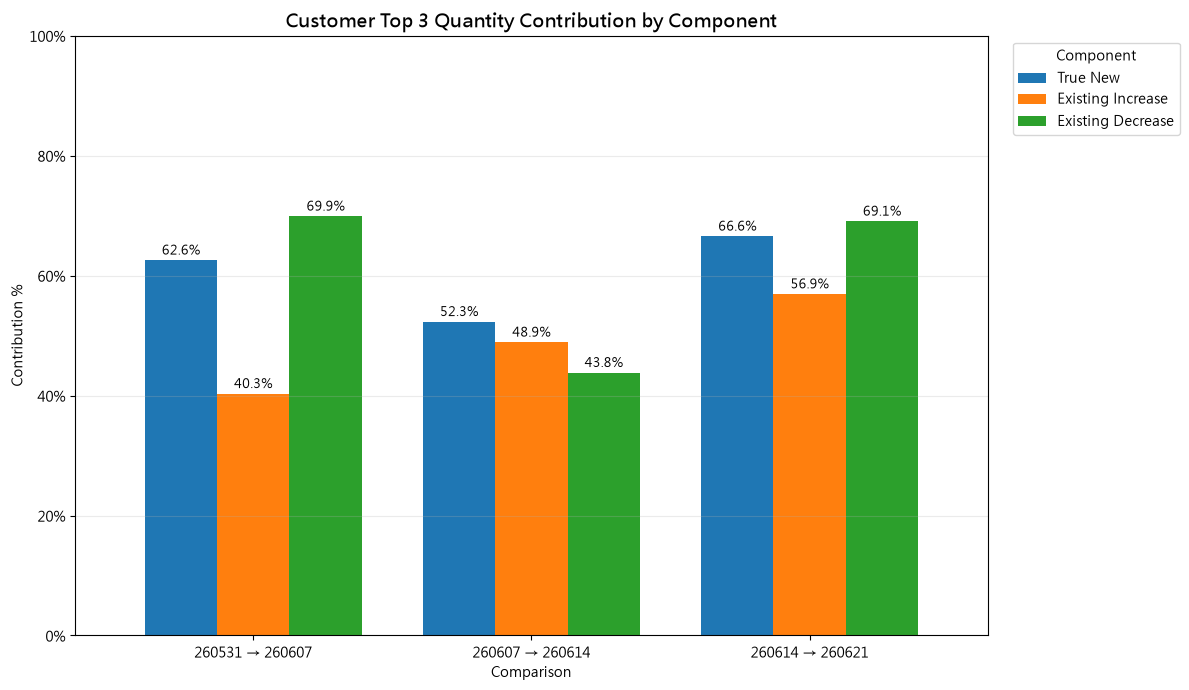

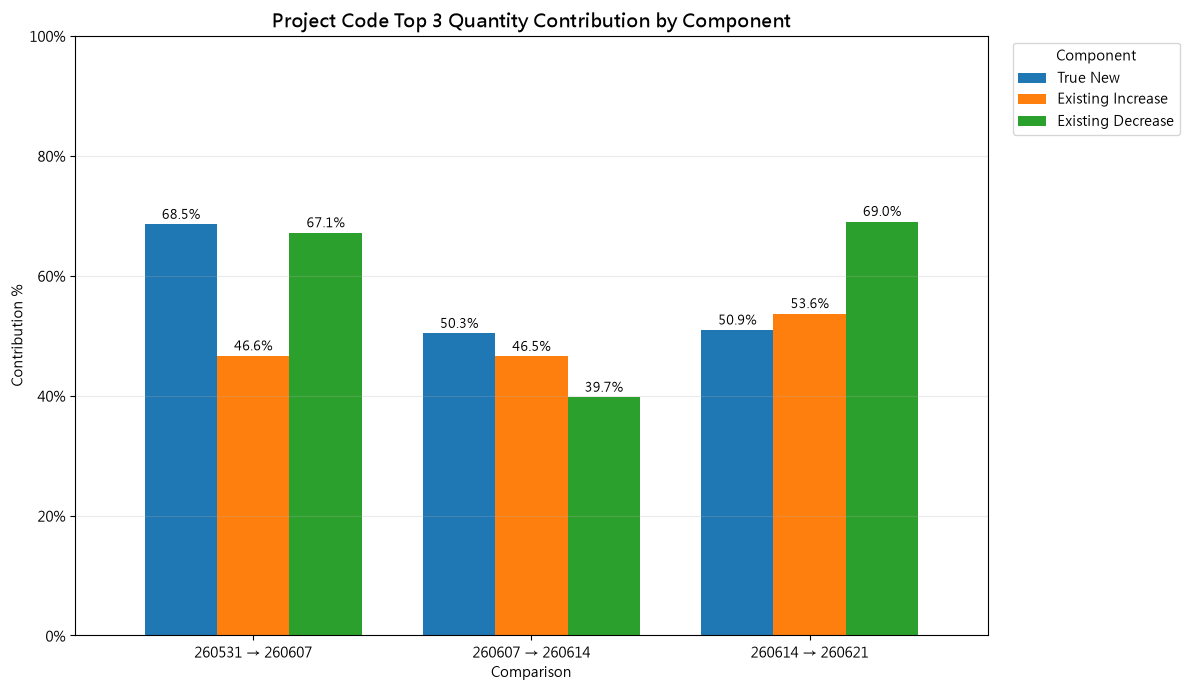

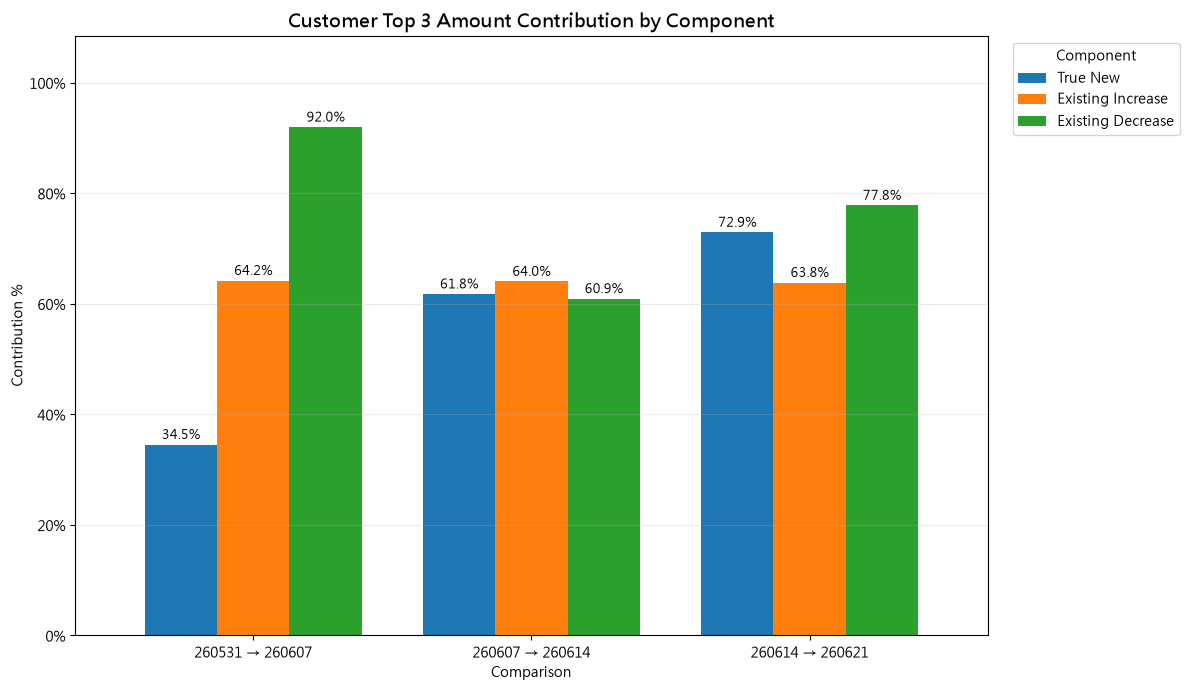

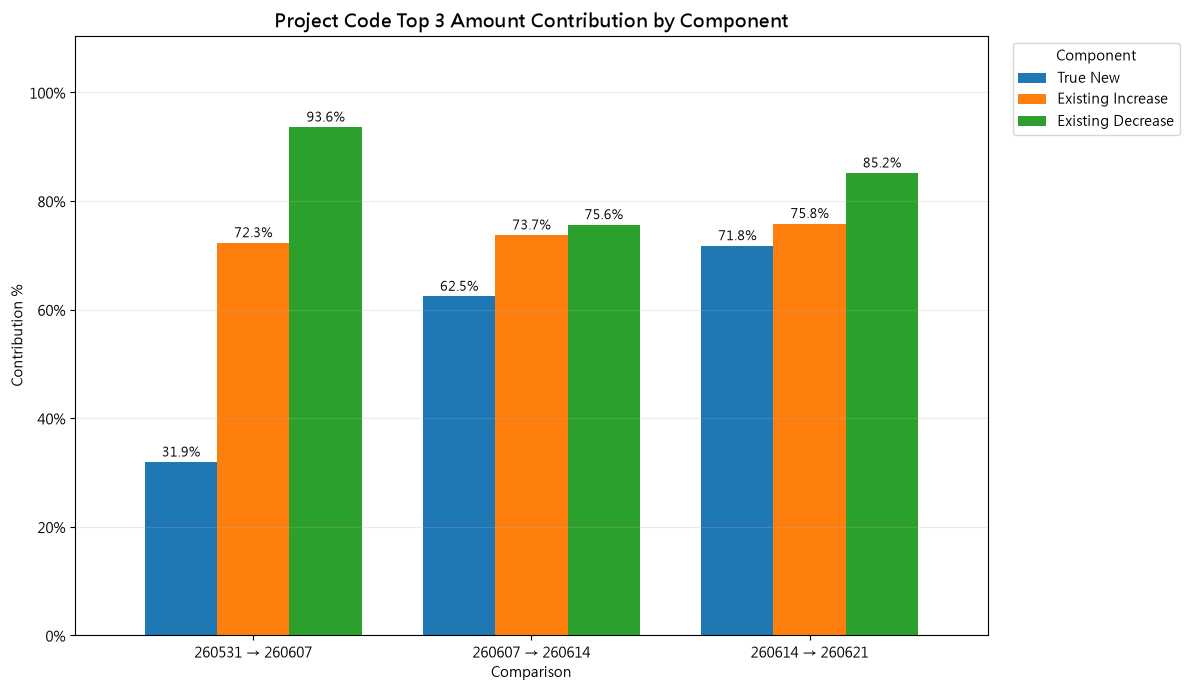

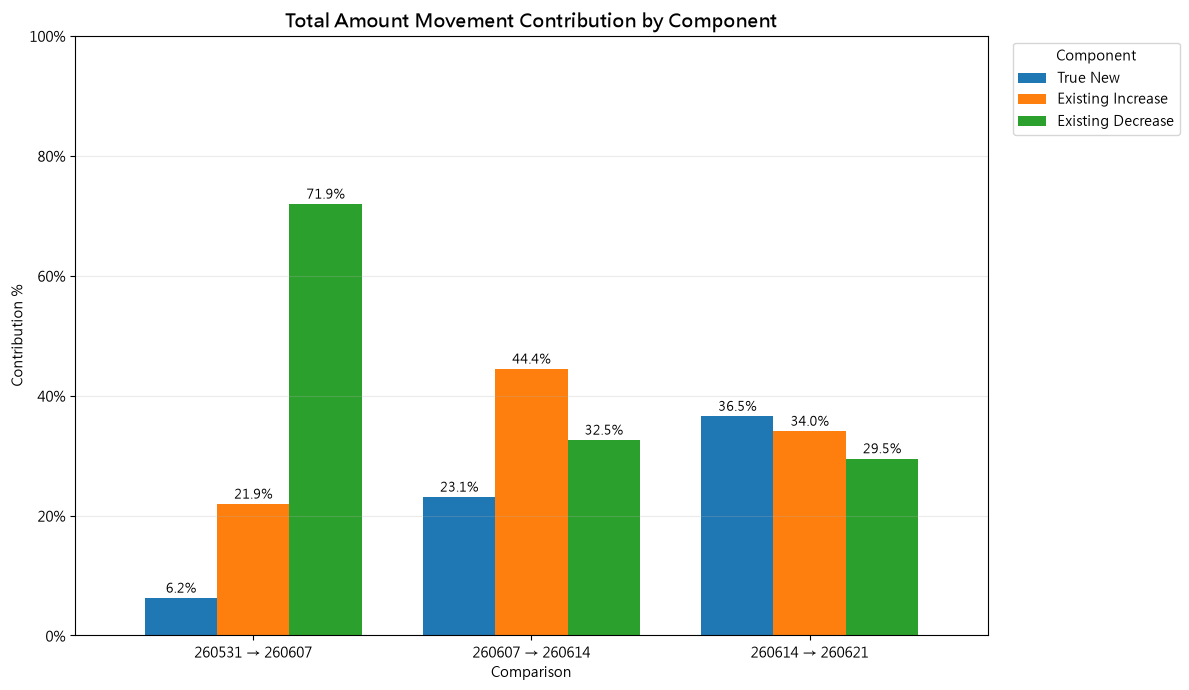

In [71]:
COMPARISON_ORDER = [
    "260531 → 260607",
    "260607 → 260614",
    "260614 → 260621"
]

CHART_COMPONENT_ORDER = [
    "True New",
    "Existing Increase",
    "Existing Decrease"
]

def build_top3_component_chart_df(
    component_concentration_df
):
    required_cols = [
        "Comparison",
        "ANALYSIS_COMPONENT",
        "TOP3_CONTRIBUTION_%"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in component_concentration_df.columns
    ]

    if missing_cols:
        raise KeyError(
            "Component concentration dataframe "
            f"missing columns: {missing_cols}"
        )

    plot_df = (
        component_concentration_df[
            component_concentration_df[
                "ANALYSIS_COMPONENT"
            ].isin(
                CHART_COMPONENT_ORDER
            )
        ]
        .copy()
    )

    plot_df[
        "TOP3_CONTRIBUTION_%"
    ] = pd.to_numeric(
        plot_df[
            "TOP3_CONTRIBUTION_%"
        ],
        errors="coerce"
    ).fillna(0)

    chart_df = (
        plot_df
        .pivot_table(
            index="Comparison",
            columns="ANALYSIS_COMPONENT",
            values="TOP3_CONTRIBUTION_%",
            aggfunc="sum",
            fill_value=0
        )
        .reindex(
            COMPARISON_ORDER
        )
    )

    # Ensure all three component columns exist
    for component in CHART_COMPONENT_ORDER:

        if component not in chart_df.columns:
            chart_df[component] = 0

    chart_df = chart_df[
        CHART_COMPONENT_ORDER
    ]

    return chart_df


def plot_component_contribution_bar_chart(
    chart_df,
    title
):
    chart_df = chart_df.copy()

    ax = chart_df.plot(
        kind="bar",
        figsize=(12, 7),
        width=0.78
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Comparison"
    )

    ax.set_ylabel(
        "Contribution %"
    )

    max_value = (
        chart_df
        .max()
        .max()
    )

    if pd.isna(max_value):
        max_value = 0

    ax.set_ylim(
        0,
        max(
            100,
            max_value * 1.18
        )
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda value, _:
                f"{value:.0f}%"
        )
    )

    ax.set_xticklabels(
        chart_df.index,
        rotation=0
    )

    ax.legend(
        title="Component",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    # Add labels above bars
    for container in ax.containers:

        labels = [
            (
                f"{value:.1f}%"
                if pd.notna(value)
                and value > 0
                else ""
            )
            for value in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


def build_total_amount_component_contribution_df(
    amount_classified_df
):
    df = amount_classified_df.copy()

    required_cols = [
        "Comparison",
        "AMOUNT_COMPONENT",
        "AMOUNT_CHANGE"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            "Amount classified dataframe "
            f"missing columns: {missing_cols}"
        )

    component_map = {
        "True New Order Amount":
            "True New",

        "Existing Amount Increase":
            "Existing Increase",

        "Existing Amount Decrease":
            "Existing Decrease"
    }

    df["ANALYSIS_COMPONENT"] = (
        df["AMOUNT_COMPONENT"]
        .map(component_map)
    )

    df = df[
        df["ANALYSIS_COMPONENT"].isin(
            CHART_COMPONENT_ORDER
        )
    ].copy()

    df["AMOUNT_CHANGE"] = pd.to_numeric(
        df["AMOUNT_CHANGE"],
        errors="coerce"
    ).fillna(0)

    component_summary_df = (
        df
        .groupby(
            [
                "Comparison",
                "ANALYSIS_COMPONENT"
            ],
            as_index=False
        )
        .agg(
            COMPONENT_ACTUAL_AMOUNT_CHANGE=(
                "AMOUNT_CHANGE",
                "sum"
            )
        )
    )

    component_summary_df[
        "ABS_COMPONENT_AMOUNT"
    ] = (
        component_summary_df[
            "COMPONENT_ACTUAL_AMOUNT_CHANGE"
        ]
        .abs()
    )

    total_movement_df = (
        component_summary_df
        .groupby(
            "Comparison",
            as_index=False
        )
        .agg(
            TOTAL_AMOUNT_MOVEMENT=(
                "ABS_COMPONENT_AMOUNT",
                "sum"
            )
        )
    )

    component_summary_df = (
        component_summary_df
        .merge(
            total_movement_df,
            on="Comparison",
            how="left",
            validate="many_to_one"
        )
    )

    component_summary_df[
        "COMPONENT_CONTRIBUTION_%"
    ] = np.where(
        component_summary_df[
            "TOTAL_AMOUNT_MOVEMENT"
        ] > 0,
        (
            component_summary_df[
                "ABS_COMPONENT_AMOUNT"
            ]
            /
            component_summary_df[
                "TOTAL_AMOUNT_MOVEMENT"
            ]
            *
            100
        ),
        0
    )

    chart_df = (
        component_summary_df
        .pivot_table(
            index="Comparison",
            columns="ANALYSIS_COMPONENT",
            values="COMPONENT_CONTRIBUTION_%",
            aggfunc="sum",
            fill_value=0
        )
        .reindex(
            COMPARISON_ORDER
        )
    )

    for component in CHART_COMPONENT_ORDER:

        if component not in chart_df.columns:
            chart_df[component] = 0

    chart_df = chart_df[
        CHART_COMPONENT_ORDER
    ]

    return {
        "chart_data":
            chart_df,

        "detail":
            component_summary_df
    }



quantity_customer_component_chart_df = (
    build_top3_component_chart_df(
        component_concentration_df=
            quantity_customer_result[
                "component_concentration"
            ]
    )
)

quantity_project_component_chart_df = (
    build_top3_component_chart_df(
        component_concentration_df=
            quantity_project_result[
                "component_concentration"
            ]
    )
)


amount_customer_component_chart_df = (
    build_top3_component_chart_df(
        component_concentration_df=
            amount_customer_result[
                "component_concentration"
            ]
    )
)


amount_project_component_chart_df = (
    build_top3_component_chart_df(
        component_concentration_df=
            amount_project_result[
                "component_concentration"
            ]
    )
)



total_amount_component_result = (
    build_total_amount_component_contribution_df(
        amount_classified_df=
            non_hub_amount_layer2_classified_df
    )
)

total_amount_component_contribution_chart_df = (
    total_amount_component_result[
        "chart_data"
    ]
)

total_amount_component_contribution_detail_df = (
    total_amount_component_result[
        "detail"
    ]
)



print(
    "Total Amount Component Contribution Detail"
)

display(
    total_amount_component_contribution_detail_df[
        [
            "Comparison",
            "ANALYSIS_COMPONENT",
            "COMPONENT_ACTUAL_AMOUNT_CHANGE",
            "ABS_COMPONENT_AMOUNT",
            "TOTAL_AMOUNT_MOVEMENT",
            "COMPONENT_CONTRIBUTION_%"
        ]
    ]
    .style
    .format({
        "COMPONENT_ACTUAL_AMOUNT_CHANGE":
            "{:+,.2f}",

        "ABS_COMPONENT_AMOUNT":
            "{:,.2f}",

        "TOTAL_AMOUNT_MOVEMENT":
            "{:,.2f}",

        "COMPONENT_CONTRIBUTION_%":
            "{:.2f}%"
    })
    .hide(axis="index")
)



plot_component_contribution_bar_chart(
    chart_df=
        quantity_customer_component_chart_df,

    title=(
        "Customer Top 3 Quantity Contribution "
        "by Component"
    )
)


plot_component_contribution_bar_chart(
    chart_df=
        quantity_project_component_chart_df,

    title=(
        "Project Code Top 3 Quantity Contribution "
        "by Component"
    )
)


# ============================================================
# DRAW CHART 3
# AMOUNT CUSTOMER
# ============================================================

plot_component_contribution_bar_chart(
    chart_df=
        amount_customer_component_chart_df,

    title=(
        "Customer Top 3 Amount Contribution "
        "by Component"
    )
)


# ============================================================
# DRAW CHART 4
# AMOUNT PROJECT CODE
# ============================================================

plot_component_contribution_bar_chart(
    chart_df=
        amount_project_component_chart_df,

    title=(
        "Project Code Top 3 Amount Contribution "
        "by Component"
    )
)


# ============================================================
# DRAW CHART 5
# TOTAL AMOUNT COMPONENT CONTRIBUTION
# ============================================================

plot_component_contribution_bar_chart(
    chart_df=
        total_amount_component_contribution_chart_df,

    title=(
        "Total Amount Movement Contribution "
        "by Component"
    )
)

In [72]:
def clean_text_col(s):
    return (
        s.astype("string")
         .str.strip()
         .replace({
             "": pd.NA,
             "nan": pd.NA,
             "NaN": pd.NA,
             "None": pd.NA,
             "<NA>": pd.NA,
             "#N/A": pd.NA,
             "N/A": pd.NA
             # Do not replace real code "NA"
         })
    )

def build_amount_group_column(
    df,
    group_col
):
    if group_col == "CUSTOMER":

        data1_col = "PARTY_NAME_data1"
        data2_col = "PARTY_NAME_data2"

    elif group_col == "PROJECT_CODE":

        data1_col = "PROJECT_CODE_data1"
        data2_col = "PROJECT_CODE_data2"

    else:
        raise ValueError(
            "group_col must be "
            "'CUSTOMER' or 'PROJECT_CODE'"
        )

    missing_cols = [
        col
        for col in [
            data1_col,
            data2_col
        ]
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Missing required columns: {missing_cols}"
        )

    data1_value = clean_text_col(
        df[data1_col]
    )

    data2_value = clean_text_col(
        df[data2_col]
    )

    return (
        data2_value
        .fillna(data1_value)
    )

def build_amount_layer3_by_group(
    amount_detail_df,
    group_col,
    top_n=10
):
    df = amount_detail_df.copy()

    required_cols = [
        "Comparison",
        "LINE_ID",
        "AMOUNT_CHANGE"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Missing required columns: {missing_cols}"
        )

    df[group_col] = build_amount_group_column(
        df=df,
        group_col=group_col
    )

    df = df[
        df[group_col].notna()
    ].copy()

    df["AMOUNT_CHANGE"] = pd.to_numeric(
        df["AMOUNT_CHANGE"],
        errors="coerce"
    ).fillna(0)

    # Only keep lines with actual Amount change
    df = df[
        df["AMOUNT_CHANGE"] != 0
    ].copy()

    df["AMOUNT_INCREASE"] = np.where(
        df["AMOUNT_CHANGE"] > 0,
        df["AMOUNT_CHANGE"],
        0
    )

    # Keep decrease as negative
    df["AMOUNT_DECREASE"] = np.where(
        df["AMOUNT_CHANGE"] < 0,
        df["AMOUNT_CHANGE"],
        0
    )

    df["ABS_AMOUNT_CHANGE"] = (
        df["AMOUNT_CHANGE"]
        .abs()
    )

    df["AMOUNT_INCREASE_FLAG"] = (
        df["AMOUNT_CHANGE"] > 0
    ).astype(int)

    df["AMOUNT_DECREASE_FLAG"] = (
        df["AMOUNT_CHANGE"] < 0
    ).astype(int)

    group_summary_df = (
        df
        .groupby(
            [
                "Comparison",
                group_col
            ],
            as_index=False
        )
        .agg(
            AMOUNT_CHANGED_LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            AMOUNT_INCREASE_LINE_COUNT=(
                "AMOUNT_INCREASE_FLAG",
                "sum"
            ),

            AMOUNT_DECREASE_LINE_COUNT=(
                "AMOUNT_DECREASE_FLAG",
                "sum"
            ),

            TOTAL_AMOUNT_INCREASE=(
                "AMOUNT_INCREASE",
                "sum"
            ),

            TOTAL_AMOUNT_DECREASE=(
                "AMOUNT_DECREASE",
                "sum"
            ),

            NET_AMOUNT_CHANGE=(
                "AMOUNT_CHANGE",
                "sum"
            ),

            TOTAL_AMOUNT_MOVEMENT=(
                "ABS_AMOUNT_CHANGE",
                "sum"
            )
        )
    )

    comparison_total_df = (
        df
        .groupby(
            "Comparison",
            as_index=False
        )
        .agg(
            OVERALL_AMOUNT_INCREASE=(
                "AMOUNT_INCREASE",
                "sum"
            ),

            OVERALL_AMOUNT_DECREASE=(
                "AMOUNT_DECREASE",
                "sum"
            ),

            OVERALL_NET_AMOUNT_CHANGE=(
                "AMOUNT_CHANGE",
                "sum"
            ),

            OVERALL_TOTAL_AMOUNT_MOVEMENT=(
                "ABS_AMOUNT_CHANGE",
                "sum"
            )
        )
    )

    group_summary_df = (
        group_summary_df
        .merge(
            comparison_total_df,
            on="Comparison",
            how="left"
        )
    )

    group_summary_df[
        "AMOUNT_MOVEMENT_CONTRIBUTION_%"
    ] = np.where(
        group_summary_df[
            "OVERALL_TOTAL_AMOUNT_MOVEMENT"
        ] > 0,
        (
            group_summary_df[
                "TOTAL_AMOUNT_MOVEMENT"
            ]
            /
            group_summary_df[
                "OVERALL_TOTAL_AMOUNT_MOVEMENT"
            ]
            *
            100
        ),
        0
    )

    group_summary_df[
        "MAIN_AMOUNT_DIRECTION"
    ] = np.select(
        [
            group_summary_df[
                "NET_AMOUNT_CHANGE"
            ] > 0,

            group_summary_df[
                "NET_AMOUNT_CHANGE"
            ] < 0
        ],
        [
            "Net Amount Increase",
            "Net Amount Decrease"
        ],
        default="Net Zero / Mixed"
    )

    group_summary_df = (
        group_summary_df
        .sort_values(
            [
                "Comparison",
                "TOTAL_AMOUNT_MOVEMENT",
                group_col
            ],
            ascending=[
                True,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    group_summary_df["RANK"] = (
        group_summary_df
        .groupby("Comparison")
        .cumcount()
        + 1
    )

    top_n_df = (
        group_summary_df[
            group_summary_df["RANK"] <= top_n
        ]
        .copy()
        .reset_index(drop=True)
    )

    top3_df = (
        group_summary_df[
            group_summary_df["RANK"] <= 3
        ]
        .groupby(
            "Comparison",
            as_index=False
        )
        .agg(
            TOP3_TOTAL_AMOUNT_MOVEMENT=(
                "TOTAL_AMOUNT_MOVEMENT",
                "sum"
            ),

            TOP3_MOVEMENT_CONTRIBUTION=(
                "AMOUNT_MOVEMENT_CONTRIBUTION_%",
                "sum"
            )
        )
    )

    concentration_df = (
        comparison_total_df
        .merge(
            top3_df,
            on="Comparison",
            how="left"
        )
    )

    concentration_df[
        "TOP3_TOTAL_AMOUNT_MOVEMENT"
    ] = (
        concentration_df[
            "TOP3_TOTAL_AMOUNT_MOVEMENT"
        ]
        .fillna(0)
    )

    concentration_df[
        "TOP3_MOVEMENT_CONTRIBUTION"
    ] = (
        concentration_df[
            "TOP3_MOVEMENT_CONTRIBUTION"
        ]
        .fillna(0)
    )

    concentration_df["GROUP_TYPE"] = group_col

    concentration_df["CONCENTRATION"] = np.select(
        [
            concentration_df[
                "TOP3_MOVEMENT_CONTRIBUTION"
            ] >= 70,

            concentration_df[
                "TOP3_MOVEMENT_CONTRIBUTION"
            ] >= 50
        ],
        [
            "Highly Concentrated",
            "Moderately Concentrated"
        ],
        default="Dispersed"
    )

    return {
        "full_summary":
            group_summary_df,

        "top10":
            top_n_df,

        "comparison_summary":
            comparison_total_df,

        "top3_concentration":
            concentration_df
    }

In [73]:
customer_amount_layer3_result = (
    build_amount_layer3_by_group(
        amount_detail_df=
            non_hub_amount_layer2_classified_df,

        group_col="CUSTOMER",

        top_n=10
    )
)

customer_amount_layer3_full_df = (
    customer_amount_layer3_result[
        "full_summary"
    ]
)

customer_amount_layer3_top10_df = (
    customer_amount_layer3_result[
        "top10"
    ]
)

customer_amount_layer3_summary_df = (
    customer_amount_layer3_result[
        "comparison_summary"
    ]
)

customer_amount_layer3_concentration_df = (
    customer_amount_layer3_result[
        "top3_concentration"
    ]
)

project_amount_layer3_result = (
    build_amount_layer3_by_group(
        amount_detail_df=
            non_hub_amount_layer2_classified_df,

        group_col="PROJECT_CODE",

        top_n=10
    )
)

project_amount_layer3_full_df = (
    project_amount_layer3_result[
        "full_summary"
    ]
)

project_amount_layer3_top10_df = (
    project_amount_layer3_result[
        "top10"
    ]
)

project_amount_layer3_summary_df = (
    project_amount_layer3_result[
        "comparison_summary"
    ]
)

project_amount_layer3_concentration_df = (
    project_amount_layer3_result[
        "top3_concentration"
    ]
)

customer_display_cols = [
    "Comparison",
    "RANK",
    "CUSTOMER",
    "AMOUNT_CHANGED_LINE_COUNT",
    "AMOUNT_INCREASE_LINE_COUNT",
    "AMOUNT_DECREASE_LINE_COUNT",
    "TOTAL_AMOUNT_INCREASE",
    "TOTAL_AMOUNT_DECREASE",
    "NET_AMOUNT_CHANGE",
    "TOTAL_AMOUNT_MOVEMENT",
    "AMOUNT_MOVEMENT_CONTRIBUTION_%",
    "MAIN_AMOUNT_DIRECTION"
]

for comparison in (
    customer_amount_layer3_top10_df[
        "Comparison"
    ]
    .dropna()
    .unique()
):

    print(
        f"\nCustomer Top 10 Amount Movement: "
        f"{comparison}"
    )

    temp = (
        customer_amount_layer3_top10_df[
            customer_amount_layer3_top10_df[
                "Comparison"
            ].eq(comparison)
        ]
        .copy()
    )

    display(
        temp[
            customer_display_cols
        ]
        .style
        .format({
            "RANK":
                "{:,.0f}",

            "AMOUNT_CHANGED_LINE_COUNT":
                "{:,.0f}",

            "AMOUNT_INCREASE_LINE_COUNT":
                "{:,.0f}",

            "AMOUNT_DECREASE_LINE_COUNT":
                "{:,.0f}",

            "TOTAL_AMOUNT_INCREASE":
                "{:+,.0f}",

            "TOTAL_AMOUNT_DECREASE":
                "{:+,.0f}",

            "NET_AMOUNT_CHANGE":
                "{:+,.0f}",

            "TOTAL_AMOUNT_MOVEMENT":
                "{:,.0f}",

            "AMOUNT_MOVEMENT_CONTRIBUTION_%":
                "{:.2f}%"
        })
        .hide(axis="index")
    )

project_display_cols = [
    "Comparison",
    "RANK",
    "PROJECT_CODE",
    "AMOUNT_CHANGED_LINE_COUNT",
    "AMOUNT_INCREASE_LINE_COUNT",
    "AMOUNT_DECREASE_LINE_COUNT",
    "TOTAL_AMOUNT_INCREASE",
    "TOTAL_AMOUNT_DECREASE",
    "NET_AMOUNT_CHANGE",
    "TOTAL_AMOUNT_MOVEMENT",
    "AMOUNT_MOVEMENT_CONTRIBUTION_%",
    "MAIN_AMOUNT_DIRECTION"
]

for comparison in (
    project_amount_layer3_top10_df[
        "Comparison"
    ]
    .dropna()
    .unique()
):

    print(
        f"\nProject Code Top 10 Amount Movement: "
        f"{comparison}"
    )

    temp = (
        project_amount_layer3_top10_df[
            project_amount_layer3_top10_df[
                "Comparison"
            ].eq(comparison)
        ]
        .copy()
    )

    display(
        temp[
            project_display_cols
        ]
        .style
        .format({
            "RANK":
                "{:,.0f}",

            "AMOUNT_CHANGED_LINE_COUNT":
                "{:,.0f}",

            "AMOUNT_INCREASE_LINE_COUNT":
                "{:,.0f}",

            "AMOUNT_DECREASE_LINE_COUNT":
                "{:,.0f}",

            "TOTAL_AMOUNT_INCREASE":
                "{:+,.0f}",

            "TOTAL_AMOUNT_DECREASE":
                "{:+,.0f}",

            "NET_AMOUNT_CHANGE":
                "{:+,.0f}",

            "TOTAL_AMOUNT_MOVEMENT":
                "{:,.0f}",

            "AMOUNT_MOVEMENT_CONTRIBUTION_%":
                "{:.2f}%"
        })
        .hide(axis="index")
    )

# ============================================================
# DISPLAY TOP 3 CONCENTRATION
# ============================================================

print("Customer Amount Top 3 Concentration")

display(
    customer_amount_layer3_concentration_df
    .style
    .format({
        "OVERALL_AMOUNT_INCREASE":
            "{:+,.0f}",

        "OVERALL_AMOUNT_DECREASE":
            "{:+,.0f}",

        "OVERALL_NET_AMOUNT_CHANGE":
            "{:+,.0f}",

        "OVERALL_TOTAL_AMOUNT_MOVEMENT":
            "{:,.0f}",

        "TOP3_TOTAL_AMOUNT_MOVEMENT":
            "{:,.0f}",

        "TOP3_MOVEMENT_CONTRIBUTION":
            "{:.2f}%"
    })
    .hide(axis="index")
)


print("\nProject Code Amount Top 3 Concentration")

display(
    project_amount_layer3_concentration_df
    .style
    .format({
        "OVERALL_AMOUNT_INCREASE":
            "{:+,.0f}",

        "OVERALL_AMOUNT_DECREASE":
            "{:+,.0f}",

        "OVERALL_NET_AMOUNT_CHANGE":
            "{:+,.0f}",

        "OVERALL_TOTAL_AMOUNT_MOVEMENT":
            "{:,.0f}",

        "TOP3_TOTAL_AMOUNT_MOVEMENT":
            "{:,.0f}",

        "TOP3_MOVEMENT_CONTRIBUTION":
            "{:.2f}%"
    })
    .hide(axis="index")
)


Customer Top 10 Amount Movement: 260531 → 260607


Comparison,RANK,CUSTOMER,AMOUNT_CHANGED_LINE_COUNT,AMOUNT_INCREASE_LINE_COUNT,AMOUNT_DECREASE_LINE_COUNT,TOTAL_AMOUNT_INCREASE,TOTAL_AMOUNT_DECREASE,NET_AMOUNT_CHANGE,TOTAL_AMOUNT_MOVEMENT,AMOUNT_MOVEMENT_CONTRIBUTION_%,MAIN_AMOUNT_DIRECTION
260531 → 260607,1,Wiwynn International corporation,104,65,39,"+5,971,728","-66,255,159","-60,283,431","72,226,887",64.09%,Net Amount Decrease
260531 → 260607,2,仁寶電子科技(昆山)有限公司,37,21,16,"+6,353,491","-6,353,386",+105,"12,706,878",11.28%,Net Amount Increase
260531 → 260607,3,Wistron InfoComm Technology(America) Corporation,40,40,0,"+3,618,972",+0,"+3,618,972","3,618,972",3.21%,Net Amount Increase
260531 → 260607,4,雲尖信息技術股份有限公司,228,216,12,"+1,514,337","-846,130","+668,207","2,360,467",2.09%,Net Amount Increase
260531 → 260607,5,智邦科技股份有限公司,40,21,19,"+1,078,203","-1,076,882","+1,321","2,155,085",1.91%,Net Amount Increase
260531 → 260607,6,Wistron Corporation,17,4,13,"+9,267","-1,899,492","-1,890,225","1,908,759",1.69%,Net Amount Decrease
260531 → 260607,7,Hyve Solutions Corporation,12,9,3,"+788,900","-779,341","+9,559","1,568,241",1.39%,Net Amount Increase
260531 → 260607,8,華碩電腦股份有限公司,6,4,2,"+762,900","-762,900",-0,"1,525,799",1.35%,Net Amount Decrease
260531 → 260607,9,和碩聯合科技股份有限公司,22,14,8,"+637,750","-519,204","+118,546","1,156,954",1.03%,Net Amount Increase
260531 → 260607,10,Lenovo Global Technologies Ireland International Limited,5,5,0,"+1,142,139",+0,"+1,142,139","1,142,139",1.01%,Net Amount Increase



Customer Top 10 Amount Movement: 260607 → 260614


Comparison,RANK,CUSTOMER,AMOUNT_CHANGED_LINE_COUNT,AMOUNT_INCREASE_LINE_COUNT,AMOUNT_DECREASE_LINE_COUNT,TOTAL_AMOUNT_INCREASE,TOTAL_AMOUNT_DECREASE,NET_AMOUNT_CHANGE,TOTAL_AMOUNT_MOVEMENT,AMOUNT_MOVEMENT_CONTRIBUTION_%,MAIN_AMOUNT_DIRECTION
260607 → 260614,1,Wiwynn International corporation,98,77,21,"+17,240,860","-8,197,401","+9,043,459","25,438,261",46.77%,Net Amount Increase
260607 → 260614,2,WIWYNN TECHNOLOGY SERVICE MALAYSIA SDN. BHD.,24,16,8,"+1,443,019","-1,441,727","+1,292","2,884,746",5.30%,Net Amount Increase
260607 → 260614,3,Wistron Corporation,40,39,1,"+2,607,326","-37,773","+2,569,553","2,645,100",4.86%,Net Amount Increase
260607 → 260614,4,智邦科技股份有限公司,26,15,11,"+1,150,883","-1,147,439","+3,444","2,298,321",4.23%,Net Amount Increase
260607 → 260614,5,曙光信息產業股份有限公司,177,138,39,"+1,894,757","-380,612","+1,514,145","2,275,369",4.18%,Net Amount Increase
260607 → 260614,6,Jabil Inc. (Kentucky),16,14,2,"+1,108,450","-1,069,236","+39,214","2,177,685",4.00%,Net Amount Increase
260607 → 260614,7,廣達電腦股份有限公司,121,101,20,"+976,237","-618,838","+357,399","1,595,075",2.93%,Net Amount Increase
260607 → 260614,8,Hyve Solutions (Taiwan) Corporation,16,15,1,"+1,134,212","-193,306","+940,906","1,327,518",2.44%,Net Amount Increase
260607 → 260614,9,和碩聯合科技股份有限公司,21,19,2,"+816,494","-422,634","+393,860","1,239,128",2.28%,Net Amount Increase
260607 → 260614,10,上海順詮科技有限公司,39,32,7,"+740,015","-387,353","+352,662","1,127,367",2.07%,Net Amount Increase



Customer Top 10 Amount Movement: 260614 → 260621


...

Comparison,RANK,PROJECT_CODE,AMOUNT_CHANGED_LINE_COUNT,AMOUNT_INCREASE_LINE_COUNT,AMOUNT_DECREASE_LINE_COUNT,TOTAL_AMOUNT_INCREASE,TOTAL_AMOUNT_DECREASE,NET_AMOUNT_CHANGE,TOTAL_AMOUNT_MOVEMENT,AMOUNT_MOVEMENT_CONTRIBUTION_%,MAIN_AMOUNT_DIRECTION
260614 → 260621,1,T3 PDS,218,177,41,"+35,112,280","-21,130,295","+13,981,985","56,242,574",59.57%,Net Amount Increase
260614 → 260621,2,MGX_1U_GB300,70,57,13,"+7,455,396","-823,079","+6,632,317","8,278,475",8.77%,Net Amount Increase
260614 → 260621,3,EVE C3,54,52,2,"+3,776,737","-8,792","+3,767,945","3,785,529",4.01%,Net Amount Increase
260614 → 260621,4,ALESIA,31,14,17,"+1,600,168","-1,600,168",+0,"3,200,336",3.39%,Net Amount Increase
260614 → 260621,5,EVE 2U,39,38,1,"+2,842,705","-7,358","+2,835,347","2,850,063",3.02%,Net Amount Increase
260614 → 260621,6,AWS VR IXZ PROJECT,17,16,1,"+2,771,550",-240,"+2,771,310","2,771,790",2.94%,Net Amount Increase
260614 → 260621,7,MGX_1U_VERA RUBIN,22,19,3,"+2,456,732","-7,768","+2,448,964","2,464,500",2.61%,Net Amount Increase
260614 → 260621,8,RM241,15,14,1,"+1,105,309","-949,000","+156,309","2,054,309",2.18%,Net Amount Increase
260614 → 260621,9,RM156,24,19,5,"+1,574,943","-223,655","+1,351,288","1,798,599",1.90%,Net Amount Increase
260614 → 260621,10,GOSHIN,52,42,10,"+873,160","-258,480","+614,679","1,131,640",1.20%,Net Amount Increase


Customer Amount Top 3 Concentration


Comparison,OVERALL_AMOUNT_INCREASE,OVERALL_AMOUNT_DECREASE,OVERALL_NET_AMOUNT_CHANGE,OVERALL_TOTAL_AMOUNT_MOVEMENT,TOP3_TOTAL_AMOUNT_MOVEMENT,TOP3_MOVEMENT_CONTRIBUTION,GROUP_TYPE,CONCENTRATION
260531 → 260607,"+31,664,826","-81,025,441","-49,360,615","112,690,268","88,552,737",78.58%,CUSTOMER,Highly Concentrated
260607 → 260614,"+36,690,533","-17,704,681","+18,985,852","54,395,215","30,968,106",56.93%,CUSTOMER,Moderately Concentrated
260614 → 260621,"+66,611,054","-27,806,395","+38,804,659","94,417,449","59,620,666",63.15%,CUSTOMER,Moderately Concentrated



Project Code Amount Top 3 Concentration


Comparison,OVERALL_AMOUNT_INCREASE,OVERALL_AMOUNT_DECREASE,OVERALL_NET_AMOUNT_CHANGE,OVERALL_TOTAL_AMOUNT_MOVEMENT,TOP3_TOTAL_AMOUNT_MOVEMENT,TOP3_MOVEMENT_CONTRIBUTION,GROUP_TYPE,CONCENTRATION
260531 → 260607,"+31,664,826","-81,025,441","-49,360,615","112,690,268","94,558,372",83.91%,PROJECT_CODE,Highly Concentrated
260607 → 260614,"+36,690,533","-17,704,681","+18,985,852","54,395,215","36,330,491",66.79%,PROJECT_CODE,Moderately Concentrated
260614 → 260621,"+66,611,054","-27,806,395","+38,804,659","94,417,449","68,306,578",72.35%,PROJECT_CODE,Highly Concentrated


In [74]:
# Base Data: Order Type
def classify_hub_pick(order_type_name):
    order_type = str(order_type_name).strip().upper()

    if order_type == "HUB PICK UP":
        return "Hub Pick"

    if order_type in ["NPI", "STD", "NPI_NON KEY ACCOUNT"]:
        return "Non Hub Pick"

    return "Other / Unknown"


def build_order_type_snapshot_summary(file_name):
    df = snapshots[file_name].copy()

    df["ORDER_TYPE_GROUP"] = df["ORDER_TYPE_NAME"].apply(classify_hub_pick)
    df["ORDERED_QUANTITY"] = pd.to_numeric(
        df["ORDERED_QUANTITY"],
        errors="coerce"
    ).fillna(0)

    df["US_PRICE"] = pd.to_numeric(
        df["US_PRICE"],
        errors="coerce"
    ).fillna(0)

    df["LINE_AMOUNT"] = df["ORDERED_QUANTITY"] * df["US_PRICE"]

    summary = (
        df
        .groupby("ORDER_TYPE_GROUP", as_index=False)
        .agg(
            LINE_COUNT=("LINE_ID", "count"),
            TOTAL_QTY=("ORDERED_QUANTITY", "sum"),
            TOTAL_AMOUNT=("LINE_AMOUNT", "sum")
        )
    )

    summary["BACKUP_VERSION"] = get_backup_version(file_name)

    return summary[
        [
            "BACKUP_VERSION",
            "ORDER_TYPE_GROUP",
            "LINE_COUNT",
            "TOTAL_QTY",
            "TOTAL_AMOUNT"
        ]
    ]


def build_order_type_snapshot_base():
    all_summary = []

    for file_name in SNAPSHOT_FILES:
        all_summary.append(
            build_order_type_snapshot_summary(file_name)
        )

    return pd.concat(all_summary, ignore_index=True)


order_type_snapshot_base_df = build_order_type_snapshot_base()

In [75]:
def build_order_type_weekly_change(order_type_snapshot_base_df):
    all_results = []

    for data1_name, data2_name in SNAPSHOT_PAIRS:
        comparison = get_comparison_label(data1_name, data2_name)

        version1 = get_backup_version(data1_name)
        version2 = get_backup_version(data2_name)

        data1_summary = (
            order_type_snapshot_base_df[
                order_type_snapshot_base_df["BACKUP_VERSION"] == version1
            ][
                [
                    "ORDER_TYPE_GROUP",
                    "LINE_COUNT",
                    "TOTAL_QTY",
                    "TOTAL_AMOUNT",
                ]
            ]
        )

        data2_summary = (
            order_type_snapshot_base_df[
                order_type_snapshot_base_df["BACKUP_VERSION"] == version2
            ][
                [
                    "ORDER_TYPE_GROUP",
                    "LINE_COUNT",
                    "TOTAL_QTY",
                    "TOTAL_AMOUNT",
                ]
            ]
        )

        weekly_change = data1_summary.merge(
            data2_summary,
            on="ORDER_TYPE_GROUP",
            how="outer",
            suffixes=("_data1", "_data2")
        ).fillna(0)

        weekly_change["NET_LINE_COUNT_CHANGE"] = (
            weekly_change["LINE_COUNT_data2"]
            - weekly_change["LINE_COUNT_data1"]
        )

        weekly_change["NET_QTY_CHANGE"] = (
            weekly_change["TOTAL_QTY_data2"]
            - weekly_change["TOTAL_QTY_data1"]
        )

        weekly_change["NET_AMOUNT_CHANGE"] = (
            weekly_change["TOTAL_AMOUNT_data2"]
            - weekly_change["TOTAL_AMOUNT_data1"]
        )

        weekly_change.insert(0, "Comparison", comparison)

        all_results.append(weekly_change)

    return pd.concat(all_results, ignore_index=True)

order_type_weekly_change_df = build_order_type_weekly_change(
    order_type_snapshot_base_df
)

display(
    order_type_weekly_change_df.style
    .format({
        "LINE_COUNT_data1": "{:,.0f}",
        "LINE_COUNT_data2": "{:,.0f}",
        "NET_LINE_COUNT_CHANGE": "{:+,.0f}",
        "TOTAL_QTY_data1": "{:,.0f}",
        "TOTAL_QTY_data2": "{:,.0f}",
        "NET_QTY_CHANGE": "{:+,.0f}",
        "TOTAL_AMOUNT_data1": "{:,.0f}",
        "TOTAL_AMOUNT_data2": "{:,.0f}",
        "NET_AMOUNT_CHANGE": "{:+,.0f}",
    })
    .hide(axis="index")
)

Comparison,ORDER_TYPE_GROUP,LINE_COUNT_data1,TOTAL_QTY_data1,TOTAL_AMOUNT_data1,LINE_COUNT_data2,TOTAL_QTY_data2,TOTAL_AMOUNT_data2,NET_LINE_COUNT_CHANGE,NET_QTY_CHANGE,NET_AMOUNT_CHANGE
260531 → 260607,Hub Pick,"54,699","29,608,273","458,077,405","55,343","30,144,858","466,474,209",+644,"+536,585","+8,396,804"
260531 → 260607,Non Hub Pick,"79,960","183,800,918","953,705,636","81,014","186,147,183","904,343,503","+1,054","+2,346,265","-49,362,133"
260607 → 260614,Hub Pick,"55,343","30,144,858","466,474,209","55,904","30,639,507","472,522,301",+561,"+494,649","+6,048,092"
260607 → 260614,Non Hub Pick,"81,014","186,147,183","904,343,503","82,211","189,311,884","923,329,957","+1,197","+3,164,701","+18,986,454"
260614 → 260621,Hub Pick,"55,904","30,639,507","472,522,301","56,483","31,109,536","487,836,010",+579,"+470,029","+15,313,709"
260614 → 260621,Non Hub Pick,"82,211","189,311,884","923,329,957","83,306","191,747,207","962,137,982","+1,095","+2,435,323","+38,808,024"


In [76]:
# Non Hub Pick Bridge Data Base
def build_non_hub_qty_bridge(merged, comparison, new_split_line_base_df):
    df = merged.copy()

    df["ORDER_TYPE_RAW"] = (
        df["ORDER_TYPE_NAME_data2"]
        .fillna(df["ORDER_TYPE_NAME_data1"])
    )

    df["ORDER_TYPE_GROUP"] = df["ORDER_TYPE_RAW"].apply(classify_hub_pick)

    df = df[
        df["ORDER_TYPE_GROUP"] == "Non Hub Pick"
    ].copy()

    df["QTY_DATA1"] = df["ORDERED_QUANTITY_data1"].fillna(0)
    df["QTY_DATA2"] = df["ORDERED_QUANTITY_data2"].fillna(0)
    df["QTY_CHANGE"] = df["QTY_DATA2"] - df["QTY_DATA1"]

    # 把前面 new / split line 的分類接回來
    new_split_lookup = (
        new_split_line_base_df[
            ["Comparison", "LINE_ID", "LINE_ENTRY_TYPE"]
        ]
        .drop_duplicates()
    )

    df = df.merge(
        new_split_lookup,
        on=["Comparison", "LINE_ID"],
        how="left"
    )

    df["CHANGE_COMPONENT"] = np.select(
        [
            (df["MATCH_STATUS"] == "New") & (df["LINE_ENTRY_TYPE"] == "NEW_LINE"),
            (df["MATCH_STATUS"] == "New") & (df["LINE_ENTRY_TYPE"] == "SPLIT_LINE"),
            df["MATCH_STATUS"] == "Missing",
            (df["MATCH_STATUS"] == "Existing") & (df["QTY_CHANGE"] > 0),
            (df["MATCH_STATUS"] == "Existing") & (df["QTY_CHANGE"] < 0),
            (df["MATCH_STATUS"] == "Existing") & (df["QTY_CHANGE"] == 0),
        ],
        [
            "New Line in Data2",
            "Split Line in Data2",
            "Missing from Data2",
            "Data1 Order Qty Increase",
            "Data1 Order Qty Decrease",
            "Data1 Order Qty No Change",
        ],
        default="Unknown"
    )

    bridge = (
        df
        .groupby("CHANGE_COMPONENT", as_index=False)
        .agg(
            LINE_COUNT=("LINE_ID", "count"),
            QTY_CHANGE=("QTY_CHANGE", "sum")
        )
    )

    component_order = [
        "New Line in Data2",
        "Split Line in Data2",
        "Data1 Order Qty Increase",
        "Data1 Order Qty Decrease",
        "Missing from Data2",
        "Data1 Order Qty No Change",
    ]

    bridge = (
        bridge
        .set_index("CHANGE_COMPONENT")
        .reindex(component_order, fill_value=0)
        .reset_index()
    )

    bridge["Comparison"] = comparison

    net_change = df["QTY_CHANGE"].sum()
    component_sum = bridge["QTY_CHANGE"].sum()

    check_row = pd.DataFrame([{
        "CHANGE_COMPONENT": "Net Change Check",
        "LINE_COUNT": df["LINE_ID"].count(),
        "QTY_CHANGE": component_sum,
        "Comparison": comparison
    }])

    bridge = pd.concat([bridge, check_row], ignore_index=True)

    if round(net_change, 6) != round(component_sum, 6):
        print(f"WARNING: {comparison} does not tie out.")
        print("Net Change:", net_change)
        print("Component Sum:", component_sum)

    return bridge, df

In [77]:
all_non_hub_bridge = []
all_non_hub_detail = []

for data1_name, data2_name in SNAPSHOT_PAIRS:

    comparison = get_comparison_label(data1_name, data2_name)

    merged = merged_base_map[comparison].copy()
    merged["Comparison"] = comparison

    bridge, detail = build_non_hub_qty_bridge(
        merged,
        comparison,
        new_split_line_base_df
    )

    all_non_hub_bridge.append(bridge)
    all_non_hub_detail.append(detail)

non_hub_qty_bridge_summary_df = pd.concat(
    all_non_hub_bridge,
    ignore_index=True
)

non_hub_qty_bridge_base_df = pd.concat(
    all_non_hub_detail,
    ignore_index=True
)

In [78]:
from IPython.display import HTML, display

html_blocks = []

for comparison in non_hub_qty_bridge_summary_df["Comparison"].unique():

    temp = non_hub_qty_bridge_summary_df[
        (non_hub_qty_bridge_summary_df["Comparison"] == comparison) &
        (non_hub_qty_bridge_summary_df["CHANGE_COMPONENT"] != "Net Change Check")
    ].copy()

    net_change = temp["QTY_CHANGE"].sum()

    table_html = (
        temp
        .drop(columns=["Comparison"], errors="ignore")
        .style
        .format({
            "LINE_COUNT": "{:,.0f}",
            "QTY_CHANGE": "{:+,.0f}"
        })
        .hide(axis="index")
        .to_html()
    )

    block = f"""
    <div style="
        flex:1;
        min-width:420px;
        box-sizing:border-box;
    ">
        <h3>{comparison}</h3>
        {table_html}
        <br>
        <b>Net Change:</b> {net_change:+,.0f}<br>
    </div>
    """

    html_blocks.append(block)

html = f"""
<div style="
    display:flex;
    gap:20px;
    align-items:flex-start;
    overflow-x:auto;
">
{''.join(html_blocks)}
</div>
"""

display(HTML(html))

CHANGE_COMPONENT,LINE_COUNT,QTY_CHANGE
New Line in Data2,788,"+3,460,159"
Split Line in Data2,266,"+514,171"
Data1 Order Qty Increase,32,"+47,267"
Data1 Order Qty Decrease,451,"-1,675,332"
Missing from Data2,0,+0
Data1 Order Qty No Change,"79,477",+0
CHANGE_COMPONENT,LINE_COUNT,QTY_CHANGE
New Line in Data2,889,"+3,265,267"
Split Line in Data2,308,"+565,728"
Data1 Order Qty Increase,15,"+20,472"


In [36]:
def build_combined_group_column(df, group_col):

    if group_col == "PROJECT_CODE":

        data1 = clean_text_col(df["PROJECT_CODE_data1"])
        data2 = clean_text_col(df["PROJECT_CODE_data2"])

    elif group_col == "PARTY_NAME":

        data1 = clean_text_col(df["PARTY_NAME_data1"])
        data2 = clean_text_col(df["PARTY_NAME_data2"])

    else:
        raise ValueError("group_col must be PROJECT_CODE or PARTY_NAME")

    return data2.fillna(data1)

def analyze_quantity_top10(
    non_hub_qty_bridge_base_df,
    group_col,
    top_n=10
):

    df = non_hub_qty_bridge_base_df.copy()

    df[group_col] = build_combined_group_column(
        df,
        group_col
    )

    df = df[
        df["CHANGE_COMPONENT"].isin([
            "New Line in Data2",
            "Split Line in Data2",
            "Data1 Order Qty Increase",
            "Data1 Order Qty Decrease",
            "Missing from Data2"
        ])
    ].copy()

    df = df[
        df[group_col].notna()
    ].copy()

    all_tables = []

    for comparison in sorted(df["Comparison"].unique()):

        temp = df[
            df["Comparison"] == comparison
        ].copy()

        summary = (
            temp
            .groupby(group_col, as_index=False)
            .agg(
                LINE_COUNT=("LINE_ID", "nunique"),

                QTY_INCREASE_LINE_COUNT=(
                    "QTY_CHANGE",
                    lambda x: (x > 0).sum()
                ),

                QTY_DECREASE_LINE_COUNT=(
                    "QTY_CHANGE",
                    lambda x: (x < 0).sum()
                ),

                TOTAL_QTY_INCREASE=(
                    "QTY_CHANGE",
                    lambda x: x[x > 0].sum()
                ),

                TOTAL_QTY_DECREASE=(
                    "QTY_CHANGE",
                    lambda x: x[x < 0].sum()
                )
            )
        )

        summary["NET_QTY_CHANGE"] = (
            summary["TOTAL_QTY_INCREASE"]
            +
            summary["TOTAL_QTY_DECREASE"]
        )

        summary["TOTAL_MOVEMENT"] = (
            summary["TOTAL_QTY_INCREASE"].abs()
            +
            summary["TOTAL_QTY_DECREASE"].abs()
        )

        total_movement = summary[
            "TOTAL_MOVEMENT"
        ].sum()

        summary["MOVEMENT_CONTRIBUTION_%"] = (
            summary["TOTAL_MOVEMENT"]
            /
            total_movement
            *
            100
        )

        summary["MAIN_QTY_DIRECTION"] = np.select(
            [
                summary["NET_QTY_CHANGE"] > 0,
                summary["NET_QTY_CHANGE"] < 0
            ],
            [
                "Net Quantity Increase",
                "Net Quantity Decrease"
            ],
            default="No Net Change"
        )

        summary = (
            summary
            .sort_values(
                "TOTAL_MOVEMENT",
                ascending=False
            )
            .reset_index(drop=True)
        )

        summary["RANK"] = (
            summary.index + 1
        )

        summary["Comparison"] = comparison

        all_tables.append(
            summary.head(top_n)
        )

    return pd.concat(
        all_tables,
        ignore_index=True
    )

customer_quantity_top10_df = analyze_quantity_top10(
    non_hub_qty_bridge_base_df,
    group_col="PARTY_NAME",
    top_n=10
)

project_quantity_top10_df = analyze_quantity_top10(
    non_hub_qty_bridge_base_df,
    group_col="PROJECT_CODE",
    top_n=10
)

for comparison in customer_quantity_top10_df["Comparison"].unique():

    print(f"\nCustomer Top 10 Quantity Movement: {comparison}")

    display(
        customer_quantity_top10_df[
            customer_quantity_top10_df["Comparison"] == comparison
        ]
        .style
        .format({
            "LINE_COUNT":"{:,.0f}",
            "QTY_INCREASE_LINE_COUNT":"{:,.0f}",
            "QTY_DECREASE_LINE_COUNT":"{:,.0f}",
            "TOTAL_QTY_INCREASE":"{:+,.0f}",
            "TOTAL_QTY_DECREASE":"{:+,.0f}",
            "NET_QTY_CHANGE":"{:+,.0f}",
            "TOTAL_MOVEMENT":"{:,.0f}",
            "MOVEMENT_CONTRIBUTION_%":"{:.2f}%"
        })
        .hide(axis="index")
    )

for comparison in project_quantity_top10_df["Comparison"].unique():

    print(f"\nProject Code Top 10 Quantity Movement: {comparison}")

    display(
        project_quantity_top10_df[
            project_quantity_top10_df["Comparison"] == comparison
        ]
        .style
        .format({
            "LINE_COUNT":"{:,.0f}",
            "QTY_INCREASE_LINE_COUNT":"{:,.0f}",
            "QTY_DECREASE_LINE_COUNT":"{:,.0f}",
            "TOTAL_QTY_INCREASE":"{:+,.0f}",
            "TOTAL_QTY_DECREASE":"{:+,.0f}",
            "NET_QTY_CHANGE":"{:+,.0f}",
            "TOTAL_MOVEMENT":"{:,.0f}",
            "MOVEMENT_CONTRIBUTION_%":"{:.2f}%"
        })
        .hide(axis="index")
    )


Customer Top 10 Quantity Movement: 260531 → 260607


PARTY_NAME,LINE_COUNT,QTY_INCREASE_LINE_COUNT,QTY_DECREASE_LINE_COUNT,TOTAL_QTY_INCREASE,TOTAL_QTY_DECREASE,NET_QTY_CHANGE,TOTAL_MOVEMENT,MOVEMENT_CONTRIBUTION_%,MAIN_QTY_DIRECTION,RANK,Comparison
北海建準電子有限公司,13,13,0,"+918,014",+0,"+918,014","918,014",16.11%,Net Quantity Increase,1,260531 → 260607
依摩泰國際貿易（深圳）有限公司,103,8,95,"+24,840","-866,200","-841,360","891,040",15.64%,Net Quantity Decrease,2,260531 → 260607
NIDEC PHILIPPINES CORPORATION,6,6,0,"+838,000",+0,"+838,000","838,000",14.71%,Net Quantity Increase,3,260531 → 260607
Wistron InfoComm Technology(America) Corporation,40,40,0,"+409,112",+0,"+409,112","409,112",7.18%,Net Quantity Increase,4,260531 → 260607
深圳興奇宏科技有限公司,22,14,8,"+249,600","-121,600","+128,000","371,200",6.52%,Net Quantity Increase,5,260531 → 260607
Hyve Solutions (Taiwan) Corporation,7,5,2,"+239,868","-49,696","+190,172","289,564",5.08%,Net Quantity Increase,6,260531 → 260607
Wiwynn International corporation,105,65,39,"+28,317","-183,272","-154,955","211,589",3.71%,Net Quantity Decrease,7,260531 → 260607
ZT Group Int'l Inc.,20,13,6,"+74,244","-54,180","+20,064","128,424",2.25%,Net Quantity Increase,8,260531 → 260607
Delta Electronics (Thailand) Public Company Ltd.,1,1,0,"+120,000",+0,"+120,000","120,000",2.11%,Net Quantity Increase,9,260531 → 260607
曙光信息產業股份有限公司,185,120,63,"+76,751","-36,362","+40,389","113,113",1.99%,Net Quantity Increase,10,260531 → 260607



Customer Top 10 Quantity Movement: 260607 → 260614


PARTY_NAME,LINE_COUNT,QTY_INCREASE_LINE_COUNT,QTY_DECREASE_LINE_COUNT,TOTAL_QTY_INCREASE,TOTAL_QTY_DECREASE,NET_QTY_CHANGE,TOTAL_MOVEMENT,MOVEMENT_CONTRIBUTION_%,MAIN_QTY_DIRECTION,RANK,Comparison
Hyve Solutions (Taiwan) Corporation,16,15,1,"+922,604","-96,172","+826,432","1,018,776",22.45%,Net Quantity Increase,1,260607 → 260614
"DELTA ELECTRONICS(CHENZHOU) CO.,LTD",16,16,0,"+652,160",+0,"+652,160","652,160",14.37%,Net Quantity Increase,2,260607 → 260614
Hyve Solutions Corporation,43,24,19,"+264,161","-62,175","+201,986","326,336",7.19%,Net Quantity Increase,3,260607 → 260614
Wistron Corporation,57,44,11,"+229,961","-17,922","+212,039","247,883",5.46%,Net Quantity Increase,4,260607 → 260614
北海立準電子有限公司,8,4,4,"+101,000","-115,400","-14,400","216,400",4.77%,Net Quantity Decrease,5,260607 → 260614
廣東普睿雲創科技有限公司,64,36,28,"+89,769","-89,419",+350,"179,188",3.95%,Net Quantity Increase,6,260607 → 260614
Flextronics International USA Inc.,2,2,0,"+144,000",+0,"+144,000","144,000",3.17%,Net Quantity Increase,7,260607 → 260614
Wiwynn International corporation,98,77,21,"+114,935","-26,803","+88,132","141,738",3.12%,Net Quantity Increase,8,260607 → 260614
Jabil Ems Switzerland Gmbh,8,8,0,"+112,488",+0,"+112,488","112,488",2.48%,Net Quantity Increase,9,260607 → 260614
和碩聯合科技股份有限公司,16,13,3,"+105,908","-4,028","+101,880","109,936",2.42%,Net Quantity Increase,10,260607 → 260614



Customer Top 10 Quantity Movement: 260614 → 260621


...

PROJECT_CODE,LINE_COUNT,QTY_INCREASE_LINE_COUNT,QTY_DECREASE_LINE_COUNT,TOTAL_QTY_INCREASE,TOTAL_QTY_DECREASE,NET_QTY_CHANGE,TOTAL_MOVEMENT,MOVEMENT_CONTRIBUTION_%,MAIN_QTY_DIRECTION,RANK,Comparison
AC2.0 HOPPER,86,12,74,"+1,364,800","-767,000","+597,800","2,131,800",37.42%,Net Quantity Increase,1,260531 → 260607
AC1.1,49,25,24,"+753,228","-179,600","+573,628","932,828",16.37%,Net Quantity Increase,2,260531 → 260607
三江源V1,43,33,10,"+287,105","-122,218","+164,887","409,323",7.18%,Net Quantity Increase,3,260531 → 260607
RM156,16,14,2,"+333,300","-7,920","+325,380","341,220",5.99%,Net Quantity Increase,4,260531 → 260607
MGX_1U_GB300,102,73,20,"+166,534","-42,158","+124,376","208,692",3.66%,Net Quantity Increase,5,260531 → 260607
T2 PDS,117,76,39,"+30,141","-177,956","-147,815","208,097",3.65%,Net Quantity Decrease,6,260531 → 260607
NA,33,26,4,"+113,629","-59,000","+54,629","172,629",3.03%,Net Quantity Increase,7,260531 → 260607
昆倫山V2,24,21,3,"+116,810","-11,072","+105,738","127,882",2.24%,Net Quantity Increase,8,260531 → 260607
RM137,1,1,0,"+120,000",+0,"+120,000","120,000",2.11%,Net Quantity Increase,9,260531 → 260607
星河4U,50,28,22,"+50,359","-45,241","+5,118","95,600",1.68%,Net Quantity Increase,10,260531 → 260607



Project Code Top 10 Quantity Movement: 260607 → 260614


PROJECT_CODE,LINE_COUNT,QTY_INCREASE_LINE_COUNT,QTY_DECREASE_LINE_COUNT,TOTAL_QTY_INCREASE,TOTAL_QTY_DECREASE,NET_QTY_CHANGE,TOTAL_MOVEMENT,MOVEMENT_CONTRIBUTION_%,MAIN_QTY_DIRECTION,RANK,Comparison
三江源V1,50,48,2,"+815,554","-4,080","+811,474","819,634",18.06%,Net Quantity Increase,1,260607 → 260614
HOPPER 49,8,8,0,"+524,432",+0,"+524,432","524,432",11.56%,Net Quantity Increase,2,260607 → 260614
AC1.1,12,11,1,"+404,130","-96,172","+307,958","500,302",11.02%,Net Quantity Increase,3,260607 → 260614
K895G6 (XIANGYANG),77,62,15,"+202,751","-105,552","+97,199","308,303",6.79%,Net Quantity Increase,4,260607 → 260614
NA,23,19,4,"+256,514","-12,104","+244,410","268,618",5.92%,Net Quantity Increase,5,260607 → 260614
MGX_1U_VERA RUBIN,63,37,21,"+227,476","-18,233","+209,243","245,709",5.41%,Net Quantity Increase,6,260607 → 260614
T2 PDS,150,111,35,"+159,059","-70,898","+88,161","229,957",5.07%,Net Quantity Increase,7,260607 → 260614
RM156,15,15,0,"+154,894",+0,"+154,894","154,894",3.41%,Net Quantity Increase,8,260607 → 260614
1U BLANK,17,11,6,"+81,812","-70,942","+10,870","152,754",3.37%,Net Quantity Increase,9,260607 → 260614
MGX_1U_GB300,78,63,15,"+134,509","-11,916","+122,593","146,425",3.23%,Net Quantity Increase,10,260607 → 260614



Project Code Top 10 Quantity Movement: 260614 → 260621


PROJECT_CODE,LINE_COUNT,QTY_INCREASE_LINE_COUNT,QTY_DECREASE_LINE_COUNT,TOTAL_QTY_INCREASE,TOTAL_QTY_DECREASE,NET_QTY_CHANGE,TOTAL_MOVEMENT,MOVEMENT_CONTRIBUTION_%,MAIN_QTY_DIRECTION,RANK,Comparison
AC2.0 HOPPER,10,9,1,"+828,400","-806,000","+22,400","1,634,400",28.79%,Net Quantity Increase,1,260614 → 260621
RM156,24,19,5,"+695,028","-93,600","+601,428","788,628",13.89%,Net Quantity Increase,2,260614 → 260621
HOPPER 49,12,6,6,"+218,916","-218,916",+0,"437,832",7.71%,No Net Change,3,260614 → 260621
AC1.1,18,17,1,"+274,866","-14,000","+260,866","288,866",5.09%,Net Quantity Increase,4,260614 → 260621
MGX_1U_GB300,57,44,13,"+268,394","-19,862","+248,532","288,256",5.08%,Net Quantity Increase,5,260614 → 260621
MGX_1U_VERA RUBIN,48,28,20,"+245,883","-40,644","+205,239","286,527",5.05%,Net Quantity Increase,6,260614 → 260621
EVE 2U,39,38,1,"+211,512",-480,"+211,032","211,992",3.73%,Net Quantity Increase,7,260614 → 260621
K895G6 (XIANGYANG),93,77,15,"+187,526","-10,850","+176,676","198,376",3.49%,Net Quantity Increase,8,260614 → 260621
T3 PDS,219,177,41,"+99,656","-87,660","+11,996","187,316",3.30%,Net Quantity Increase,9,260614 → 260621
GOSHIN,53,42,10,"+134,495","-6,131","+128,364","140,626",2.48%,Net Quantity Increase,10,260614 → 260621


In [35]:
def clean_text_col(s):
    return (
        s.astype("string")
         .str.strip()
         .replace({
             "": pd.NA,
             "nan": pd.NA,
             "NaN": pd.NA,
             "None": pd.NA,
             "<NA>": pd.NA,
             "#N/A": pd.NA,
             "N/A": pd.NA
             # IMPORTANT: do NOT replace "NA"
         })
    )


def build_customer_segment_column(df):

    customer_data1 = clean_text_col(
        df["PARTY_NAME_data1"]
    )

    customer_data2 = clean_text_col(
        df["PARTY_NAME_data2"]
    )

    segment_data1 = clean_text_col(
        df["SEGMENT1_data1"]
    )

    segment_data2 = clean_text_col(
        df["SEGMENT1_data2"]
    )

    customer = (
        customer_data2
        .fillna(customer_data1)
    )

    segment = (
        segment_data2
        .fillna(segment_data1)
    )

    return (
        customer
        +
        " | "
        +
        segment
    )

def analyze_qty_movement_top_drivers(
    non_hub_qty_bridge_base_df,
    top_n=10
):
    df = non_hub_qty_bridge_base_df.copy()
    df["CUSTOMER_SEGMENT"] = (
        build_customer_segment_column(df)
    )

    df = df[
        df["CHANGE_COMPONENT"].isin([
            "New Line in Data2",
            "Split Line in Data2",
            "Data1 Order Qty Increase",
            "Data1 Order Qty Decrease",
            "Missing from Data2"
        ])
    ].copy()

    df = df[
        df["CUSTOMER_SEGMENT"].notna()
    ].copy()

    # Clean quantity change
    df["QTY_CHANGE"] = pd.to_numeric(
        df["QTY_CHANGE"],
        errors="coerce"
    ).fillna(0)

    df["QTY_INCREASE_AMOUNT"] = np.where(
        df["QTY_CHANGE"] > 0,
        df["QTY_CHANGE"],
        0
    )

    # Keep decrease as a negative number
    df["QTY_DECREASE_AMOUNT"] = np.where(
        df["QTY_CHANGE"] < 0,
        df["QTY_CHANGE"],
        0
    )

    df["ABS_QTY_CHANGE"] = (
        df["QTY_CHANGE"]
        .abs()
    )

    df["QTY_INCREASE_FLAG"] = (
        df["QTY_CHANGE"] > 0
    ).astype(int)

    df["QTY_DECREASE_FLAG"] = (
        df["QTY_CHANGE"] < 0
    ).astype(int)

    group_summary_df = (
        df
        .groupby(
            [
                "Comparison",
                "CUSTOMER_SEGMENT"
            ],
            as_index=False
        )
        .agg(
            LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            QTY_INCREASE_LINE_COUNT=(
                "QTY_INCREASE_FLAG",
                "sum"
            ),

            QTY_DECREASE_LINE_COUNT=(
                "QTY_DECREASE_FLAG",
                "sum"
            ),

            TOTAL_QTY_INCREASE=(
                "QTY_INCREASE_AMOUNT",
                "sum"
            ),

            TOTAL_QTY_DECREASE=(
                "QTY_DECREASE_AMOUNT",
                "sum"
            ),

            NET_QTY_CHANGE=(
                "QTY_CHANGE",
                "sum"
            ),

            TOTAL_MOVEMENT=(
                "ABS_QTY_CHANGE",
                "sum"
            )
        )
    )

    comparison_total_df = (
        df
        .groupby(
            "Comparison",
            as_index=False
        )
        .agg(
            OVERALL_QTY_INCREASE=(
                "QTY_INCREASE_AMOUNT",
                "sum"
            ),

            OVERALL_QTY_DECREASE=(
                "QTY_DECREASE_AMOUNT",
                "sum"
            ),

            OVERALL_NET_QTY_CHANGE=(
                "QTY_CHANGE",
                "sum"
            ),

            OVERALL_TOTAL_MOVEMENT=(
                "ABS_QTY_CHANGE",
                "sum"
            )
        )
    )

    group_summary_df = (
        group_summary_df
        .merge(
            comparison_total_df,
            on="Comparison",
            how="left"
        )
    )

    group_summary_df[
        "MOVEMENT_CONTRIBUTION_%"
    ] = np.where(
        group_summary_df[
            "OVERALL_TOTAL_MOVEMENT"
        ] > 0,
        (
            group_summary_df[
                "TOTAL_MOVEMENT"
            ]
            /
            group_summary_df[
                "OVERALL_TOTAL_MOVEMENT"
            ]
            *
            100
        ),
        0
    )

    group_summary_df[
        "NET_CHANGE_%"
    ] = np.where(
        group_summary_df[
            "OVERALL_NET_QTY_CHANGE"
        ] != 0,
        (
            group_summary_df[
                "NET_QTY_CHANGE"
            ]
            /
            group_summary_df[
                "OVERALL_NET_QTY_CHANGE"
            ]
            *
            100
        ),
        0
    )

    group_summary_df[
        "MAIN_QTY_DIRECTION"
    ] = np.select(
        [
            group_summary_df[
                "NET_QTY_CHANGE"
            ] > 0,

            group_summary_df[
                "NET_QTY_CHANGE"
            ] < 0
        ],
        [
            "Net Quantity Increase",
            "Net Quantity Decrease"
        ],
        default="Net Zero / Mixed"
    )

    group_summary_df = (
        group_summary_df
        .sort_values(
            [
                "Comparison",
                "TOTAL_MOVEMENT",
                "CUSTOMER_SEGMENT"
            ],
            ascending=[
                True,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    group_summary_df["RANK"] = (
        group_summary_df
        .groupby("Comparison")
        .cumcount()
        +
        1
    )

    top_n_df = (
        group_summary_df[
            group_summary_df[
                "RANK"
            ] <= top_n
        ]
        .copy()
        .reset_index(drop=True)
    )

    top3_df = (
        group_summary_df[
            group_summary_df[
                "RANK"
            ] <= 3
        ]
        .groupby(
            "Comparison",
            as_index=False
        )
        .agg(
            TOP3_TOTAL_MOVEMENT=(
                "TOTAL_MOVEMENT",
                "sum"
            ),

            TOP3_MOVEMENT_CONTRIBUTION=(
                "MOVEMENT_CONTRIBUTION_%",
                "sum"
            )
        )
    )

    concentration_df = (
        comparison_total_df
        .merge(
            top3_df,
            on="Comparison",
            how="left"
        )
    )

    concentration_df[
        "TOP3_TOTAL_MOVEMENT"
    ] = (
        concentration_df[
            "TOP3_TOTAL_MOVEMENT"
        ]
        .fillna(0)
    )

    concentration_df[
        "TOP3_MOVEMENT_CONTRIBUTION"
    ] = (
        concentration_df[
            "TOP3_MOVEMENT_CONTRIBUTION"
        ]
        .fillna(0)
    )

    concentration_df["CONCENTRATION"] = np.select(
        [
            concentration_df[
                "TOP3_MOVEMENT_CONTRIBUTION"
            ] >= 70,

            concentration_df[
                "TOP3_MOVEMENT_CONTRIBUTION"
            ] >= 50
        ],
        [
            "Highly Concentrated",
            "Moderately Concentrated"
        ],
        default="Dispersed"
    )

    return {
        "full_summary":
            group_summary_df,

        "top10":
            top_n_df,

        "comparison_summary":
            comparison_total_df,

        "top3_concentration":
            concentration_df
    }

customer_segment_qty_layer3_result = (
    analyze_qty_movement_top_drivers(
        non_hub_qty_bridge_base_df=
            non_hub_qty_bridge_base_df,
        top_n=10
    )
)

customer_segment_qty_full_df = (
    customer_segment_qty_layer3_result[
        "full_summary"
    ]
)

customer_segment_qty_top10_df = (
    customer_segment_qty_layer3_result[
        "top10"
    ]
)

customer_segment_qty_summary_df = (
    customer_segment_qty_layer3_result[
        "comparison_summary"
    ]
)

customer_segment_qty_concentration_df = (
    customer_segment_qty_layer3_result[
        "top3_concentration"
    ]
)

print(
    "Quantity Movement Summary by Comparison"
)

display(
    customer_segment_qty_summary_df
    .style
    .format({
        "OVERALL_QTY_INCREASE":
            "{:+,.0f}",

        "OVERALL_QTY_DECREASE":
            "{:+,.0f}",

        "OVERALL_NET_QTY_CHANGE":
            "{:+,.0f}",

        "OVERALL_TOTAL_MOVEMENT":
            "{:,.0f}"
    })
    .hide(axis="index")
)

quantity_display_cols = [
    "Comparison",
    "RANK",
    "CUSTOMER_SEGMENT",
    "LINE_COUNT",
    "QTY_INCREASE_LINE_COUNT",
    "QTY_DECREASE_LINE_COUNT",
    "TOTAL_QTY_INCREASE",
    "TOTAL_QTY_DECREASE",
    "NET_QTY_CHANGE",
    "TOTAL_MOVEMENT",
    "MOVEMENT_CONTRIBUTION_%",
    "MAIN_QTY_DIRECTION"
]

for comparison in (
    customer_segment_qty_top10_df[
        "Comparison"
    ]
    .dropna()
    .unique()
):

    print(
        f"\nCustomer + Segment1 Top 10 "
        f"Quantity Movement Drivers: {comparison}"
    )

    temp = (
        customer_segment_qty_top10_df[
            customer_segment_qty_top10_df[
                "Comparison"
            ] == comparison
        ]
        .copy()
    )

    display(
        temp[
            quantity_display_cols
        ]
        .style
        .format({
            "RANK":
                "{:,.0f}",

            "LINE_COUNT":
                "{:,.0f}",

            "QTY_INCREASE_LINE_COUNT":
                "{:,.0f}",

            "QTY_DECREASE_LINE_COUNT":
                "{:,.0f}",

            "TOTAL_QTY_INCREASE":
                "{:+,.0f}",

            "TOTAL_QTY_DECREASE":
                "{:+,.0f}",

            "NET_QTY_CHANGE":
                "{:+,.0f}",

            "TOTAL_MOVEMENT":
                "{:,.0f}",

            "MOVEMENT_CONTRIBUTION_%":
                "{:.2f}%"
        })
        .hide(axis="index")
    )

print(
    "\nCustomer + Segment1 "
    "Top 3 Quantity Movement Concentration"
)

display(
    customer_segment_qty_concentration_df
    .style
    .format({
        "OVERALL_QTY_INCREASE":
            "{:+,.0f}",

        "OVERALL_QTY_DECREASE":
            "{:+,.0f}",

        "OVERALL_NET_QTY_CHANGE":
            "{:+,.0f}",

        "OVERALL_TOTAL_MOVEMENT":
            "{:,.0f}",

        "TOP3_TOTAL_MOVEMENT":
            "{:,.0f}",

        "TOP3_MOVEMENT_CONTRIBUTION":
            "{:.2f}%"
    })
    .hide(axis="index")
)

Quantity Movement Summary by Comparison


Comparison,OVERALL_QTY_INCREASE,OVERALL_QTY_DECREASE,OVERALL_NET_QTY_CHANGE,OVERALL_TOTAL_MOVEMENT
260531 → 260607,"+4,021,597","-1,675,332","+2,346,265","5,696,929"
260607 → 260614,"+3,851,467","-686,766","+3,164,701","4,538,233"
260614 → 260621,"+4,056,031","-1,620,708","+2,435,323","5,676,739"



Customer + Segment1 Top 10 Quantity Movement Drivers: 260531 → 260607


Comparison,RANK,CUSTOMER_SEGMENT,LINE_COUNT,QTY_INCREASE_LINE_COUNT,QTY_DECREASE_LINE_COUNT,TOTAL_QTY_INCREASE,TOTAL_QTY_DECREASE,NET_QTY_CHANGE,TOTAL_MOVEMENT,MOVEMENT_CONTRIBUTION_%,MAIN_QTY_DIRECTION
260531 → 260607,1,依摩泰國際貿易（深圳）有限公司 | 384-MEC00278B0A0,19,0,19,+0,"-504,000","-504,000","504,000",8.85%,Net Quantity Decrease
260531 → 260607,2,北海建準電子有限公司 | 384-MEC00703B0A0,2,2,0,"+480,000",+0,"+480,000","480,000",8.43%,Net Quantity Increase
260531 → 260607,3,北海建準電子有限公司 | 384-MEC00588B0A0,4,4,0,"+288,000",+0,"+288,000","288,000",5.06%,Net Quantity Increase
260531 → 260607,4,NIDEC PHILIPPINES CORPORATION | 384-MEC00278B0A0,1,1,0,"+280,000",+0,"+280,000","280,000",4.91%,Net Quantity Increase
260531 → 260607,5,深圳興奇宏科技有限公司 | 384-MEC00780B0A0,8,5,3,"+186,000","-82,000","+104,000","268,000",4.70%,Net Quantity Increase
260531 → 260607,6,Hyve Solutions (Taiwan) Corporation | 384-MEC03463B0A0,4,3,1,"+226,172","-40,000","+186,172","266,172",4.67%,Net Quantity Increase
260531 → 260607,7,Wistron InfoComm Technology(America) Corporation | 384-MEC05935B0A0,7,7,0,"+228,060",+0,"+228,060","228,060",4.00%,Net Quantity Increase
260531 → 260607,8,NIDEC PHILIPPINES CORPORATION | 384-MEC00416B0A0,1,1,0,"+190,000",+0,"+190,000","190,000",3.34%,Net Quantity Increase
260531 → 260607,9,NIDEC PHILIPPINES CORPORATION | 384-MEC00277B0A0,2,2,0,"+188,800",+0,"+188,800","188,800",3.31%,Net Quantity Increase
260531 → 260607,10,NIDEC PHILIPPINES CORPORATION | 384-19817-3101A0,2,2,0,"+179,200",+0,"+179,200","179,200",3.15%,Net Quantity Increase



Customer + Segment1 Top 10 Quantity Movement Drivers: 260607 → 260614


Comparison,RANK,CUSTOMER_SEGMENT,LINE_COUNT,QTY_INCREASE_LINE_COUNT,QTY_DECREASE_LINE_COUNT,TOTAL_QTY_INCREASE,TOTAL_QTY_DECREASE,NET_QTY_CHANGE,TOTAL_MOVEMENT,MOVEMENT_CONTRIBUTION_%,MAIN_QTY_DIRECTION
260607 → 260614,1,"DELTA ELECTRONICS(CHENZHOU) CO.,LTD | 384-MEC00780B0A0",8,8,0,"+560,000",+0,"+560,000","560,000",12.34%,Net Quantity Increase
260607 → 260614,2,Hyve Solutions (Taiwan) Corporation | 60H111230-056,1,1,0,"+260,000",+0,"+260,000","260,000",5.73%,Net Quantity Increase
260607 → 260614,3,Hyve Solutions (Taiwan) Corporation | 384-MEC03463B0A0,6,5,1,"+126,172","-96,172","+30,000","222,344",4.90%,Net Quantity Increase
260607 → 260614,4,Hyve Solutions Corporation | 384-MEC01584B0A0,2,2,0,"+200,000",+0,"+200,000","200,000",4.41%,Net Quantity Increase
260607 → 260614,5,Flextronics International USA Inc. | 160-01000-000070,1,1,0,"+142,000",+0,"+142,000","142,000",3.13%,Net Quantity Increase
260607 → 260614,6,北海立準電子有限公司 | 384-MEC01937B000,2,1,1,"+69,000","-69,000",+0,"138,000",3.04%,Net Zero / Mixed
260607 → 260614,7,Hyve Solutions (Taiwan) Corporation | 384-MEC04052S0A0,1,1,0,"+132,000",+0,"+132,000","132,000",2.91%,Net Quantity Increase
260607 → 260614,8,Hyve Solutions (Taiwan) Corporation | 384-MEC03471B0A0,1,1,0,"+128,000",+0,"+128,000","128,000",2.82%,Net Quantity Increase
260607 → 260614,9,Hyve Solutions (Taiwan) Corporation | 384-MEC03470B0A0,1,1,0,"+125,040",+0,"+125,040","125,040",2.76%,Net Quantity Increase
260607 → 260614,10,Hyve Solutions Corporation | 384-17003-X104B0,7,4,3,"+61,600","-61,600",+0,"123,200",2.71%,Net Zero / Mixed



Customer + Segment1 Top 10 Quantity Movement Drivers: 260614 → 260621


Comparison,RANK,CUSTOMER_SEGMENT,LINE_COUNT,QTY_INCREASE_LINE_COUNT,QTY_DECREASE_LINE_COUNT,TOTAL_QTY_INCREASE,TOTAL_QTY_DECREASE,NET_QTY_CHANGE,TOTAL_MOVEMENT,MOVEMENT_CONTRIBUTION_%,MAIN_QTY_DIRECTION
260614 → 260621,1,"Delta Electronics(Dong Guan)Co.,ltd | 384-MEC00278B0A0",1,0,1,+0,"-806,000","-806,000","806,000",14.20%,Net Quantity Decrease
260614 → 260621,2,Wistron Corporation | 384-MEC05935B0A0,3,3,0,"+532,080",+0,"+532,080","532,080",9.37%,Net Quantity Increase
260614 → 260621,3,NIDEC PHILIPPINES CORPORATION | 384-MEC00278B0A0,1,1,0,"+240,000",+0,"+240,000","240,000",4.23%,Net Quantity Increase
260614 → 260621,4,Hyve Solutions (Taiwan) Corporation | 384-MEC03471B0A0,2,1,1,"+110,110","-110,110",+0,"220,220",3.88%,Net Zero / Mixed
260614 → 260621,5,NIDEC PHILIPPINES CORPORATION | 384-19817-3101A0,2,2,0,"+192,000",+0,"+192,000","192,000",3.38%,Net Quantity Increase
260614 → 260621,6,NIDEC PHILIPPINES CORPORATION | 384-MEC00416B0A0,2,2,0,"+190,000",+0,"+190,000","190,000",3.35%,Net Quantity Increase
260614 → 260621,7,NIDEC PHILIPPINES CORPORATION | 384-MEC00277B0A0,2,2,0,"+182,400",+0,"+182,400","182,400",3.21%,Net Quantity Increase
260614 → 260621,8,Hyve Solutions (Taiwan) Corporation | 384-MEC03470B0A0,2,1,1,"+84,990","-84,990",+0,"169,980",2.99%,Net Zero / Mixed
260614 → 260621,9,Flextronics International USA Inc. | 160-01000-000070,1,1,0,"+108,000",+0,"+108,000","108,000",1.90%,Net Quantity Increase
260614 → 260621,10,技鋼科技股份有限公司 | 384-MEC05840B0B0,7,5,2,"+50,400","-50,400",+0,"100,800",1.78%,Net Zero / Mixed



Customer + Segment1 Top 3 Quantity Movement Concentration


Comparison,OVERALL_QTY_INCREASE,OVERALL_QTY_DECREASE,OVERALL_NET_QTY_CHANGE,OVERALL_TOTAL_MOVEMENT,TOP3_TOTAL_MOVEMENT,TOP3_MOVEMENT_CONTRIBUTION,CONCENTRATION
260531 → 260607,"+4,021,597","-1,675,332","+2,346,265","5,696,929","1,272,000",22.33%,Dispersed
260607 → 260614,"+3,851,467","-686,766","+3,164,701","4,538,233","1,042,344",22.97%,Dispersed
260614 → 260621,"+4,056,031","-1,620,708","+2,435,323","5,676,739","1,578,080",27.80%,Dispersed


In [ ]:
qty_top10_repeat_df = (
    customer_segment_qty_top10_df[
        [
            "Comparison",
            "CUSTOMER_SEGMENT",
            "RANK",
            "TOTAL_MOVEMENT",
            "NET_QTY_CHANGE",
            "MOVEMENT_CONTRIBUTION_%"
        ]
    ]
    .drop_duplicates(
        subset=[
            "Comparison",
            "CUSTOMER_SEGMENT"
        ]
    )
    .groupby(
        "CUSTOMER_SEGMENT",
        as_index=False
    )
    .agg(
        APPEAR_TIMES=(
            "Comparison",
            "nunique"
        ),

        COMPARISONS=(
            "Comparison",
            lambda x: ", ".join(
                sorted(
                    x.astype(str).unique()
                )
            )
        ),

        RANKS=(
            "RANK",
            lambda x: ", ".join(
                x.astype(int)
                 .astype(str)
                 .tolist()
            )
        ),

        BEST_RANK=(
            "RANK",
            "min"
        ),

        TOTAL_QTY_MOVEMENT_ACROSS_WEEKS=(
            "TOTAL_MOVEMENT",
            "sum"
        ),

        TOTAL_NET_QTY_CHANGE_ACROSS_WEEKS=(
            "NET_QTY_CHANGE",
            "sum"
        ),

        AVG_MOVEMENT_CONTRIBUTION=(
            "MOVEMENT_CONTRIBUTION_%",
            "mean"
        )
    )
    .sort_values(
        [
            "APPEAR_TIMES",
            "TOTAL_QTY_MOVEMENT_ACROSS_WEEKS",
            "CUSTOMER_SEGMENT"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)


qty_top10_appear_3_times_df = (
    qty_top10_repeat_df[
        qty_top10_repeat_df[
            "APPEAR_TIMES"
        ] == 3
    ]
    .copy()
)

print(
    "Quantity Top 10 中出現 3 次的 Customer + Segment1"
)

display(
    qty_top10_appear_3_times_df
    .style
    .format({
        "APPEAR_TIMES":
            "{:,.0f}",

        "BEST_RANK":
            "{:,.0f}",

        "TOTAL_QTY_MOVEMENT_ACROSS_WEEKS":
            "{:,.0f}",

        "TOTAL_NET_QTY_CHANGE_ACROSS_WEEKS":
            "{:+,.0f}",

        "AVG_MOVEMENT_CONTRIBUTION":
            "{:.2f}%"
    })
    .hide(axis="index")
)

qty_top10_appear_2_times_df = (
    qty_top10_repeat_df[
        qty_top10_repeat_df[
            "APPEAR_TIMES"
        ] == 2
    ]
    .copy()
)

print(
    "\nQuantity Top 10 中出現 2 次的 Customer + Segment1"
)

display(
    qty_top10_appear_2_times_df
    .style
    .format({
        "APPEAR_TIMES":
            "{:,.0f}",

        "BEST_RANK":
            "{:,.0f}",

        "TOTAL_QTY_MOVEMENT_ACROSS_WEEKS":
            "{:,.0f}",

        "TOTAL_NET_QTY_CHANGE_ACROSS_WEEKS":
            "{:+,.0f}",

        "AVG_MOVEMENT_CONTRIBUTION":
            "{:.2f}%"
    })
    .hide(axis="index")
)

Quantity Top 10 中出現 3 次的 Customer + Segment1


CUSTOMER_SEGMENT,APPEAR_TIMES,COMPARISONS,RANKS,BEST_RANK,TOTAL_QTY_MOVEMENT_ACROSS_WEEKS,TOTAL_NET_QTY_CHANGE_ACROSS_WEEKS,AVG_MOVEMENT_CONTRIBUTION



Quantity Top 10 中出現 2 次的 Customer + Segment1


CUSTOMER_SEGMENT,APPEAR_TIMES,COMPARISONS,RANKS,BEST_RANK,TOTAL_QTY_MOVEMENT_ACROSS_WEEKS,TOTAL_NET_QTY_CHANGE_ACROSS_WEEKS,AVG_MOVEMENT_CONTRIBUTION
NIDEC PHILIPPINES CORPORATION | 384-MEC00278B0A0,2,"260531 → 260607, 260614 → 260621","4, 3",3,"520,000","+520,000",4.57%
Hyve Solutions (Taiwan) Corporation | 384-MEC03463B0A0,2,"260531 → 260607, 260607 → 260614","6, 3",3,"488,516","+216,172",4.79%
NIDEC PHILIPPINES CORPORATION | 384-MEC00416B0A0,2,"260531 → 260607, 260614 → 260621","8, 6",6,"380,000","+380,000",3.34%
NIDEC PHILIPPINES CORPORATION | 384-19817-3101A0,2,"260531 → 260607, 260614 → 260621","10, 5",5,"371,200","+371,200",3.26%
NIDEC PHILIPPINES CORPORATION | 384-MEC00277B0A0,2,"260531 → 260607, 260614 → 260621","9, 7",7,"371,200","+371,200",3.26%
Hyve Solutions (Taiwan) Corporation | 384-MEC03471B0A0,2,"260607 → 260614, 260614 → 260621","8, 4",4,"348,220","+128,000",3.35%
Hyve Solutions (Taiwan) Corporation | 384-MEC03470B0A0,2,"260607 → 260614, 260614 → 260621","9, 8",8,"295,020","+125,040",2.87%
Flextronics International USA Inc. | 160-01000-000070,2,"260607 → 260614, 260614 → 260621","5, 9",5,"250,000","+250,000",2.52%


In [ ]:
# ============================================================
# TRUE NEW ORDER TOP 10
# Customer + Segment1 only
# ============================================================

def analyze_true_new_order_top(
    non_hub_qty_bridge_base_df,
    top_n=10
):
    df = non_hub_qty_bridge_base_df.copy()

    # --------------------------------------------------------
    # 1. Keep True New Order only
    # Split Line is excluded
    # --------------------------------------------------------
    df = df[
        df["CHANGE_COMPONENT"]
        .eq("New Line in Data2")
    ].copy()

    # --------------------------------------------------------
    # 2. Build Customer + Segment1
    # Prefer Data2, then fall back to Data1
    # --------------------------------------------------------
    df["CUSTOMER_SEGMENT"] = (
        build_customer_segment_column(df)
    )

    df = df[
        df["CUSTOMER_SEGMENT"].notna()
    ].copy()

    all_top_tables = []

    # --------------------------------------------------------
    # 3. Build Top N for each comparison
    # --------------------------------------------------------
    for comparison in (
        df["Comparison"]
        .dropna()
        .unique()
    ):

        comparison_df = df[
            df["Comparison"] == comparison
        ].copy()

        total_true_new_order_qty = (
            comparison_df["QTY_CHANGE"]
            .sum()
        )

        summary = (
            comparison_df
            .groupby(
                "CUSTOMER_SEGMENT",
                as_index=False
            )
            .agg(
                LINE_COUNT=(
                    "LINE_ID",
                    "nunique"
                ),

                QTY_CHANGE=(
                    "QTY_CHANGE",
                    "sum"
                )
            )
        )

        # Contribution to total True New quantity
        if total_true_new_order_qty != 0:
            summary["NEW_ORDER_%"] = (
                summary["QTY_CHANGE"]
                /
                total_true_new_order_qty
                *
                100
            )
        else:
            summary["NEW_ORDER_%"] = 0

        summary = (
            summary
            .sort_values(
                [
                    "QTY_CHANGE",
                    "CUSTOMER_SEGMENT"
                ],
                ascending=[
                    False,
                    True
                ]
            )
            .reset_index(drop=True)
        )

        summary["RANK"] = (
            summary.index
            +
            1
        )

        summary["Comparison"] = comparison

        all_top_tables.append(
            summary.head(top_n).copy()
        )

    if all_top_tables:
        return pd.concat(
            all_top_tables,
            ignore_index=True
        )

    return pd.DataFrame()


# ============================================================
# RUN TRUE NEW ORDER CUSTOMER + SEGMENT1 TOP 10
# ============================================================

true_new_order_customer_segment_top_df = (
    analyze_true_new_order_top(
        non_hub_qty_bridge_base_df=
            non_hub_qty_bridge_base_df,
        top_n=10
    )
)


# ============================================================
# DISPLAY TRUE NEW ORDER TOP 10
# ============================================================

for comparison in (
    true_new_order_customer_segment_top_df[
        "Comparison"
    ]
    .dropna()
    .unique()
):

    temp = (
        true_new_order_customer_segment_top_df[
            true_new_order_customer_segment_top_df[
                "Comparison"
            ] == comparison
        ]
        .copy()
    )

    print(
        f"\nNon Hub Pick True New Order - "
        f"Customer + Segment1 Top 10 — {comparison}"
    )

    display(
        temp[
            [
                "RANK",
                "CUSTOMER_SEGMENT",
                "LINE_COUNT",
                "QTY_CHANGE",
                "NEW_ORDER_%"
            ]
        ]
        .style
        .format({
            "RANK":
                "{:,.0f}",

            "LINE_COUNT":
                "{:,.0f}",

            "QTY_CHANGE":
                "{:+,.0f}",

            "NEW_ORDER_%":
                "{:.2f}%"
        })
        .hide(axis="index")
    )


Non Hub Pick True New Order - Customer + Segment1 Top 10 — 260531 → 260607


RANK,CUSTOMER_SEGMENT,LINE_COUNT,QTY_CHANGE,NEW_ORDER_%
1,北海建準電子有限公司 | 384-MEC00703B0A0,2,"+480,000",13.87%
2,北海建準電子有限公司 | 384-MEC00588B0A0,4,"+288,000",8.32%
3,NIDEC PHILIPPINES CORPORATION | 384-MEC00278B0A0,1,"+280,000",8.09%
4,Wistron InfoComm Technology(America) Corporation | 384-MEC05935B0A0,7,"+228,060",6.59%
5,NIDEC PHILIPPINES CORPORATION | 384-MEC00416B0A0,1,"+190,000",5.49%
6,NIDEC PHILIPPINES CORPORATION | 384-MEC00277B0A0,2,"+188,800",5.46%
7,Hyve Solutions (Taiwan) Corporation | 384-MEC03463B0A0,2,"+186,172",5.38%
8,NIDEC PHILIPPINES CORPORATION | 384-19817-3101A0,2,"+179,200",5.18%
9,北海建準電子有限公司 | 384-MEC01447B0A0,2,"+134,000",3.87%
10,Delta Electronics (Thailand) Public Company Ltd. | 60H400000-056,1,"+120,000",3.47%



Non Hub Pick True New Order - Customer + Segment1 Top 10 — 260607 → 260614


RANK,CUSTOMER_SEGMENT,LINE_COUNT,QTY_CHANGE,NEW_ORDER_%
1,"DELTA ELECTRONICS(CHENZHOU) CO.,LTD | 384-MEC00780B0A0",8,"+560,000",17.15%
2,Hyve Solutions (Taiwan) Corporation | 60H111230-056,1,"+260,000",7.96%
3,Hyve Solutions Corporation | 384-MEC01584B0A0,2,"+200,000",6.13%
4,Flextronics International USA Inc. | 160-01000-000070,1,"+142,000",4.35%
5,Hyve Solutions (Taiwan) Corporation | 384-MEC04052S0A0,1,"+132,000",4.04%
6,Hyve Solutions (Taiwan) Corporation | 384-MEC03471B0A0,1,"+128,000",3.92%
7,Hyve Solutions (Taiwan) Corporation | 384-MEC03470B0A0,1,"+125,040",3.83%
8,Jabil Ems Switzerland Gmbh | 384-MEC01677B0A0,4,"+104,328",3.20%
9,和碩聯合科技股份有限公司 | 384-MEC07298B0B0,9,"+101,880",3.12%
10,深圳興奇宏科技有限公司 | 384-MEC00780B0A0,3,"+95,000",2.91%



Non Hub Pick True New Order - Customer + Segment1 Top 10 — 260614 → 260621


RANK,CUSTOMER_SEGMENT,LINE_COUNT,QTY_CHANGE,NEW_ORDER_%
1,Wistron Corporation | 384-MEC05935B0A0,3,"+532,080",15.89%
2,NIDEC PHILIPPINES CORPORATION | 384-MEC00278B0A0,1,"+240,000",7.17%
3,NIDEC PHILIPPINES CORPORATION | 384-19817-3101A0,2,"+192,000",5.73%
4,NIDEC PHILIPPINES CORPORATION | 384-MEC00416B0A0,2,"+190,000",5.67%
5,NIDEC PHILIPPINES CORPORATION | 384-MEC00277B0A0,2,"+182,400",5.45%
6,Flextronics International USA Inc. | 160-01000-000070,1,"+108,000",3.23%
7,Jabil Inc. (Kentucky) | 160-01000-000070,2,"+94,000",2.81%
8,台達電子（東莞）有限公司 | 384-MEC02377B0A0,6,"+90,000",2.69%
9,Hyve Solutions Corporation | 384-TRY00063B0B0,6,"+87,552",2.61%
10,Wistron Corporation | 384-MEC08949B0A0,1,"+68,856",2.06%


In [ ]:
# ============================================================
# QUANTITY × AMOUNT REPEAT DRIVER ANALYSIS
#
# quantity_group_col:
#   Quantity dataframe 使用的群組欄位
#
# amount_group_col:
#   Amount dataframe 使用的群組欄位
#
# output_group_col:
#   最後輸出統一使用的欄位名稱
# ============================================================

def build_qty_amount_repeat_driver_summary(
    quantity_top10_df,
    amount_top10_df,
    quantity_group_col,
    amount_group_col,
    output_group_col,
    comparison_order
):
    # --------------------------------------------------------
    # 1. Required columns
    # --------------------------------------------------------
    qty_required_cols = [
        "Comparison",
        quantity_group_col,
        "RANK",
        "NET_QTY_CHANGE",
        "TOTAL_MOVEMENT",
        "MOVEMENT_CONTRIBUTION_%"
    ]

    amount_required_cols = [
        "Comparison",
        amount_group_col,
        "RANK",
        "NET_AMOUNT_CHANGE",
        "TOTAL_AMOUNT_MOVEMENT",
        "AMOUNT_MOVEMENT_CONTRIBUTION_%"
    ]

    qty_missing_cols = [
        col
        for col in qty_required_cols
        if col not in quantity_top10_df.columns
    ]

    amount_missing_cols = [
        col
        for col in amount_required_cols
        if col not in amount_top10_df.columns
    ]

    if qty_missing_cols:
        raise KeyError(
            f"Quantity Top 10 missing columns: "
            f"{qty_missing_cols}"
        )

    if amount_missing_cols:
        raise KeyError(
            f"Amount Top 10 missing columns: "
            f"{amount_missing_cols}"
        )

    # --------------------------------------------------------
    # 2. Prepare Quantity Top 10
    # --------------------------------------------------------
    qty_df = (
        quantity_top10_df[
            qty_required_cols
        ]
        .copy()
        .rename(
            columns={
                quantity_group_col:
                    output_group_col
            }
        )
    )

    qty_df[output_group_col] = clean_text_col(
        qty_df[output_group_col]
    )

    qty_df = qty_df[
        qty_df[output_group_col].notna()
    ].copy()

    qty_df = qty_df.drop_duplicates(
        subset=[
            "Comparison",
            output_group_col
        ]
    )

    # --------------------------------------------------------
    # 3. Prepare Amount Top 10
    # --------------------------------------------------------
    amount_df = (
        amount_top10_df[
            amount_required_cols
        ]
        .copy()
        .rename(
            columns={
                amount_group_col:
                    output_group_col
            }
        )
    )

    amount_df[output_group_col] = clean_text_col(
        amount_df[output_group_col]
    )

    amount_df = amount_df[
        amount_df[output_group_col].notna()
    ].copy()

    amount_df = amount_df.drop_duplicates(
        subset=[
            "Comparison",
            output_group_col
        ]
    )

    # --------------------------------------------------------
    # 4. Comparison order helpers
    # --------------------------------------------------------
    comparison_position = {
        comparison: index
        for index, comparison
        in enumerate(comparison_order)
    }

    def get_sorted_comparisons(series):

        values = [
            str(value)
            for value in series.dropna().unique()
        ]

        return sorted(
            values,
            key=lambda value:
                comparison_position.get(
                    value,
                    999
                )
        )

    def join_comparisons(series):

        return ", ".join(
            get_sorted_comparisons(series)
        )

    def join_ranks(df_group):

        temp = (
            df_group[
                [
                    "Comparison",
                    "RANK"
                ]
            ]
            .copy()
        )

        temp["_ORDER"] = (
            temp["Comparison"]
            .map(comparison_position)
            .fillna(999)
        )

        temp = temp.sort_values(
            "_ORDER"
        )

        return ", ".join(
            temp["RANK"]
            .astype(int)
            .astype(str)
        )

    def check_consecutive(series):

        comparisons = get_sorted_comparisons(
            series
        )

        positions = [
            comparison_position[comparison]
            for comparison in comparisons
            if comparison in comparison_position
        ]

        if len(positions) <= 1:
            return "No"

        positions = sorted(positions)

        is_consecutive = all(
            positions[i + 1]
            -
            positions[i]
            == 1
            for i in range(
                len(positions) - 1
            )
        )

        return (
            "Yes"
            if is_consecutive
            else "No"
        )

    qty_summary_df = (
        qty_df
        .groupby(
            output_group_col,
            as_index=False
        )
        .agg(
            QTY_TOP10_APPEAR_TIMES=(
                "Comparison",
                "nunique"
            ),

            QTY_COMPARISONS=(
                "Comparison",
                join_comparisons
            ),

            QTY_CONSECUTIVE=(
                "Comparison",
                check_consecutive
            ),

            BEST_QTY_RANK=(
                "RANK",
                "min"
            ),

            AVG_QTY_RANK=(
                "RANK",
                "mean"
            ),

            TOTAL_NET_QTY_CHANGE=(
                "NET_QTY_CHANGE",
                "sum"
            ),

            TOTAL_QTY_MOVEMENT=(
                "TOTAL_MOVEMENT",
                "sum"
            ),

            CUMULATIVE_QTY_CONTRIBUTION=(
                "MOVEMENT_CONTRIBUTION_%",
                "sum"
            ),

            AVG_QTY_CONTRIBUTION=(
                "MOVEMENT_CONTRIBUTION_%",
                "mean"
            )
        )
    )

    qty_rank_text_df = (
        qty_df
        .groupby(
            output_group_col
        )
        .apply(
            join_ranks,
            include_groups=False
        )
        .reset_index(
            name="QTY_RANKS"
        )
    )

    qty_summary_df = (
        qty_summary_df
        .merge(
            qty_rank_text_df,
            on=output_group_col,
            how="left"
        )
    )

    amount_summary_df = (
        amount_df
        .groupby(
            output_group_col,
            as_index=False
        )
        .agg(
            AMOUNT_TOP10_APPEAR_TIMES=(
                "Comparison",
                "nunique"
            ),

            AMOUNT_COMPARISONS=(
                "Comparison",
                join_comparisons
            ),

            AMOUNT_CONSECUTIVE=(
                "Comparison",
                check_consecutive
            ),

            BEST_AMOUNT_RANK=(
                "RANK",
                "min"
            ),

            AVG_AMOUNT_RANK=(
                "RANK",
                "mean"
            ),

            TOTAL_NET_AMOUNT_CHANGE=(
                "NET_AMOUNT_CHANGE",
                "sum"
            ),

            TOTAL_AMOUNT_MOVEMENT=(
                "TOTAL_AMOUNT_MOVEMENT",
                "sum"
            ),

            CUMULATIVE_AMOUNT_CONTRIBUTION=(
                "AMOUNT_MOVEMENT_CONTRIBUTION_%",
                "sum"
            ),

            AVG_AMOUNT_CONTRIBUTION=(
                "AMOUNT_MOVEMENT_CONTRIBUTION_%",
                "mean"
            )
        )
    )

    amount_rank_text_df = (
        amount_df
        .groupby(
            output_group_col
        )
        .apply(
            join_ranks,
            include_groups=False
        )
        .reset_index(
            name="AMOUNT_RANKS"
        )
    )

    amount_summary_df = (
        amount_summary_df
        .merge(
            amount_rank_text_df,
            on=output_group_col,
            how="left"
        )
    )

    # --------------------------------------------------------
    # 7. Combine Quantity and Amount
    # --------------------------------------------------------
    combined_df = (
        qty_summary_df
        .merge(
            amount_summary_df,
            on=output_group_col,
            how="outer"
        )
    )

    # --------------------------------------------------------
    # 8. Fill missing values
    # --------------------------------------------------------
    integer_cols = [
        "QTY_TOP10_APPEAR_TIMES",
        "AMOUNT_TOP10_APPEAR_TIMES"
    ]

    for col in integer_cols:
        combined_df[col] = (
            combined_df[col]
            .fillna(0)
            .astype(int)
        )

    numeric_cols = [
        "BEST_QTY_RANK",
        "AVG_QTY_RANK",
        "TOTAL_NET_QTY_CHANGE",
        "TOTAL_QTY_MOVEMENT",
        "CUMULATIVE_QTY_CONTRIBUTION",
        "AVG_QTY_CONTRIBUTION",
        "BEST_AMOUNT_RANK",
        "AVG_AMOUNT_RANK",
        "TOTAL_NET_AMOUNT_CHANGE",
        "TOTAL_AMOUNT_MOVEMENT",
        "CUMULATIVE_AMOUNT_CONTRIBUTION",
        "AVG_AMOUNT_CONTRIBUTION"
    ]

    for col in numeric_cols:
        combined_df[col] = (
            pd.to_numeric(
                combined_df[col],
                errors="coerce"
            )
            .fillna(0)
        )

    text_cols = [
        "QTY_COMPARISONS",
        "QTY_RANKS",
        "AMOUNT_COMPARISONS",
        "AMOUNT_RANKS"
    ]

    for col in text_cols:
        combined_df[col] = (
            combined_df[col]
            .fillna("-")
        )

    for col in [
        "QTY_CONSECUTIVE",
        "AMOUNT_CONSECUTIVE"
    ]:
        combined_df[col] = (
            combined_df[col]
            .fillna("No")
        )

    # --------------------------------------------------------
    # 9. Combined metrics
    # --------------------------------------------------------
    combined_df[
        "TOTAL_TOP10_APPEAR_TIMES"
    ] = (
        combined_df[
            "QTY_TOP10_APPEAR_TIMES"
        ]
        +
        combined_df[
            "AMOUNT_TOP10_APPEAR_TIMES"
        ]
    )

    combined_df[
        "COMBINED_CONTRIBUTION_SCORE"
    ] = (
        combined_df[
            "CUMULATIVE_QTY_CONTRIBUTION"
        ]
        +
        combined_df[
            "CUMULATIVE_AMOUNT_CONTRIBUTION"
        ]
    )

    # --------------------------------------------------------
    # 10. Driver type
    # --------------------------------------------------------
    combined_df["DRIVER_TYPE"] = np.select(
        [
            (
                combined_df[
                    "QTY_TOP10_APPEAR_TIMES"
                ] >= 2
            )
            &
            (
                combined_df[
                    "AMOUNT_TOP10_APPEAR_TIMES"
                ] >= 2
            ),

            (
                combined_df[
                    "QTY_TOP10_APPEAR_TIMES"
                ] >= 2
            )
            &
            (
                combined_df[
                    "AMOUNT_TOP10_APPEAR_TIMES"
                ] < 2
            ),

            (
                combined_df[
                    "AMOUNT_TOP10_APPEAR_TIMES"
                ] >= 2
            )
            &
            (
                combined_df[
                    "QTY_TOP10_APPEAR_TIMES"
                ] < 2
            )
        ],
        [
            "核心驅動：Quantity + Amount",
            "Quantity 主要驅動",
            "Amount 主要驅動"
        ],
        default="單週／非持續影響"
    )

    combined_df["PERSISTENCE"] = np.select(
        [
            (
                combined_df[
                    "QTY_TOP10_APPEAR_TIMES"
                ] == 3
            )
            &
            (
                combined_df[
                    "AMOUNT_TOP10_APPEAR_TIMES"
                ] == 3
            ),

            (
                combined_df[
                    "QTY_TOP10_APPEAR_TIMES"
                ] == 3
            )
            |
            (
                combined_df[
                    "AMOUNT_TOP10_APPEAR_TIMES"
                ] == 3
            ),

            (
                combined_df[
                    "QTY_TOP10_APPEAR_TIMES"
                ] >= 2
            )
            |
            (
                combined_df[
                    "AMOUNT_TOP10_APPEAR_TIMES"
                ] >= 2
            )
        ],
        [
            "Quantity 與 Amount 三週持續影響",
            "至少一項三週持續影響",
            "至少一項兩週持續影響"
        ],
        default="單週影響"
    )

    combined_df = (
        combined_df
        .sort_values(
            [
                "TOTAL_TOP10_APPEAR_TIMES",
                "COMBINED_CONTRIBUTION_SCORE",
                output_group_col
            ],
            ascending=[
                False,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    combined_df["OVERALL_RANK"] = (
        combined_df.index
        + 1
    )

    persistent_df = (
        combined_df[
            (
                combined_df[
                    "QTY_TOP10_APPEAR_TIMES"
                ] >= 2
            )
            |
            (
                combined_df[
                    "AMOUNT_TOP10_APPEAR_TIMES"
                ] >= 2
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    core_driver_df = (
        combined_df[
            (
                combined_df[
                    "QTY_TOP10_APPEAR_TIMES"
                ] >= 2
            )
            &
            (
                combined_df[
                    "AMOUNT_TOP10_APPEAR_TIMES"
                ] >= 2
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    return {
        "full_summary":
            combined_df,

        "persistent_drivers":
            persistent_df,

        "core_drivers":
            core_driver_df,

        "quantity_summary":
            qty_summary_df,

        "amount_summary":
            amount_summary_df
    }

In [ ]:
# ============================================================
# RUN AND PRINT:
# QUANTITY × AMOUNT REPEAT DRIVER ANALYSIS
# Customer + Project Code
# ============================================================

import pandas as pd
from IPython.display import display


# ------------------------------------------------------------
# 1. Comparison order
# ------------------------------------------------------------
COMPARISON_ORDER = [
    "260531 → 260607",
    "260607 → 260614",
    "260614 → 260621"
]


# ------------------------------------------------------------
# 2. Run Customer analysis
# ------------------------------------------------------------
customer_qty_amount_result = (
    build_qty_amount_repeat_driver_summary(
        quantity_top10_df=customer_quantity_top10_df,
        amount_top10_df=customer_amount_layer3_top10_df,

        quantity_group_col="PARTY_NAME",
        amount_group_col="CUSTOMER",
        output_group_col="CUSTOMER",

        comparison_order=COMPARISON_ORDER
    )
)


# ------------------------------------------------------------
# 3. Run Project Code analysis
# ------------------------------------------------------------
project_qty_amount_result = (
    build_qty_amount_repeat_driver_summary(
        quantity_top10_df=project_quantity_top10_df,
        amount_top10_df=project_amount_layer3_top10_df,

        quantity_group_col="PROJECT_CODE",
        amount_group_col="PROJECT_CODE",
        output_group_col="PROJECT_CODE",

        comparison_order=COMPARISON_ORDER
    )
)


# ============================================================
# PRINT FUNCTION
# ============================================================

def print_qty_amount_repeat_driver_results(
    result,
    group_col,
    title
):
    full_df = result["full_summary"].copy()

    # --------------------------------------------------------
    # 1. Only retain groups with repeated Top 10 appearances
    # --------------------------------------------------------
    persistent_df = full_df[
        (full_df["QTY_TOP10_APPEAR_TIMES"] >= 2)
        |
        (full_df["AMOUNT_TOP10_APPEAR_TIMES"] >= 2)
    ].copy()

    # --------------------------------------------------------
    # 2. Appeared in all 3 weeks in either dimension
    # --------------------------------------------------------
    three_week_df = full_df[
        (full_df["QTY_TOP10_APPEAR_TIMES"] == 3)
        |
        (full_df["AMOUNT_TOP10_APPEAR_TIMES"] == 3)
    ].copy()

    # --------------------------------------------------------
    # 3. Appeared in exactly 2 weeks in either dimension
    # --------------------------------------------------------
    two_week_df = full_df[
        (
            (full_df["QTY_TOP10_APPEAR_TIMES"] == 2)
            |
            (full_df["AMOUNT_TOP10_APPEAR_TIMES"] == 2)
        )
        &
        (
            (full_df["QTY_TOP10_APPEAR_TIMES"] < 3)
            &
            (full_df["AMOUNT_TOP10_APPEAR_TIMES"] < 3)
        )
    ].copy()

    # --------------------------------------------------------
    # 4. Core drivers:
    #    repeated in both Quantity and Amount
    # --------------------------------------------------------
    core_driver_df = full_df[
        (full_df["QTY_TOP10_APPEAR_TIMES"] >= 2)
        &
        (full_df["AMOUNT_TOP10_APPEAR_TIMES"] >= 2)
    ].copy()

    # --------------------------------------------------------
    # 5. Quantity repeated drivers
    # --------------------------------------------------------
    quantity_driver_df = full_df[
        full_df["QTY_TOP10_APPEAR_TIMES"] >= 2
    ].copy()

    # --------------------------------------------------------
    # 6. Amount repeated drivers
    # --------------------------------------------------------
    amount_driver_df = full_df[
        full_df["AMOUNT_TOP10_APPEAR_TIMES"] >= 2
    ].copy()

    # --------------------------------------------------------
    # Display columns
    # --------------------------------------------------------
    display_cols = [
        "OVERALL_RANK",
        group_col,

        "QTY_TOP10_APPEAR_TIMES",
        "QTY_COMPARISONS",
        "QTY_RANKS",
        "TOTAL_NET_QTY_CHANGE",
        "TOTAL_QTY_MOVEMENT",
        "CUMULATIVE_QTY_CONTRIBUTION",

        "AMOUNT_TOP10_APPEAR_TIMES",
        "AMOUNT_COMPARISONS",
        "AMOUNT_RANKS",
        "TOTAL_NET_AMOUNT_CHANGE",
        "TOTAL_AMOUNT_MOVEMENT",
        "CUMULATIVE_AMOUNT_CONTRIBUTION",

        "TOTAL_TOP10_APPEAR_TIMES",
        "COMBINED_CONTRIBUTION_SCORE",
        "DRIVER_TYPE",
        "PERSISTENCE"
    ]

    display_cols = [
        col
        for col in display_cols
        if col in full_df.columns
    ]

    # --------------------------------------------------------
    # Format helper
    # --------------------------------------------------------
    def format_output(df):

        output_df = df[display_cols].copy()

        integer_cols = [
            "OVERALL_RANK",
            "QTY_TOP10_APPEAR_TIMES",
            "AMOUNT_TOP10_APPEAR_TIMES",
            "TOTAL_TOP10_APPEAR_TIMES"
        ]

        for col in integer_cols:
            if col in output_df.columns:
                output_df[col] = (
                    pd.to_numeric(
                        output_df[col],
                        errors="coerce"
                    )
                    .fillna(0)
                    .astype(int)
                )

        number_cols = [
            "TOTAL_NET_QTY_CHANGE",
            "TOTAL_QTY_MOVEMENT",
            "TOTAL_NET_AMOUNT_CHANGE",
            "TOTAL_AMOUNT_MOVEMENT"
        ]

        for col in number_cols:
            if col in output_df.columns:
                output_df[col] = (
                    pd.to_numeric(
                        output_df[col],
                        errors="coerce"
                    )
                    .fillna(0)
                    .round(0)
                )

        percent_cols = [
            "CUMULATIVE_QTY_CONTRIBUTION",
            "CUMULATIVE_AMOUNT_CONTRIBUTION",
            "COMBINED_CONTRIBUTION_SCORE"
        ]

        for col in percent_cols:
            if col in output_df.columns:
                output_df[col] = (
                    pd.to_numeric(
                        output_df[col],
                        errors="coerce"
                    )
                    .fillna(0)
                    .round(2)
                )

        return output_df

    # ========================================================
    # Print results
    # ========================================================

    print("\n")
    print("=" * 120)
    print(f"{title}｜Quantity × Amount Overall Repeat Drivers")
    print("=" * 120)

    if persistent_df.empty:
        print("No repeated Top 10 drivers found.")
    else:
        display(
            format_output(
                persistent_df
            )
        )

    print("\n")
    print("-" * 120)
    print(f"{title}｜Three-Week Persistent Drivers")
    print("至少在 Quantity 或 Amount 其中一項，三週都進入 Top 10")
    print("-" * 120)

    if three_week_df.empty:
        print("No three-week persistent drivers found.")
    else:
        display(
            format_output(
                three_week_df
            )
        )

    print("\n")
    print("-" * 120)
    print(f"{title}｜Two-Week Persistent Drivers")
    print("至少在 Quantity 或 Amount 其中一項，兩週進入 Top 10")
    print("-" * 120)

    if two_week_df.empty:
        print("No two-week persistent drivers found.")
    else:
        display(
            format_output(
                two_week_df
            )
        )

    print("\n")
    print("-" * 120)
    print(f"{title}｜Core Drivers")
    print("Quantity 與 Amount 都至少兩週進入 Top 10")
    print("-" * 120)

    if core_driver_df.empty:
        print("No Quantity + Amount core drivers found.")
    else:
        display(
            format_output(
                core_driver_df
            )
        )

    print("\n")
    print("-" * 120)
    print(f"{title}｜Quantity Persistent Drivers")
    print("Quantity 至少兩週進入 Top 10")
    print("-" * 120)

    if quantity_driver_df.empty:
        print("No repeated Quantity drivers found.")
    else:
        display(
            format_output(
                quantity_driver_df
            )
        )

    print("\n")
    print("-" * 120)
    print(f"{title}｜Amount Persistent Drivers")
    print("Amount 至少兩週進入 Top 10")
    print("-" * 120)

    if amount_driver_df.empty:
        print("No repeated Amount drivers found.")
    else:
        display(
            format_output(
                amount_driver_df
            )
        )

    return {
        "persistent_drivers": persistent_df,
        "three_week_drivers": three_week_df,
        "two_week_drivers": two_week_df,
        "core_drivers": core_driver_df,
        "quantity_drivers": quantity_driver_df,
        "amount_drivers": amount_driver_df
    }


# ============================================================
# 4. Print Customer results
# ============================================================

customer_printed_results = (
    print_qty_amount_repeat_driver_results(
        result=customer_qty_amount_result,
        group_col="CUSTOMER",
        title="Customer"
    )
)


# ============================================================
# 5. Print Project Code results
# ============================================================

project_printed_results = (
    print_qty_amount_repeat_driver_results(
        result=project_qty_amount_result,
        group_col="PROJECT_CODE",
        title="Project Code"
    )
)



Customer｜Quantity × Amount Overall Repeat Drivers


,OVERALL_RANK,CUSTOMER,QTY_TOP10_APPEAR_TIMES,QTY_COMPARISONS,QTY_RANKS,TOTAL_NET_QTY_CHANGE,TOTAL_QTY_MOVEMENT,CUMULATIVE_QTY_CONTRIBUTION,AMOUNT_TOP10_APPEAR_TIMES,AMOUNT_COMPARISONS,AMOUNT_RANKS,TOTAL_NET_AMOUNT_CHANGE,TOTAL_AMOUNT_MOVEMENT,CUMULATIVE_AMOUNT_CONTRIBUTION,TOTAL_TOP10_APPEAR_TIMES,COMBINED_CONTRIBUTION_SCORE,DRIVER_TYPE,PERSISTENCE
0,1,Wiwynn International corporation,2,"260531 → 260607, 260607 → 260614","7, 8",-66823.0,353327.0,6.84,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","1, 1, 1",-54586844.0,128580819.0,143.60,5,150.44,核心驅動：Quantity + Amount,至少一項三週持續影響
1,2,Wistron Corporation,2,"260607 → 260614, 260614 → 260621","4, 1",1224736.0,1351538.0,24.90,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","6, 3, 3",9757336.0,13649990.0,16.19,5,41.09,核心驅動：Quantity + Amount,至少一項三週持續影響
2,3,Hyve Solutions (Taiwan) Corporation,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","6, 1, 4",1056604.0,1786172.0,35.95,1,260607 → 260614,8,940906.0,1327518.0,2.44,4,38.39,Quantity 主要驅動,至少一項三週持續影響
3,4,Hyve Solutions Corporation,2,"260607 → 260614, 260614 → 260621","3, 5",575180.0,699530.0,13.76,2,"260531 → 260607, 260614 → 260621","7, 4",7330127.0,8888810.0,9.15,4,22.91,核心驅動：Quantity + Amount,至少一項兩週持續影響
4,5,智邦科技股份有限公司,1,260614 → 260621,8,11172.0,145064.0,2.56,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","5, 4, 7",39677.0,7689846.0,9.57,4,12.12,Amount 主要驅動,至少一項三週持續影響
5,6,和碩聯合科技股份有限公司,1,260607 → 260614,10,101880.0,109936.0,2.42,2,"260531 → 260607, 260607 → 260614","9, 9",512405.0,2396082.0,3.30,3,5.73,Amount 主要驅動,至少一項兩週持續影響
6,7,NIDEC PHILIPPINES CORPORATION,2,"260531 → 260607, 260614 → 260621","3, 3",1642400.0,1642400.0,28.88,0,-,-,0.0,0.0,0.00,2,28.88,Quantity 主要驅動,至少一項兩週持續影響
7,8,WIWYNN TECHNOLOGY SERVICE MALAYSIA SDN. BHD.,0,-,-,0.0,0.0,0.00,2,"260607 → 260614, 260614 → 260621","2, 2",17289641.0,22493608.0,26.07,2,26.07,Amount 主要驅動,至少一項兩週持續影響
9,10,Jabil Inc. (Kentucky),0,-,-,0.0,0.0,0.00,2,"260607 → 260614, 260614 → 260621","6, 5",40906.0,7984758.0,10.15,2,10.15,Amount 主要驅動,至少一項兩週持續影響
10,11,廣東普睿雲創科技有限公司,2,"260607 → 260614, 260614 → 260621","6, 6",90233.0,450017.0,8.72,0,-,-,0.0,0.0,0.00,2,8.72,Quantity 主要驅動,至少一項兩週持續影響




------------------------------------------------------------------------------------------------------------------------
Customer｜Three-Week Persistent Drivers
至少在 Quantity 或 Amount 其中一項，三週都進入 Top 10
------------------------------------------------------------------------------------------------------------------------


,OVERALL_RANK,CUSTOMER,QTY_TOP10_APPEAR_TIMES,QTY_COMPARISONS,QTY_RANKS,TOTAL_NET_QTY_CHANGE,TOTAL_QTY_MOVEMENT,CUMULATIVE_QTY_CONTRIBUTION,AMOUNT_TOP10_APPEAR_TIMES,AMOUNT_COMPARISONS,AMOUNT_RANKS,TOTAL_NET_AMOUNT_CHANGE,TOTAL_AMOUNT_MOVEMENT,CUMULATIVE_AMOUNT_CONTRIBUTION,TOTAL_TOP10_APPEAR_TIMES,COMBINED_CONTRIBUTION_SCORE,DRIVER_TYPE,PERSISTENCE
0,1,Wiwynn International corporation,2,"260531 → 260607, 260607 → 260614","7, 8",-66823.0,353327.0,6.84,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","1, 1, 1",-54586844.0,128580819.0,143.60,5,150.44,核心驅動：Quantity + Amount,至少一項三週持續影響
1,2,Wistron Corporation,2,"260607 → 260614, 260614 → 260621","4, 1",1224736.0,1351538.0,24.90,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","6, 3, 3",9757336.0,13649990.0,16.19,5,41.09,核心驅動：Quantity + Amount,至少一項三週持續影響
2,3,Hyve Solutions (Taiwan) Corporation,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","6, 1, 4",1056604.0,1786172.0,35.95,1,260607 → 260614,8,940906.0,1327518.0,2.44,4,38.39,Quantity 主要驅動,至少一項三週持續影響
4,5,智邦科技股份有限公司,1,260614 → 260621,8,11172.0,145064.0,2.56,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","5, 4, 7",39677.0,7689846.0,9.57,4,12.12,Amount 主要驅動,至少一項三週持續影響




------------------------------------------------------------------------------------------------------------------------
Customer｜Two-Week Persistent Drivers
至少在 Quantity 或 Amount 其中一項，兩週進入 Top 10
------------------------------------------------------------------------------------------------------------------------


...

,OVERALL_RANK,PROJECT_CODE,QTY_TOP10_APPEAR_TIMES,QTY_COMPARISONS,QTY_RANKS,TOTAL_NET_QTY_CHANGE,TOTAL_QTY_MOVEMENT,CUMULATIVE_QTY_CONTRIBUTION,AMOUNT_TOP10_APPEAR_TIMES,AMOUNT_COMPARISONS,AMOUNT_RANKS,TOTAL_NET_AMOUNT_CHANGE,TOTAL_AMOUNT_MOVEMENT,CUMULATIVE_AMOUNT_CONTRIBUTION,TOTAL_TOP10_APPEAR_TIMES,COMBINED_CONTRIBUTION_SCORE,DRIVER_TYPE,PERSISTENCE
0,1,MGX_1U_GB300,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","5, 10, 5",495501.0,643373.0,11.97,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","3, 2, 2",9763331.0,20129285.0,21.83,6,33.80,核心驅動：Quantity + Amount,Quantity 與 Amount 三週持續影響
1,2,RM156,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","4, 8, 2",1081702.0,1284742.0,23.29,2,"260531 → 260607, 260614 → 260621","9, 9",2035791.0,2517405.0,2.54,5,25.84,核心驅動：Quantity + Amount,至少一項三週持續影響
2,3,T2 PDS,2,"260531 → 260607, 260607 → 260614","6, 7",-59654.0,438054.0,8.72,2,"260531 → 260607, 260607 → 260614","1, 1",-51057442.0,103824763.0,121.64,4,130.36,核心驅動：Quantity + Amount,至少一項兩週持續影響
4,5,MGX_1U_VERA RUBIN,2,"260607 → 260614, 260614 → 260621","6, 6",414482.0,532236.0,10.46,2,"260607 → 260614, 260614 → 260621","3, 7",5070484.0,5090462.0,7.44,4,17.90,核心驅動：Quantity + Amount,至少一項兩週持續影響




------------------------------------------------------------------------------------------------------------------------
Project Code｜Quantity Persistent Drivers
Quantity 至少兩週進入 Top 10
------------------------------------------------------------------------------------------------------------------------


,OVERALL_RANK,PROJECT_CODE,QTY_TOP10_APPEAR_TIMES,QTY_COMPARISONS,QTY_RANKS,TOTAL_NET_QTY_CHANGE,TOTAL_QTY_MOVEMENT,CUMULATIVE_QTY_CONTRIBUTION,AMOUNT_TOP10_APPEAR_TIMES,AMOUNT_COMPARISONS,AMOUNT_RANKS,TOTAL_NET_AMOUNT_CHANGE,TOTAL_AMOUNT_MOVEMENT,CUMULATIVE_AMOUNT_CONTRIBUTION,TOTAL_TOP10_APPEAR_TIMES,COMBINED_CONTRIBUTION_SCORE,DRIVER_TYPE,PERSISTENCE
0,1,MGX_1U_GB300,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","5, 10, 5",495501.0,643373.0,11.97,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","3, 2, 2",9763331.0,20129285.0,21.83,6,33.80,核心驅動：Quantity + Amount,Quantity 與 Amount 三週持續影響
1,2,RM156,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","4, 8, 2",1081702.0,1284742.0,23.29,2,"260531 → 260607, 260614 → 260621","9, 9",2035791.0,2517405.0,2.54,5,25.84,核心驅動：Quantity + Amount,至少一項三週持續影響
2,3,T2 PDS,2,"260531 → 260607, 260607 → 260614","6, 7",-59654.0,438054.0,8.72,2,"260531 → 260607, 260607 → 260614","1, 1",-51057442.0,103824763.0,121.64,4,130.36,核心驅動：Quantity + Amount,至少一項兩週持續影響
3,4,AC1.1,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","2, 3, 4",1142452.0,1721996.0,32.49,1,260531 → 260607,8,591473.0,1004870.0,0.89,4,33.38,Quantity 主要驅動,至少一項三週持續影響
4,5,MGX_1U_VERA RUBIN,2,"260607 → 260614, 260614 → 260621","6, 6",414482.0,532236.0,10.46,2,"260607 → 260614, 260614 → 260621","3, 7",5070484.0,5090462.0,7.44,4,17.90,核心驅動：Quantity + Amount,至少一項兩週持續影響
5,6,HOPPER 49,2,"260607 → 260614, 260614 → 260621","2, 3",524432.0,962264.0,19.27,1,260607 → 260614,9,849726.0,849726.0,1.56,3,20.83,Quantity 主要驅動,至少一項兩週持續影響
6,7,K895G6 (XIANGYANG),2,"260607 → 260614, 260614 → 260621","4, 8",273875.0,506679.0,10.29,1,260531 → 260607,10,383515.0,708387.0,0.63,3,10.92,Quantity 主要驅動,至少一項兩週持續影響
8,9,AC2.0 HOPPER,2,"260531 → 260607, 260614 → 260621","1, 1",620200.0,3766200.0,66.21,0,-,-,0.0,0.0,0.00,2,66.21,Quantity 主要驅動,至少一項兩週持續影響
10,11,三江源V1,2,"260531 → 260607, 260607 → 260614","3, 1",976361.0,1228957.0,25.25,0,-,-,0.0,0.0,0.00,2,25.25,Quantity 主要驅動,至少一項兩週持續影響
11,12,NA,2,"260531 → 260607, 260607 → 260614","7, 5",299039.0,441247.0,8.95,0,-,-,0.0,0.0,0.00,2,8.95,Quantity 主要驅動,至少一項兩週持續影響




------------------------------------------------------------------------------------------------------------------------
Project Code｜Amount Persistent Drivers
Amount 至少兩週進入 Top 10
------------------------------------------------------------------------------------------------------------------------


,OVERALL_RANK,PROJECT_CODE,QTY_TOP10_APPEAR_TIMES,QTY_COMPARISONS,QTY_RANKS,TOTAL_NET_QTY_CHANGE,TOTAL_QTY_MOVEMENT,CUMULATIVE_QTY_CONTRIBUTION,AMOUNT_TOP10_APPEAR_TIMES,AMOUNT_COMPARISONS,AMOUNT_RANKS,TOTAL_NET_AMOUNT_CHANGE,TOTAL_AMOUNT_MOVEMENT,CUMULATIVE_AMOUNT_CONTRIBUTION,TOTAL_TOP10_APPEAR_TIMES,COMBINED_CONTRIBUTION_SCORE,DRIVER_TYPE,PERSISTENCE
0,1,MGX_1U_GB300,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","5, 10, 5",495501.0,643373.0,11.97,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","3, 2, 2",9763331.0,20129285.0,21.83,6,33.80,核心驅動：Quantity + Amount,Quantity 與 Amount 三週持續影響
1,2,RM156,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","4, 8, 2",1081702.0,1284742.0,23.29,2,"260531 → 260607, 260614 → 260621","9, 9",2035791.0,2517405.0,2.54,5,25.84,核心驅動：Quantity + Amount,至少一項三週持續影響
2,3,T2 PDS,2,"260531 → 260607, 260607 → 260614","6, 7",-59654.0,438054.0,8.72,2,"260531 → 260607, 260607 → 260614","1, 1",-51057442.0,103824763.0,121.64,4,130.36,核心驅動：Quantity + Amount,至少一項兩週持續影響
4,5,MGX_1U_VERA RUBIN,2,"260607 → 260614, 260614 → 260621","6, 6",414482.0,532236.0,10.46,2,"260607 → 260614, 260614 → 260621","3, 7",5070484.0,5090462.0,7.44,4,17.90,核心驅動：Quantity + Amount,至少一項兩週持續影響
7,8,ALESIA,0,-,-,0.0,0.0,0.00,3,"260531 → 260607, 260607 → 260614, 260614 → 260621","4, 4, 4",0.0,7644168.0,9.51,3,9.51,Amount 主要驅動,至少一項三週持續影響
15,16,RM241,0,-,-,0.0,0.0,0.00,2,"260531 → 260607, 260614 → 260621","7, 8",1257263.0,3204399.0,3.20,2,3.20,Amount 主要驅動,至少一項兩週持續影響


In [ ]:
closed_df = change_analysis_df[
    (change_analysis_df["REV_MONTH_CHANGE"] == "Yes") &
    (
        change_analysis_df["FLOW_STATUS_CODE_data2"]
        .isin(["CLOSED", "CANCELLED"])
    )
].copy()

desired_cols = [
    "ORDER_NUMBER",
    "ORDER_NUMBER_data1",
    "ORDER_NUMBER_data2",

    "LINE_ID",
    "LINE_ID_data1",
    "LINE_ID_data2",

    "PARTY_NAME",
    "PARTY_NAME_data1",
    "PARTY_NAME_data2",

    "PROJECT_CODE",
    "PROJECT_CODE_data1",
    "PROJECT_CODE_data2",

    "FLOW_STATUS_CODE_data1",
    "FLOW_STATUS_CODE_data2",

    "REQUEST_DATE_data1",
    "REQUEST_DATE_data2",

    "SCHEDULE_SHIP_DATE_data1",
    "SCHEDULE_SHIP_DATE_data2",

    "ACTUAL_FULFILLMENT_DATE_data1",
    "ACTUAL_FULFILLMENT_DATE_data2",

    "EST_REV_MONTH_data1",
    "EST_REV_MONTH_data2",

    "ORDERED_QUANTITY_data1",
    "ORDERED_QUANTITY_data2",

    "US_PRICE_data1",
    "US_PRICE_data2",

    "US_AMOUNT_data1",
    "US_AMOUNT_data2"
]

available_cols = [
    col for col in desired_cols
    if col in closed_df.columns
]

missing_cols = [
    col for col in desired_cols
    if col not in closed_df.columns
]

closed_detail = closed_df[available_cols].copy()

print("Included columns:")
print(available_cols)

print("\nColumns not found:")
print(missing_cols)

print("\nClosed / Cancelled Revenue Month Change Details:")
display(closed_detail)

closed_df["Request Changed"] = (
    closed_df["REQUEST_DATE_data1"]
    != closed_df["REQUEST_DATE_data2"]
)

closed_df["Schedule Changed"] = (
    closed_df["SCHEDULE_SHIP_DATE_data1"]
    != closed_df["SCHEDULE_SHIP_DATE_data2"]
)

closed_df["Actual Filled"] = (
    closed_df["ACTUAL_FULFILLMENT_DATE_data2"].notna()
)

closed_df["Qty Changed"] = (
    closed_df["ORDERED_QUANTITY_data1"]
    != closed_df["ORDERED_QUANTITY_data2"]
)

closed_df["Price Changed"] = (
    closed_df["US_PRICE_data1"]
    != closed_df["US_PRICE_data2"]
)

closed_df["Revenue Month Removed"] = (
    closed_df["EST_REV_MONTH_data2"].isna()
)

summary = pd.DataFrame({
    "Condition":[
        "Request Date Changed",
        "Schedule Ship Date Changed",
        "Actual Fulfillment Exists",
        "Quantity Changed",
        "Price Changed",
        "Revenue Month Removed"
    ],
    "Count":[
        closed_df["Request Changed"].sum(),
        closed_df["Schedule Changed"].sum(),
        closed_df["Actual Filled"].sum(),
        closed_df["Qty Changed"].sum(),
        closed_df["Price Changed"].sum(),
        closed_df["Revenue Month Removed"].sum()
    ]
})

summary["%"] = (
    summary["Count"]
    / len(closed_df)
    *100
).round(2)

print(summary)

Included columns:
['LINE_ID', 'PARTY_NAME_data1', 'PARTY_NAME_data2', 'PROJECT_CODE_data1', 'PROJECT_CODE_data2', 'FLOW_STATUS_CODE_data1', 'FLOW_STATUS_CODE_data2', 'REQUEST_DATE_data1', 'REQUEST_DATE_data2', 'SCHEDULE_SHIP_DATE_data1', 'SCHEDULE_SHIP_DATE_data2', 'ACTUAL_FULFILLMENT_DATE_data1', 'ACTUAL_FULFILLMENT_DATE_data2', 'EST_REV_MONTH_data1', 'EST_REV_MONTH_data2', 'ORDERED_QUANTITY_data1', 'ORDERED_QUANTITY_data2', 'US_PRICE_data1', 'US_PRICE_data2', 'US_AMOUNT_data1', 'US_AMOUNT_data2']

Columns not found:
['ORDER_NUMBER', 'ORDER_NUMBER_data1', 'ORDER_NUMBER_data2', 'LINE_ID_data1', 'LINE_ID_data2', 'PARTY_NAME', 'PROJECT_CODE']

Closed / Cancelled Revenue Month Change Details:


,LINE_ID,PARTY_NAME_data1,PARTY_NAME_data2,PROJECT_CODE_data1,PROJECT_CODE_data2,FLOW_STATUS_CODE_data1,FLOW_STATUS_CODE_data2,REQUEST_DATE_data1,REQUEST_DATE_data2,SCHEDULE_SHIP_DATE_data1,...,ACTUAL_FULFILLMENT_DATE_data1,ACTUAL_FULFILLMENT_DATE_data2,EST_REV_MONTH_data1,EST_REV_MONTH_data2,ORDERED_QUANTITY_data1,ORDERED_QUANTITY_data2,US_PRICE_data1,US_PRICE_data2,US_AMOUNT_data1,US_AMOUNT_data2
5,3031,東莞市興奇宏電子有限公司,東莞市興奇宏電子有限公司,RM435,RM435,PRE-BILLING_ACCEPTANCE,CLOSED,2027-12-31,2027-12-31,2029-12-31,...,2026-04-29,2026-06-16,2026-04-29,2026-06-16,100.0,100.0,0.17,0.17,17.32,17.32
6,3032,東莞市興奇宏電子有限公司,東莞市興奇宏電子有限公司,RM435,RM435,PRE-BILLING_ACCEPTANCE,CLOSED,2027-12-31,2027-12-31,2029-12-31,...,2026-04-29,2026-06-16,2026-04-29,2026-06-16,2100.0,2100.0,0.17,0.17,363.68,363.68
7,3036,東莞市興奇宏電子有限公司,東莞市興奇宏電子有限公司,RM435,RM435,PRE-BILLING_ACCEPTANCE,CLOSED,2027-12-31,2027-12-31,2029-12-31,...,2026-04-29,2026-06-16,2026-04-29,2026-06-16,1500.0,1500.0,0.17,0.17,259.77,259.77
8,3038,東莞市興奇宏電子有限公司,東莞市興奇宏電子有限公司,RM435,RM435,PRE-BILLING_ACCEPTANCE,CLOSED,2027-12-31,2027-12-31,2029-12-31,...,2026-04-29,2026-06-16,2026-04-29,2026-06-16,8200.0,8200.0,0.17,0.17,1420.19,1420.19
9,3040,東莞市興奇宏電子有限公司,東莞市興奇宏電子有限公司,RM435,RM435,PRE-BILLING_ACCEPTANCE,CLOSED,2027-12-31,2027-12-31,2029-12-31,...,2026-04-29,2026-06-16,2026-04-29,2026-06-16,1800.0,1800.0,0.17,0.17,311.72,311.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137723,997218,Inventec Corporation,Inventec Corporation,三江源V1,三江源V1,AWAITING_SHIPPING,CLOSED,2026-06-11,2026-06-11,2029-06-12,...,NaT,2026-06-15,2029-06-12,2026-06-15,6000.0,6000.0,0.7,0.7,4209,4209
137732,997229,浪潮電子信息產業股份有限公司,浪潮電子信息產業股份有限公司,星星海V2,星星海V2,AWAITING_SHIPPING,CLOSED,2026-05-26,2026-05-26,2026-05-26,...,NaT,2026-06-15,2026-05-26,2026-06-15,40.0,40.0,15.4,15.4,616.17,616.17
137736,997237,浪潮電子信息產業股份有限公司,浪潮電子信息產業股份有限公司,三江源V3,三江源V3,AWAITING_SHIPPING,CLOSED,2026-05-13,2026-05-13,2026-05-13,...,NaT,2026-06-17,2026-05-13,2026-06-17,3.0,3.0,3.9,3.9,11.7,11.7
138088,997835,浪潮電子信息產業股份有限公司,浪潮電子信息產業股份有限公司,三江源V1,三江源V1,AWAITING_SHIPPING,CLOSED,2026-05-26,2026-05-26,2026-05-26,...,NaT,2026-06-17,2026-05-26,2026-06-17,1056.0,1056.0,0.84,0.84,882.89,882.89


                    Condition  Count       %
0        Request Date Changed      2    1.12
1  Schedule Ship Date Changed      2    1.12
2   Actual Fulfillment Exists    178  100.00
3            Quantity Changed     27   15.17
4               Price Changed     19   10.67
5       Revenue Month Removed      0    0.00


MOVEMENT_RANK,CUSTOMER_SEGMENT,260531,260607,260614,260621,260531 → 260607,260607 → 260614,260614 → 260621,TOTAL_NET_CHANGE,TOTAL_MOVEMENT,MOVEMENT_PATTERN
1,"Delta Electronics(Dong Guan)Co.,ltd | 384-MEC00278B0A0","4,295,000","4,295,000","4,295,000","3,489,000",+0,+0,"-806,000","-806,000","806,000",持續減少
2,"DELTA ELECTRONICS(CHENZHOU) CO.,LTD | 384-MEC00780B0A0","1,604,400","1,604,400","2,164,400","2,164,400",+0,"+560,000",+0,"+560,000","560,000",持續增加
3,Wistron Corporation | 384-MEC05935B0A0,"889,419","884,379","884,379","1,416,459","-5,040",+0,"+532,080","+527,040","537,120",上下波動
4,NIDEC PHILIPPINES CORPORATION | 384-MEC00278B0A0,"6,104,263","6,384,263","6,384,263","6,624,263","+280,000",+0,"+240,000","+520,000","520,000",持續增加
5,依摩泰國際貿易（深圳）有限公司 | 384-MEC00278B0A0,"3,776,300","3,272,300","3,272,300","3,272,300","-504,000",+0,+0,"-504,000","504,000",持續減少
6,北海建準電子有限公司 | 384-MEC00703B0A0,"6,868,000","7,348,000","7,348,000","7,348,000","+480,000",+0,+0,"+480,000","480,000",持續增加
7,NIDEC PHILIPPINES CORPORATION | 384-MEC00416B0A0,"1,329,279","1,519,279","1,519,279","1,709,279","+190,000",+0,"+190,000","+380,000","380,000",持續增加
8,NIDEC PHILIPPINES CORPORATION | 384-19817-3101A0,"1,334,737","1,513,937","1,513,937","1,705,937","+179,200",+0,"+192,000","+371,200","371,200",持續增加
9,NIDEC PHILIPPINES CORPORATION | 384-MEC00277B0A0,"1,327,521","1,516,321","1,516,321","1,698,721","+188,800",+0,"+182,400","+371,200","371,200",持續增加
10,北海建準電子有限公司 | 384-MEC00588B0A0,"1,878,400","2,166,400","2,166,400","2,166,400","+288,000",+0,+0,"+288,000","288,000",持續增加


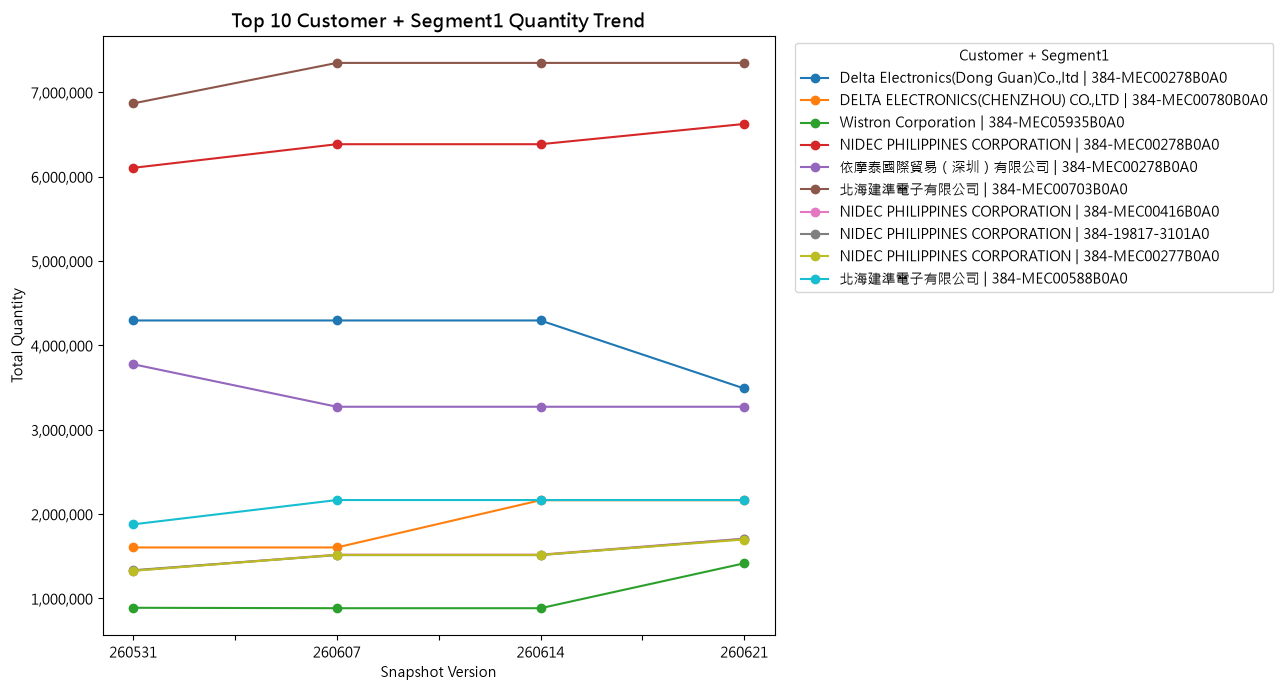

In [ ]:
# Movement Pattern
def classify_movement_pattern(row, change_cols):
    values = row[change_cols]

    has_positive = (values > 0).any()
    has_negative = (values < 0).any()

    if has_positive and has_negative:
        return "上下波動"

    if has_positive and not has_negative:
        return "持續增加"

    if has_negative and not has_positive:
        return "持續減少"

    return "無變動"


# ============================================================
# Build Customer + Segment1 Snapshot Quantity Trend
# ============================================================

def build_snapshot_qty_trend(
    snapshots,
    snapshot_files
):
    all_summary = []

    for file_name in snapshot_files:

        df = snapshots[file_name].copy()
        version = get_backup_version(file_name)

        # ----------------------------------------------------
        # 1. Non Hub Pick only
        # ----------------------------------------------------
        df["ORDER_TYPE_GROUP"] = (
            df["ORDER_TYPE_NAME"]
            .apply(classify_hub_pick)
        )

        df = df[
            df["ORDER_TYPE_GROUP"]
            .eq("Non Hub Pick")
        ].copy()

        # ----------------------------------------------------
        # 2. Numeric clean
        # ----------------------------------------------------
        df["ORDERED_QUANTITY"] = pd.to_numeric(
            df["ORDERED_QUANTITY"],
            errors="coerce"
        ).fillna(0)

        # ----------------------------------------------------
        # 3. Clean Customer and Segment1
        # ----------------------------------------------------
        df["CUSTOMER"] = clean_text_col(
            df["PARTY_NAME"]
        )

        df["SEGMENT1_CLEAN"] = clean_text_col(
            df["SEGMENT1"]
        )

        # Keep only rows with both Customer and Segment1
        df = df[
            df["CUSTOMER"].notna()
            &
            df["SEGMENT1_CLEAN"].notna()
        ].copy()

        # ----------------------------------------------------
        # 4. Build Customer + Segment1
        # ----------------------------------------------------
        df["CUSTOMER_SEGMENT"] = (
            df["CUSTOMER"]
            +
            " | "
            +
            df["SEGMENT1_CLEAN"]
        )

        # ----------------------------------------------------
        # 5. Snapshot summary
        # ----------------------------------------------------
        summary = (
            df
            .groupby(
                "CUSTOMER_SEGMENT",
                as_index=False
            )
            .agg(
                TOTAL_QTY=(
                    "ORDERED_QUANTITY",
                    "sum"
                ),

                LINE_COUNT=(
                    "LINE_ID",
                    "nunique"
                )
            )
        )

        summary["Version"] = version

        all_summary.append(summary)

    # --------------------------------------------------------
    # 6. Combine all snapshots
    # --------------------------------------------------------
    snapshot_summary_df = pd.concat(
        all_summary,
        ignore_index=True
    )

    # --------------------------------------------------------
    # 7. Pivot Snapshot Quantity
    # --------------------------------------------------------
    trend = (
        snapshot_summary_df
        .pivot_table(
            index="CUSTOMER_SEGMENT",
            columns="Version",
            values="TOTAL_QTY",
            aggfunc="sum",
            fill_value=0
        )
        .reset_index()
    )

    version_cols = [
        get_backup_version(file_name)
        for file_name in snapshot_files
    ]

    # Ensure every snapshot column exists
    for col in version_cols:
        if col not in trend.columns:
            trend[col] = 0

    trend = trend[
        ["CUSTOMER_SEGMENT"]
        +
        version_cols
    ]

    # --------------------------------------------------------
    # 8. Calculate week-to-week changes
    # --------------------------------------------------------
    change_cols = []

    for i in range(
        len(version_cols) - 1
    ):
        start_col = version_cols[i]
        end_col = version_cols[i + 1]

        change_col = (
            f"{start_col} → {end_col}"
        )

        trend[change_col] = (
            trend[end_col]
            -
            trend[start_col]
        )

        change_cols.append(
            change_col
        )

    # --------------------------------------------------------
    # 9. Total Net Change
    # --------------------------------------------------------
    trend["TOTAL_NET_CHANGE"] = (
        trend[version_cols[-1]]
        -
        trend[version_cols[0]]
    )

    # --------------------------------------------------------
    # 10. Total Movement
    # --------------------------------------------------------
    trend["TOTAL_MOVEMENT"] = (
        trend[change_cols]
        .abs()
        .sum(axis=1)
    )

    # --------------------------------------------------------
    # 11. Movement Pattern
    # --------------------------------------------------------
    trend["MOVEMENT_PATTERN"] = (
        trend.apply(
            lambda row:
                classify_movement_pattern(
                    row,
                    change_cols
                ),
            axis=1
        )
    )

    # --------------------------------------------------------
    # 12. Rank by Total Movement
    # --------------------------------------------------------
    trend = (
        trend
        .sort_values(
            [
                "TOTAL_MOVEMENT",
                "CUSTOMER_SEGMENT"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    trend["MOVEMENT_RANK"] = (
        trend.index
        +
        1
    )

    return (
        trend,
        version_cols,
        change_cols
    )


# ============================================================
# Run Customer + Segment1 Movement Analysis
# ============================================================

customer_segment_snapshot_movement_df, version_cols, change_cols = (
    build_snapshot_qty_trend(
        snapshots=snapshots,
        snapshot_files=SNAPSHOT_FILES
    )
)


# ============================================================
# Display Top 10 Customer + Segment1 Movement
# ============================================================

display_cols_customer_segment = (
    [
        "MOVEMENT_RANK",
        "CUSTOMER_SEGMENT"
    ]
    +
    version_cols
    +
    change_cols
    +
    [
        "TOTAL_NET_CHANGE",
        "TOTAL_MOVEMENT",
        "MOVEMENT_PATTERN"
    ]
)

display(
    customer_segment_snapshot_movement_df[
        display_cols_customer_segment
    ]
    .head(10)
    .style
    .format({
        **{
            col: "{:,.0f}"
            for col in version_cols
        },

        **{
            col: "{:+,.0f}"
            for col in change_cols
        },

        "TOTAL_NET_CHANGE":
            "{:+,.0f}",

        "TOTAL_MOVEMENT":
            "{:,.0f}",

        "MOVEMENT_RANK":
            "{:,.0f}"
    })
    .hide(axis="index")
)


# ============================================================
# Chart: Top 10 Customer + Segment1 Quantity Trend
# ============================================================

top_customer_segments = (
    customer_segment_snapshot_movement_df
    .head(10)[
        "CUSTOMER_SEGMENT"
    ]
    .tolist()
)

customer_segment_plot_df = (
    customer_segment_snapshot_movement_df[
        customer_segment_snapshot_movement_df[
            "CUSTOMER_SEGMENT"
        ].isin(top_customer_segments)
    ]
    .set_index(
        "CUSTOMER_SEGMENT"
    )
)

customer_segment_plot_df = (
    customer_segment_plot_df[
        version_cols
    ]
    .T
)

ax = customer_segment_plot_df.plot(
    kind="line",
    marker="o",
    figsize=(13, 7)
)

ax.set_title(
    "Top 10 Customer + Segment1 Quantity Trend",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Snapshot Version"
)

ax.set_ylabel(
    "Total Quantity"
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _:
            f"{x:,.0f}"
    )
)

ax.legend(
    title="Customer + Segment1",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
print("Customer + Segment1 Movement Pattern")

print(
    customer_segment_snapshot_movement_df[
        "MOVEMENT_PATTERN"
    ].value_counts()
)

Customer + Segment1 Movement Pattern
MOVEMENT_PATTERN
無變動     11587
持續增加     1356
持續減少      196
上下波動       40
Name: count, dtype: int64


In [ ]:
# Awaiting Shipping + Non Hub Pick Summary 
awaiting_summary = []

for version, df in snapshots.items():

    temp = df.copy()

    temp["ORDER_TYPE_NAME_CLEAN"] = (
        temp["ORDER_TYPE_NAME"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    temp["FLOW_STATUS_CODE_CLEAN"] = (
        temp["FLOW_STATUS_CODE"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    temp = temp[
        (temp["FLOW_STATUS_CODE_CLEAN"] == "AWAITING_SHIPPING") &
        (temp["ORDER_TYPE_NAME_CLEAN"] != "HUB PICK UP")
    ].copy()

    version_clean = get_backup_version(version)

    awaiting_summary.append({
        "Version": version_clean,
        "LINE_COUNT": temp["LINE_ID"].nunique(),
        "TOTAL_QTY": temp["ORDERED_QUANTITY"].sum()
    })

awaiting_summary_df = pd.DataFrame(awaiting_summary)

awaiting_summary_df["QTY_CHANGE"] = awaiting_summary_df["TOTAL_QTY"].diff()

awaiting_summary_df["QTY_CHANGE_%"] = (
    awaiting_summary_df["QTY_CHANGE"]
    / awaiting_summary_df["TOTAL_QTY"].shift(1)
    * 100
)

display(
    awaiting_summary_df.style
    .format({
        "LINE_COUNT": "{:,.0f}",
        "TOTAL_QTY": "{:,.0f}",
        "QTY_CHANGE": "{:+,.0f}",
        "QTY_CHANGE_%": "{:+.2f}%"
    })
    .hide(axis="index")
)

Version,LINE_COUNT,TOTAL_QTY,QTY_CHANGE,QTY_CHANGE_%
260531,"6,669","20,775,104",+nan,+nan%
260607,"6,695","21,348,525","+573,421",+2.76%
260614,"6,938","21,829,766","+481,241",+2.25%
260621,"7,167","22,871,426","+1,041,660",+4.77%


In [ ]:
request_distribution = []

for version, df in snapshots.items():

    temp = df.copy()

    temp["ORDER_TYPE_NAME_CLEAN"] = (
        temp["ORDER_TYPE_NAME"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    temp = temp[
        (temp["FLOW_STATUS_CODE"] == "AWAITING_SHIPPING") &
        (temp["ORDER_TYPE_NAME_CLEAN"] != "HUB PICK UP") &
        (temp["REQUEST_DATE"].notna())
    ].copy()

    temp["REQUEST_MONTH"] = (
        temp["REQUEST_DATE"]
        .dt.to_period("M")
        .astype(str)
    )

    version_clean = get_backup_version(version)

    summary = (
        temp
        .groupby("REQUEST_MONTH", as_index=False)
        .agg(
            LINE_COUNT=("LINE_ID", "nunique"),
            ORDERED_QTY=("ORDERED_QUANTITY", "sum")
        )
    )

    summary["Version"] = version_clean

    request_distribution.append(summary)


request_distribution_df = pd.concat(
    request_distribution,
    ignore_index=True
)

request_line_pivot = (
    request_distribution_df
    .pivot_table(
        index="REQUEST_MONTH",
        columns="Version",
        values="LINE_COUNT",
        fill_value=0
    )
)

request_qty_pivot = (
    request_distribution_df
    .pivot_table(
        index="REQUEST_MONTH",
        columns="Version",
        values="ORDERED_QTY",
        fill_value=0
    )
)

In [ ]:
def build_distribution_shift_summary(
    pivot_df,
    metric_name,
    start_col,
    end_col
):
    summary = (
        pivot_df[[start_col, end_col]]
        .copy()
        .reset_index()
    )

    summary["CHANGE"] = (
        summary[end_col]
        - summary[start_col]
    )

    summary["CHANGE_%"] = np.where(
        summary[start_col] != 0,
        summary["CHANGE"] / summary[start_col] * 100,
        np.nan
    )

    summary["METRIC"] = metric_name
    summary["Comparison"] = f"{start_col} → {end_col}"

    return summary[
        [
            "REQUEST_MONTH",
            start_col,
            end_col,
            "CHANGE",
            "CHANGE_%",
            "METRIC",
            "Comparison"
        ]
    ]


def display_shift_top_tables(
    shift_summary_df,
    title,
    top_n=5
):
    comparison = shift_summary_df["Comparison"].iloc[0]
    start_col, end_col = comparison.split(" → ")

    display_cols = [
        "REQUEST_MONTH",
        start_col,
        end_col,
        "CHANGE",
        "CHANGE_%"
    ]

    top_increase = (
        shift_summary_df
        .sort_values("CHANGE", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    top_decrease = (
        shift_summary_df
        .sort_values("CHANGE", ascending=True)
        .head(top_n)
        .reset_index(drop=True)
    )

    print(f"{title} - Top Increase")
    display(
        top_increase[display_cols]
        .style
        .format({
            start_col: "{:,.0f}",
            end_col: "{:,.0f}",
            "CHANGE": "{:+,.0f}",
            "CHANGE_%": "{:+.1f}%"
        })
        .hide(axis="index")
    )

    print(f"{title} - Top Decrease")
    display(
        top_decrease[display_cols]
        .style
        .format({
            start_col: "{:,.0f}",
            end_col: "{:,.0f}",
            "CHANGE": "{:+,.0f}",
            "CHANGE_%": "{:+.1f}%"
        })
        .hide(axis="index")
    )


version_cols = list(request_line_pivot.columns)

all_line_shift_summary = []
all_qty_shift_summary = []

for i in range(len(version_cols) - 1):

    start_col = version_cols[i]
    end_col = version_cols[i + 1]

    all_line_shift_summary.append(
        build_distribution_shift_summary(
            request_line_pivot,
            "Line Count",
            start_col,
            end_col
        )
    )

    all_qty_shift_summary.append(
        build_distribution_shift_summary(
            request_qty_pivot,
            "Ordered Quantity",
            start_col,
            end_col
        )
    )

line_shift_summary_by_comparison_df = pd.concat(
    all_line_shift_summary,
    ignore_index=True
)

qty_shift_summary_by_comparison_df = pd.concat(
    all_qty_shift_summary,
    ignore_index=True
)


for comparison in line_shift_summary_by_comparison_df["Comparison"].unique():
    print(f"Comparison: {comparison}")
    line_temp = line_shift_summary_by_comparison_df[
        line_shift_summary_by_comparison_df["Comparison"] == comparison
    ].copy()

    qty_temp = qty_shift_summary_by_comparison_df[
        qty_shift_summary_by_comparison_df["Comparison"] == comparison
    ].copy()

    display_shift_top_tables(
        line_temp,
        "Awaiting Request Month - Line Count"
    )

    display_shift_top_tables(
        qty_temp,
        "Awaiting Request Month - Quantity"
    )


overall_start = version_cols[0]
overall_end = version_cols[-1]
overall_line_shift_summary_df = build_distribution_shift_summary(
    request_line_pivot,
    "Line Count",
    overall_start,
    overall_end
)

overall_qty_shift_summary_df = build_distribution_shift_summary(
    request_qty_pivot,
    "Ordered Quantity",
    overall_start,
    overall_end
)

print(f"Overall Comparison: {overall_start} → {overall_end}")

display_shift_top_tables(
    overall_line_shift_summary_df,
    "Overall Awaiting Request Month - Line Count"
)

display_shift_top_tables(
    overall_qty_shift_summary_df,
    "Overall Awaiting Request Month - Quantity"
)

Comparison: 260531 → 260607
Awaiting Request Month - Line Count - Top Increase


REQUEST_MONTH,260531,260607,CHANGE,CHANGE_%
2026-07,"1,201","1,545",+344,+28.6%
2026-06,"2,996","3,122",+126,+4.2%
2026-08,442,555,+113,+25.6%
2026-09,160,250,+90,+56.2%
2026-11,48,56,+8,+16.7%


Awaiting Request Month - Line Count - Top Decrease


REQUEST_MONTH,260531,260607,CHANGE,CHANGE_%
2026-05,909,306,-603,-66.3%
2026-04,161,120,-41,-25.5%
2029-12,184,171,-13,-7.1%
2026-01,12,6,-6,-50.0%
2026-03,79,76,-3,-3.8%


Awaiting Request Month - Quantity - Top Increase


...

REQUEST_MONTH,260531,260621,CHANGE,CHANGE_%
2026-06,"2,996","2,082",-914,-30.5%
2026-05,909,174,-735,-80.9%
2026-04,161,87,-74,-46.0%
2029-12,184,157,-27,-14.7%
2026-03,79,62,-17,-21.5%


Overall Awaiting Request Month - Quantity - Top Increase


REQUEST_MONTH,260531,260621,CHANGE,CHANGE_%
2026-07,"6,089,674","10,607,963","+4,518,289",+74.2%
2026-08,"804,642","4,253,403","+3,448,761",+428.6%
2026-09,"342,121","1,017,809","+675,688",+197.5%
2026-10,"134,148","305,438","+171,290",+127.7%
2026-12,"61,067","130,583","+69,516",+113.8%


Overall Awaiting Request Month - Quantity - Top Decrease


REQUEST_MONTH,260531,260621,CHANGE,CHANGE_%
2026-06,"10,651,100","5,248,646","-5,402,454",-50.7%
2026-05,"1,576,564","393,001","-1,183,563",-75.1%
2026-04,"394,644","173,891","-220,753",-55.9%
2029-12,"378,774","328,400","-50,374",-13.3%
2026-01,"46,256","3,506","-42,750",-92.4%


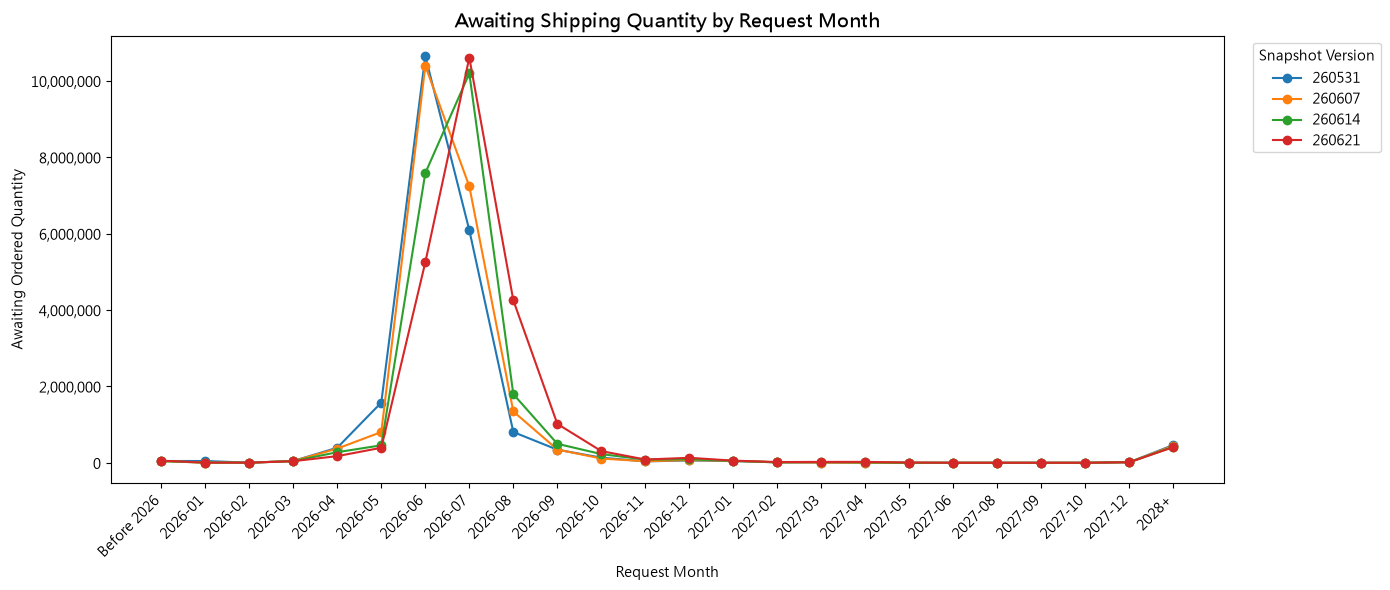

In [ ]:
request_distribution = []
for version, df in snapshots.items():

    temp = df.copy()
    temp["ORDER_TYPE_NAME_CLEAN"] = (
        temp["ORDER_TYPE_NAME"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    temp["FLOW_STATUS_CODE_CLEAN"] = (
        temp["FLOW_STATUS_CODE"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    temp = temp[
        (
            temp["FLOW_STATUS_CODE_CLEAN"]
            == "AWAITING_SHIPPING"
        )
        &
        (
            temp["ORDER_TYPE_NAME_CLEAN"]
            != "HUB PICK UP"
        )
        &
        (
            temp["REQUEST_DATE"].notna()
        )
    ].copy()

    temp["REQUEST_YEAR"] = (
        temp["REQUEST_DATE"]
        .dt.year
    )
    temp["REQUEST_MONTH_GROUP"] = np.select(
        [
            temp["REQUEST_YEAR"] < 2026,
            temp["REQUEST_YEAR"] >= 2028
        ],
        [
            "Before 2026",
            "2028+"
        ],
        default=(
            temp["REQUEST_DATE"]
            .dt.to_period("M")
            .astype(str)
        )
    )

    version_clean = get_backup_version(
        version
    )

    summary = (
        temp
        .groupby(
            "REQUEST_MONTH_GROUP",
            as_index=False
        )
        .agg(
            LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            ORDERED_QTY=(
                "ORDERED_QUANTITY",
                "sum"
            )
        )
    )

    summary["Version"] = version_clean

    request_distribution.append(
        summary
    )

request_distribution_df = pd.concat(
    request_distribution,
    ignore_index=True
)

request_qty_trend_df = (
    request_distribution_df
    .pivot_table(
        index="REQUEST_MONTH_GROUP",
        columns="Version",
        values="ORDERED_QTY",
        aggfunc="sum",
        fill_value=0
    )
)

monthly_groups = sorted(
    [
        x
        for x in request_qty_trend_df.index
        if x not in [
            "Before 2026",
            "2028+"
        ]
    ]
)

month_order = []

if "Before 2026" in request_qty_trend_df.index:
    month_order.append(
        "Before 2026"
    )

month_order.extend(
    monthly_groups
)

if "2028+" in request_qty_trend_df.index:
    month_order.append(
        "2028+"
    )

request_qty_trend_df = (
    request_qty_trend_df
    .reindex(month_order)
)

ax = request_qty_trend_df.plot(
    kind="line",
    marker="o",
    figsize=(14, 6)
)

ax.set_title(
    "Awaiting Shipping Quantity by Request Month",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Request Month"
)

ax.set_ylabel(
    "Awaiting Ordered Quantity"
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _:
            f"{x:,.0f}"
    )
)

ax.set_xticks(
    range(
        len(
            request_qty_trend_df.index
        )
    )
)

ax.set_xticklabels(
    request_qty_trend_df.index,
    rotation=45,
    ha="right"
)

ax.legend(
    title="Snapshot Version",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

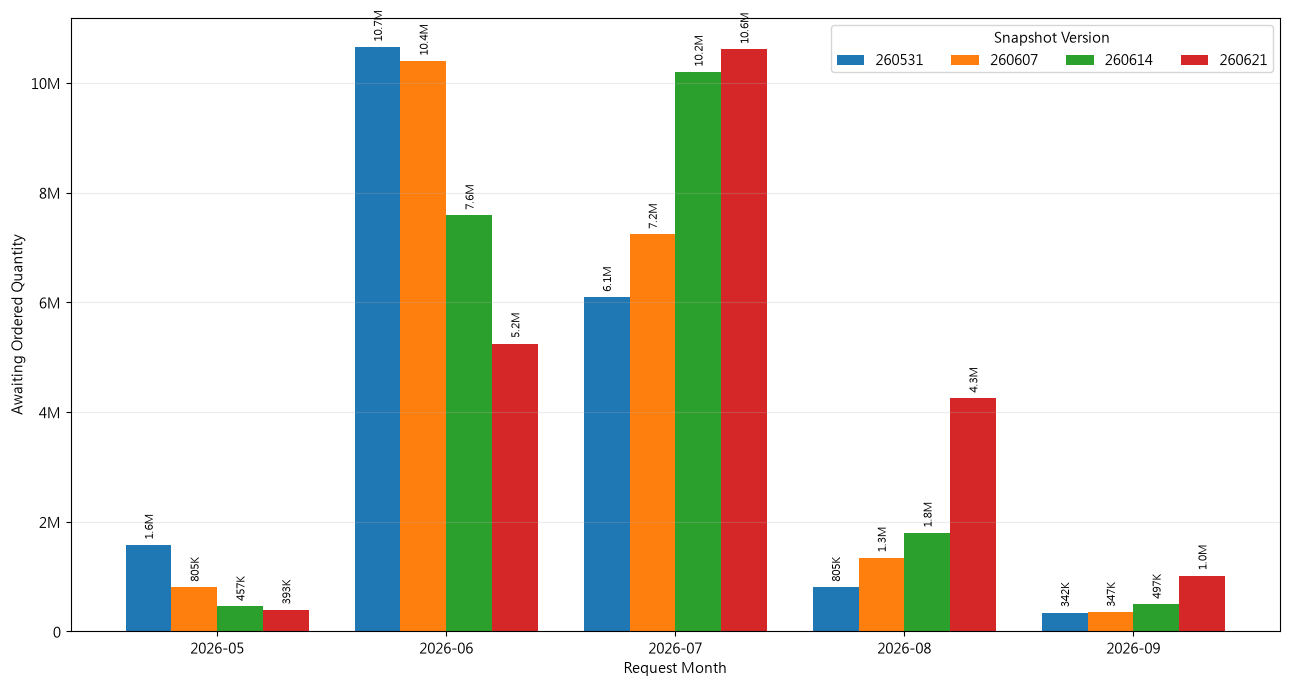

In [ ]:
focus_months = [
    "2026-05",
    "2026-06",
    "2026-07",
    "2026-08",
    "2026-09"
]

focus_months = [
    month
    for month in focus_months
    if month in request_qty_trend_df.index
]


version_order = [
    get_backup_version(file_name)
    for file_name in SNAPSHOT_FILES
]

version_order = [
    version
    for version in version_order
    if version in request_qty_trend_df.columns
]


plot_df = (
    request_qty_trend_df
    .loc[
        focus_months,
        version_order
    ]
    .copy()
)
x = np.arange(
    len(plot_df.index)
)

number_of_versions = len(
    plot_df.columns
)

group_width = 0.80

bar_width = (
    group_width
    /
    number_of_versions
)

fig, ax = plt.subplots(
    figsize=(13, 7)
)

for version_index, version in enumerate(
    plot_df.columns
):

    offset = (
        version_index
        -
        (number_of_versions - 1) / 2
    ) * bar_width

    bars = ax.bar(
        x + offset,
        plot_df[version],
        width=bar_width,
        label=version
    )

    for bar in bars:

        value = bar.get_height()

        if value >= 1_000_000:
            label = (
                f"{value / 1_000_000:.1f}M"
            )

        elif value >= 1_000:
            label = (
                f"{value / 1_000:.0f}K"
            )

        else:
            label = (
                f"{value:,.0f}"
            )

        ax.annotate(
            label,
            xy=(
                bar.get_x()
                +
                bar.get_width() / 2,
                value
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

ax.set_xlabel(
    "Request Month"
)

ax.set_ylabel(
    "Awaiting Ordered Quantity"
)

ax.set_xticks(x)

ax.set_xticklabels(
    plot_df.index
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _:
            (
                f"{value / 1_000_000:.0f}M"
                if value >= 1_000_000
                else f"{value / 1_000:.0f}K"
                if value >= 1_000
                else f"{value:,.0f}"
            )
    )
)

ax.legend(
    title="Snapshot Version",
    ncol=4,
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [ ]:
# PRICE
def build_price_impact_dataset(
    data1_name,
    data2_name
):
    comparison = get_comparison_label(
        data1_name,
        data2_name
    )

    merged = merged_base_map[
        comparison
    ].copy()

    text_cols = [
        "MATCH_STATUS",
        "FLOW_STATUS_CODE_data1",
        "FLOW_STATUS_CODE_data2",
        "ORDER_TYPE_NAME_data1",
        "ORDER_TYPE_NAME_data2",
        "LINE_SET_ID_data1",
        "LINE_SET_ID_data2"
    ]

    for col in text_cols:
        if col in merged.columns:
            merged[col] = (
                merged[col]
                .fillna("")
                .astype(str)
                .str.strip()
            )

    numeric_cols = [
        "US_PRICE_data1",
        "US_PRICE_data2",
        "ORDERED_QUANTITY_data1",
        "ORDERED_QUANTITY_data2"
    ]

    for col in numeric_cols:
        if col in merged.columns:
            merged[col] = (
                pd.to_numeric(
                    merged[col],
                    errors="coerce"
                )
                .fillna(0)
            )

    merged["ORDER_TYPE_NAME_BASE"] = (
        merged["ORDER_TYPE_NAME_data1"]
        .replace("", pd.NA)
        .fillna(
            merged["ORDER_TYPE_NAME_data2"]
            .replace("", pd.NA)
        )
        .fillna("")
    )

    merged["ORDER_TYPE_GROUP"] = (
        merged["ORDER_TYPE_NAME_BASE"]
        .apply(classify_hub_pick)
    )

    price_df = merged[
        merged["ORDER_TYPE_GROUP"]
        .eq("Non Hub Pick")
    ].copy()

    data1_df = snapshots[
        data1_name
    ].copy()

    if "LINE_SET_ID" in data1_df.columns:
        data1_line_set_ids = set(
            data1_df["LINE_SET_ID"]
            .fillna("")
            .astype(str)
            .str.strip()
        )

        data1_line_set_ids.discard("")

    else:
        data1_line_set_ids = set()

    if "LINE_SET_ID_data2" in price_df.columns:
        data2_line_set_id = (
            price_df["LINE_SET_ID_data2"]
            .fillna("")
            .astype(str)
            .str.strip()
        )

    else:
        data2_line_set_id = pd.Series(
            "",
            index=price_df.index,
            dtype="string"
        )

    is_new = (
        price_df["MATCH_STATUS"]
        .str.upper()
        .eq("NEW")
    )

    has_line_set_id = (
        data2_line_set_id.ne("")
    )

    line_set_existed_in_data1 = (
        data2_line_set_id
        .isin(data1_line_set_ids)
    )

    is_split_line = (
        is_new
        &
        has_line_set_id
        &
        line_set_existed_in_data1
    )

    is_true_new = (
        is_new
        &
        ~is_split_line
    )

    price_df["NEW_SPLIT_TYPE"] = np.select(
        [
            is_true_new,
            is_split_line
        ],
        [
            "True New",
            "Split Line"
        ],
        default="Not New"
    )

    price_df["DATE_CHANGE"] = (
        price_df.apply(
            date_change,
            axis=1
        )
    )

    rev_month_1 = (
        price_df["EST_REV_MONTH_data1"]
        .dt.to_period("M")
    )

    rev_month_2 = (
        price_df["EST_REV_MONTH_data2"]
        .dt.to_period("M")
    )

    both_missing_rev_month = (
        rev_month_1.isna()
        &
        rev_month_2.isna()
    )

    price_df["REV_MONTH_CHANGE"] = (
        (~both_missing_rev_month)
        &
        (rev_month_1 != rev_month_2)
    ).map({
        True: "Yes",
        False: "No"
    })

    price_df["PRICE_DIFF"] = (
        price_df["US_PRICE_data2"]
        -
        price_df["US_PRICE_data1"]
    )

    price_df["PRICE_DIFF_%"] = np.where(
        price_df["US_PRICE_data1"] != 0,
        (
            price_df["PRICE_DIFF"]
            /
            price_df["US_PRICE_data1"]
            *
            100
        ),
        np.nan
    )

    p1 = price_df["US_PRICE_data1"]
    p2 = price_df["US_PRICE_data2"]

    true_new_mask = (
        price_df["NEW_SPLIT_TYPE"]
        .eq("True New")
    )

    not_true_new_mask = (
        ~true_new_mask
    )

    price_df["PRICE_CHANGE_DIRECTION"] = np.select(
        [
            true_new_mask,
            (
                not_true_new_mask
                &
                (p1 > 0)
                &
                (p2 > 0)
                &
                (p2 > p1)
            ),

            (
                not_true_new_mask
                &
                (p1 > 0)
                &
                (p2 > 0)
                &
                (p2 < p1)
            ),

            (
                not_true_new_mask
                &
                (p1 == p2)
            ),

            (
                not_true_new_mask
                &
                (p1 == 0)
                &
                (p2 > 0)
            ),

            (
                not_true_new_mask
                &
                (p1 > 0)
                &
                (p2 == 0)
            )
        ],
        [
            "True New",
            "Price Increase",
            "Price Decrease",
            "Price No Change",
            "Zero to Price",
            "Price to Zero"
        ],
        default="Other Non-Comparable"
    )

    price_df["PRICE_CHANGE"] = np.where(
        price_df["PRICE_CHANGE_DIRECTION"].isin([
            "Price Increase",
            "Price Decrease"
        ]),
        "Yes",
        "No"
    )

    # Optional future Price × Quantity analysis
    price_df["PRICE_REVENUE_IMPACT"] = (
        price_df["PRICE_DIFF"]
        *
        price_df["ORDERED_QUANTITY_data2"]
    )

    price_df["Comparison"] = comparison

    return price_df


# ============================================================
# PRICE LAYER 1
# Denominator: all Non Hub Pick unique LINE_ID
# ============================================================

def analyze_price_layer1(
    price_df,
    comparison_name
):
    df = price_df.copy()
    total_non_hub_line_count = (
        df["LINE_ID"]
        .nunique()
    )

    direction_count = (
        df
        .groupby(
            "PRICE_CHANGE_DIRECTION"
        )["LINE_ID"]
        .nunique()
    )

    increase_count = int(
        direction_count.get(
            "Price Increase",
            0
        )
    )

    decrease_count = int(
        direction_count.get(
            "Price Decrease",
            0
        )
    )

    no_change_count = int(
        direction_count.get(
            "Price No Change",
            0
        )
    )

    zero_to_price_count = int(
        direction_count.get(
            "Zero to Price",
            0
        )
    )

    price_to_zero_count = int(
        direction_count.get(
            "Price to Zero",
            0
        )
    )

    true_new_count = int(
        direction_count.get(
            "True New",
            0
        )
    )

    other_non_comparable_count = int(
        direction_count.get(
            "Other Non-Comparable",
            0
        )
    )

    changed_line_count = (
        increase_count
        +
        decrease_count
    )

    if total_non_hub_line_count > 0:

        increase_pct = (
            increase_count
            /
            total_non_hub_line_count
            *
            100
        )

        decrease_pct = (
            decrease_count
            /
            total_non_hub_line_count
            *
            100
        )

        no_change_pct = (
            no_change_count
            /
            total_non_hub_line_count
            *
            100
        )

        changed_pct = (
            changed_line_count
            /
            total_non_hub_line_count
            *
            100
        )

        zero_to_price_pct = (
            zero_to_price_count
            /
            total_non_hub_line_count
            *
            100
        )

        price_to_zero_pct = (
            price_to_zero_count
            /
            total_non_hub_line_count
            *
            100
        )

        true_new_pct = (
            true_new_count
            /
            total_non_hub_line_count
            *
            100
        )

        other_non_comparable_pct = (
            other_non_comparable_count
            /
            total_non_hub_line_count
            *
            100
        )

    else:
        increase_pct = 0
        decrease_pct = 0
        no_change_pct = 0
        changed_pct = 0
        zero_to_price_pct = 0
        price_to_zero_pct = 0
        true_new_pct = 0
        other_non_comparable_pct = 0

    direction_summary = (
        df
        .groupby(
            [
                "Comparison",
                "PRICE_CHANGE_DIRECTION"
            ],
            as_index=False
        )
        .agg(
            LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            TOTAL_PRICE_REVENUE_IMPACT=(
                "PRICE_REVENUE_IMPACT",
                "sum"
            )
        )
    )

    direction_order = [
        "Price Increase",
        "Price Decrease",
        "Price No Change",
        "Zero to Price",
        "Price to Zero",
        "True New",
        "Other Non-Comparable"
    ]

    direction_summary[
        "PRICE_CHANGE_DIRECTION"
    ] = pd.Categorical(
        direction_summary[
            "PRICE_CHANGE_DIRECTION"
        ],
        categories=direction_order,
        ordered=True
    )

    direction_summary = (
        direction_summary
        .sort_values(
            [
                "Comparison",
                "PRICE_CHANGE_DIRECTION"
            ]
        )
        .reset_index(drop=True)
    )

    layer1_summary = pd.DataFrame({
        "Comparison": [
            comparison_name
        ],

        "Total_Non_Hub_Line_Count": [
            total_non_hub_line_count
        ],

        "Price_Increase_Line_Count": [
            increase_count
        ],

        "Price_Increase_%": [
            increase_pct
        ],

        "Price_Decrease_Line_Count": [
            decrease_count
        ],

        "Price_Decrease_%": [
            decrease_pct
        ],

        "Price_No_Change_Line_Count": [
            no_change_count
        ],

        "Price_No_Change_%": [
            no_change_pct
        ],

        "Price_Changed_Line_Count": [
            changed_line_count
        ],

        "Price_Changed_Line_%": [
            changed_pct
        ],

        "Zero_to_Price_Line_Count": [
            zero_to_price_count
        ],

        "Zero_to_Price_%": [
            zero_to_price_pct
        ],

        "Price_to_Zero_Line_Count": [
            price_to_zero_count
        ],

        "Price_to_Zero_%": [
            price_to_zero_pct
        ],

        "True_New_Line_Count": [
            true_new_count
        ],

        "True_New_%": [
            true_new_pct
        ],

        "Other_Non_Comparable_Line_Count": [
            other_non_comparable_count
        ],

        "Other_Non_Comparable_%": [
            other_non_comparable_pct
        ]
    })

    detail_cols = [
        "Comparison",
        "LINE_ID",
        "MATCH_STATUS",
        "NEW_SPLIT_TYPE",
        "FLOW_STATUS_CODE_data1",
        "FLOW_STATUS_CODE_data2",
        "PARTY_NAME_data1",
        "PARTY_NAME_data2",
        "PROJECT_CODE_data1",
        "PROJECT_CODE_data2",
        "SEGMENT1_data1",
        "SEGMENT1_data2",
        "ORDER_TYPE_NAME_BASE",
        "ORDER_TYPE_GROUP",
        "US_PRICE_data1",
        "US_PRICE_data2",
        "PRICE_DIFF",
        "PRICE_DIFF_%",
        "PRICE_CHANGE_DIRECTION",
        "ORDERED_QUANTITY_data1",
        "ORDERED_QUANTITY_data2",
        "PRICE_REVENUE_IMPACT",
        "DATE_CHANGE",
        "REV_MONTH_CHANGE"
    ]

    detail_cols = [
        col
        for col in detail_cols
        if col in df.columns
    ]

    price_change_detail = (
        df[detail_cols]
        .copy()
        .sort_values(
            [
                "PRICE_CHANGE_DIRECTION",
                "PRICE_REVENUE_IMPACT"
            ],
            ascending=[
                True,
                True
            ]
        )
    )

    return {
        "summary": layer1_summary,
        "direction_summary": direction_summary,
        "detail": price_change_detail
    }

all_price_layer1_summaries = []
all_price_direction_summaries = []
all_price_change_details = []

for data1_name, data2_name in SNAPSHOT_PAIRS:

    comparison_name = get_comparison_label(
        data1_name,
        data2_name
    )

    price_df = build_price_impact_dataset(
        data1_name=data1_name,
        data2_name=data2_name
    )

    result = analyze_price_layer1(
        price_df=price_df,
        comparison_name=comparison_name
    )

    all_price_layer1_summaries.append(
        result["summary"]
    )

    all_price_direction_summaries.append(
        result["direction_summary"]
    )

    all_price_change_details.append(
        result["detail"]
    )


price_layer1_summary_df = pd.concat(
    all_price_layer1_summaries,
    ignore_index=True
)

all_price_direction_summary_df = pd.concat(
    all_price_direction_summaries,
    ignore_index=True
)

all_price_change_detail_df = pd.concat(
    all_price_change_details,
    ignore_index=True
)

display(
    price_layer1_summary_df
    .style
    .format({
        "Total_Non_Hub_Line_Count":
            "{:,.0f}",

        "Price_Increase_Line_Count":
            "{:,.0f}",

        "Price_Increase_%":
            "{:.2f}%",

        "Price_Decrease_Line_Count":
            "{:,.0f}",

        "Price_Decrease_%":
            "{:.2f}%",

        "Price_No_Change_Line_Count":
            "{:,.0f}",

        "Price_No_Change_%":
            "{:.2f}%",

        "Price_Changed_Line_Count":
            "{:,.0f}",

        "Price_Changed_Line_%":
            "{:.2f}%",

        "Zero_to_Price_Line_Count":
            "{:,.0f}",

        "Zero_to_Price_%":
            "{:.2f}%",

        "Price_to_Zero_Line_Count":
            "{:,.0f}",

        "Price_to_Zero_%":
            "{:.2f}%",

        "True_New_Line_Count":
            "{:,.0f}",

        "True_New_%":
            "{:.2f}%",

        "Other_Non_Comparable_Line_Count":
            "{:,.0f}",

        "Other_Non_Comparable_%":
            "{:.2f}%"
    })
    .hide(axis="index")
)

display(
    all_price_direction_summary_df
    .style
    .format({
        "LINE_COUNT":
            "{:,.0f}",

        "TOTAL_PRICE_REVENUE_IMPACT":
            "{:+,.0f}"
    })
    .hide(axis="index")
)

Comparison,Total_Non_Hub_Line_Count,Price_Increase_Line_Count,Price_Increase_%,Price_Decrease_Line_Count,Price_Decrease_%,Price_No_Change_Line_Count,Price_No_Change_%,Price_Changed_Line_Count,Price_Changed_Line_%,Zero_to_Price_Line_Count,Zero_to_Price_%,Price_to_Zero_Line_Count,Price_to_Zero_%,True_New_Line_Count,True_New_%,Other_Non_Comparable_Line_Count,Other_Non_Comparable_%
260531 → 260607,"81,014","3,928",4.85%,200,0.25%,"75,816",93.58%,"4,128",5.10%,282,0.35%,0,0.00%,788,0.97%,0,0.00%
260607 → 260614,"82,211",22,0.03%,32,0.04%,"80,901",98.41%,54,0.07%,367,0.45%,0,0.00%,889,1.08%,0,0.00%
260614 → 260621,"83,306",23,0.03%,38,0.05%,"82,138",98.60%,61,0.07%,407,0.49%,0,0.00%,700,0.84%,0,0.00%


Comparison,PRICE_CHANGE_DIRECTION,LINE_COUNT,TOTAL_PRICE_REVENUE_IMPACT
260531 → 260607,Price Increase,"3,928","+329,186"
260531 → 260607,Price Decrease,200,"-358,283"
260531 → 260607,Price No Change,"75,816",+0
260531 → 260607,Zero to Price,282,"+13,714,255"
260531 → 260607,True New,788,"+14,041,675"
260607 → 260614,Price Increase,22,"+179,423"
260607 → 260614,Price Decrease,32,"-292,630"
260607 → 260614,Price No Change,"80,901",+0
260607 → 260614,Zero to Price,367,"+12,278,709"
260607 → 260614,True New,889,"+23,783,952"


In [ ]:
def build_price_layer3_customer_segment(
    price_detail_df,
    top_n=10
):
    df = price_detail_df.copy()
    df = df[
        df["PRICE_CHANGE_DIRECTION"].isin([
            "Price Increase",
            "Price Decrease"
        ])
    ].copy()
    customer_data1 = clean_text_col(
        df["PARTY_NAME_data1"]
    )

    customer_data2 = clean_text_col(
        df["PARTY_NAME_data2"]
    )

    segment_data1 = clean_text_col(
        df["SEGMENT1_data1"]
    )

    segment_data2 = clean_text_col(
        df["SEGMENT1_data2"]
    )

    df["CUSTOMER"] = (
        customer_data2
        .fillna(customer_data1)
    )

    df["SEGMENT1"] = (
        segment_data2
        .fillna(segment_data1)
    )

    df = df[
        df["CUSTOMER"].notna()
        &
        df["SEGMENT1"].notna()
    ].copy()

    df["CUSTOMER_SEGMENT"] = (
        df["CUSTOMER"]
        +
        " | "
        +
        df["SEGMENT1"]
    )
    df["US_PRICE_data1"] = pd.to_numeric(
        df["US_PRICE_data1"],
        errors="coerce"
    )

    df["US_PRICE_data2"] = pd.to_numeric(
        df["US_PRICE_data2"],
        errors="coerce"
    )

    df = df[
        df["US_PRICE_data1"].notna()
        &
        df["US_PRICE_data2"].notna()
    ].copy()

    df["PRICE_DIFF"] = (
        df["US_PRICE_data2"]
        -
        df["US_PRICE_data1"]
    )

    df["ABS_PRICE_DIFF"] = (
        df["PRICE_DIFF"]
        .abs()
    )

    df["PRICE_INCREASE_AMOUNT"] = np.where(
        df["PRICE_DIFF"] > 0,
        df["PRICE_DIFF"],
        0
    )

    df["PRICE_DECREASE_AMOUNT"] = np.where(
        df["PRICE_DIFF"] < 0,
        df["PRICE_DIFF"],
        0
    )

    df["PRICE_INCREASE_FLAG"] = (
        df["PRICE_DIFF"] > 0
    ).astype(int)

    df["PRICE_DECREASE_FLAG"] = (
        df["PRICE_DIFF"] < 0
    ).astype(int)

    group_summary_df = (
        df
        .groupby(
            [
                "Comparison",
                "CUSTOMER_SEGMENT"
            ],
            as_index=False
        )
        .agg(
            PRICE_CHANGED_LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            PRICE_INCREASE_LINE_COUNT=(
                "PRICE_INCREASE_FLAG",
                "sum"
            ),

            PRICE_DECREASE_LINE_COUNT=(
                "PRICE_DECREASE_FLAG",
                "sum"
            ),

            TOTAL_PRICE_INCREASE=(
                "PRICE_INCREASE_AMOUNT",
                "sum"
            ),

            TOTAL_PRICE_DECREASE=(
                "PRICE_DECREASE_AMOUNT",
                "sum"
            ),

            NET_PRICE_CHANGE=(
                "PRICE_DIFF",
                "sum"
            ),

            # Main Layer 3 metric
            TOTAL_PRICE_MOVEMENT=(
                "ABS_PRICE_DIFF",
                "sum"
            )
        )
    )

    comparison_total_df = (
        df
        .groupby(
            "Comparison",
            as_index=False
        )
        .agg(
            OVERALL_PRICE_INCREASE=(
                "PRICE_INCREASE_AMOUNT",
                "sum"
            ),

            OVERALL_PRICE_DECREASE=(
                "PRICE_DECREASE_AMOUNT",
                "sum"
            ),

            OVERALL_NET_PRICE_CHANGE=(
                "PRICE_DIFF",
                "sum"
            ),

            OVERALL_TOTAL_PRICE_MOVEMENT=(
                "ABS_PRICE_DIFF",
                "sum"
            )
        )
    )

    group_summary_df = (
        group_summary_df
        .merge(
            comparison_total_df,
            on="Comparison",
            how="left"
        )
    )

    group_summary_df[
        "MOVEMENT_CONTRIBUTION_%"
    ] = np.where(
        group_summary_df[
            "OVERALL_TOTAL_PRICE_MOVEMENT"
        ] > 0,
        (
            group_summary_df[
                "TOTAL_PRICE_MOVEMENT"
            ]
            /
            group_summary_df[
                "OVERALL_TOTAL_PRICE_MOVEMENT"
            ]
            *
            100
        ),
        0
    )

    group_summary_df[
        "MAIN_PRICE_DIRECTION"
    ] = np.select(
        [
            group_summary_df[
                "NET_PRICE_CHANGE"
            ] > 0,

            group_summary_df[
                "NET_PRICE_CHANGE"
            ] < 0
        ],
        [
            "Net Price Increase",
            "Net Price Decrease"
        ],
        default="Net Zero / Mixed"
    )

    group_summary_df = (
        group_summary_df
        .sort_values(
            [
                "Comparison",
                "TOTAL_PRICE_MOVEMENT",
                "CUSTOMER_SEGMENT"
            ],
            ascending=[
                True,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    group_summary_df["RANK"] = (
        group_summary_df
        .groupby("Comparison")
        .cumcount()
        + 1
    )

    top_n_df = (
        group_summary_df[
            group_summary_df["RANK"] <= top_n
        ]
        .copy()
        .reset_index(drop=True)
    )

    top3_df = (
        group_summary_df[
            group_summary_df["RANK"] <= 3
        ]
        .groupby(
            "Comparison",
            as_index=False
        )
        .agg(
            TOP3_PRICE_MOVEMENT=(
                "TOTAL_PRICE_MOVEMENT",
                "sum"
            ),

            TOP3_MOVEMENT_CONTRIBUTION=(
                "MOVEMENT_CONTRIBUTION_%",
                "sum"
            )
        )
    )

    concentration_df = (
        comparison_total_df
        .merge(
            top3_df,
            on="Comparison",
            how="left"
        )
    )

    concentration_df[
        "TOP3_PRICE_MOVEMENT"
    ] = (
        concentration_df[
            "TOP3_PRICE_MOVEMENT"
        ]
        .fillna(0)
    )

    concentration_df[
        "TOP3_MOVEMENT_CONTRIBUTION"
    ] = (
        concentration_df[
            "TOP3_MOVEMENT_CONTRIBUTION"
        ]
        .fillna(0)
    )

    concentration_df["CONCENTRATION"] = np.select(
        [
            concentration_df[
                "TOP3_MOVEMENT_CONTRIBUTION"
            ] >= 70,

            concentration_df[
                "TOP3_MOVEMENT_CONTRIBUTION"
            ] >= 50
        ],
        [
            "Highly Concentrated",
            "Moderately Concentrated"
        ],
        default="Dispersed"
    )

    return {
        "full_summary": group_summary_df,
        "top10": top_n_df,
        "top3_concentration": concentration_df
    }


In [ ]:
customer_segment_price_layer3_result = (
    build_price_layer3_customer_segment(
        price_detail_df=
            all_price_change_detail_df,
        top_n=10
    )
)

customer_segment_price_layer3_full_df = (
    customer_segment_price_layer3_result[
        "full_summary"
    ]
)

customer_segment_price_layer3_top10_df = (
    customer_segment_price_layer3_result[
        "top10"
    ]
)

customer_segment_price_layer3_concentration_df = (
    customer_segment_price_layer3_result[
        "top3_concentration"
    ]
)

display_cols = [
    "Comparison",
    "RANK",
    "CUSTOMER_SEGMENT",
    "PRICE_CHANGED_LINE_COUNT",
    "TOTAL_PRICE_INCREASE",
    "TOTAL_PRICE_DECREASE",
    "NET_PRICE_CHANGE",
    "TOTAL_PRICE_MOVEMENT",
    "MOVEMENT_CONTRIBUTION_%",
    "MAIN_PRICE_DIRECTION"
]

display(
    customer_segment_price_layer3_top10_df[
        display_cols
    ]
    .style
    .format({
        "RANK":
            "{:,.0f}",

        "PRICE_CHANGED_LINE_COUNT":
            "{:,.0f}",

        "TOTAL_PRICE_INCREASE":
            "{:+,.2f}",

        "TOTAL_PRICE_DECREASE":
            "{:+,.2f}",

        "NET_PRICE_CHANGE":
            "{:+,.2f}",

        "TOTAL_PRICE_MOVEMENT":
            "{:,.2f}",

        "MOVEMENT_CONTRIBUTION_%":
            "{:.2f}%"
    })
    .hide(axis="index")
)

Comparison,RANK,CUSTOMER_SEGMENT,PRICE_CHANGED_LINE_COUNT,TOTAL_PRICE_INCREASE,TOTAL_PRICE_DECREASE,NET_PRICE_CHANGE,TOTAL_PRICE_MOVEMENT,MOVEMENT_CONTRIBUTION_%,MAIN_PRICE_DIRECTION
260531 → 260607,1,智銳達科技(杭州)有限公司 | 009-30000-000560,1,"+3,491.48",+0.00,"+3,491.48","3,491.48",26.86%,Net Price Increase
260531 → 260607,2,浪潮電子信息產業股份有限公司 | RM6925000701-03000,1,"+1,774.46",+0.00,"+1,774.46","1,774.46",13.65%,Net Price Increase
260531 → 260607,3,浪潮電子信息產業股份有限公司 | 009-30000-000750,1,"+1,703.77",+0.00,"+1,703.77","1,703.77",13.11%,Net Price Increase
260531 → 260607,4,廣達電腦股份有限公司 | 384-MIX01509S0A0,5,+951.15,+0.00,+951.15,951.15,7.32%,Net Price Increase
260531 → 260607,5,廣達電腦股份有限公司 | 384-MIX01510S0A0,5,+951.15,+0.00,+951.15,951.15,7.32%,Net Price Increase
260531 → 260607,6,浪潮電子信息產業股份有限公司 | 009-30000-000710,1,+597.68,+0.00,+597.68,597.68,4.60%,Net Price Increase
260531 → 260607,7,浪潮電子信息產業股份有限公司 | 009-30000-000740,1,+355.48,+0.00,+355.48,355.48,2.74%,Net Price Increase
260531 → 260607,8,山東博源計算機科技有限公司 | 384-MEC05968B0A0,1,+0.00,-198.40,-198.40,198.40,1.53%,Net Price Decrease
260531 → 260607,9,OVH SAS | RM41736-0030A0,25,+0.00,-158.78,-158.78,158.78,1.22%,Net Price Decrease
260531 → 260607,10,浪潮電子信息產業股份有限公司 | 009-30000-000730,1,+151.19,+0.00,+151.19,151.19,1.16%,Net Price Increase


Top 10 Customer + Segment1 Median US Price Movement


PRICE_MOVEMENT_RANK,CUSTOMER_SEGMENT,260531,260607,260614,260621,260531 → 260607,260607 → 260614,260614 → 260621,TOTAL_NET_PRICE_CHANGE,TOTAL_PRICE_MOVEMENT,COMPARABLE_PERIOD_COUNT,PRICE_MOVEMENT_PATTERN
1,智銳達科技(杭州)有限公司 | 009-30000-000560,"526,626.43","530,117.91","530,117.91","530,117.91","+3,491.48",+0.00,+0.00,"+3,491.48","3,491.48",3,持續增加
2,浪潮電子信息產業股份有限公司 | RM6925000701-03000,"2,233.27","4,007.73","4,007.73","4,007.73","+1,774.46",+0.00,+0.00,"+1,774.46","1,774.46",3,持續增加
3,浪潮電子信息產業股份有限公司 | 009-30000-000750,"256,982.28","258,686.05","258,686.05","258,686.05","+1,703.77",+0.00,+0.00,"+1,703.77","1,703.77",3,持續增加
4,浪潮電子信息產業股份有限公司 | 009-30000-000710,"90,149.50","90,747.18","90,747.18","90,747.18",+597.68,+0.00,+0.00,+597.68,597.68,3,持續增加
5,浪潮電子信息產業股份有限公司 | 009-30000-000740,"53,616.89","53,972.37","53,972.37","53,972.37",+355.48,+0.00,+0.00,+355.48,355.48,3,持續增加
6,雲尖信息技術股份有限公司 | RM6926000401-01000,"1,227.83","1,515.46","1,515.46","1,515.46",+287.63,+0.00,+0.00,+287.63,287.63,3,持續增加
7,仁寶電子科技(昆山)有限公司 | RM45300C3-0020A0,498.50,498.50,219.92,219.92,+0.00,-278.58,+0.00,-278.58,278.58,3,持續減少
8,山東博源計算機科技有限公司 | 384-MEC05968B0A0,225.31,26.91,26.91,26.91,-198.40,+0.00,+0.00,-198.40,198.40,3,持續減少
9,廣達電腦股份有限公司 | 384-MIX01509S0A0,86.60,86.60,276.83,276.83,+0.00,+190.23,+0.00,+190.23,190.23,3,持續增加
10,廣達電腦股份有限公司 | 384-MIX01510S0A0,86.60,86.60,276.83,276.83,+0.00,+190.23,+0.00,+190.23,190.23,3,持續增加



Customer + Segment1 Price Movement Pattern
PRICE_MOVEMENT_PATTERN
無變動     10503
持續增加      835
無法比較      161
持續減少      148
上下波動       22
Name: count, dtype: int64


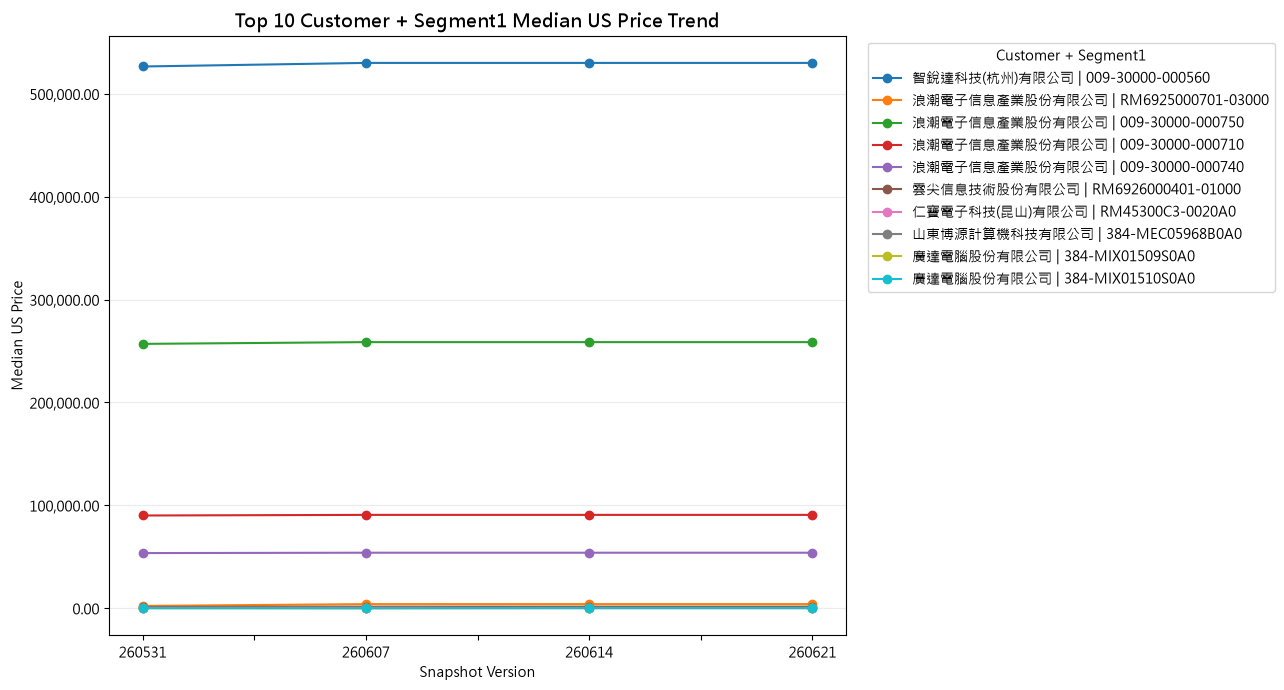

In [ ]:
def classify_price_movement_pattern(row, change_cols):

    values = pd.to_numeric(
        row[change_cols],
        errors="coerce"
    )

    valid_values = values.dropna()

    if valid_values.empty:
        return "無法比較"

    has_positive = (
        valid_values > 0
    ).any()

    has_negative = (
        valid_values < 0
    ).any()

    if has_positive and has_negative:
        return "上下波動"

    if has_positive and not has_negative:
        return "持續增加"

    if has_negative and not has_positive:
        return "持續減少"

    return "無變動"

def build_snapshot_price_trend(
    snapshots,
    snapshot_files
):
    all_summary = []

    for file_name in snapshot_files:

        df = snapshots[file_name].copy()

        version = get_backup_version(
            file_name
        )

        df["ORDER_TYPE_GROUP"] = (
            df["ORDER_TYPE_NAME"]
            .apply(classify_hub_pick)
        )

        df = df[
            df["ORDER_TYPE_GROUP"]
            .eq("Non Hub Pick")
        ].copy()

        df["US_PRICE"] = pd.to_numeric(
            df["US_PRICE"],
            errors="coerce"
        )

        df = df[
            df["US_PRICE"] > 0
        ].copy()

        df["CUSTOMER"] = clean_text_col(
            df["PARTY_NAME"]
        )

        df["SEGMENT1_CLEAN"] = clean_text_col(
            df["SEGMENT1"]
        )

        df = df[
            df["CUSTOMER"].notna()
            &
            df["SEGMENT1_CLEAN"].notna()
        ].copy()

        df["CUSTOMER_SEGMENT"] = (
            df["CUSTOMER"]
            +
            " | "
            +
            df["SEGMENT1_CLEAN"]
        )

        summary = (
            df
            .groupby(
                "CUSTOMER_SEGMENT",
                as_index=False
            )
            .agg(
                MEDIAN_US_PRICE=(
                    "US_PRICE",
                    "median"
                ),

                MIN_US_PRICE=(
                    "US_PRICE",
                    "min"
                ),

                MAX_US_PRICE=(
                    "US_PRICE",
                    "max"
                ),

                UNIQUE_PRICE_COUNT=(
                    "US_PRICE",
                    "nunique"
                ),

                LINE_COUNT=(
                    "LINE_ID",
                    "nunique"
                )
            )
        )

        summary["Version"] = version

        all_summary.append(
            summary
        )

    snapshot_price_summary_df = pd.concat(
        all_summary,
        ignore_index=True
    )

    version_cols = [
        get_backup_version(file_name)
        for file_name in snapshot_files
    ]

    trend = (
        snapshot_price_summary_df
        .pivot_table(
            index="CUSTOMER_SEGMENT",
            columns="Version",
            values="MEDIAN_US_PRICE",
            aggfunc="median"
        )
        .reset_index()
    )

    for col in version_cols:
        if col not in trend.columns:
            trend[col] = np.nan

    trend = trend[
        ["CUSTOMER_SEGMENT"]
        +
        version_cols
    ]

    change_cols = []

    for i in range(
        len(version_cols) - 1
    ):

        start_col = version_cols[i]
        end_col = version_cols[i + 1]

        change_col = (
            f"{start_col} → {end_col}"
        )

        comparable_mask = (
            trend[start_col].notna()
            &
            trend[end_col].notna()
        )

        trend[change_col] = np.where(
            comparable_mask,
            (
                trend[end_col]
                -
                trend[start_col]
            ),
            np.nan
        )

        change_cols.append(
            change_col
        )

    trend["COMPARABLE_PERIOD_COUNT"] = (
        trend[change_cols]
        .notna()
        .sum(axis=1)
    )

    first_version = version_cols[0]
    last_version = version_cols[-1]

    first_last_comparable = (
        trend[first_version].notna()
        &
        trend[last_version].notna()
    )

    trend["TOTAL_NET_PRICE_CHANGE"] = np.where(
        first_last_comparable,
        (
            trend[last_version]
            -
            trend[first_version]
        ),
        np.nan
    )

    trend["TOTAL_PRICE_MOVEMENT"] = (
        trend[change_cols]
        .abs()
        .sum(
            axis=1,
            min_count=1
        )
    )

    trend["PRICE_MOVEMENT_PATTERN"] = (
        trend.apply(
            lambda row:
                classify_price_movement_pattern(
                    row,
                    change_cols
                ),
            axis=1
        )
    )

    trend = (
        trend
        .sort_values(
            [
                "TOTAL_PRICE_MOVEMENT",
                "CUSTOMER_SEGMENT"
            ],
            ascending=[
                False,
                True
            ],
            na_position="last"
        )
        .reset_index(drop=True)
    )

    trend["PRICE_MOVEMENT_RANK"] = (
        trend.index
        +
        1
    )

    return {
        "trend": trend,
        "snapshot_summary": snapshot_price_summary_df,
        "version_cols": version_cols,
        "change_cols": change_cols
    }

customer_segment_price_movement_result = (
    build_snapshot_price_trend(
        snapshots=snapshots,
        snapshot_files=SNAPSHOT_FILES
    )
)

customer_segment_snapshot_price_movement_df = (
    customer_segment_price_movement_result[
        "trend"
    ]
)

customer_segment_snapshot_price_summary_df = (
    customer_segment_price_movement_result[
        "snapshot_summary"
    ]
)

price_version_cols = (
    customer_segment_price_movement_result[
        "version_cols"
    ]
)

price_change_cols = (
    customer_segment_price_movement_result[
        "change_cols"
    ]
)

price_display_cols = (
    [
        "PRICE_MOVEMENT_RANK",
        "CUSTOMER_SEGMENT"
    ]
    +
    price_version_cols
    +
    price_change_cols
    +
    [
        "TOTAL_NET_PRICE_CHANGE",
        "TOTAL_PRICE_MOVEMENT",
        "COMPARABLE_PERIOD_COUNT",
        "PRICE_MOVEMENT_PATTERN"
    ]
)

print(
    "Top 10 Customer + Segment1 "
    "Median US Price Movement"
)

display(
    customer_segment_snapshot_price_movement_df[
        price_display_cols
    ]
    .head(10)
    .style
    .format({
        **{
            col: "{:,.2f}"
            for col in price_version_cols
        },

        **{
            col: "{:+,.2f}"
            for col in price_change_cols
        },

        "TOTAL_NET_PRICE_CHANGE":
            "{:+,.2f}",

        "TOTAL_PRICE_MOVEMENT":
            "{:,.2f}",

        "COMPARABLE_PERIOD_COUNT":
            "{:,.0f}",

        "PRICE_MOVEMENT_RANK":
            "{:,.0f}"
    })
    .hide(axis="index")
)

print(
    "\nCustomer + Segment1 "
    "Price Movement Pattern"
)

print(
    customer_segment_snapshot_price_movement_df[
        "PRICE_MOVEMENT_PATTERN"
    ]
    .value_counts(
        dropna=False
    )
)

top_customer_segments = (
    customer_segment_snapshot_price_movement_df
    .dropna(
        subset=[
            "TOTAL_PRICE_MOVEMENT"
        ]
    )
    .head(10)[
        "CUSTOMER_SEGMENT"
    ]
    .tolist()
)

price_plot_df = (
    customer_segment_snapshot_price_movement_df[
        customer_segment_snapshot_price_movement_df[
            "CUSTOMER_SEGMENT"
        ].isin(top_customer_segments)
    ]
    .set_index(
        "CUSTOMER_SEGMENT"
    )
)

price_plot_df = (
    price_plot_df[
        price_version_cols
    ]
    .T
)

ax = price_plot_df.plot(
    kind="line",
    marker="o",
    figsize=(13, 7)
)

ax.set_title(
    "Top 10 Customer + Segment1 Median US Price Trend",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Snapshot Version"
)

ax.set_ylabel(
    "Median US Price"
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _:
            f"{x:,.2f}"
    )
)

ax.legend(
    title="Customer + Segment1",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [ ]:
price_top10_repeat_df = (
    customer_segment_price_layer3_top10_df[
        [
            "Comparison",
            "CUSTOMER_SEGMENT",
            "RANK",
            "TOTAL_PRICE_MOVEMENT",
            "MOVEMENT_CONTRIBUTION_%"
        ]
    ]
    .drop_duplicates(
        subset=[
            "Comparison",
            "CUSTOMER_SEGMENT"
        ]
    )
    .groupby(
        "CUSTOMER_SEGMENT",
        as_index=False
    )
    .agg(
        APPEAR_TIMES=(
            "Comparison",
            "nunique"
        ),

        COMPARISONS=(
            "Comparison",
            lambda x: ", ".join(
                sorted(
                    x.astype(str).unique()
                )
            )
        ),

        RANKS=(
            "RANK",
            lambda x: ", ".join(
                x.astype(int)
                 .astype(str)
                 .tolist()
            )
        ),

        BEST_RANK=(
            "RANK",
            "min"
        ),

        TOTAL_PRICE_MOVEMENT_ACROSS_WEEKS=(
            "TOTAL_PRICE_MOVEMENT",
            "sum"
        ),

        AVG_MOVEMENT_CONTRIBUTION=(
            "MOVEMENT_CONTRIBUTION_%",
            "mean"
        )
    )
    .sort_values(
        [
            "APPEAR_TIMES",
            "TOTAL_PRICE_MOVEMENT_ACROSS_WEEKS",
            "CUSTOMER_SEGMENT"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# Appeared 3 times
# ============================================================

price_top10_appear_3_times_df = (
    price_top10_repeat_df[
        price_top10_repeat_df[
            "APPEAR_TIMES"
        ] == 3
    ]
)

print("Price Top 10 出現 3 次")

display(
    price_top10_appear_3_times_df
    .style
    .format({
        "APPEAR_TIMES": "{:,.0f}",
        "BEST_RANK": "{:,.0f}",
        "TOTAL_PRICE_MOVEMENT_ACROSS_WEEKS": "{:,.2f}",
        "AVG_MOVEMENT_CONTRIBUTION": "{:.2f}%"
    })
    .hide(axis="index")
)


# ============================================================
# Appeared 2 times
# ============================================================

price_top10_appear_2_times_df = (
    price_top10_repeat_df[
        price_top10_repeat_df[
            "APPEAR_TIMES"
        ] == 2
    ]
)

print("Price Top 10 出現 2 次")

display(
    price_top10_appear_2_times_df
    .style
    .format({
        "APPEAR_TIMES": "{:,.0f}",
        "BEST_RANK": "{:,.0f}",
        "TOTAL_PRICE_MOVEMENT_ACROSS_WEEKS": "{:,.2f}",
        "AVG_MOVEMENT_CONTRIBUTION": "{:.2f}%"
    })
    .hide(axis="index")
)

Price Top 10 出現 3 次


CUSTOMER_SEGMENT,APPEAR_TIMES,COMPARISONS,RANKS,BEST_RANK,TOTAL_PRICE_MOVEMENT_ACROSS_WEEKS,AVG_MOVEMENT_CONTRIBUTION


Price Top 10 出現 2 次


CUSTOMER_SEGMENT,APPEAR_TIMES,COMPARISONS,RANKS,BEST_RANK,TOTAL_PRICE_MOVEMENT_ACROSS_WEEKS,AVG_MOVEMENT_CONTRIBUTION
廣達電腦股份有限公司 | 384-MIX01509S0A0,2,"260531 → 260607, 260607 → 260614","4, 1",1,"2,472.99",20.10%
廣達電腦股份有限公司 | 384-MIX01510S0A0,2,"260531 → 260607, 260607 → 260614","5, 2",2,"2,282.76",18.04%


In [ ]:
# ============================================================
# EXISTING ORDER AMOUNT DECOMPOSITION
#
# Scope:
# - Exclude True New Order
# - Split Line remains inside Existing Amount Increase
#
# Comparable Existing Line:
# Effective Price = US_AMOUNT / ORDERED_QUANTITY
#
# Quantity Effect:
# (Q2 - Q1) × Effective Price 1
#
# Price Effect:
# Q2 × (Effective Price 2 - Effective Price 1)
#
# Split Line:
# Cannot be decomposed line-by-line because the Data2 child
# line has no directly comparable Data1 child line.
# Its full positive amount is retained as SPLIT_AMOUNT.
#
# Existing Amount Change
# = Quantity Effect + Price Effect + Split Amount
# ============================================================

def analyze_existing_amount_qty_price_effect(
    amount_classified_df,
    new_split_line_base_df
):
    df = amount_classified_df.copy()

    # --------------------------------------------------------
    # 1. Remove existing LINE_ENTRY_TYPE before merge
    # --------------------------------------------------------
    if "LINE_ENTRY_TYPE" in df.columns:
        df = df.drop(
            columns=["LINE_ENTRY_TYPE"]
        )

    # --------------------------------------------------------
    # 2. Prepare New / Split lookup
    # --------------------------------------------------------
    lookup_required_cols = [
        "Comparison",
        "LINE_ID",
        "LINE_ENTRY_TYPE"
    ]

    lookup_missing_cols = [
        col
        for col in lookup_required_cols
        if col not in new_split_line_base_df.columns
    ]

    if lookup_missing_cols:
        raise KeyError(
            "new_split_line_base_df missing columns: "
            f"{lookup_missing_cols}"
        )

    line_entry_lookup_df = (
        new_split_line_base_df[
            lookup_required_cols
        ]
        .copy()
        .drop_duplicates(
            subset=[
                "Comparison",
                "LINE_ID"
            ],
            keep="first"
        )
    )

    # --------------------------------------------------------
    # 3. Merge LINE_ENTRY_TYPE
    # --------------------------------------------------------
    df = df.merge(
        line_entry_lookup_df,
        on=[
            "Comparison",
            "LINE_ID"
        ],
        how="left",
        validate="many_to_one"
    )

    # --------------------------------------------------------
    # 4. Required columns check
    # --------------------------------------------------------
    required_cols = [
        "Comparison",
        "LINE_ID",
        "LINE_ENTRY_TYPE",
        "AMOUNT_COMPONENT",
        "AMOUNT_CHANGE",
        "ORDERED_QUANTITY_data1",
        "ORDERED_QUANTITY_data2",
        "US_AMOUNT_data1",
        "US_AMOUNT_data2"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Missing required columns: {missing_cols}"
        )

    # --------------------------------------------------------
    # 5. Exclude True New and keep Existing changes
    # --------------------------------------------------------
    df = df[
        df["AMOUNT_COMPONENT"].isin([
            "Existing Amount Increase",
            "Existing Amount Decrease"
        ])
    ].copy()

    # --------------------------------------------------------
    # 6. Numeric cleaning
    # --------------------------------------------------------
    numeric_cols = [
        "AMOUNT_CHANGE",
        "ORDERED_QUANTITY_data1",
        "ORDERED_QUANTITY_data2",
        "US_AMOUNT_data1",
        "US_AMOUNT_data2"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    # For a missing side of the comparison, amount is zero.
    df["US_AMOUNT_data1"] = (
        df["US_AMOUNT_data1"]
        .fillna(0)
    )

    df["US_AMOUNT_data2"] = (
        df["US_AMOUNT_data2"]
        .fillna(0)
    )

    df["ORDERED_QUANTITY_data1"] = (
        df["ORDERED_QUANTITY_data1"]
        .fillna(0)
    )

    df["ORDERED_QUANTITY_data2"] = (
        df["ORDERED_QUANTITY_data2"]
        .fillna(0)
    )

    # --------------------------------------------------------
    # 7. Identify Split Lines
    # --------------------------------------------------------
    df["IS_SPLIT_LINE"] = (
        df["LINE_ENTRY_TYPE"]
        .eq("SPLIT_LINE")
    )

    # Normal existing lines, excluding split children
    df["IS_COMPARABLE_EXISTING"] = (
        ~df["IS_SPLIT_LINE"]
        &
        (df["ORDERED_QUANTITY_data1"] != 0)
        &
        (df["ORDERED_QUANTITY_data2"] != 0)
    )

    # --------------------------------------------------------
    # 8. Effective Price
    #
    # Use actual US_AMOUNT basis, not displayed US_PRICE.
    # This ensures Quantity + Price reconcile to US_AMOUNT.
    # --------------------------------------------------------
    df["EFFECTIVE_PRICE_data1"] = np.where(
        df["ORDERED_QUANTITY_data1"] != 0,
        (
            df["US_AMOUNT_data1"]
            /
            df["ORDERED_QUANTITY_data1"]
        ),
        np.nan
    )

    df["EFFECTIVE_PRICE_data2"] = np.where(
        df["ORDERED_QUANTITY_data2"] != 0,
        (
            df["US_AMOUNT_data2"]
            /
            df["ORDERED_QUANTITY_data2"]
        ),
        np.nan
    )

    # --------------------------------------------------------
    # 9. Quantity Effect
    #
    # Only for comparable existing lines
    # --------------------------------------------------------
    df["QUANTITY_EFFECT"] = np.where(
        df["IS_COMPARABLE_EXISTING"],
        (
            df["ORDERED_QUANTITY_data2"]
            -
            df["ORDERED_QUANTITY_data1"]
        )
        *
        df["EFFECTIVE_PRICE_data1"],
        0
    )

    # --------------------------------------------------------
    # 10. Price Effect
    #
    # Only for comparable existing lines
    # --------------------------------------------------------
    df["PRICE_EFFECT"] = np.where(
        df["IS_COMPARABLE_EXISTING"],
        df["ORDERED_QUANTITY_data2"]
        *
        (
            df["EFFECTIVE_PRICE_data2"]
            -
            df["EFFECTIVE_PRICE_data1"]
        ),
        0
    )

    # --------------------------------------------------------
    # 11. Split Amount
    #
    # Split belongs to Existing Amount Increase.
    # Keep full actual amount because there is no directly
    # comparable Data1 child line.
    # --------------------------------------------------------
    df["SPLIT_AMOUNT"] = np.where(
        df["IS_SPLIT_LINE"],
        df["AMOUNT_CHANGE"],
        0
    )

    # --------------------------------------------------------
    # 12. Handle non-split, non-comparable rows
    #
    # Examples:
    # - Quantity becomes zero
    # - Missing quantity needed for effective price
    #
    # These are assigned to Quantity Effect because their
    # amount change comes from the quantity side disappearing
    # or appearing, not from a comparable price adjustment.
    # --------------------------------------------------------
    non_split_non_comparable_mask = (
        ~df["IS_SPLIT_LINE"]
        &
        ~df["IS_COMPARABLE_EXISTING"]
    )

    df.loc[
        non_split_non_comparable_mask,
        "QUANTITY_EFFECT"
    ] = (
        df.loc[
            non_split_non_comparable_mask,
            "AMOUNT_CHANGE"
        ]
    )

    df.loc[
        non_split_non_comparable_mask,
        "PRICE_EFFECT"
    ] = 0

    # --------------------------------------------------------
    # 13. Reconciliation
    # --------------------------------------------------------
    df["EXPLAINED_AMOUNT_CHANGE"] = (
        df["QUANTITY_EFFECT"]
        +
        df["PRICE_EFFECT"]
        +
        df["SPLIT_AMOUNT"]
    )

    df["DECOMPOSITION_DIFFERENCE"] = (
        df["EXPLAINED_AMOUNT_CHANGE"]
        -
        df["AMOUNT_CHANGE"]
    )

    df["LINE_CHECK"] = np.where(
        df["DECOMPOSITION_DIFFERENCE"]
        .abs() <= 0.01,
        "PASS",
        "FAIL"
    )

    # --------------------------------------------------------
    # 14. Summary by Existing Increase / Decrease
    # --------------------------------------------------------
    component_summary_df = (
        df
        .groupby(
            [
                "Comparison",
                "AMOUNT_COMPONENT"
            ],
            as_index=False
        )
        .agg(
            LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            COMPARABLE_LINE_COUNT=(
                "IS_COMPARABLE_EXISTING",
                "sum"
            ),

            SPLIT_LINE_COUNT=(
                "IS_SPLIT_LINE",
                "sum"
            ),

            ACTUAL_AMOUNT_CHANGE=(
                "AMOUNT_CHANGE",
                "sum"
            ),

            QUANTITY_EFFECT=(
                "QUANTITY_EFFECT",
                "sum"
            ),

            PRICE_EFFECT=(
                "PRICE_EFFECT",
                "sum"
            ),

            SPLIT_AMOUNT=(
                "SPLIT_AMOUNT",
                "sum"
            ),

            EXPLAINED_AMOUNT_CHANGE=(
                "EXPLAINED_AMOUNT_CHANGE",
                "sum"
            )
        )
    )

    component_summary_df[
        "DECOMPOSITION_DIFFERENCE"
    ] = (
        component_summary_df[
            "EXPLAINED_AMOUNT_CHANGE"
        ]
        -
        component_summary_df[
            "ACTUAL_AMOUNT_CHANGE"
        ]
    )

    component_summary_df["CHECK"] = np.where(
        component_summary_df[
            "DECOMPOSITION_DIFFERENCE"
        ].abs() <= 0.01,
        "PASS",
        "FAIL"
    )

    # --------------------------------------------------------
    # 15. Effect movement
    #
    # Main business drivers are Quantity and Price.
    # Split is shown separately as an Existing Increase source.
    # --------------------------------------------------------
    component_summary_df[
        "QTY_PRICE_EFFECT_MOVEMENT"
    ] = (
        component_summary_df[
            "QUANTITY_EFFECT"
        ].abs()
        +
        component_summary_df[
            "PRICE_EFFECT"
        ].abs()
    )

    component_summary_df[
        "QUANTITY_EFFECT_CONTRIBUTION_%"
    ] = np.where(
        component_summary_df[
            "QTY_PRICE_EFFECT_MOVEMENT"
        ] > 0,
        (
            component_summary_df[
                "QUANTITY_EFFECT"
            ].abs()
            /
            component_summary_df[
                "QTY_PRICE_EFFECT_MOVEMENT"
            ]
            *
            100
        ),
        0
    )

    component_summary_df[
        "PRICE_EFFECT_CONTRIBUTION_%"
    ] = np.where(
        component_summary_df[
            "QTY_PRICE_EFFECT_MOVEMENT"
        ] > 0,
        (
            component_summary_df[
                "PRICE_EFFECT"
            ].abs()
            /
            component_summary_df[
                "QTY_PRICE_EFFECT_MOVEMENT"
            ]
            *
            100
        ),
        0
    )

    component_summary_df["MAIN_EFFECT"] = np.where(
        component_summary_df[
            "QUANTITY_EFFECT"
        ].abs()
        >=
        component_summary_df[
            "PRICE_EFFECT"
        ].abs(),
        "Quantity Effect",
        "Price Effect"
    )

    # --------------------------------------------------------
    # 16. Overall Existing summary
    # --------------------------------------------------------
    overall_summary_df = (
        df
        .groupby(
            "Comparison",
            as_index=False
        )
        .agg(
            EXISTING_LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            COMPARABLE_LINE_COUNT=(
                "IS_COMPARABLE_EXISTING",
                "sum"
            ),

            SPLIT_LINE_COUNT=(
                "IS_SPLIT_LINE",
                "sum"
            ),

            EXISTING_AMOUNT_CHANGE=(
                "AMOUNT_CHANGE",
                "sum"
            ),

            QUANTITY_EFFECT=(
                "QUANTITY_EFFECT",
                "sum"
            ),

            PRICE_EFFECT=(
                "PRICE_EFFECT",
                "sum"
            ),

            SPLIT_AMOUNT=(
                "SPLIT_AMOUNT",
                "sum"
            ),

            EXPLAINED_AMOUNT_CHANGE=(
                "EXPLAINED_AMOUNT_CHANGE",
                "sum"
            )
        )
    )

    overall_summary_df[
        "DECOMPOSITION_DIFFERENCE"
    ] = (
        overall_summary_df[
            "EXPLAINED_AMOUNT_CHANGE"
        ]
        -
        overall_summary_df[
            "EXISTING_AMOUNT_CHANGE"
        ]
    )

    overall_summary_df["CHECK"] = np.where(
        overall_summary_df[
            "DECOMPOSITION_DIFFERENCE"
        ].abs() <= 0.01,
        "PASS",
        "FAIL"
    )

    overall_summary_df[
        "QTY_PRICE_EFFECT_MOVEMENT"
    ] = (
        overall_summary_df[
            "QUANTITY_EFFECT"
        ].abs()
        +
        overall_summary_df[
            "PRICE_EFFECT"
        ].abs()
    )

    overall_summary_df[
        "QUANTITY_EFFECT_CONTRIBUTION_%"
    ] = np.where(
        overall_summary_df[
            "QTY_PRICE_EFFECT_MOVEMENT"
        ] > 0,
        (
            overall_summary_df[
                "QUANTITY_EFFECT"
            ].abs()
            /
            overall_summary_df[
                "QTY_PRICE_EFFECT_MOVEMENT"
            ]
            *
            100
        ),
        0
    )

    overall_summary_df[
        "PRICE_EFFECT_CONTRIBUTION_%"
    ] = np.where(
        overall_summary_df[
            "QTY_PRICE_EFFECT_MOVEMENT"
        ] > 0,
        (
            overall_summary_df[
                "PRICE_EFFECT"
            ].abs()
            /
            overall_summary_df[
                "QTY_PRICE_EFFECT_MOVEMENT"
            ]
            *
            100
        ),
        0
    )

    overall_summary_df["MAIN_EFFECT"] = np.where(
        overall_summary_df[
            "QUANTITY_EFFECT"
        ].abs()
        >=
        overall_summary_df[
            "PRICE_EFFECT"
        ].abs(),
        "Quantity Effect",
        "Price Effect"
    )

    return {
        "detail":
            df,

        "component_summary":
            component_summary_df,

        "overall_summary":
            overall_summary_df
    }

In [ ]:
# ============================================================
# RUN ANALYSIS
# ============================================================

existing_amount_effect_result = (
    analyze_existing_amount_qty_price_effect(
        amount_classified_df=
            non_hub_amount_layer2_classified_df,

        new_split_line_base_df=
            new_split_line_base_df
    )
)

existing_amount_effect_detail_df = (
    existing_amount_effect_result[
        "detail"
    ]
)

existing_amount_effect_component_df = (
    existing_amount_effect_result[
        "component_summary"
    ]
)

existing_amount_effect_overall_df = (
    existing_amount_effect_result[
        "overall_summary"
    ]
)

# ============================================================
# DISPLAY COMPONENT SUMMARY
# ============================================================

component_display_cols = [
    "Comparison",
    "AMOUNT_COMPONENT",
    "LINE_COUNT",
    "COMPARABLE_LINE_COUNT",
    "SPLIT_LINE_COUNT",
    "ACTUAL_AMOUNT_CHANGE",
    "QUANTITY_EFFECT",
    "PRICE_EFFECT",
    "SPLIT_AMOUNT",
    "EXPLAINED_AMOUNT_CHANGE",
    "DECOMPOSITION_DIFFERENCE",
    "QUANTITY_EFFECT_CONTRIBUTION_%",
    "PRICE_EFFECT_CONTRIBUTION_%",
    "MAIN_EFFECT",
    "CHECK"
]

print(
    "Existing Amount Change: "
    "Quantity Effect vs Price Effect"
)

display(
    existing_amount_effect_component_df[
        component_display_cols
    ]
    .style
    .format({
        "LINE_COUNT":
            "{:,.0f}",

        "COMPARABLE_LINE_COUNT":
            "{:,.0f}",

        "SPLIT_LINE_COUNT":
            "{:,.0f}",

        "ACTUAL_AMOUNT_CHANGE":
            "{:+,.0f}",

        "QUANTITY_EFFECT":
            "{:+,.0f}",

        "PRICE_EFFECT":
            "{:+,.0f}",

        "SPLIT_AMOUNT":
            "{:+,.0f}",

        "EXPLAINED_AMOUNT_CHANGE":
            "{:+,.0f}",

        "DECOMPOSITION_DIFFERENCE":
            "{:+,.2f}",

        "QUANTITY_EFFECT_CONTRIBUTION_%":
            "{:.2f}%",

        "PRICE_EFFECT_CONTRIBUTION_%":
            "{:.2f}%"
    })
    .hide(axis="index")
)

# ============================================================
# DISPLAY OVERALL SUMMARY
# ============================================================

overall_display_cols = [
    "Comparison",
    "EXISTING_LINE_COUNT",
    "COMPARABLE_LINE_COUNT",
    "SPLIT_LINE_COUNT",
    "EXISTING_AMOUNT_CHANGE",
    "QUANTITY_EFFECT",
    "PRICE_EFFECT",
    "SPLIT_AMOUNT",
    "EXPLAINED_AMOUNT_CHANGE",
    "DECOMPOSITION_DIFFERENCE",
    "QUANTITY_EFFECT_CONTRIBUTION_%",
    "PRICE_EFFECT_CONTRIBUTION_%",
    "MAIN_EFFECT",
    "CHECK"
]

print(
    "Existing Order Overall Amount Decomposition "
    "(True New Excluded)"
)

display(
    existing_amount_effect_overall_df[
        overall_display_cols
    ]
    .style
    .format({
        "EXISTING_LINE_COUNT":
            "{:,.0f}",

        "COMPARABLE_LINE_COUNT":
            "{:,.0f}",

        "SPLIT_LINE_COUNT":
            "{:,.0f}",

        "EXISTING_AMOUNT_CHANGE":
            "{:+,.0f}",

        "QUANTITY_EFFECT":
            "{:+,.0f}",

        "PRICE_EFFECT":
            "{:+,.0f}",

        "SPLIT_AMOUNT":
            "{:+,.0f}",

        "EXPLAINED_AMOUNT_CHANGE":
            "{:+,.0f}",

        "DECOMPOSITION_DIFFERENCE":
            "{:+,.2f}",

        "QUANTITY_EFFECT_CONTRIBUTION_%":
            "{:.2f}%",

        "PRICE_EFFECT_CONTRIBUTION_%":
            "{:.2f}%"
    })
    .hide(axis="index")
)

Existing Amount Change: Quantity Effect vs Price Effect


Comparison,AMOUNT_COMPONENT,LINE_COUNT,COMPARABLE_LINE_COUNT,SPLIT_LINE_COUNT,ACTUAL_AMOUNT_CHANGE,QUANTITY_EFFECT,PRICE_EFFECT,SPLIT_AMOUNT,EXPLAINED_AMOUNT_CHANGE,DECOMPOSITION_DIFFERENCE,QUANTITY_EFFECT_CONTRIBUTION_%,PRICE_EFFECT_CONTRIBUTION_%,MAIN_EFFECT,CHECK
260531 → 260607,Existing Amount Decrease,499,304,0,"-81,025,441","-80,671,686","-353,755",+0,"-81,025,441",+0.00,99.56%,0.44%,Quantity Effect,PASS
260531 → 260607,Existing Amount Increase,"2,982","2,552",266,"+24,666,710","+10,624,449","+467,525","+13,574,735","+24,666,710",+0.00,95.79%,4.21%,Quantity Effect,PASS
260607 → 260614,Existing Amount Decrease,306,219,0,"-17,704,681","-17,413,004","-291,677",+0,"-17,704,681",+0.00,98.35%,1.65%,Quantity Effect,PASS
260607 → 260614,Existing Amount Increase,508,109,308,"+24,151,825","+11,694,627","+1,327,233","+11,129,966","+24,151,825",+0.00,89.81%,10.19%,Quantity Effect,PASS
260614 → 260621,Existing Amount Decrease,278,237,0,"-27,806,395","-27,627,617","-178,778",+0,"-27,806,395",+0.00,99.36%,0.64%,Quantity Effect,PASS
260614 → 260621,Existing Amount Increase,510,59,395,"+32,130,545","+16,414,017","+106,600","+15,609,927","+32,130,545",+0.00,99.35%,0.65%,Quantity Effect,PASS


Existing Order Overall Amount Decomposition (True New Excluded)


Comparison,EXISTING_LINE_COUNT,COMPARABLE_LINE_COUNT,SPLIT_LINE_COUNT,EXISTING_AMOUNT_CHANGE,QUANTITY_EFFECT,PRICE_EFFECT,SPLIT_AMOUNT,EXPLAINED_AMOUNT_CHANGE,DECOMPOSITION_DIFFERENCE,QUANTITY_EFFECT_CONTRIBUTION_%,PRICE_EFFECT_CONTRIBUTION_%,MAIN_EFFECT,CHECK
260531 → 260607,"3,481","2,856",266,"-56,358,732","-70,047,237","+113,770","+13,574,735","-56,358,732",+0.00,99.84%,0.16%,Quantity Effect,PASS
260607 → 260614,814,328,308,"+6,447,144","-5,718,377","+1,035,556","+11,129,966","+6,447,144",-0.00,84.67%,15.33%,Quantity Effect,PASS
260614 → 260621,788,296,395,"+4,324,149","-11,213,600","-72,178","+15,609,927","+4,324,149",+0.00,99.36%,0.64%,Quantity Effect,PASS


In [ ]:
# ============================================================
# TRUE NEW ORDER ACTUAL AMOUNT
# ============================================================

def analyze_true_new_actual_amount(
    amount_classified_df,
    new_split_line_base_df
):

    df = amount_classified_df.copy()

    #----------------------------------------------------------
    # Merge LINE_ENTRY_TYPE
    #----------------------------------------------------------
    lookup = (
        new_split_line_base_df[
            [
                "Comparison",
                "LINE_ID",
                "LINE_ENTRY_TYPE"
            ]
        ]
        .drop_duplicates(
            subset=[
                "Comparison",
                "LINE_ID"
            ]
        )
    )

    if "LINE_ENTRY_TYPE" in df.columns:
        df = df.drop(
            columns="LINE_ENTRY_TYPE"
        )

    df = df.merge(
        lookup,
        on=[
            "Comparison",
            "LINE_ID"
        ],
        how="left"
    )

    #----------------------------------------------------------
    # Numeric
    #----------------------------------------------------------
    df["US_AMOUNT_data2"] = pd.to_numeric(
        df["US_AMOUNT_data2"],
        errors="coerce"
    ).fillna(0)

    #----------------------------------------------------------
    # True New only
    #----------------------------------------------------------
    true_new_df = (
        df[
            df["LINE_ENTRY_TYPE"]
            .eq("NEW_LINE")
        ]
        .copy()
    )

    summary = (
        true_new_df
        .groupby(
            "Comparison",
            as_index=False
        )
        .agg(
            LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            TRUE_NEW_ACTUAL_AMOUNT=(
                "US_AMOUNT_data2",
                "sum"
            )
        )
    )

    return {
        "detail":true_new_df,
        "summary":summary
    }
true_new_result = (
    analyze_true_new_actual_amount(
        amount_classified_df=
            non_hub_amount_layer2_classified_df,

        new_split_line_base_df=
            new_split_line_base_df
    )
)

true_new_detail_df = (
    true_new_result["detail"]
)

true_new_summary_df = (
    true_new_result["summary"]
)

print("True New Order Actual Amount")

display(
    true_new_summary_df
    .style
    .format({
        "LINE_COUNT":"{:,.0f}",
        "TRUE_NEW_ACTUAL_AMOUNT":"{:,.2f}"
    })
    .hide(axis="index")
)

True New Order Actual Amount


Comparison,LINE_COUNT,TRUE_NEW_ACTUAL_AMOUNT
260531 → 260607,"1,033","23,102,317.12"
260607 → 260614,"1,104","29,556,500.43"
260614 → 260621,886,"64,502,905.24"


In [ ]:
# ============================================================
# ANALYZE NON-COMPARABLE EXISTING ORDER CASES
#
# Purpose:
# Identify why some Existing lines cannot be decomposed
# normally into Quantity Effect + Price Effect.
#
# Scope:
# - True New excluded
# - Existing Amount Increase / Decrease only
# - Split Line shown separately
# ============================================================

def analyze_non_comparable_existing_cases(
    amount_classified_df,
    new_split_line_base_df
):
    df = amount_classified_df.copy()

    # --------------------------------------------------------
    # 1. Remove old LINE_ENTRY_TYPE before merge
    # --------------------------------------------------------
    if "LINE_ENTRY_TYPE" in df.columns:
        df = df.drop(
            columns=["LINE_ENTRY_TYPE"]
        )

    # --------------------------------------------------------
    # 2. Merge New / Split classification
    # --------------------------------------------------------
    line_entry_lookup_df = (
        new_split_line_base_df[
            [
                "Comparison",
                "LINE_ID",
                "LINE_ENTRY_TYPE"
            ]
        ]
        .drop_duplicates(
            subset=[
                "Comparison",
                "LINE_ID"
            ]
        )
        .copy()
    )

    df = df.merge(
        line_entry_lookup_df,
        on=[
            "Comparison",
            "LINE_ID"
        ],
        how="left",
        validate="many_to_one"
    )

    # --------------------------------------------------------
    # 3. Required columns
    # --------------------------------------------------------
    required_cols = [
        "Comparison",
        "LINE_ID",
        "AMOUNT_COMPONENT",
        "AMOUNT_CHANGE",
        "ORDERED_QUANTITY_data1",
        "ORDERED_QUANTITY_data2",
        "US_AMOUNT_data1",
        "US_AMOUNT_data2",
        "LINE_ENTRY_TYPE"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Missing required columns: {missing_cols}"
        )

    # --------------------------------------------------------
    # 4. Keep Existing Amount changes only
    # --------------------------------------------------------
    df = df[
        df["AMOUNT_COMPONENT"].isin([
            "Existing Amount Increase",
            "Existing Amount Decrease"
        ])
    ].copy()

    # --------------------------------------------------------
    # 5. Convert numeric fields
    #
    # Important:
    # Do not immediately fill missing values.
    # We need to preserve missing flags for diagnosis.
    # --------------------------------------------------------
    numeric_cols = [
        "AMOUNT_CHANGE",
        "ORDERED_QUANTITY_data1",
        "ORDERED_QUANTITY_data2",
        "US_AMOUNT_data1",
        "US_AMOUNT_data2"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    # --------------------------------------------------------
    # 6. Preserve missing-value flags
    # --------------------------------------------------------
    df["QTY1_MISSING"] = (
        df["ORDERED_QUANTITY_data1"]
        .isna()
    )

    df["QTY2_MISSING"] = (
        df["ORDERED_QUANTITY_data2"]
        .isna()
    )

    df["AMOUNT1_MISSING"] = (
        df["US_AMOUNT_data1"]
        .isna()
    )

    df["AMOUNT2_MISSING"] = (
        df["US_AMOUNT_data2"]
        .isna()
    )

    # --------------------------------------------------------
    # 7. Create zero-filled values only for rule evaluation
    # --------------------------------------------------------
    df["QTY1_CHECK"] = (
        df["ORDERED_QUANTITY_data1"]
        .fillna(0)
    )

    df["QTY2_CHECK"] = (
        df["ORDERED_QUANTITY_data2"]
        .fillna(0)
    )

    df["AMOUNT1_CHECK"] = (
        df["US_AMOUNT_data1"]
        .fillna(0)
    )

    df["AMOUNT2_CHECK"] = (
        df["US_AMOUNT_data2"]
        .fillna(0)
    )

    df["AMOUNT_CHANGE"] = (
        df["AMOUNT_CHANGE"]
        .fillna(
            df["AMOUNT2_CHECK"]
            -
            df["AMOUNT1_CHECK"]
        )
    )

    # --------------------------------------------------------
    # 8. Identify Split and Comparable lines
    # --------------------------------------------------------
    df["IS_SPLIT_LINE"] = (
        df["LINE_ENTRY_TYPE"]
        .eq("SPLIT_LINE")
    )

    df["IS_COMPARABLE_EXISTING"] = (
        ~df["IS_SPLIT_LINE"]
        &
        ~df["QTY1_MISSING"]
        &
        ~df["QTY2_MISSING"]
        &
        (df["QTY1_CHECK"] != 0)
        &
        (df["QTY2_CHECK"] != 0)
        &
        ~df["AMOUNT1_MISSING"]
        &
        ~df["AMOUNT2_MISSING"]
    )

    # --------------------------------------------------------
    # 9. Classify all cases
    #
    # Priority matters:
    # Split first, then missing cases, then zero transitions.
    # --------------------------------------------------------
    conditions = [
        # Split
        df["IS_SPLIT_LINE"],

        # Both quantity values missing
        (
            ~df["IS_SPLIT_LINE"]
            &
            df["QTY1_MISSING"]
            &
            df["QTY2_MISSING"]
        ),

        # Data1 quantity missing, Data2 quantity exists
        (
            ~df["IS_SPLIT_LINE"]
            &
            df["QTY1_MISSING"]
            &
            ~df["QTY2_MISSING"]
        ),

        # Data2 quantity missing, Data1 quantity exists
        (
            ~df["IS_SPLIT_LINE"]
            &
            ~df["QTY1_MISSING"]
            &
            df["QTY2_MISSING"]
        ),

        # Data1 amount missing
        (
            ~df["IS_SPLIT_LINE"]
            &
            df["AMOUNT1_MISSING"]
            &
            ~df["AMOUNT2_MISSING"]
        ),

        # Data2 amount missing
        (
            ~df["IS_SPLIT_LINE"]
            &
            ~df["AMOUNT1_MISSING"]
            &
            df["AMOUNT2_MISSING"]
        ),

        # Quantity goes from positive to zero
        (
            ~df["IS_SPLIT_LINE"]
            &
            (df["QTY1_CHECK"] > 0)
            &
            (df["QTY2_CHECK"] == 0)
        ),

        # Quantity goes from zero to positive
        (
            ~df["IS_SPLIT_LINE"]
            &
            (df["QTY1_CHECK"] == 0)
            &
            (df["QTY2_CHECK"] > 0)
        ),

        # Both quantities are zero
        (
            ~df["IS_SPLIT_LINE"]
            &
            (df["QTY1_CHECK"] == 0)
            &
            (df["QTY2_CHECK"] == 0)
        ),

        # Normal comparable existing line
        df["IS_COMPARABLE_EXISTING"]
    ]

    choices = [
        "Split Line",
        "Both Quantity Missing",
        "Data1 Quantity Missing",
        "Data2 Quantity Missing",
        "Data1 Amount Missing",
        "Data2 Amount Missing",
        "Quantity to Zero",
        "Zero to Quantity",
        "Both Quantity Zero",
        "Comparable Existing"
    ]

    df["COMPARABILITY_CASE"] = np.select(
        conditions,
        choices,
        default="Other Non-Comparable"
    )

    # --------------------------------------------------------
    # 10. Amount movement
    # --------------------------------------------------------
    df["ABS_AMOUNT_CHANGE"] = (
        df["AMOUNT_CHANGE"]
        .abs()
    )

    # --------------------------------------------------------
    # 11. Summary by Comparison + Amount Component + Case
    # --------------------------------------------------------
    case_summary_df = (
        df
        .groupby(
            [
                "Comparison",
                "AMOUNT_COMPONENT",
                "COMPARABILITY_CASE"
            ],
            as_index=False
        )
        .agg(
            LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            NET_AMOUNT_CHANGE=(
                "AMOUNT_CHANGE",
                "sum"
            ),

            TOTAL_AMOUNT_MOVEMENT=(
                "ABS_AMOUNT_CHANGE",
                "sum"
            )
        )
    )

    # --------------------------------------------------------
    # 12. Denominator by Comparison + Amount Component
    # --------------------------------------------------------
    component_total_df = (
        df
        .groupby(
            [
                "Comparison",
                "AMOUNT_COMPONENT"
            ],
            as_index=False
        )
        .agg(
            COMPONENT_LINE_COUNT=(
                "LINE_ID",
                "nunique"
            ),

            COMPONENT_TOTAL_MOVEMENT=(
                "ABS_AMOUNT_CHANGE",
                "sum"
            )
        )
    )

    case_summary_df = (
        case_summary_df
        .merge(
            component_total_df,
            on=[
                "Comparison",
                "AMOUNT_COMPONENT"
            ],
            how="left"
        )
    )

    # --------------------------------------------------------
    # 13. Contribution %
    # --------------------------------------------------------
    case_summary_df[
        "LINE_COUNT_%"
    ] = np.where(
        case_summary_df[
            "COMPONENT_LINE_COUNT"
        ] > 0,
        (
            case_summary_df[
                "LINE_COUNT"
            ]
            /
            case_summary_df[
                "COMPONENT_LINE_COUNT"
            ]
            *
            100
        ),
        0
    )

    case_summary_df[
        "MOVEMENT_CONTRIBUTION_%"
    ] = np.where(
        case_summary_df[
            "COMPONENT_TOTAL_MOVEMENT"
        ] > 0,
        (
            case_summary_df[
                "TOTAL_AMOUNT_MOVEMENT"
            ]
            /
            case_summary_df[
                "COMPONENT_TOTAL_MOVEMENT"
            ]
            *
            100
        ),
        0
    )

    # --------------------------------------------------------
    # 14. Sort
    # --------------------------------------------------------
    case_summary_df = (
        case_summary_df
        .sort_values(
            [
                "Comparison",
                "AMOUNT_COMPONENT",
                "TOTAL_AMOUNT_MOVEMENT"
            ],
            ascending=[
                True,
                True,
                False
            ]
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # 15. Non-comparable cases only
    #
    # Exclude:
    # - Comparable Existing
    # - Split Line
    #
    # Split is already separately reported as Split Amount.
    # --------------------------------------------------------
    non_comparable_detail_df = (
        df[
            ~df["COMPARABILITY_CASE"].isin([
                "Comparable Existing",
                "Split Line"
            ])
        ]
        .copy()
    )

    non_comparable_summary_df = (
        case_summary_df[
            ~case_summary_df[
                "COMPARABILITY_CASE"
            ].isin([
                "Comparable Existing",
                "Split Line"
            ])
        ]
        .copy()
        .reset_index(drop=True)
    )

    return {
        "detail":
            df,

        "case_summary":
            case_summary_df,

        "non_comparable_detail":
            non_comparable_detail_df,

        "non_comparable_summary":
            non_comparable_summary_df
    }

In [ ]:
non_comparable_case_result = (
    analyze_non_comparable_existing_cases(
        amount_classified_df=
            non_hub_amount_layer2_classified_df,

        new_split_line_base_df=
            new_split_line_base_df
    )
)

existing_comparability_detail_df = (
    non_comparable_case_result[
        "detail"
    ]
)

existing_comparability_summary_df = (
    non_comparable_case_result[
        "case_summary"
    ]
)

non_comparable_existing_detail_df = (
    non_comparable_case_result[
        "non_comparable_detail"
    ]
)

non_comparable_existing_summary_df = (
    non_comparable_case_result[
        "non_comparable_summary"
    ]
)

print(
    "Existing Amount Change - "
    "Comparable / Non-Comparable Case Summary"
)

display(
    existing_comparability_summary_df[
        [
            "Comparison",
            "AMOUNT_COMPONENT",
            "COMPARABILITY_CASE",
            "LINE_COUNT",
            "LINE_COUNT_%",
            "NET_AMOUNT_CHANGE",
            "TOTAL_AMOUNT_MOVEMENT",
            "MOVEMENT_CONTRIBUTION_%"
        ]
    ]
    .style
    .format({
        "LINE_COUNT":
            "{:,.0f}",

        "LINE_COUNT_%":
            "{:.2f}%",

        "NET_AMOUNT_CHANGE":
            "{:+,.0f}",

        "TOTAL_AMOUNT_MOVEMENT":
            "{:,.0f}",

        "MOVEMENT_CONTRIBUTION_%":
            "{:.2f}%"
    })
    .hide(axis="index")
)

print(
    "Non-Comparable Existing Order Cases"
)

display(
    non_comparable_existing_summary_df[
        [
            "Comparison",
            "AMOUNT_COMPONENT",
            "COMPARABILITY_CASE",
            "LINE_COUNT",
            "LINE_COUNT_%",
            "NET_AMOUNT_CHANGE",
            "TOTAL_AMOUNT_MOVEMENT",
            "MOVEMENT_CONTRIBUTION_%"
        ]
    ]
    .style
    .format({
        "LINE_COUNT":
            "{:,.0f}",

        "LINE_COUNT_%":
            "{:.2f}%",

        "NET_AMOUNT_CHANGE":
            "{:+,.0f}",

        "TOTAL_AMOUNT_MOVEMENT":
            "{:,.0f}",

        "MOVEMENT_CONTRIBUTION_%":
            "{:.2f}%"
    })
    .hide(axis="index")
)

first_comparison = (
    "260531 → 260607"
)

first_week_non_comparable_df = (
    non_comparable_existing_summary_df[
        non_comparable_existing_summary_df[
            "Comparison"
        ].eq(first_comparison)
    ]
    .copy()
)

print(
    "First Week Non-Comparable Existing Cases"
)

display(
    first_week_non_comparable_df[
        [
            "Comparison",
            "AMOUNT_COMPONENT",
            "COMPARABILITY_CASE",
            "LINE_COUNT",
            "LINE_COUNT_%",
            "NET_AMOUNT_CHANGE",
            "TOTAL_AMOUNT_MOVEMENT",
            "MOVEMENT_CONTRIBUTION_%"
        ]
    ]
    .style
    .format({
        "LINE_COUNT":
            "{:,.0f}",

        "LINE_COUNT_%":
            "{:.2f}%",

        "NET_AMOUNT_CHANGE":
            "{:+,.0f}",

        "TOTAL_AMOUNT_MOVEMENT":
            "{:,.0f}",

        "MOVEMENT_CONTRIBUTION_%":
            "{:.2f}%"
    })
    .hide(axis="index")
)

non_comparable_detail_display_cols = [
    "Comparison",
    "LINE_ID",
    "AMOUNT_COMPONENT",
    "COMPARABILITY_CASE",
    "ORDERED_QUANTITY_data1",
    "ORDERED_QUANTITY_data2",
    "US_AMOUNT_data1",
    "US_AMOUNT_data2",
    "AMOUNT_CHANGE"
]

display(
    non_comparable_existing_detail_df[
        non_comparable_detail_display_cols
    ]
    .sort_values(
        "AMOUNT_CHANGE",
        key=lambda x: x.abs(),
        ascending=False
    )
    .head(100)
    .style
    .format({
        "ORDERED_QUANTITY_data1":
            "{:,.0f}",

        "ORDERED_QUANTITY_data2":
            "{:,.0f}",

        "US_AMOUNT_data1":
            "{:,.2f}",

        "US_AMOUNT_data2":
            "{:,.2f}",

        "AMOUNT_CHANGE":
            "{:+,.2f}"
    })
    .hide(axis="index")
)

Existing Amount Change - Comparable / Non-Comparable Case Summary


Comparison,AMOUNT_COMPONENT,COMPARABILITY_CASE,LINE_COUNT,LINE_COUNT_%,NET_AMOUNT_CHANGE,TOTAL_AMOUNT_MOVEMENT,MOVEMENT_CONTRIBUTION_%
260531 → 260607,Existing Amount Decrease,Quantity to Zero,195,39.08%,"-65,977,749","65,977,749",81.43%
260531 → 260607,Existing Amount Decrease,Comparable Existing,304,60.92%,"-15,047,692","15,047,692",18.57%
260531 → 260607,Existing Amount Increase,Split Line,266,8.92%,"+13,574,735","13,574,735",55.03%
260531 → 260607,Existing Amount Increase,Data1 Quantity Missing,164,5.50%,"+7,044,070","7,044,070",28.56%
260531 → 260607,Existing Amount Increase,Comparable Existing,"2,552",85.58%,"+4,047,904","4,047,904",16.41%
260607 → 260614,Existing Amount Decrease,Comparable Existing,219,71.57%,"-11,712,343","11,712,343",66.15%
260607 → 260614,Existing Amount Decrease,Quantity to Zero,87,28.43%,"-5,992,338","5,992,338",33.85%
260607 → 260614,Existing Amount Increase,Data1 Quantity Missing,91,17.91%,"+11,244,648","11,244,648",46.56%
260607 → 260614,Existing Amount Increase,Split Line,308,60.63%,"+11,129,966","11,129,966",46.08%
260607 → 260614,Existing Amount Increase,Comparable Existing,109,21.46%,"+1,777,212","1,777,212",7.36%


Non-Comparable Existing Order Cases


Comparison,AMOUNT_COMPONENT,COMPARABILITY_CASE,LINE_COUNT,LINE_COUNT_%,NET_AMOUNT_CHANGE,TOTAL_AMOUNT_MOVEMENT,MOVEMENT_CONTRIBUTION_%
260531 → 260607,Existing Amount Decrease,Quantity to Zero,195,39.08%,"-65,977,749","65,977,749",81.43%
260531 → 260607,Existing Amount Increase,Data1 Quantity Missing,164,5.50%,"+7,044,070","7,044,070",28.56%
260607 → 260614,Existing Amount Decrease,Quantity to Zero,87,28.43%,"-5,992,338","5,992,338",33.85%
260607 → 260614,Existing Amount Increase,Data1 Quantity Missing,91,17.91%,"+11,244,648","11,244,648",46.56%
260614 → 260621,Existing Amount Decrease,Quantity to Zero,41,14.75%,"-11,524,128","11,524,128",41.44%
260614 → 260621,Existing Amount Increase,Data1 Quantity Missing,56,10.98%,"+14,414,101","14,414,101",44.86%


First Week Non-Comparable Existing Cases


Comparison,AMOUNT_COMPONENT,COMPARABILITY_CASE,LINE_COUNT,LINE_COUNT_%,NET_AMOUNT_CHANGE,TOTAL_AMOUNT_MOVEMENT,MOVEMENT_CONTRIBUTION_%
260531 → 260607,Existing Amount Decrease,Quantity to Zero,195,39.08%,"-65,977,749","65,977,749",81.43%
260531 → 260607,Existing Amount Increase,Data1 Quantity Missing,164,5.50%,"+7,044,070","7,044,070",28.56%


Comparison,LINE_ID,AMOUNT_COMPONENT,COMPARABILITY_CASE,ORDERED_QUANTITY_data1,ORDERED_QUANTITY_data2,US_AMOUNT_data1,US_AMOUNT_data2,AMOUNT_CHANGE
260531 → 260607,972876,Existing Amount Decrease,Quantity to Zero,"8,792",0,"5,365,845.52",0.00,"-5,365,845.52"
260614 → 260621,1000418,Existing Amount Increase,Data1 Quantity Missing,nan,"45,056",nan,"4,058,500.30","+4,058,500.30"
260531 → 260607,964776,Existing Amount Decrease,Quantity to Zero,"10,260",0,"3,610,391.40",0.00,"-3,610,391.40"
260531 → 260607,964777,Existing Amount Decrease,Quantity to Zero,"10,260",0,"3,610,391.40",0.00,"-3,610,391.40"
260531 → 260607,964783,Existing Amount Decrease,Quantity to Zero,"10,260",0,"3,610,391.40",0.00,"-3,610,391.40"
260531 → 260607,964780,Existing Amount Decrease,Quantity to Zero,"10,260",0,"3,610,391.40",0.00,"-3,610,391.40"
260531 → 260607,964781,Existing Amount Decrease,Quantity to Zero,"10,260",0,"3,610,391.40",0.00,"-3,610,391.40"
260531 → 260607,964782,Existing Amount Decrease,Quantity to Zero,"10,260",0,"3,610,391.40",0.00,"-3,610,391.40"
260531 → 260607,964784,Existing Amount Decrease,Quantity to Zero,"10,260",0,"3,610,391.40",0.00,"-3,610,391.40"
260531 → 260607,964767,Existing Amount Decrease,Quantity to Zero,"10,260",0,"3,610,391.40",0.00,"-3,610,391.40"


In [ ]:

price_impact_plot_df = (
    all_customer_part_price_summary_df
    .groupby(
        ["Comparison", "PARTY_NAME_data2", "SEGMENT1_data2"],
        as_index=False
    )
    .agg(
        PRICE_CHANGED_LINES=("PRICE_CHANGED_LINES", "sum"),
        AVG_PRICE_DIFF=("AVG_PRICE_DIFF", "mean"),
        AVG_PRICE_DIFF_PERCENT=("AVG_PRICE_DIFF_PERCENT", "mean"),
        TOTAL_PRICE_REVENUE_IMPACT=("TOTAL_PRICE_REVENUE_IMPACT", "sum"),
        TOTAL_ORDERED_QUANTITY=("TOTAL_ORDERED_QUANTITY", "sum")
    )
)

price_impact_plot_df["LABEL"] = (
    price_impact_plot_df["PARTY_NAME_data2"].astype(str)
    + "\n"
    + price_impact_plot_df["SEGMENT1_data2"].astype(str)
)

for comparison in price_impact_plot_df["Comparison"].unique():

    comparison_df = price_impact_plot_df[
        price_impact_plot_df["Comparison"] == comparison
    ].copy()

    top_price_impact = (
        comparison_df
        .sort_values("TOTAL_PRICE_REVENUE_IMPACT", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    bottom_price_impact = (
        comparison_df
        .sort_values("TOTAL_PRICE_REVENUE_IMPACT", ascending=True)
        .head(10)
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # Positive
    bars = axes[0].barh(
        top_price_impact["LABEL"],
        top_price_impact["TOTAL_PRICE_REVENUE_IMPACT"]
    )

    axes[0].invert_yaxis()
    axes[0].set_title("Top 10 Positive")
    axes[0].set_xlabel("Revenue Impact")

    max_pos = top_price_impact["TOTAL_PRICE_REVENUE_IMPACT"].max()
    axes[0].set_xlim(0, max_pos * 1.35)

    axes[0].bar_label(
        bars,
        labels=[f"{v:,.0f}" for v in top_price_impact["TOTAL_PRICE_REVENUE_IMPACT"]],
        padding=4,
        fontsize=8
    )

    # Negative
    bars = axes[1].barh(
        bottom_price_impact["LABEL"],
        bottom_price_impact["TOTAL_PRICE_REVENUE_IMPACT"]
    )

    axes[1].invert_yaxis()
    axes[1].set_title("Top 10 Negative")
    axes[1].set_xlabel("Revenue Impact")

    min_neg = bottom_price_impact["TOTAL_PRICE_REVENUE_IMPACT"].min()
    axes[1].set_xlim(min_neg * 1.35, 0)

    axes[1].bar_label(
        bars,
        labels=[f"{v:,.0f}" for v in bottom_price_impact["TOTAL_PRICE_REVENUE_IMPACT"]],
        padding=4,
        fontsize=8
    )

    fig.suptitle(
        f"Price Revenue Impact ({comparison})",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

NameError: name 'all_customer_part_price_summary_df' is not defined

In [ ]:
# party name + segmane 1 as a grouping ket
# existing + new and look at the total quantity to see if it increased or decreased
def analyze_quantity_change_full(data1_name, data2_name):
    comparison_name = get_comparison_label(data1_name, data2_name)

    data1_qty_df = get_snapshot_df(data1_name)
    data2_qty_df = get_snapshot_df(data2_name)

    data1_summary = (
        data1_qty_df
        .groupby(["PARTY_NAME", "SEGMENT1"], as_index=False, dropna=False)
        .agg(
            DATA1_TOTAL_QTY=("ORDERED_QUANTITY", "sum"),
            DATA1_LINE_COUNT=("LINE_ID", "count")
        )
    )

    data2_summary = (
        data2_qty_df
        .groupby(["PARTY_NAME", "SEGMENT1"], as_index=False, dropna=False)
        .agg(
            DATA2_TOTAL_QTY=("ORDERED_QUANTITY", "sum"),
            DATA2_LINE_COUNT=("LINE_ID", "count")
        )
    )

    # Only compare Customer + Part combinations that exist in both snapshots
    qty_change_df = data1_summary.merge(
        data2_summary,
        on=["PARTY_NAME", "SEGMENT1"],
        how="inner"
    )

    qty_change_df["QTY_DIFF"] = (
        qty_change_df["DATA2_TOTAL_QTY"]
        - qty_change_df["DATA1_TOTAL_QTY"]
    )

    qty_change_df["QTY_CHANGE_DIRECTION"] = np.select(
        [
            qty_change_df["QTY_DIFF"] > 0,
            qty_change_df["QTY_DIFF"] < 0,
            qty_change_df["QTY_DIFF"] == 0,
        ],
        [
            "Quantity Increase",
            "Quantity Decrease",
            "No Change",
        ],
        default="Check"
    )

    qty_change_df["Comparison"] = comparison_name

    qty_change_df["CUSTOMER_PART"] = (
        qty_change_df["PARTY_NAME"].astype(str)
        + " | "
        + qty_change_df["SEGMENT1"].astype(str)
    )

    return qty_change_df

In [ ]:
all_qty_change_results = []

for data1_name, data2_name in SNAPSHOT_PAIRS:
    qty_result = analyze_quantity_change_full(data1_name, data2_name)
    all_qty_change_results.append(qty_result)

all_qty_change_df = pd.concat(
    all_qty_change_results,
    ignore_index=True
)

In [ ]:
# Quantity change direction summary
qty_direction_summary = (
    all_qty_change_df
    .groupby(["Comparison", "QTY_CHANGE_DIRECTION"], as_index=False)
    .agg(
        LINE_COUNT=("CUSTOMER_PART", "count"),
        TOTAL_QTY_DIFF=("QTY_DIFF", "sum")
    )
)

display(qty_direction_summary)

,Comparison,QTY_CHANGE_DIRECTION,LINE_COUNT,TOTAL_QTY_DIFF
0,260531 → 260607,No Change,13100,0.0
1,260531 → 260607,Quantity Decrease,72,-1121348.0
2,260531 → 260607,Quantity Increase,501,3939060.0
3,260607 → 260614,No Change,13180,0.0
4,260607 → 260614,Quantity Decrease,84,-58755.0
5,260607 → 260614,Quantity Increase,535,3575613.0
6,260614 → 260621,No Change,13399,0.0
7,260614 → 260621,Quantity Decrease,37,-886665.0
8,260614 → 260621,Quantity Increase,428,3722240.0


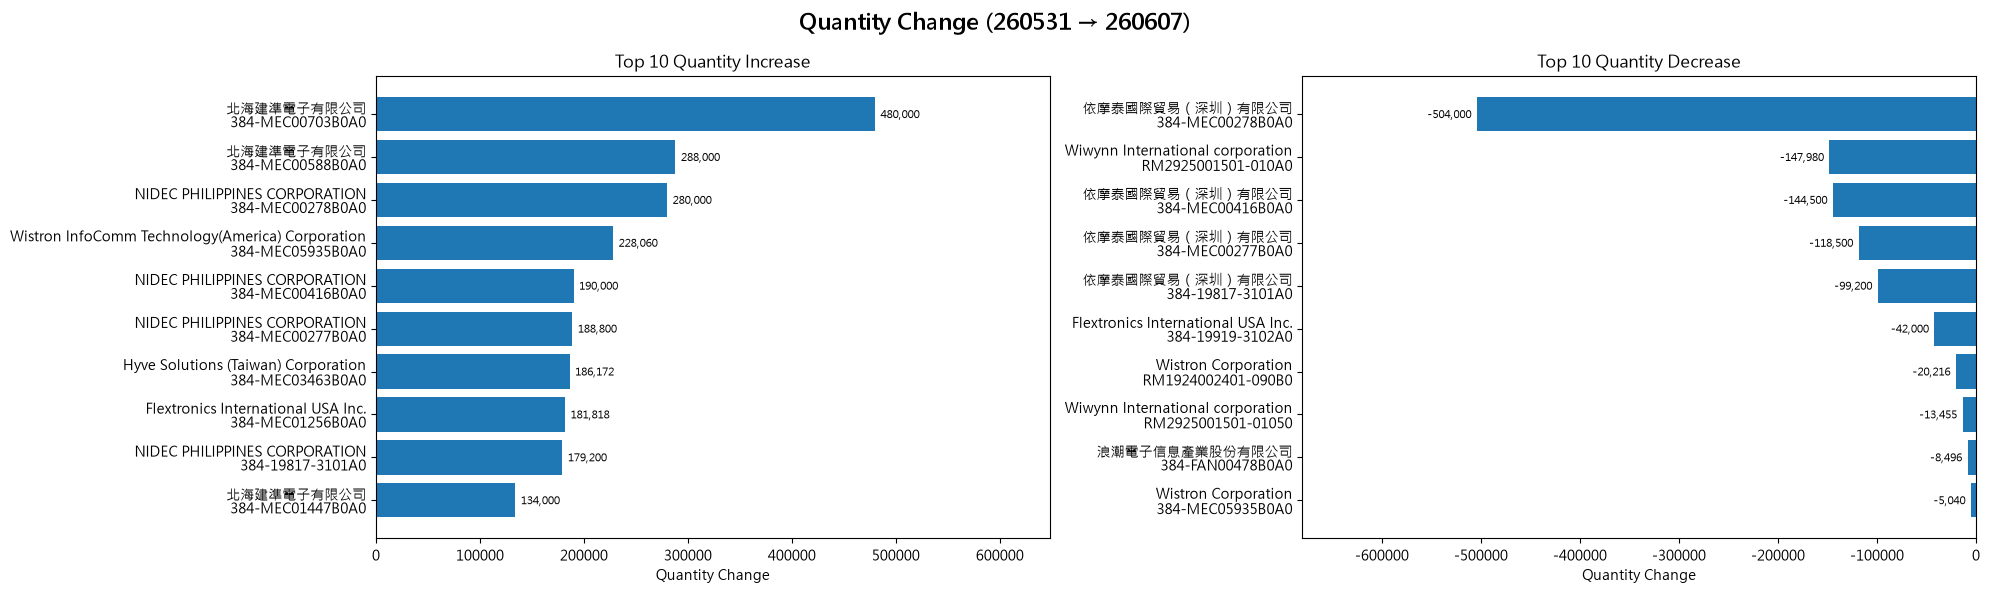

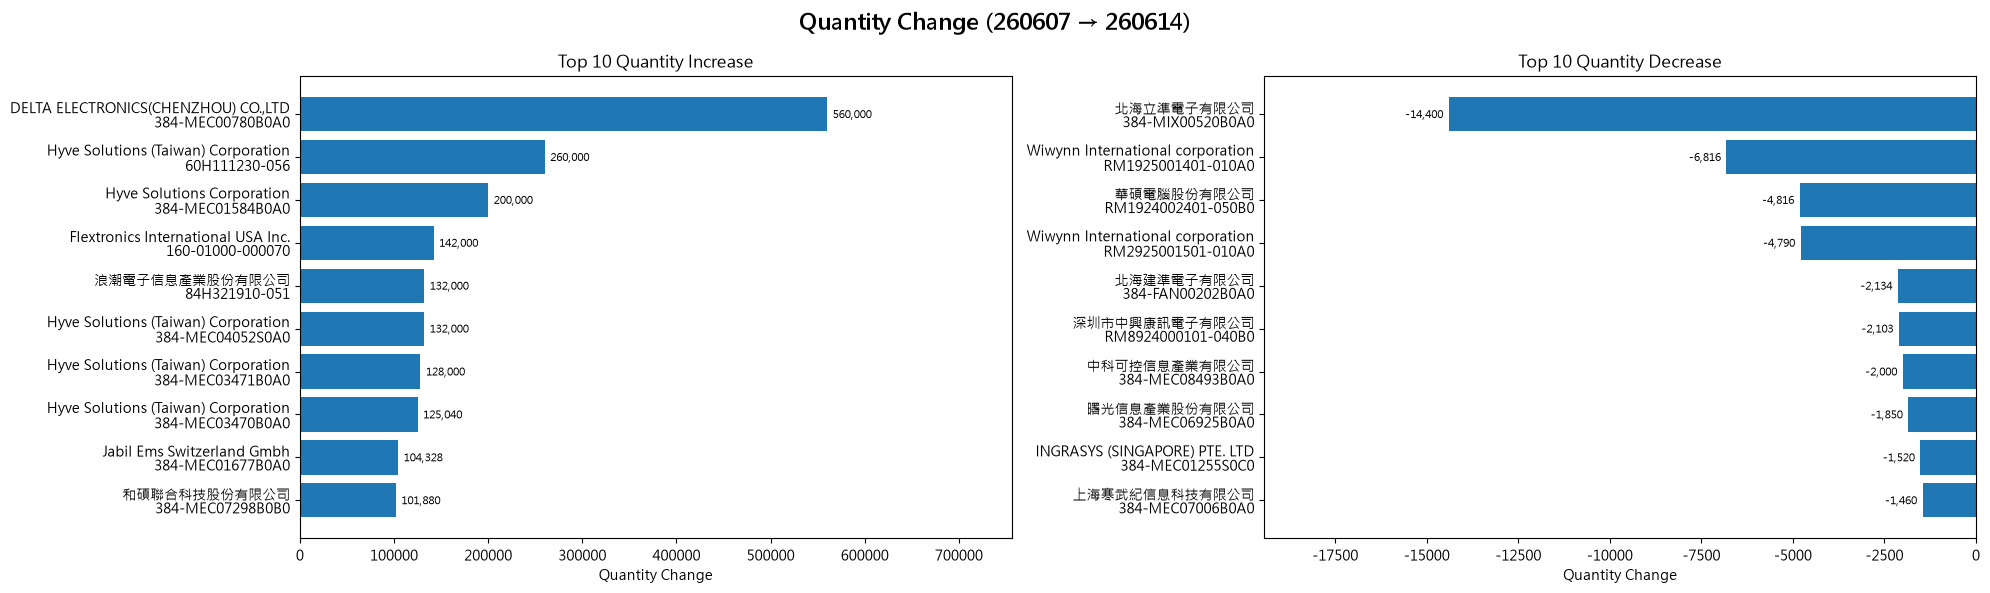

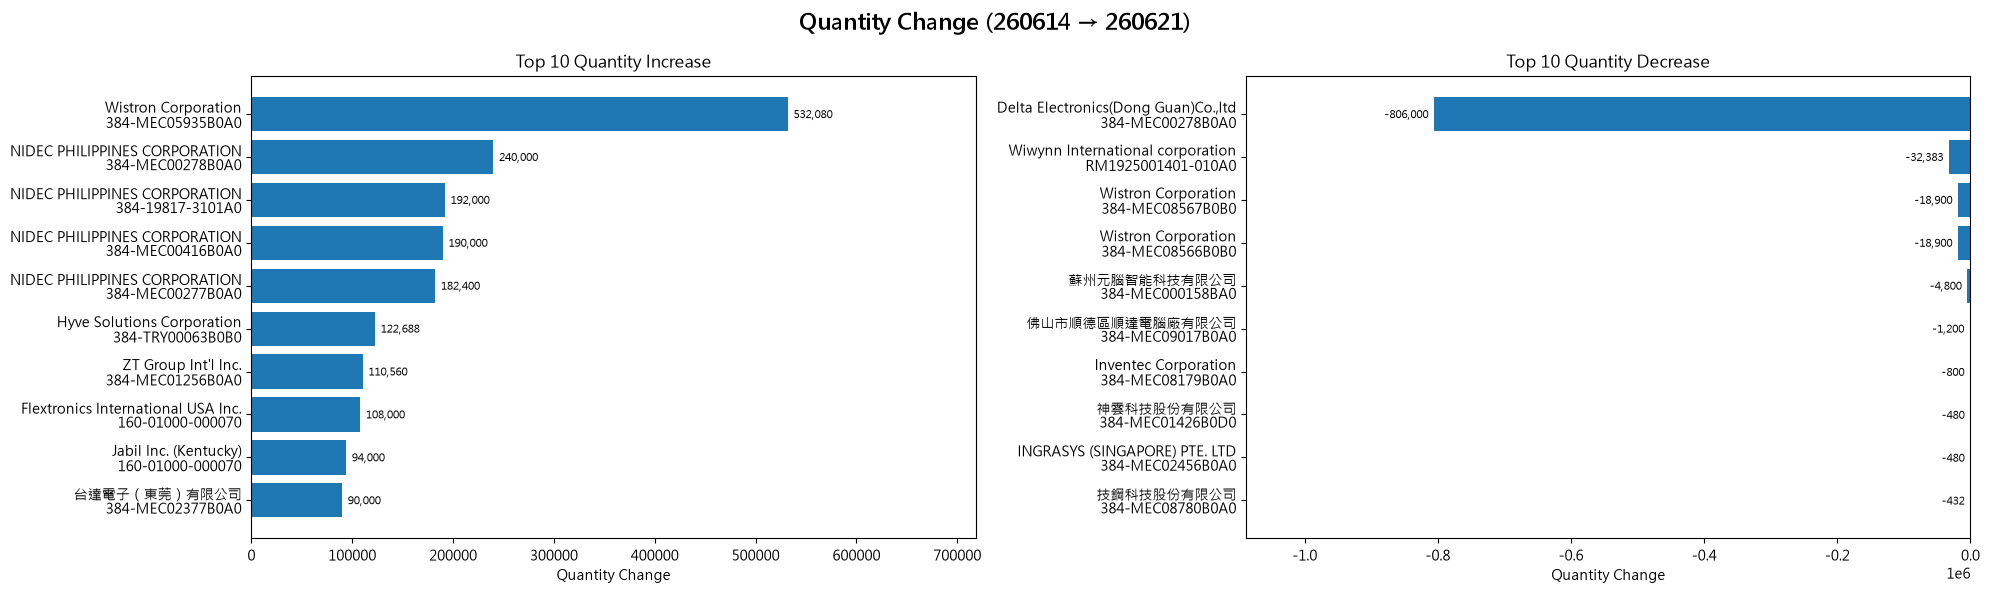

In [ ]:
# quantity change top 10 increase and decrease plot
for comparison in all_qty_change_df["Comparison"].unique():

    comparison_df = all_qty_change_df[
        all_qty_change_df["Comparison"] == comparison
    ].copy()

    top_qty_increase = (
        comparison_df
        .sort_values("QTY_DIFF", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    top_qty_decrease = (
        comparison_df
        .sort_values("QTY_DIFF", ascending=True)
        .head(10)
        .reset_index(drop=True)
    )

    top_qty_increase["LABEL"] = (
        top_qty_increase["PARTY_NAME"].astype(str)
        + "\n"
        + top_qty_increase["SEGMENT1"].astype(str)
    )

    top_qty_decrease["LABEL"] = (
        top_qty_decrease["PARTY_NAME"].astype(str)
        + "\n"
        + top_qty_decrease["SEGMENT1"].astype(str)
    )

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # Increase
    bars = axes[0].barh(
        top_qty_increase["LABEL"],
        top_qty_increase["QTY_DIFF"] 
    )

    axes[0].invert_yaxis()
    axes[0].set_title("Top 10 Quantity Increase")
    axes[0].set_xlabel("Quantity Change")

    max_pos = top_qty_increase["QTY_DIFF"].max()
    axes[0].set_xlim(0, max_pos * 1.35)

    axes[0].bar_label(
        bars,
        labels=[f"{v:,.0f}" for v in top_qty_increase["QTY_DIFF"]],
        padding=4,
        fontsize=8
    )

    # Decrease
    bars = axes[1].barh(
        top_qty_decrease["LABEL"],
        top_qty_decrease["QTY_DIFF"]
    )

    axes[1].invert_yaxis()
    axes[1].set_title("Top 10 Quantity Decrease")
    axes[1].set_xlabel("Quantity Change")

    min_neg = top_qty_decrease["QTY_DIFF"].min()
    axes[1].set_xlim(min_neg * 1.35, 0)

    axes[1].bar_label(
        bars,
        labels=[f"{v:,.0f}" for v in top_qty_decrease["QTY_DIFF"]],
        padding=4,
        fontsize=8
    )

    fig.suptitle(
        f"Quantity Change ({comparison})",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# Awaiting Quantity Flow Analysis
# Compare two snapshots by Customer + Segment

AWAITING_STATUS = "AWAITING_SHIPPING"

def analyze_awaiting_quantity_flow(data1_name, data2_name):
    comparison = get_comparison_label(data1_name, data2_name)
    merged = merged_base_map[comparison].copy()

    merged["Comparison"] = comparison

    merged["CUSTOMER"] = merged["PARTY_NAME_data2"].fillna(merged["PARTY_NAME_data1"])
    merged["SEGMENT"] = merged["SEGMENT1_data2"].fillna(merged["SEGMENT1_data1"])

    merged["QTY_data1"] = merged["ORDERED_QUANTITY_data1"].fillna(0)
    merged["QTY_data2"] = merged["ORDERED_QUANTITY_data2"].fillna(0)

    merged["IS_AWAITING_data1"] = (
        merged["FLOW_STATUS_CODE_data1"] == AWAITING_STATUS
    )

    merged["IS_AWAITING_data2"] = (
        merged["FLOW_STATUS_CODE_data2"] == AWAITING_STATUS
    )

    def classify_flow(row):
        status1 = row["FLOW_STATUS_CODE_data1"]
        status2 = row["FLOW_STATUS_CODE_data2"]
        qty1 = row["QTY_data1"]
        qty2 = row["QTY_data2"]

        if row["MATCH_STATUS"] == "New" and row["IS_AWAITING_data2"]:
            return "New Awaiting Order"

        if row["IS_AWAITING_data1"] and row["MATCH_STATUS"] == "Missing":
            return "Missing from Data2"

        if row["IS_AWAITING_data1"] and status2 == "CANCELLED":
            return "Cancelled"

        if row["IS_AWAITING_data1"] and not row["IS_AWAITING_data2"]:
            return "Changed to Not Awaiting"

        if row["IS_AWAITING_data1"] and row["IS_AWAITING_data2"]:
            if qty2 > qty1:
                return "Awaiting Quantity Increase"
            elif qty2 < qty1:
                return "Awaiting Quantity Decrease"
            else:
                return "Still Awaiting No Qty Change"

        if (not row["IS_AWAITING_data1"]) and row["IS_AWAITING_data2"]:
            return "Changed to Awaiting"

        return "Not Related"

    merged["AWAITING_FLOW_REASON"] = merged.apply(classify_flow, axis=1)

    related_df = merged[
        merged["AWAITING_FLOW_REASON"] != "Not Related"
    ].copy()

    related_df["AWAITING_QTY_IMPACT"] = 0

    related_df.loc[
        related_df["AWAITING_FLOW_REASON"] == "New Awaiting Order",
        "AWAITING_QTY_IMPACT"
    ] = related_df["QTY_data2"]

    related_df.loc[
        related_df["AWAITING_FLOW_REASON"] == "Changed to Awaiting",
        "AWAITING_QTY_IMPACT"
    ] = related_df["QTY_data2"]

    related_df.loc[
        related_df["AWAITING_FLOW_REASON"] == "Cancelled",
        "AWAITING_QTY_IMPACT"
    ] = -related_df["QTY_data1"]

    related_df.loc[
        related_df["AWAITING_FLOW_REASON"] == "Changed to Not Awaiting",
        "AWAITING_QTY_IMPACT"
    ] = -related_df["QTY_data1"]

    related_df.loc[
        related_df["AWAITING_FLOW_REASON"] == "Missing from Data2",
        "AWAITING_QTY_IMPACT"
    ] = -related_df["QTY_data1"]

    related_df.loc[
        related_df["AWAITING_FLOW_REASON"] == "Quantity Increase",
        "AWAITING_QTY_IMPACT"
    ] = related_df["QTY_data2"] - related_df["QTY_data1"]

    related_df.loc[
        related_df["AWAITING_FLOW_REASON"] == "Quantity Decrease",
        "AWAITING_QTY_IMPACT"
    ] = related_df["QTY_data2"] - related_df["QTY_data1"]

    flow_summary = (
        related_df
        .groupby(
            ["Comparison", "CUSTOMER", "SEGMENT", "AWAITING_FLOW_REASON"],
            as_index=False
        )
        .agg(
            LINE_COUNT=("LINE_ID", "nunique"),
            QTY_IMPACT=("AWAITING_QTY_IMPACT", "sum"),
            DATA1_QTY=("QTY_data1", "sum"),
            DATA2_QTY=("QTY_data2", "sum")
        )
    )

    return related_df, flow_summary

In [ ]:
AWAITING_STATUS = "AWAITING_SHIPPING"

# Collect every snapshot once
snapshot_df_map = {
    file_name: get_snapshot_df(file_name)
    for file_name in SNAPSHOT_FILES
}


# 各版本 Awaiting Quantity
all_version_awaiting_qty = []

for version_name, df in snapshot_df_map.items():

    awaiting_df = df[
        df["FLOW_STATUS_CODE"] == AWAITING_STATUS
    ].copy()

    all_version_awaiting_qty.append({
        "Version": get_backup_version(version_name),
        "AWAITING_LINE_COUNT": len(awaiting_df),
        "AWAITING_TOTAL_QTY": awaiting_df["ORDERED_QUANTITY"].sum()
    })

awaiting_qty_by_version_df = pd.DataFrame(
    all_version_awaiting_qty
)


# Awaiting Quantity by PROJECT_CODE
all_project_awaiting_qty = []

for version_name, df in snapshot_df_map.items():

    awaiting_df = df[
        df["FLOW_STATUS_CODE"] == AWAITING_STATUS
    ].copy()

    awaiting_df["PROJECT_CODE"] = (
        awaiting_df["PROJECT_CODE"]
        .fillna("Missing PROJECT_CODE")
    )

    project_summary = (
        awaiting_df
        .groupby("PROJECT_CODE", as_index=False)
        .agg(
            AWAITING_LINE_COUNT=("ORDERED_QUANTITY", "count"),
            AWAITING_TOTAL_QTY=("ORDERED_QUANTITY", "sum")
        )
    )

    project_summary.insert(
        0,
        "Version",
        get_backup_version(version_name)
    )

    all_project_awaiting_qty.append(project_summary)

awaiting_qty_by_project_df = pd.concat(
    all_project_awaiting_qty,
    ignore_index=True
)


# Awaiting Flow Reason Summary
all_awaiting_flow_details = []
all_awaiting_flow_summaries = []

for data1_name, data2_name in SNAPSHOT_PAIRS:

    detail, summary = analyze_awaiting_quantity_flow(
        data1_name,
        data2_name
    )

    all_awaiting_flow_details.append(detail)
    all_awaiting_flow_summaries.append(summary)

awaiting_flow_detail_df = pd.concat(
    all_awaiting_flow_details,
    ignore_index=True
)

awaiting_flow_summary_df = pd.concat(
    all_awaiting_flow_summaries,
    ignore_index=True
)

awaiting_flow_reason_summary = (
    awaiting_flow_summary_df
    .groupby(
        ["Comparison", "AWAITING_FLOW_REASON"],
        as_index=False
    )
    .agg(
        LINE_COUNT=("LINE_COUNT", "sum"),
        QTY_IMPACT=("QTY_IMPACT", "sum")
    )
)


# Flow Reason Pivot
awaiting_flow_pivot = (
    awaiting_flow_reason_summary
    .pivot_table(
        index="Comparison",
        columns="AWAITING_FLOW_REASON",
        values="LINE_COUNT",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

awaiting_flow_pivot.columns.name = None


# Only display the two main outputs
display(
    awaiting_qty_by_version_df.style
    .format({
        "AWAITING_LINE_COUNT": "{:,.0f}",
        "AWAITING_TOTAL_QTY": "{:,.0f}"
    })
    .hide(axis="index")
)

display(
    awaiting_flow_pivot.style
    .format(
        {
            col: "{:,.0f}"
            for col in awaiting_flow_pivot.columns
            if col != "Comparison"
        }
    )
    .hide(axis="index")
)


# Export all detail tables to Excel
output_file = "awaiting_quantity_analysis.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    awaiting_qty_by_version_df.to_excel(
        writer,
        sheet_name="Version Awaiting Qty",
        index=False
    )

    awaiting_qty_by_project_df.to_excel(
        writer,
        sheet_name="Project Awaiting Qty",
        index=False
    )

    awaiting_flow_reason_summary.to_excel(
        writer,
        sheet_name="Flow Reason Summary",
        index=False
    )

    awaiting_flow_pivot.to_excel(
        writer,
        sheet_name="Flow Reason Pivot",
        index=False
    )

print(f"Excel exported: {output_file}")

Version,AWAITING_LINE_COUNT,AWAITING_TOTAL_QTY
260531,"8,961","23,440,018"
260607,"9,029","24,211,458"
260614,"9,254","24,704,254"
260621,"9,552","25,728,340"


Comparison,Awaiting Quantity Decrease,Awaiting Quantity Increase,Cancelled,Changed to Awaiting,Changed to Not Awaiting,New Awaiting Order,Still Awaiting No Qty Change
260531 → 260607,281,134,509,0,818,"1,395","7,219"
260607 → 260614,259,93,343,1,810,"1,377","7,524"
260614 → 260621,321,100,278,1,770,"1,345","7,785"


Excel exported: awaiting_quantity_analysis.xlsx


In [ ]:
# Awaiting Shipping Summary + Top 10 by Project Code

all_awaiting_summary = []

for file_name in SNAPSHOT_FILES:

    df = snapshots[file_name].copy()

    awaiting_df = df[
        df["FLOW_STATUS_CODE"] == "AWAITING_SHIPPING"
    ].copy()

    data_version = get_backup_version(file_name)

    summary = {
        "Data Version": data_version,
        "Awaiting Line Count": awaiting_df["LINE_ID"].nunique(),
        "Awaiting Quantity": awaiting_df["ORDERED_QUANTITY"].sum()
    }

    all_awaiting_summary.append(summary)

awaiting_summary_df = pd.DataFrame(all_awaiting_summary)

for file_name in SNAPSHOT_FILES:

    df = snapshots[file_name].copy()

    awaiting_df = df[
        df["FLOW_STATUS_CODE"] == "AWAITING_SHIPPING"
    ].copy()

    project_summary = (
        awaiting_df
        .groupby("PROJECT_CODE", as_index=False)
        .agg(
            Awaiting_Line_Count=("LINE_ID", "nunique"),
            Awaiting_Quantity=("ORDERED_QUANTITY", "sum")
        )
    )

    data_version = get_backup_version(file_name)

    print(f"\n{data_version}")

    print("Top 10 Awaiting Quantity")
    display(
        project_summary
        .nlargest(10, "Awaiting_Quantity")
        .style.hide(axis="index")
    )

    print("Top 10 Awaiting Line Count")
    display(
        project_summary
        .nlargest(10, "Awaiting_Line_Count")
        .style.hide(axis="index")
    )


260531
Top 10 Awaiting Quantity


PROJECT_CODE,Awaiting_Line_Count,Awaiting_Quantity
AC2.0 HOPPER,151,5629956.000000
AC1.1,115,2589263.000000
三江源V1,232,2124347.000000
GOSHIN,308,1420414.000000
NA,173,1061429.000000
K895G6 (XIANGYANG),490,999775.000000
U90G5 (POYANGHU),241,779511.000000
T2 PDS,226,650344.000000
星河4U,296,600270.000000
YICHUN,301,433549.000000


Top 10 Awaiting Line Count


PROJECT_CODE,Awaiting_Line_Count,Awaiting_Quantity
K895G6 (XIANGYANG),490,999775.000000
GOSHIN,308,1420414.000000
YICHUN,301,433549.000000
星河4U,296,600270.000000
U90G5 (POYANGHU),241,779511.000000
MGX_1U_GB300,232,395648.000000
三江源V1,232,2124347.000000
T2 PDS,226,650344.000000
星星海V2,225,124292.000000
三江源V2,197,190045.000000



260607
Top 10 Awaiting Quantity


...

PROJECT_CODE,Awaiting_Line_Count,Awaiting_Quantity
K895G6 (XIANGYANG),547,979651.000000
星星海V2,304,164207.000000
MGX_1U_GB300,295,573602.000000
YICHUN,295,424715.000000
三江源V1,288,2618993.000000
GOSHIN,273,1193097.000000
星河4U,263,491798.000000
U90G5 (POYANGHU),244,747523.000000
三江源V2,238,224607.000000
T2 PDS,195,564079.000000



260621
Top 10 Awaiting Quantity


PROJECT_CODE,Awaiting_Line_Count,Awaiting_Quantity
AC2.0 HOPPER,62,4800964.000000
AC1.1,94,2993563.000000
三江源V1,259,2315073.000000
RM156,77,1331448.000000
GOSHIN,288,1235747.000000
K895G6 (XIANGYANG),588,1127706.000000
NA,177,1125794.000000
MGX_1U_GB300,313,785774.000000
U90G5 (POYANGHU),239,668279.000000
HOPPER 49,26,666432.000000


Top 10 Awaiting Line Count


PROJECT_CODE,Awaiting_Line_Count,Awaiting_Quantity
K895G6 (XIANGYANG),588,1127706.000000
MGX_1U_GB300,313,785774.000000
星星海V2,301,162184.000000
YICHUN,299,450598.000000
GOSHIN,288,1235747.000000
三江源V1,259,2315073.000000
U90G5 (POYANGHU),239,668279.000000
星河4U,239,387719.000000
三江源V2,233,208253.000000
T3 PDS,215,551609.000000


In [ ]:
awaiting_flow_pivot = awaiting_flow_reason_summary.pivot_table(
    index="Comparison",
    columns="AWAITING_FLOW_REASON",
    values="LINE_COUNT",
    aggfunc="sum",
    fill_value=0
).reset_index()

awaiting_flow_pivot.columns.name = None

display(awaiting_flow_pivot.style.hide(axis="index"))

Comparison,Awaiting Quantity Decrease,Awaiting Quantity Increase,Cancelled,Changed to Awaiting,Changed to Not Awaiting,New Awaiting Order,Still Awaiting No Qty Change
260531 → 260607,281,134,509,0,818,1395,7219
260607 → 260614,259,93,343,1,810,1377,7524
260614 → 260621,321,100,278,1,770,1345,7785


In [ ]:
def analyze_new_orders(data1_name, data2_name):

    comparison = get_comparison_label(data1_name, data2_name)
    merged = merged_base_map[comparison].copy()

    # Existing order groups in Data1
    existing_lines = merged[
        merged["MATCH_STATUS"] == "Existing"
    ].copy()

    existing_lines["ORDER_GROUP_ID_data1"] = (
        existing_lines["LINE_SET_ID_data1"]
        .fillna(existing_lines["LINE_ID"])
    )

    existing_group_ids = set(
        existing_lines["ORDER_GROUP_ID_data1"]
        .dropna()
    )

    # New lines appearing in Data2
    new_order_analysis = merged[
        merged["MATCH_STATUS"] == "New"
    ].copy()

    new_order_analysis["ORDER_GROUP_ID"] = (
        new_order_analysis["LINE_SET_ID_data2"]
        .fillna(new_order_analysis["LINE_ID"])
    )

    # If the order group already existed in Data1,
    # treat it as another branch of an existing order
    new_order_analysis["NEW_ORDER_TYPE"] = np.where(
        new_order_analysis["ORDER_GROUP_ID"].isin(existing_group_ids),
        "Other Order Branch",
        "True New Order"
    )

    new_order_analysis["ORDERED_QUANTITY_data2"] = pd.to_numeric(
        new_order_analysis["ORDERED_QUANTITY_data2"],
        errors="coerce"
    ).fillna(0)

    summary = (
        new_order_analysis
        .groupby("NEW_ORDER_TYPE", as_index=False)
        .agg(
            LINE_COUNT=("LINE_ID", "count"),
            TOTAL_QTY=("ORDERED_QUANTITY_data2", "sum")
        )
    )

    summary["Comparison"] = comparison

    return summary, new_order_analysis

In [ ]:
AWAITING_STATUS = "AWAITING_SHIPPING"

def analyze_awaiting_qty_bridge(data1_name, data2_name):
    comparison = get_comparison_label(data1_name, data2_name)

    df = merged_base_map[comparison].copy()
    df["Comparison"] = comparison

    df["CUSTOMER"] = df["PARTY_NAME_data1"].fillna(df["PARTY_NAME_data2"])
    df["SEGMENT"] = df["SEGMENT1_data1"].fillna(df["SEGMENT1_data2"])

    project_col_1 = "PROJECT_CODE_data1" if "PROJECT_CODE_data1" in df.columns else None
    project_col_2 = "PROJECT_CODE_data2" if "PROJECT_CODE_data2" in df.columns else None

    if project_col_1 and project_col_2:
        df["PROJECT_CODE"] = df[project_col_1].fillna(df[project_col_2])
    elif project_col_1:
        df["PROJECT_CODE"] = df[project_col_1]
    elif project_col_2:
        df["PROJECT_CODE"] = df[project_col_2]
    elif "PROJECT_CODE" in df.columns:
        df["PROJECT_CODE"] = df["PROJECT_CODE"]
    else:
        raise KeyError("No PROJECT_CODE column found")

    df["PROJECT_CODE"] = (
        df["PROJECT_CODE"]
        .astype(str)
        .str.strip()
        .replace(["", "nan", "NaN", "None", "NONE"], "Missing PROJECT_CODE")
    )

    df["QTY_data1"] = df["ORDERED_QUANTITY_data1"].fillna(0)
    df["QTY_data2"] = df["ORDERED_QUANTITY_data2"].fillna(0)

    df["FLOW_STATUS_CODE_data1_CLEAN"] = (
        df["FLOW_STATUS_CODE_data1"].fillna("").astype(str).str.strip().str.upper()
    )

    df["FLOW_STATUS_CODE_data2_CLEAN"] = (
        df["FLOW_STATUS_CODE_data2"].fillna("").astype(str).str.strip().str.upper()
    )

    df["IS_AWAITING_data1"] = df["FLOW_STATUS_CODE_data1_CLEAN"] == AWAITING_STATUS
    df["IS_AWAITING_data2"] = df["FLOW_STATUS_CODE_data2_CLEAN"] == AWAITING_STATUS

    group_cols = ["Comparison", "CUSTOMER", "SEGMENT", "PROJECT_CODE"]

    df["ORDER_GROUP_ID_data1"] = df["LINE_SET_ID_data1"].fillna(df["LINE_ID"])
    df["ORDER_GROUP_ID_data2"] = df["LINE_SET_ID_data2"].fillna(df["LINE_ID"])
    df["ORDER_GROUP_ID"] = df["ORDER_GROUP_ID_data1"].fillna(df["ORDER_GROUP_ID_data2"])

    data1_awaiting_qty = (
        df[df["IS_AWAITING_data1"]]
        .groupby(group_cols, as_index=False)
        .agg(Data1_Awaiting_Qty=("QTY_data1", "sum"))
    )

    data2_awaiting_qty = (
        df[df["IS_AWAITING_data2"]]
        .groupby(group_cols, as_index=False)
        .agg(Data2_Awaiting_Qty=("QTY_data2", "sum"))
    )

    group_level = (
        df.groupby(group_cols + ["ORDER_GROUP_ID"], as_index=False)
        .agg(
            Data1_Group_Awaiting_Qty=(
                "QTY_data1",
                lambda x: x[df.loc[x.index, "IS_AWAITING_data1"]].sum()
            ),
            Data2_Group_Awaiting_Qty=(
                "QTY_data2",
                lambda x: x[df.loc[x.index, "IS_AWAITING_data2"]].sum()
            )
        )
    )

    group_level["Group_Awaiting_Qty_Change"] = (
        group_level["Data2_Group_Awaiting_Qty"]
        - group_level["Data1_Group_Awaiting_Qty"]
    )

    group_level["Qty_Increase_Still_Awaiting"] = np.where(
        (group_level["Data1_Group_Awaiting_Qty"] > 0) &
        (group_level["Data2_Group_Awaiting_Qty"] > 0) &
        (group_level["Group_Awaiting_Qty_Change"] > 0),
        group_level["Group_Awaiting_Qty_Change"],
        0
    )

    group_level["Qty_Decrease_Still_Awaiting"] = np.where(
        (group_level["Data1_Group_Awaiting_Qty"] > 0) &
        (group_level["Data2_Group_Awaiting_Qty"] > 0) &
        (group_level["Group_Awaiting_Qty_Change"] < 0),
        group_level["Group_Awaiting_Qty_Change"],
        0
    )

    df["Cancelled"] = np.where(
        df["IS_AWAITING_data1"] &
        (df["FLOW_STATUS_CODE_data2_CLEAN"] == "CANCELLED"),
        -df["QTY_data1"],
        0
    )

    df["Closed"] = np.where(
        df["IS_AWAITING_data1"] &
        (df["FLOW_STATUS_CODE_data2_CLEAN"] == "CLOSED"),
        -df["QTY_data1"],
        0
    )

    df["Changed_to_Other_Flow_Status"] = np.where(
        df["IS_AWAITING_data1"] &
        (df["FLOW_STATUS_CODE_data2_CLEAN"] != "") &
        ~df["FLOW_STATUS_CODE_data2_CLEAN"].isin(
            [AWAITING_STATUS, "CANCELLED", "CLOSED"]
        ),
        -df["QTY_data1"],
        0
    )

    df["Missing_in_Data2"] = np.where(
        df["IS_AWAITING_data1"] &
        (df["MATCH_STATUS"] == "Missing"),
        -df["QTY_data1"],
        0
    )

    qty_change_breakdown = (
        group_level
        .groupby(group_cols, as_index=False)
        .agg(
            Qty_Increase_Still_Awaiting=("Qty_Increase_Still_Awaiting", "sum"),
            Qty_Decrease_Still_Awaiting=("Qty_Decrease_Still_Awaiting", "sum")
        )
    )

    status_breakdown = (
        df.groupby(group_cols, as_index=False)
        .agg(
            Cancelled=("Cancelled", "sum"),
            Closed=("Closed", "sum"),
            Changed_to_Other_Flow_Status=("Changed_to_Other_Flow_Status", "sum"),
            Missing_in_Data2=("Missing_in_Data2", "sum")
        )
    )

    # Use your existing new order function
    new_order_summary, new_order_analysis = analyze_new_orders(data1_name, data2_name)

    new_order_analysis["Comparison"] = comparison

    new_order_analysis["FLOW_STATUS_CODE_data2_CLEAN"] = (
        new_order_analysis["FLOW_STATUS_CODE_data2"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    new_order_analysis["CUSTOMER"] = (
        new_order_analysis["PARTY_NAME_data1"]
        .fillna(new_order_analysis["PARTY_NAME_data2"])
    )

    new_order_analysis["SEGMENT"] = (
        new_order_analysis["SEGMENT1_data1"]
        .fillna(new_order_analysis["SEGMENT1_data2"])
    )

    project_col_1_new = "PROJECT_CODE_data1" if "PROJECT_CODE_data1" in new_order_analysis.columns else None
    project_col_2_new = "PROJECT_CODE_data2" if "PROJECT_CODE_data2" in new_order_analysis.columns else None

    if project_col_1_new and project_col_2_new:
        new_order_analysis["PROJECT_CODE"] = (
            new_order_analysis[project_col_1_new]
            .fillna(new_order_analysis[project_col_2_new])
        )
    elif project_col_1_new:
        new_order_analysis["PROJECT_CODE"] = new_order_analysis[project_col_1_new]
    elif project_col_2_new:
        new_order_analysis["PROJECT_CODE"] = new_order_analysis[project_col_2_new]
    elif "PROJECT_CODE" in new_order_analysis.columns:
        new_order_analysis["PROJECT_CODE"] = new_order_analysis["PROJECT_CODE"]
    else:
        raise KeyError("No PROJECT_CODE column found in new_order_analysis")

    new_order_analysis["PROJECT_CODE"] = (
        new_order_analysis["PROJECT_CODE"]
        .astype(str)
        .str.strip()
        .replace(["", "nan", "NaN", "None", "NONE"], "Missing PROJECT_CODE")
    )

    new_order_analysis["QTY_data2"] = (
        new_order_analysis["ORDERED_QUANTITY_data2"].fillna(0)
    )

    new_awaiting_breakdown = (
        new_order_analysis[
            new_order_analysis["FLOW_STATUS_CODE_data2_CLEAN"] == AWAITING_STATUS
        ]
        .groupby(
            ["Comparison", "CUSTOMER", "SEGMENT", "PROJECT_CODE", "NEW_ORDER_TYPE"],
            as_index=False
        )
        .agg(NEW_AWAITING_QTY=("QTY_data2", "sum"))
        .pivot_table(
            index=["Comparison", "CUSTOMER", "SEGMENT", "PROJECT_CODE"],
            columns="NEW_ORDER_TYPE",
            values="NEW_AWAITING_QTY",
            aggfunc="sum",
            fill_value=0
        )
        .reset_index()
    )

    new_awaiting_breakdown.columns.name = None

    new_awaiting_breakdown = new_awaiting_breakdown.rename(columns={
        "True New Order": "New_Awaiting_Orders",
        "Other Order Branch": "Awaiting_Order_Branch"
    })

    for col in ["New_Awaiting_Orders", "Awaiting_Order_Branch"]:
        if col not in new_awaiting_breakdown.columns:
            new_awaiting_breakdown[col] = 0

    breakdown = qty_change_breakdown.merge(
        status_breakdown,
        on=group_cols,
        how="outer"
    )

    breakdown = breakdown.merge(
        new_awaiting_breakdown[
            group_cols + ["New_Awaiting_Orders", "Awaiting_Order_Branch"]
        ],
        on=group_cols,
        how="outer"
    )

    summary = data1_awaiting_qty.merge(
        data2_awaiting_qty,
        on=group_cols,
        how="outer"
    )

    summary = summary.merge(
        breakdown,
        on=group_cols,
        how="left"
    )

    numeric_cols = summary.select_dtypes(include="number").columns
    summary[numeric_cols] = summary[numeric_cols].fillna(0)

    summary["Awaiting_Qty_Change"] = (
        summary["Data2_Awaiting_Qty"]
        - summary["Data1_Awaiting_Qty"]
    )

    summary["Explained_Change"] = (
        summary["Qty_Increase_Still_Awaiting"]
        + summary["Qty_Decrease_Still_Awaiting"]
        + summary["Cancelled"]
        + summary["Closed"]
        + summary["Changed_to_Other_Flow_Status"]
        + summary["Missing_in_Data2"]
        + summary["New_Awaiting_Orders"]
        + summary["Awaiting_Order_Branch"]
    )

    summary["Bridge_Check"] = (
        summary["Awaiting_Qty_Change"]
        - summary["Explained_Change"]
    )

    summary = summary[
        [
            "Comparison",
            "CUSTOMER",
            "SEGMENT",
            "PROJECT_CODE",
            "Data1_Awaiting_Qty",
            "Data2_Awaiting_Qty",
            "Awaiting_Qty_Change",
            "Qty_Increase_Still_Awaiting",
            "Qty_Decrease_Still_Awaiting",
            "Cancelled",
            "Closed",
            "Changed_to_Other_Flow_Status",
            "Missing_in_Data2",
            "New_Awaiting_Orders",
            "Awaiting_Order_Branch",
            "Explained_Change",
            "Bridge_Check"
        ]
    ]

    numeric_cols = summary.select_dtypes(include="number").columns
    summary[numeric_cols] = summary[numeric_cols].round(0).astype(int)

    return df, summary

In [ ]:
all_awaiting_bridge_summaries = []

for data1_name, data2_name in SNAPSHOT_PAIRS:
    detail, summary = analyze_awaiting_qty_bridge(data1_name, data2_name)
    all_awaiting_bridge_summaries.append(summary)

awaiting_bridge_summary_df = pd.concat(
    all_awaiting_bridge_summaries,
    ignore_index=True
)

In [ ]:
# Project Code level Awaiting Qty summary
awaiting_project_summary = (
    awaiting_bridge_summary_df
    .groupby(
        ["Comparison", "PROJECT_CODE"],
        as_index=False
    )
    .agg(
        Awaiting_Qty_Change=("Awaiting_Qty_Change", "sum")
    )
)


# Pivot into weekly trend table
project_trend = (
    awaiting_project_summary
    .pivot_table(
        index="PROJECT_CODE",
        columns="Comparison",
        values="Awaiting_Qty_Change",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

project_trend.columns.name = None


comparison_cols = [
    col
    for col in project_trend.columns
    if col != "PROJECT_CODE"
]


project_trend["Total_Change"] = (
    project_trend[comparison_cols]
    .sum(axis=1)
)

project_trend["Positive_Periods"] = (
    project_trend[comparison_cols] > 0
).sum(axis=1)

project_trend["Negative_Periods"] = (
    project_trend[comparison_cols] < 0
).sum(axis=1)

project_trend["No_Change_Periods"] = (
    project_trend[comparison_cols] == 0
).sum(axis=1)


def classify_project_trend(row):
    total_periods = len(comparison_cols)

    if row["Positive_Periods"] == total_periods:
        return "Persistent Increase"

    if row["Negative_Periods"] == total_periods:
        return "Persistent Decrease"

    if row["Positive_Periods"] >= 2:
        return "Mostly Increasing"

    if row["Negative_Periods"] >= 2:
        return "Mostly Decreasing"

    return "Mixed Trend"


project_trend["Trend_Category"] = (
    project_trend.apply(
        classify_project_trend,
        axis=1
    )
)

project_trend = (
    project_trend
    .sort_values(
        "Total_Change",
        ascending=False
    )
    .reset_index(drop=True)
)


trend_category_summary = (
    project_trend["Trend_Category"]
    .value_counts()
    .rename_axis("Trend_Category")
    .reset_index(name="Project_Count")
)

trend_category_summary["Percentage"] = (
    trend_category_summary["Project_Count"]
    / trend_category_summary["Project_Count"].sum()
    * 100
).round(1)


# Only display final summaries
display(
    project_trend
    .head(10)
    .style
    .format({
        col: "{:+,.0f}"
        for col in comparison_cols + ["Total_Change"]
    })
    .hide(axis="index")
)

display(
    trend_category_summary
    .style
    .format({
        "Project_Count": "{:,.0f}",
        "Percentage": "{:.1f}%"
    })
    .hide(axis="index")
)

PROJECT_CODE,260531 → 260607,260607 → 260614,260614 → 260621,Total_Change,Positive_Periods,Negative_Periods,No_Change_Periods,Trend_Category
RM156,"+304,560","+135,594","+583,768","+1,023,922",3,0,0,Persistent Increase
MGX_1U_VERA RUBIN,+29,"+209,191","+205,057","+414,277",3,0,0,Persistent Increase
HOPPER 49,"-15,840","+462,992","-37,872","+409,280",1,2,0,Mostly Decreasing
AC1.1,"+355,604","+110,326","-61,630","+404,300",2,1,0,Mostly Increasing
MGX_1U_GB300,"+100,046","+77,908","+212,172","+390,126",3,0,0,Persistent Increase
EVE 2U,"-22,300","-14,640","+245,372","+208,432",1,2,0,Mostly Decreasing
三江源V1,"+26,730","+467,916","-303,920","+190,726",2,1,0,Mostly Increasing
RM251,"+12,746","+114,203","+43,320","+170,269",3,0,0,Persistent Increase
K895G6 (XIANGYANG),"-1,451","-18,673","+148,055","+127,931",1,2,0,Mostly Decreasing
RM137,"+120,000",+0,+0,"+120,000",1,0,2,Mixed Trend


Trend_Category,Project_Count,Percentage
Mixed Trend,237,62.7%
Mostly Decreasing,57,15.1%
Mostly Increasing,53,14.0%
Persistent Increase,17,4.5%
Persistent Decrease,14,3.7%


In [ ]:
awaiting_project_top10 = (
    awaiting_bridge_summary_df
    .groupby(["Comparison", "PROJECT_CODE"], as_index=False)
    .agg(
        Data1_Awaiting_Qty=("Data1_Awaiting_Qty", "sum"),
        Data2_Awaiting_Qty=("Data2_Awaiting_Qty", "sum"),
        Awaiting_Qty_Change=("Awaiting_Qty_Change", "sum"),
        Qty_Increase_Still_Awaiting=("Qty_Increase_Still_Awaiting", "sum"),
        Qty_Decrease_Still_Awaiting=("Qty_Decrease_Still_Awaiting", "sum"),
        Cancelled=("Cancelled", "sum"),
        Closed=("Closed", "sum"),
        Changed_to_Other_Flow_Status=("Changed_to_Other_Flow_Status", "sum"),
        Missing_in_Data2=("Missing_in_Data2", "sum"),
        New_Awaiting_Orders=("New_Awaiting_Orders", "sum"),
        Awaiting_Order_Branch=("Awaiting_Order_Branch", "sum"),
    )
)